In [ ]:
from pathlib import Path
import json
import re
import sys
import unicodedata

import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.metrics import balanced_accuracy_score, silhouette_score
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import statsmodels.formula.api as smf
from statsmodels.iolib.summary2 import summary_col

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "src").exists() and (candidate / "README.md").exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break
from src.config import PROJECT_ROOT, ensure_default_directories
from src.utils import clean_country_code
from src.validation import assert_exported, assert_non_empty, assert_required_columns

ensure_default_directories()
FINAL_ANALYSIS_DIR = PROJECT_ROOT / "7 Final Analysis"
COUNTRY_DIR = PROJECT_ROOT / "6 Country level variables"
LLM_WIKIPEDIA_DIR = PROJECT_ROOT / "5 LLM Wikipedia analysis"
OUTPUTS_DIR = FINAL_ANALYSIS_DIR / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"
TABLES_DIR = OUTPUTS_DIR / "tables"

for folder in [OUTPUTS_DIR, FIGURES_DIR, TABLES_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

DEMOGRAPHY_PATH_CANDIDATES = [
    COUNTRY_DIR / "outputs" / "tables" / "demography_country_year.csv",
    COUNTRY_DIR / "demography_country_year.csv",
]

EXTRACTED_POLARISATION_PATH_CANDIDATES = [
    LLM_WIKIPEDIA_DIR / "outputs" / "tables" / "extracted_polarisation_final.xlsx",
    LLM_WIKIPEDIA_DIR / "extracted_polarisation_final.xlsx",
]

DEMOGRAPHY_PATH = next((p for p in DEMOGRAPHY_PATH_CANDIDATES if p.exists()), DEMOGRAPHY_PATH_CANDIDATES[0])
EXTRACTED_POLARISATION_PATH = next((p for p in EXTRACTED_POLARISATION_PATH_CANDIDATES if p.exists()), EXTRACTED_POLARISATION_PATH_CANDIDATES[0])

MERGED_OUTPUT_PATH = TABLES_DIR / "polarisation_with_demography.xlsx"
CLEANED_DATASET_PATH = TABLES_DIR / "cleaned_mep_analysis_dataset.csv"

assert DEMOGRAPHY_PATH.exists(), f"Demography file missing: {DEMOGRAPHY_PATH}"
assert EXTRACTED_POLARISATION_PATH.exists(), f"Extraction file missing: {EXTRACTED_POLARISATION_PATH}"
assert CLEANED_DATASET_PATH.exists(), f"Cleaned dataset file missing: {CLEANED_DATASET_PATH}"

print(f"Project root: {PROJECT_ROOT}")
print(f"Demography file: {DEMOGRAPHY_PATH}")
print(f"Extraction file: {EXTRACTED_POLARISATION_PATH}")
print(f"Tables dir: {TABLES_DIR}")

Project root: C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics
Demography file: C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\6 Country level variables\outputs\tables\demography_country_year.csv
Extraction file: C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\5 LLM Wikipedia analysis\outputs\tables\extracted_polarisation_final.xlsx
Tables dir: C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\7 Final Analysis\outputs\tables


Project root: C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics
Demography file: C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\6 Country level variables\outputs\tables\demography_country_year.csv
Extraction file: C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\5 LLM Wikipedia analysis\outputs\tables\extracted_polarisation_final.xlsx
Tables dir: C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\7 Final Analysis\outputs\tables


## Loading current version of Cleaned MEP and Country dataset

## Data loading and merge setup

This section prepares the two main source files and builds the merged analysis dataset:
1. Country-year demography panel.
2. Final extracted MEP-level polarisation file.

What this section does:
- Clarifies the purpose of this section and how it connects to the next steps.
- Summarizes expected inputs and outputs to make reruns easier to follow.


In [ ]:
demography_country_year = pd.read_csv(DEMOGRAPHY_PATH)
copy_extracted_polarisation_final = pd.read_excel(EXTRACTED_POLARISATION_PATH)
assert_non_empty(demography_country_year, "demography_country_year")
assert_non_empty(copy_extracted_polarisation_final, "copy_extracted_polarisation_final")
assert_required_columns(demography_country_year, ["country"], "demography_country_year")
assert_required_columns(copy_extracted_polarisation_final, ["Country"], "copy_extracted_polarisation_final")
year_col = next((c for c in ["year", "Year", "YEAR"] if c in demography_country_year.columns), None)

if year_col is None:
    raise ValueError(f"Could not find a year column in demography_country_year. Columns: {list(demography_country_year.columns)}")
demography_2010_2025 = demography_country_year[
    demography_country_year[year_col].between(2010, 2025, inclusive="both")
].copy()
assert_non_empty(demography_2010_2025, "demography_2010_2025")
demography_country_year["country_clean"] = demography_country_year["country"].map(clean_country_code)
copy_extracted_polarisation_final["country_clean"] = copy_extracted_polarisation_final["Country"].map(clean_country_code)
numeric_cols = demography_2010_2025.select_dtypes(include="number").columns.tolist()
numeric_cols = [c for c in numeric_cols if c != year_col]

if not numeric_cols:
    raise ValueError("No numeric demography columns found for averaging.")
# Groupby mean uses available observations and ignores NaN values by default.
demography_country_avg = (
    demography_2010_2025.assign(country_clean=demography_2010_2025["country"].map(clean_country_code))
    .groupby("country_clean", as_index=False)[numeric_cols]
    .mean(numeric_only=True)
)
assert_non_empty(demography_country_avg, "demography_country_avg")
dup_left = copy_extracted_polarisation_final.duplicated(["country_clean"]).sum()
dup_right = demography_country_avg.duplicated(["country_clean"]).sum()
left_before = len(copy_extracted_polarisation_final)
merge_probe = copy_extracted_polarisation_final.merge(
    demography_country_avg,
    on="country_clean",
    how="left",
    indicator=True,
)
matched = int((merge_probe["_merge"] == "both").sum())
left_only = int((merge_probe["_merge"] == "left_only").sum())
rows_lost = left_before - matched
rows_lost_pct = (rows_lost / left_before * 100.0) if left_before else 0.0
unmatched_countries = sorted(
    merge_probe.loc[merge_probe["_merge"] == "left_only", "country_clean"]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)
display(pd.DataFrame([
    {
        "rows_before_merge": left_before,
        "rows_after_merge": len(merge_probe),
        "matched_rows": matched,
        "unmatched_rows": left_only,
        "rows_lost_vs_matched": rows_lost,
        "rows_lost_pct": round(rows_lost_pct, 3),
        "duplicate_keys_left_country_clean": int(dup_left),
        "duplicate_keys_right_country_clean": int(dup_right),
        "n_unmatched_countries": len(unmatched_countries),
    }
]))

if unmatched_countries:
    print("Unmatched countries (country_clean):", unmatched_countries)
polarisation_with_demography = merge_probe.drop(columns=["_merge"])
assert_non_empty(polarisation_with_demography, "polarisation_with_demography")
print("demography_country_year:", demography_country_year.shape)
print("demography_2010_2025:", demography_2010_2025.shape)
print("demography_country_avg:", demography_country_avg.shape)
print("extracted_polarisation_final:", copy_extracted_polarisation_final.shape)
print("polarisation_with_demography:", polarisation_with_demography.shape)

,rows_before_merge,rows_after_merge,matched_rows,unmatched_rows,rows_lost_vs_matched,rows_lost_pct,duplicate_keys_left_country_clean,duplicate_keys_right_country_clean,n_unmatched_countries
0,227,227,227,0,0,0.0,199,0,0


demography_country_year: (3873, 19)
demography_2010_2025: (448, 18)
demography_country_avg: (28, 17)
extracted_polarisation_final: (227, 91)
polarisation_with_demography: (227, 107)


## Keeping only MEPs

This block keeps only those MEP entries which are likely enough actual MEPs, not other people with the same name who were scraped by accident (e.g. sportstars or actors)

In [ ]:
# ============================================================
# Build final MEP-only analysis_df from extracted_polarisation_final.xlsx
# and merge country-level macro variables from polarisation_with_demography
# ============================================================

# This is the authoritative sample definition for downstream analysis.

if "EXTRACTED_POLARISATION_PATH" in globals():
    extracted_path = EXTRACTED_POLARISATION_PATH
else:
    extracted_path = PROJECT_ROOT / "5 LLM Wikipedia analysis" / "outputs" / "tables" / "extracted_polarisation_final.xlsx"

if not extracted_path.exists():
    raise FileNotFoundError(f"Missing extracted polarisation file: {extracted_path}")

source_extracted_df = pd.read_excel(extracted_path).copy()

if source_extracted_df.empty:
    raise ValueError(f"Extracted polarisation file is empty: {extracted_path}")

if "MEP" not in source_extracted_df.columns:
    raise ValueError("Could not find a MEP column in extracted_polarisation_final.xlsx")


# ============================================================
# 1. Keep only valid MEP rows
# ============================================================

def _is_true_mep(v):
    if pd.isna(v):
        return False
    if isinstance(v, bool):
        return bool(v)
    if isinstance(v, (int, float)):
        return float(v) > 0
    s = str(v).strip().lower()
    s = re.sub(r"\s+", "", s)
    return s in {"true", "1", "1.0", "yes", "y", "t"}


mep_mask = source_extracted_df["MEP"].map(_is_true_mep)
mep_only_polarisation_with_demography = source_extracted_df.loc[mep_mask].copy()

if mep_only_polarisation_with_demography.empty:
    print("Direct MEP filter returned 0 rows; trying fallback based on extracted EP signals.")

    signal_parts = []

    if "mep_since_extracted" in source_extracted_df.columns:
        signal_parts.append(source_extracted_df["mep_since_extracted"].notna())

    if "ep_group_extracted" in source_extracted_df.columns:
        signal_parts.append(source_extracted_df["ep_group_extracted"].notna())

    if signal_parts:
        signal_mask = signal_parts[0]
        for part in signal_parts[1:]:
            signal_mask = signal_mask | part

        mep_only_polarisation_with_demography = source_extracted_df.loc[signal_mask].copy()
        print("Fallback rows retained from EP signals:", len(mep_only_polarisation_with_demography))


if mep_only_polarisation_with_demography.empty:
    mep_value_counts = (
        source_extracted_df["MEP"]
        .astype(str)
        .value_counts(dropna=False)
        .head(20)
    )

    raise ValueError(
        "MEP filter produced 0 rows in extracted_polarisation_final.xlsx. "
        f"Top MEP values: {mep_value_counts.to_dict()}"
    )


analysis_df = mep_only_polarisation_with_demography.copy()


# ============================================================
# 2. Preserve compatibility columns expected later
# ============================================================

if "country_clean" in analysis_df.columns and "country_clean_final" not in analysis_df.columns:
    analysis_df["country_clean_final"] = analysis_df["country_clean"]

elif "Country" in analysis_df.columns and "country_clean_final" not in analysis_df.columns:
    analysis_df["country_clean_final"] = analysis_df["Country"]


if "region_bucket" in analysis_df.columns and "region_clean" not in analysis_df.columns:
    region_map = {
        "eastern europe": "Central & Eastern Europe",
        "central and eastern europe": "Central & Eastern Europe",
        "central & eastern europe": "Central & Eastern Europe",
        "baltic": "Baltic",
        "northern europe": "Northern Europe",
        "western europe": "Western Europe",
        "southern europe": "Southern Europe",
    }

    norm_region = analysis_df["region_bucket"].map(
        lambda v: "" if pd.isna(v) else str(v).strip().lower()
    )

    analysis_df["region_clean"] = norm_region.map(region_map).fillna(
        analysis_df["region_bucket"]
    )


# ============================================================
# 3. Clean EP group labels
# ============================================================

if "ep_group_extracted" in analysis_df.columns:

    def _normalize_ep_group_text(value):
        if pd.isna(value):
            return ""

        text = str(value).strip()
        text = text.replace("&", " and ")
        text = unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode("ascii")
        text = text.lower()
        text = re.sub(r"[\\/_.(),;:+\-]+", " ", text)
        text = re.sub(r"\s+", " ", text).strip()

        return text


    ep_group_rules = [
        ("EPP", [r"\bepp\b", r"\bppe\b", r"european people'?s party", r"christian democrats"]),
        ("S&D", [r"s and d", r"progressive alliance of socialists and democrats", r"socialists and democrats", r"socialist group"]),
        ("Renew/ALDE", [r"\balde\b", r"renew europe", r"liberal democrats"]),
        ("Greens/EFA", [r"greens efa", r"greens european free alliance"]),
        ("ECR", [r"\becr\b", r"european conservatives and reformists"]),
        ("The Left/GUE-NGL", [r"gue ngl", r"european united left", r"the left"]),
        ("ID/ENF/PfE", [r"\benf\b", r"identity and democracy", r"patriots for europe"]),
        ("EFD/EFDD", [r"europe of freedom and direct democracy", r"\befd\b", r"\befdd\b"]),
        ("Non-Inscrits", [r"non inscrit", r"non inscript", r"non inscrits", r"non attached", r"non-attached"]),
    ]


    def _clean_ep_group(value):
        original_label = "" if pd.isna(value) else str(value).strip()
        normalized = _normalize_ep_group_text(value)

        if not normalized:
            return "Unknown"

        for canonical_label, patterns in ep_group_rules:
            for pattern in patterns:
                if re.search(pattern, normalized, flags=re.IGNORECASE):
                    return canonical_label

        return original_label


    analysis_df["ep_group_clean"] = analysis_df["ep_group_extracted"].map(_clean_ep_group)


# ============================================================
# 4. Merge country-level macro variables from polarisation_with_demography
# ============================================================

macro_cols = [
    "fertility_rate",
    "old_age_dependency_ratio",
    "median_age",
    "life_expectancy",
    "net_migration",
    "population_change",
    "gdp_per_capita_index_eu27_100",
    "employment_rate_55_64",
    "youth_unemployment",
    "debt_to_gdp",
    "age_started_receiving_old_age_pension",
    "continued_or_stopped_working_at_pension_start",
    "labour_force_participation_55_64",
    "old_age_poverty_rate",
    "projected_old_age_dependency_ratio_2050",
    "foreign_born_population_share",
]

if "polarisation_with_demography" not in globals():
    print("\nWARNING: polarisation_with_demography not found.")
    print("Macro variables cannot be merged into analysis_df.")

else:
    available_macro_cols = [
        c for c in macro_cols
        if c in polarisation_with_demography.columns
    ]

    print("\nAvailable macro columns in polarisation_with_demography:")
    print(available_macro_cols)

    if not available_macro_cols:
        print("WARNING: No macro columns found in polarisation_with_demography.")

    else:
        # Check whether mep_name_clean exists in both dataframes.
        if "mep_name_clean" not in analysis_df.columns:
            raise ValueError("analysis_df has no 'mep_name_clean' column. Cannot merge macro variables.")

        if "mep_name_clean" not in polarisation_with_demography.columns:
            raise ValueError("polarisation_with_demography has no 'mep_name_clean' column. Cannot merge macro variables.")

        # Build one macro row per MEP from the broader merged dataframe.
        macro_source = (
            polarisation_with_demography[
                ["mep_name_clean"] + available_macro_cols
            ]
            .drop_duplicates("mep_name_clean")
            .copy()
        )

        # Remove any existing macro columns from analysis_df to avoid _x / _y duplicates.
        analysis_df = analysis_df.drop(
            columns=[c for c in available_macro_cols if c in analysis_df.columns],
            errors="ignore"
        )

        analysis_df = analysis_df.merge(
            macro_source,
            on="mep_name_clean",
            how="left",
            validate="one_to_one"
        )

        print("\nAfter macro merge into analysis_df:")
        print("analysis_df shape:", analysis_df.shape)

        print("\nMacro columns now in analysis_df:")
        print([c for c in macro_cols if c in analysis_df.columns])

        print("\nMacro missingness in analysis_df:")
        print(
            analysis_df[available_macro_cols]
            .isna()
            .mean()
            .sort_values(ascending=False)
        )


# ============================================================
# 5. Final sample tracking
# ============================================================

sample_tracking = pd.DataFrame([
    {
        "step": "extracted_raw",
        "n_rows": len(source_extracted_df),
    },
    {
        "step": "analysis_ready_mep_only",
        "n_rows": len(analysis_df),
    },
])

display(sample_tracking)

print(f"Using extracted file: {extracted_path}")
print("analysis_df shape:", analysis_df.shape)

print(
    "Rows with polarisation_score:",
    int(analysis_df["polarisation_score"].notna().sum())
    if "polarisation_score" in analysis_df.columns
    else 0
)

print(
    "Rows with ep_group_extracted:",
    int(analysis_df["ep_group_extracted"].notna().sum())
    if "ep_group_extracted" in analysis_df.columns
    else 0
)

print("\nMacro columns in analysis_df:")
print([c for c in macro_cols if c in analysis_df.columns])


Available macro columns in polarisation_with_demography:
['fertility_rate', 'old_age_dependency_ratio', 'median_age', 'life_expectancy', 'net_migration', 'population_change', 'gdp_per_capita_index_eu27_100', 'employment_rate_55_64', 'youth_unemployment', 'debt_to_gdp', 'age_started_receiving_old_age_pension', 'continued_or_stopped_working_at_pension_start', 'labour_force_participation_55_64', 'old_age_poverty_rate', 'projected_old_age_dependency_ratio_2050', 'foreign_born_population_share']

After macro merge into analysis_df:
analysis_df shape: (193, 109)

Macro columns now in analysis_df:
['fertility_rate', 'old_age_dependency_ratio', 'median_age', 'life_expectancy', 'net_migration', 'population_change', 'gdp_per_capita_index_eu27_100', 'employment_rate_55_64', 'youth_unemployment', 'debt_to_gdp', 'age_started_receiving_old_age_pension', 'continued_or_stopped_working_at_pension_start', 'labour_force_participation_55_64', 'old_age_poverty_rate', 'projected_old_age_dependency_ratio_20

,step,n_rows
0,extracted_raw,227
1,analysis_ready_mep_only,193


Using extracted file: C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\5 LLM Wikipedia analysis\outputs\tables\extracted_polarisation_final.xlsx
analysis_df shape: (193, 109)
Rows with polarisation_score: 193
Rows with ep_group_extracted: 160

Macro columns in analysis_df:
['fertility_rate', 'old_age_dependency_ratio', 'median_age', 'life_expectancy', 'net_migration', 'population_change', 'gdp_per_capita_index_eu27_100', 'employment_rate_55_64', 'youth_unemployment', 'debt_to_gdp', 'age_started_receiving_old_age_pension', 'continued_or_stopped_working_at_pension_start', 'labour_force_participation_55_64', 'old_age_poverty_rate', 'projected_old_age_dependency_ratio_2050', 'foreign_born_population_share']


In [ ]:
# ============================================================
# Clean EP group labels, robust version
# ============================================================

if "ep_group_extracted" in analysis_df.columns:

    def _normalize_ep_group_text(value):
        if pd.isna(value):
            return ""

        text = str(value).strip()

        # Normalize unicode
        text = unicodedata.normalize("NFKD", text)
        text = text.encode("ascii", "ignore").decode("ascii")

        text = text.replace("&", " and ")

        # Replace dash variants and separators with spaces
        text = re.sub(r"[\-\u2010\u2011\u2012\u2013\u2014\u2212]", " ", text)

        text = text.lower()
        text = re.sub(r"[\\/_.(),;:+]+", " ", text)
        text = re.sub(r"\s+", " ", text).strip()

        return text


    ep_group_rules = [
        ("EPP", [
            r"\bepp\b",
            r"\bppe\b",
            r"european people'?s party",
            r"christian democrats",
            r"partito popolare europeo",
        ]),
        ("S&D", [
            r"\bs and d\b",
            r"\bs d\b",
            r"progressive alliance of socialists and democrats",
            r"socialists and democrats",
            r"socialist group",
            r"party of european socialists",
            r"\bpes\b",
        ]),
        ("Renew/ALDE", [
            r"\balde\b",
            r"renew europe",
            r"liberal group",
            r"liberal democrats",
            r"alliance of liberals and democrats for europe",
        ]),
        ("Greens/EFA", [
            r"\bgreens?\b.*\befa\b",
            r"\bgreens?\b.*european free alliance",
            r"greens european free alliance",
            r"green european free alliance",
            r"european free alliance",
            r"greens efa",
            r"verts ale",
            r"\bale\b",
        ]),
        ("ECR", [
            r"\becr\b",
            r"\bcre\b",
            r"european conservatives and reformists",
        ]),
        ("The Left/GUE-NGL", [
            r"gue ngl",
            r"european united left",
            r"\bthe left\b",
        ]),
        ("ID/ENF/PfE", [
            r"\bid\b",
            r"\benf\b",
            r"\benl\b",
            r"\bpfe\b",
            r"identity and democracy",
            r"identite et democratie",
            r"identita e democrazia",
            r"patriots for europe",
        ]),
        ("EFD/EFDD", [
            r"europe of freedom and direct democracy",
            r"europe of freedom and democracy",
            r"\befd\b",
            r"\befdd\b",
            r"\beldd\b",
        ]),
        ("Non-Inscrits", [
            r"\bni\b",
            r"non inscrit",
            r"non inscript",
            r"non inscrits",
            r"non attached",
            r"non attached members",
        ]),
    ]


    def _clean_ep_group(value):
        original_label = "Unknown" if pd.isna(value) else str(value).strip()
        normalized = _normalize_ep_group_text(value)

        if not normalized:
            return "Unknown"

        for canonical_label, patterns in ep_group_rules:
            for pattern in patterns:
                if re.search(pattern, normalized, flags=re.IGNORECASE):
                    return canonical_label

        return original_label


    analysis_df["ep_group_clean"] = analysis_df["ep_group_extracted"].map(_clean_ep_group)

    print("\nCleaned EP group counts:")
    print(analysis_df["ep_group_clean"].value_counts(dropna=False))


Cleaned EP group counts:
ep_group_clean
EPP                 59
S&D                 39
Unknown             33
ECR                 15
Renew/ALDE          14
ID/ENF/PfE          12
Greens/EFA          12
The Left/GUE-NGL     5
Non-Inscrits         2
EFD/EFDD             2
Name: count, dtype: int64


## Classification of categories

Based on the scraped Wikipedia Data, this block assigns the MEPs to suitable categories on e.g. education or geograpy.

In [ ]:
# Additional dataframe cleaning for merged MEP speech + biography dataset.
# Keeps original columns and creates new *_clean / *_flag / *_numeric columns.

created_columns = []
summary_rows = []

def _add_summary(original_column, new_column, status, before_unique=np.nan, after_unique=np.nan):
    summary_rows.append({
        "original_column": original_column,
        "new_column": new_column,
        "status": status,
        "number_unique_before": before_unique,
        "number_unique_after": after_unique,
    })

def _norm_text(value):
    if pd.isna(value):
        return ""
    text = str(value).strip().lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def _clean_with_map(source_col, new_col, mapping, section_name, unknown_as_nan=True):
    if source_col not in analysis_df.columns:
        print(f"\n[{section_name}] Skipped: '{source_col}' not present.")
        _add_summary(source_col, new_col, "skipped_missing_source")
        return

    print(f"\n[{section_name}] Counts before cleaning:")
    display(
        analysis_df[source_col]
        .fillna("<NA>")
        .value_counts(dropna=False)
        .rename_axis("value")
        .reset_index(name="count")
    )

    norm = analysis_df[source_col].map(_norm_text)

    cleaned = norm.map(mapping).fillna(analysis_df[source_col])

    if unknown_as_nan:
        cleaned = np.where(norm.eq(""), np.nan, cleaned)
    else:
        cleaned = np.where(norm.eq(""), "Unknown", cleaned)

    analysis_df[new_col] = cleaned
    created_columns.append(new_col)

    print(f"[{section_name}] Counts after cleaning:")
    display(
        analysis_df[new_col]
        .fillna("<NA>")
        .value_counts(dropna=False)
        .rename_axis("value")
        .reset_index(name="count")
    )

    unmatched = (
        pd.Series(norm.unique())
        .dropna()
        .loc[lambda s: (s != "") & (~s.isin(mapping.keys()))]
        .sort_values()
        .reset_index(drop=True)
    )

    print(f"[{section_name}] Unmatched values left unchanged:")
    if len(unmatched) == 0:
        print("None")
    else:
        display(unmatched.to_frame(f"unmatched_{source_col}"))

    _add_summary(
        source_col,
        new_col,
        "created",
        analysis_df[source_col].nunique(dropna=True),
        analysis_df[new_col].nunique(dropna=True),
    )

def _make_binary_flag(source_col, new_col, yes_values, no_values, section_name):
    if source_col not in analysis_df.columns:
        print(f"\n[{section_name}] Skipped: '{source_col}' not present.")
        _add_summary(source_col, new_col, "skipped_missing_source")
        return

    norm = analysis_df[source_col].map(_norm_text)

    analysis_df[new_col] = "Unknown"
    analysis_df.loc[norm.isin(yes_values), new_col] = "Yes"
    analysis_df.loc[norm.isin(no_values), new_col] = "No"
    analysis_df.loc[norm.eq(""), new_col] = "Unknown"

    created_columns.append(new_col)

    print(f"\n[{section_name}] Counts:")
    display(
        analysis_df[new_col]
        .value_counts(dropna=False)
        .rename_axis("value")
        .reset_index(name="count")
    )

    _add_summary(
        source_col,
        new_col,
        "created",
        analysis_df[source_col].nunique(dropna=True),
        analysis_df[new_col].nunique(dropna=True),
    )


# 1) Country cleaning

if "Country" in analysis_df.columns:
    country_alias = {
        "sp": "es",
        "es": "es",
        "spain": "es",
        "sw": "se",
        "se": "se",
        "sweden": "se",
        "gr": "el",
        "el": "el",
        "greece": "el",
        "uk": "gb",
        "gb": "gb",
        "united kingdom": "gb",
        "great britain": "gb",
    }

    known_country_codes = {
        "at", "be", "bg", "cy", "cz", "de", "dk", "ee", "el", "es", "fi", "fr",
        "hr", "hu", "ie", "it", "lt", "lu", "lv", "mt", "nl", "pl", "pt", "ro",
        "se", "si", "sk", "gb"
    }

    def _clean_country(value):
        token = _norm_text(value)
        if token == "":
            return np.nan
        if token in country_alias:
            return country_alias[token]
        if len(token) == 2 and token.isalpha():
            return token
        return token

    analysis_df["country_clean_final"] = analysis_df["Country"].map(_clean_country)
    created_columns.append("country_clean_final")

    print("\n[Country] Counts after cleaning:")
    display(
        analysis_df["country_clean_final"]
        .fillna("<NA>")
        .value_counts(dropna=False)
        .rename_axis("value")
        .reset_index(name="count")
    )

    unresolved = (
        analysis_df["country_clean_final"]
        .dropna()
        .astype(str)
        .str.strip()
        .loc[lambda s: ~s.isin(known_country_codes)]
        .value_counts()
        .rename_axis("unresolved_value")
        .reset_index(name="count")
    )

    print("[Country] Values not confidently standardised:")
    if unresolved.empty:
        print("None")
    else:
        display(unresolved)

    _add_summary(
        "Country",
        "country_clean_final",
        "created",
        analysis_df["Country"].nunique(dropna=True),
        analysis_df["country_clean_final"].nunique(dropna=True),
    )
else:
    print("\n[Country] Skipped: 'Country' not present.")
    _add_summary("Country", "country_clean_final", "skipped_missing_source")


# 2) Speech topic / cluster variables

if "dominant_cluster" in analysis_df.columns:
    analysis_df["dominant_topic"] = analysis_df["dominant_cluster"].replace("", np.nan)
    created_columns.append("dominant_topic")

    print("\n[Dominant Topic] Counts:")
    display(
        analysis_df["dominant_topic"]
        .fillna("<NA>")
        .value_counts(dropna=False)
        .rename_axis("value")
        .reset_index(name="count")
    )

    _add_summary(
        "dominant_cluster",
        "dominant_topic",
        "created",
        analysis_df["dominant_cluster"].nunique(dropna=True),
        analysis_df["dominant_topic"].nunique(dropna=True),
    )
else:
    print("\n[Dominant Topic] Skipped: 'dominant_cluster' not present.")
    _add_summary("dominant_cluster", "dominant_topic", "skipped_missing_source")

numeric_cols = [
    "dominant_cluster_score",
    "n_relevant_speeches",
    "n_relevant_speeches_cached",
    "polarisation_score",
    "confidence",
    "us_vs_them",
    "emotional_intensity",
    "moral_absolutism",
    "hostility_to_opponents",
    "confidence_extracted",
]

topic_share_cols = [
    "Ageing & Pensions",
    "Borderline: Economic governance and employment",
    "Borderline: Island regions and cohesion",
    "Borderline: Labour market and social policy",
    "Borderline: Regional development policy",
    "Borderline: Youth / demographic future (weak signal)",
    "Fertility, Families & Gender",
    "Health & Care Services",
    "Housing & Living Conditions",
    "Migration & Population Change",
    "Population Growth & Sustainability",
    "Regional Depopulation & Territorial Cohesion",
    "Youth & Future Generations",
    "Other",
]

for col in numeric_cols + topic_share_cols:
    if col in analysis_df.columns:
        new_col = re.sub(r"[^a-z0-9]+", "_", col.lower()).strip("_") + "_numeric"
        analysis_df[new_col] = pd.to_numeric(analysis_df[col], errors="coerce")
        created_columns.append(new_col)

        _add_summary(
            col,
            new_col,
            "created",
            analysis_df[col].nunique(dropna=True),
            analysis_df[new_col].nunique(dropna=True),
        )


# 3) Gender

_clean_with_map(
    "gender_bucket",
    "gender_clean",
    {
        "male": "Male",
        "m": "Male",
        "man": "Male",
        "female": "Female",
        "f": "Female",
        "woman": "Female",
        "other": "Other / Unknown",
        "unknown": "Other / Unknown",
        "unclear": "Other / Unknown",
        "not mentioned": "Other / Unknown",
    },
    "Gender"
)


# 4) Region

_clean_with_map(
    "region_bucket",
    "region_clean",
    {
        "eastern europe": "Central & Eastern Europe",
        "central and eastern europe": "Central & Eastern Europe",
        "central eastern europe": "Central & Eastern Europe",
        "central & eastern europe": "Central & Eastern Europe",
        "baltic": "Baltic",
        "baltics": "Baltic",
        "northern europe": "Northern Europe",
        "western europe": "Western Europe",
        "southern europe": "Southern Europe",
    },
    "Region"
)


# 5) Education level

_clean_with_map(
    "education_level_bucket",
    "education_level_clean",
    {
        "master": "Master",
        "masters": "Master",
        "master s": "Master",
        "phd": "Doctorate",
        "doctorate": "Doctorate",
        "doctoral": "Doctorate",
        "bachelor": "Bachelor",
        "bachelors": "Bachelor",
        "bachelor s": "Bachelor",
        "undergraduate": "Bachelor",
        "secondary": "Secondary / No degree mentioned",
        "no higher education mentioned": "Secondary / No degree mentioned",
        "none mentioned": "Secondary / No degree mentioned",
        "other or unclear": "Other / Unclear",
        "other unclear": "Other / Unclear",
        "unknown": "Other / Unclear",
    },
    "Education Level"
)


# 6) Education field

_clean_with_map(
    "education_field_bucket",
    "education_field_clean",
    {
        "law": "Law",
        "economics or business": "Economics / Business",
        "economics business": "Economics / Business",
        "business or economics": "Economics / Business",
        "stem": "STEM",
        "information engineering": "STEM",
        "engineering": "STEM",
        "medicine or health": "Medicine / Health",
        "medicine health": "Medicine / Health",
        "political or social sciences": "Politics / Social Sciences",
        "political social sciences": "Politics / Social Sciences",
        "social sciences": "Politics / Social Sciences",
        "humanities": "Humanities / Education",
        "education or teaching": "Humanities / Education",
        "education teaching": "Humanities / Education",
        "other or unclear": "Other / Unclear",
        "other unclear": "Other / Unclear",
        "unknown": "Other / Unclear",
    },
    "Education Field"
)


# 7) Professional background

_clean_with_map(
    "professional_background_bucket",
    "professional_background_clean",
    {
        "public administration": "Politics / Public Administration",
        "career politician": "Politics / Public Administration",
        "politician": "Politics / Public Administration",
        "politics": "Politics / Public Administration",
        "academia or research": "Academia / Education",
        "academia research": "Academia / Education",
        "education sector": "Academia / Education",
        "business or finance": "Business / Finance",
        "business finance": "Business / Finance",
        "journalism or media": "Media / Journalism",
        "journalism media": "Media / Journalism",
        "law": "Law",
        "lawyer": "Law",
        "health sector": "Health",
        "ngo or civil society": "NGO / Civil Society",
        "ngo civil society": "NGO / Civil Society",
        "other or unclear": "Other / Unclear",
        "other unclear": "Other / Unclear",
        "unknown": "Other / Unclear",
    },
    "Professional Background"
)


# 8) Religion flag

_make_binary_flag(
    "religion_bucket",
    "religion_mentioned_flag",
    yes_values={
        "christian",
        "muslim",
        "jewish",
        "other religion",
        "religion mentioned",
    },
    no_values={
        "not mentioned",
        "none mentioned",
        "no",
        "none",
    },
    section_name="Religion"
)


# 9) Parental status

if "parental_status_bucket" in analysis_df.columns:
    ps_norm = analysis_df["parental_status_bucket"].map(_norm_text)

    analysis_df["parental_status_known"] = "Unknown"
    analysis_df["has_children_if_known"] = "Unknown"

    analysis_df.loc[
        ps_norm.isin({"has children", "children", "yes"}),
        ["parental_status_known", "has_children_if_known"]
    ] = ["Yes", "Yes"]

    analysis_df.loc[
        ps_norm.isin({"no children", "none", "no"}),
        ["parental_status_known", "has_children_if_known"]
    ] = ["Yes", "No"]

    analysis_df.loc[
        ps_norm.isin({"not mentioned", "none mentioned", "unknown", "unclear"}),
        ["parental_status_known", "has_children_if_known"]
    ] = ["No", "Unknown"]

    created_columns.extend(["parental_status_known", "has_children_if_known"])

    print("\n[Parental Status] Counts for parental_status_known:")
    display(
        analysis_df["parental_status_known"]
        .value_counts(dropna=False)
        .rename_axis("value")
        .reset_index(name="count")
    )

    print("[Parental Status] Counts for has_children_if_known:")
    display(
        analysis_df["has_children_if_known"]
        .value_counts(dropna=False)
        .rename_axis("value")
        .reset_index(name="count")
    )

    _add_summary(
        "parental_status_bucket",
        "parental_status_known",
        "created",
        analysis_df["parental_status_bucket"].nunique(dropna=True),
        analysis_df["parental_status_known"].nunique(dropna=True),
    )

    _add_summary(
        "parental_status_bucket",
        "has_children_if_known",
        "created",
        analysis_df["parental_status_bucket"].nunique(dropna=True),
        analysis_df["has_children_if_known"].nunique(dropna=True),
    )
else:
    print("\n[Parental Status] Skipped: 'parental_status_bucket' not present.")
    _add_summary("parental_status_bucket", "parental_status_known", "skipped_missing_source")
    _add_summary("parental_status_bucket", "has_children_if_known", "skipped_missing_source")


# 10) Migration background

_make_binary_flag(
    "migration_background_bucket",
    "migration_background_flag",
    yes_values={
        "born abroad",
        "foreign born",
        "parent foreign born",
        "migration background",
        "yes",
    },
    no_values={
        "none mentioned",
        "not mentioned",
        "no",
        "none",
    },
    section_name="Migration Background"
)


# 11) International experience

_make_binary_flag(
    "international_experience_bucket",
    "international_experience_flag",
    yes_values={
        "studied abroad",
        "worked abroad",
        "eu institutional career",
        "international experience",
        "yes",
    },
    no_values={
        "none significant mentioned",
        "none mentioned",
        "not mentioned",
        "no",
        "none",
    },
    section_name="International Experience"
)


# 12) Military background

_make_binary_flag(
    "military_background_bucket",
    "military_background_flag",
    yes_values={
        "yes",
        "served",
        "military background",
    },
    no_values={
        "not mentioned",
        "none mentioned",
        "no",
        "none",
    },
    section_name="Military Background"
)


# 13) Prior political level

_clean_with_map(
    "prior_political_level_bucket",
    "prior_political_level_clean",
    {
        "none": "None mentioned",
        "none mentioned": "None mentioned",
        "not mentioned": "None mentioned",
        "local": "Local",
        "regional": "Regional",
        "national": "National",
        "national parliament": "National",
        "eu": "EU",
        "european": "EU",
        "european parliament": "EU",
        "multiple": "Multiple levels",
        "multiple levels": "Multiple levels",
        "other or unclear": "Other / Unclear",
        "other unclear": "Other / Unclear",
        "unknown": "Other / Unclear",
    },
    "Prior Political Level"
)


# 14) Demography expertise

_make_binary_flag(
    "demography_expertise_bucket",
    "demography_expertise_flag",
    yes_values={
        "yes",
        "demography expertise",
        "population expertise",
        "migration expertise",
        "family policy expertise",
        "gender expertise",
        "health expertise",
    },
    no_values={
        "none",
        "none mentioned",
        "not mentioned",
        "no",
    },
    section_name="Demography Expertise"
)


# 15) Age from birth_date_extracted

if "birth_date_extracted" in analysis_df.columns:
    birth_dates = pd.to_datetime(analysis_df["birth_date_extracted"], errors="coerce")

    analysis_df["age_2020"] = 2020 - birth_dates.dt.year
    analysis_df.loc[birth_dates.isna(), "age_2020"] = np.nan

    analysis_df["age_group"] = pd.cut(
        analysis_df["age_2020"],
        bins=[-np.inf, 39, 49, 59, np.inf],
        labels=["Under 40", "40-49", "50-59", "60+"],
    )

    analysis_df["age_group"] = (
        analysis_df["age_group"]
        .astype(object)
        .where(analysis_df["age_2020"].notna(), "Unknown")
    )

    created_columns.extend(["age_2020", "age_group"])

    print("\n[Age Group] Counts:")
    display(
        analysis_df["age_group"]
        .value_counts(dropna=False)
        .rename_axis("value")
        .reset_index(name="count")
    )

    _add_summary(
        "birth_date_extracted",
        "age_2020",
        "created",
        analysis_df["birth_date_extracted"].nunique(dropna=True),
        analysis_df["age_2020"].nunique(dropna=True),
    )

    _add_summary(
        "birth_date_extracted",
        "age_group",
        "created",
        analysis_df["birth_date_extracted"].nunique(dropna=True),
        analysis_df["age_group"].nunique(dropna=True),
    )
else:
    print("\n[Age Group] Skipped: 'birth_date_extracted' not present.")
    _add_summary("birth_date_extracted", "age_2020", "skipped_missing_source")
    _add_summary("birth_date_extracted", "age_group", "skipped_missing_source")


# 16) MEP tenure from mep_since_extracted

if "mep_since_extracted" in analysis_df.columns:
    mep_since = pd.to_datetime(analysis_df["mep_since_extracted"], errors="coerce")

    analysis_df["mep_tenure_2020"] = 2020 - mep_since.dt.year
    analysis_df.loc[mep_since.isna(), "mep_tenure_2020"] = np.nan
    analysis_df.loc[analysis_df["mep_tenure_2020"] < 0, "mep_tenure_2020"] = 0

    analysis_df["tenure_group"] = pd.cut(
        analysis_df["mep_tenure_2020"],
        bins=[-np.inf, 5, 10, np.inf],
        labels=["0-5 years", "6-10 years", "11+ years"],
    )

    analysis_df["tenure_group"] = (
        analysis_df["tenure_group"]
        .astype(object)
        .where(analysis_df["mep_tenure_2020"].notna(), "Unknown")
    )

    created_columns.extend(["mep_tenure_2020", "tenure_group"])

    print("\n[Tenure Group] Counts:")
    display(
        analysis_df["tenure_group"]
        .value_counts(dropna=False)
        .rename_axis("value")
        .reset_index(name="count")
    )

    _add_summary(
        "mep_since_extracted",
        "mep_tenure_2020",
        "created",
        analysis_df["mep_since_extracted"].nunique(dropna=True),
        analysis_df["mep_tenure_2020"].nunique(dropna=True),
    )

    _add_summary(
        "mep_since_extracted",
        "tenure_group",
        "created",
        analysis_df["mep_since_extracted"].nunique(dropna=True),
        analysis_df["tenure_group"].nunique(dropna=True),
    )
else:
    print("\n[Tenure Group] Skipped: 'mep_since_extracted' not present.")
    _add_summary("mep_since_extracted", "mep_tenure_2020", "skipped_missing_source")
    _add_summary("mep_since_extracted", "tenure_group", "skipped_missing_source")


# 17) Manual review and match quality variables

for col in ["name_match_score", "match_score"]:
    if col in analysis_df.columns:
        new_col = f"{col}_numeric"
        analysis_df[new_col] = pd.to_numeric(analysis_df[col], errors="coerce")
        created_columns.append(new_col)

        _add_summary(
            col,
            new_col,
            "created",
            analysis_df[col].nunique(dropna=True),
            analysis_df[new_col].nunique(dropna=True),
        )

for col in ["needs_manual_review", "extract_error", "missing_required_fields"]:
    if col in analysis_df.columns:
        new_col = f"{col}_flag"
        norm = analysis_df[col].map(_norm_text)

        analysis_df[new_col] = "Unknown"
        analysis_df.loc[norm.isin({"true", "1", "yes"}), new_col] = "Yes"
        analysis_df.loc[norm.isin({"false", "0", "no", "none", "nan", ""}), new_col] = "No"

        created_columns.append(new_col)

        _add_summary(
            col,
            new_col,
            "created",
            analysis_df[col].nunique(dropna=True),
            analysis_df[new_col].nunique(dropna=True),
        )


# 18) Final report

cleaning_summary = pd.DataFrame(summary_rows)

print("\n=== Final Cleaning Report ===")
print("Created columns:", sorted(set(created_columns)) if created_columns else "None")
display(cleaning_summary)

# 19) Save final modelling-ready cleaned dataset

topic_distribution_cols = [
    "Ageing & Pensions",
    "Borderline: Economic governance and employment",
    "Borderline: Island regions and cohesion",
    "Borderline: Labour market and social policy",
    "Borderline: Regional development policy",
    "Borderline: Youth / demographic future (weak signal)",
    "Fertility, Families & Gender",
    "Health & Care Services",
    "Housing & Living Conditions",
    "Migration & Population Change",
    "Population Growth & Sustainability",
    "Regional Depopulation & Territorial Cohesion",
    "Youth & Future Generations",
    "Other",
]

score_cols = [
    "dominant_cluster_score",
    "polarisation_score",
    "confidence",
    "us_vs_them",
    "emotional_intensity",
    "moral_absolutism",
    "hostility_to_opponents",
]

clean_biography_cols = [
    "gender_clean",
    "region_clean",
    "education_level_clean",
    "education_field_clean",
    "professional_background_clean",
    "religion_mentioned_flag",
    "parental_status_known",
    "has_children_if_known",
    "migration_background_flag",
    "international_experience_flag",
    "military_background_flag",
    "prior_political_level_clean",
    "demography_expertise_flag",
    "age_2020",
    "age_group",
    "mep_tenure_2020",
    "tenure_group",
]

core_cols = [
    "mep_name_clean",
    "Country",
    "country_clean_final",
    "dominant_topic",
    "n_relevant_speeches",
]

macro_cols = [
    "fertility_rate",
    "old_age_dependency_ratio",
    "median_age",
    "life_expectancy",
    "net_migration",
    "population_change",
    "gdp_per_capita_index_eu27_100",
    "employment_rate_55_64",
    "youth_unemployment",
    "debt_to_gdp",
    "age_started_receiving_old_age_pension",
    "continued_or_stopped_working_at_pension_start",
    "labour_force_participation_55_64",
    "old_age_poverty_rate",
    "projected_old_age_dependency_ratio_2050",
    "foreign_born_population_share",
]

print("\nMacro columns available in analysis_df:")
print([c for c in macro_cols if c in analysis_df.columns])

print("\nMacro columns missing from analysis_df:")
print([c for c in macro_cols if c not in analysis_df.columns])

final_cols = []

for col in core_cols + topic_distribution_cols + score_cols + clean_biography_cols + macro_cols:
    if col in analysis_df.columns and col not in final_cols:
        final_cols.append(col)

cleaned_df = analysis_df[final_cols].copy()

output_path = TABLES_DIR / "cleaned_mep_analysis_dataset.csv"
cleaned_df.to_csv(output_path, index=False)

print(f"\nSaved final cleaned dataset to: {output_path}")
print(f"Rows: {cleaned_df.shape[0]}")
print(f"Columns: {cleaned_df.shape[1]}")

print("\nMacro columns kept in cleaned_df:")
print([c for c in macro_cols if c in cleaned_df.columns])

display(pd.DataFrame({"kept_column": cleaned_df.columns}))


[Country] Counts after cleaning:


,value,count
0,fr,24
1,it,23
2,de,15
3,ro,14
4,pl,13
5,es,12
6,hr,8
7,be,8
8,pt,7
9,gb,6


[Country] Values not confidently standardised:
None

[Dominant Topic] Counts:


,value,count
0,Other,71
1,Ageing & Pensions,43
2,Regional Depopulation & Territorial Cohesion,16
3,Migration & Population Change,12
4,Borderline: Regional development policy,12
5,"Fertility, Families & Gender",8
6,Health & Care Services,7
7,Youth & Future Generations,6
8,Population Growth & Sustainability,5
9,Borderline: Labour market and social policy,3



[Gender] Counts before cleaning:


,value,count
0,Male,112
1,Female,80
2,<NA>,1


[Gender] Counts after cleaning:


,value,count
0,Male,112
1,Female,80
2,<NA>,1


[Gender] Unmatched values left unchanged:
None

[Region] Counts before cleaning:


,value,count
0,Western Europe,67
1,Southern Europe,53
2,Central & Eastern Europe,50
3,Baltic,11
4,Northern Europe,10
5,<NA>,1
6,Eastern Europe,1


[Region] Counts after cleaning:


,value,count
0,Western Europe,67
1,Southern Europe,53
2,Central & Eastern Europe,51
3,Baltic,11
4,Northern Europe,10
5,<NA>,1


[Region] Unmatched values left unchanged:
None

[Education Level] Counts before cleaning:


,value,count
0,Bachelor,62
1,Doctorate,46
2,No higher education listed,42
3,Master,39
4,<NA>,4


[Education Level] Counts after cleaning:


,value,count
0,Bachelor,62
1,Doctorate,46
2,No higher education listed,42
3,Master,39
4,<NA>,4


[Education Level] Unmatched values left unchanged:


,unmatched_education_level_bucket
0,no higher education listed



[Education Field] Counts before cleaning:


,value,count
0,Other or Unclear,40
1,Economics or Business,40
2,Law,28
3,Political Science or Public Administration,23
4,STEM,22
5,Humanities,19
6,Sociology or Demography or Social Sciences,7
7,Medicine or Health,4
8,Education or Teaching,4
9,<NA>,4


[Education Field] Counts after cleaning:


,value,count
0,Other / Unclear,40
1,Economics / Business,40
2,Law,28
3,STEM,23
4,Humanities / Education,23
5,Political Science or Public Administration,23
6,Sociology or Demography or Social Sciences,7
7,Medicine / Health,4
8,<NA>,4
9,Politics / Social Sciences,1


[Education Field] Unmatched values left unchanged:


,unmatched_education_field_bucket
0,political science or public administration
1,sociology or demography or social sciences



[Professional Background] Counts before cleaning:


,value,count
0,Public Administration,107
1,Career Politician,22
2,Academia or Research,15
3,Business or Finance,13
4,Other or Unclear,10
5,Journalism or Media,9
6,Education Sector,8
7,Law,5
8,NGO or Civil Society,2
9,Health Sector,1


[Professional Background] Counts after cleaning:


,value,count
0,Politics / Public Administration,129
1,Academia / Education,23
2,Business / Finance,13
3,Other / Unclear,10
4,Media / Journalism,9
5,Law,5
6,NGO / Civil Society,2
7,Health,1
8,<NA>,1


[Professional Background] Unmatched values left unchanged:
None

[Religion] Counts:


,value,count
0,No,167
1,Yes,25
2,Unknown,1



[Parental Status] Counts for parental_status_known:


,value,count
0,No,101
1,Yes,91
2,Unknown,1


[Parental Status] Counts for has_children_if_known:


,value,count
0,Unknown,102
1,Yes,89
2,No,2



[Migration Background] Counts:


,value,count
0,No,176
1,Yes,16
2,Unknown,1



[International Experience] Counts:


,value,count
0,No,114
1,Yes,78
2,Unknown,1



[Military Background] Counts:


,value,count
0,No,185
1,Yes,7
2,Unknown,1



[Prior Political Level] Counts before cleaning:


,value,count
0,National parliament,155
1,Local only,17
2,Unclear,9
3,No prior elected office,7
4,Government minister,4
5,<NA>,1


[Prior Political Level] Counts after cleaning:


,value,count
0,National,155
1,Local only,17
2,Unclear,9
3,No prior elected office,7
4,Government minister,4
5,<NA>,1


[Prior Political Level] Unmatched values left unchanged:


,unmatched_prior_political_level_bucket
0,government minister
1,local only
2,no prior elected office
3,unclear



[Demography Expertise] Counts:


,value,count
0,Unknown,193



[Age Group] Counts:


,value,count
0,50-59,59
1,60+,58
2,40-49,46
3,Under 40,18
4,Unknown,12



[Tenure Group] Counts:


,value,count
0,Unknown,174
1,0-5 years,7
2,6-10 years,7
3,11+ years,5



=== Final Cleaning Report ===
Created columns: ['age_2020', 'age_group', 'ageing_pensions_numeric', 'borderline_economic_governance_and_employment_numeric', 'borderline_island_regions_and_cohesion_numeric', 'borderline_labour_market_and_social_policy_numeric', 'borderline_regional_development_policy_numeric', 'borderline_youth_demographic_future_weak_signal_numeric', 'confidence_extracted_numeric', 'confidence_numeric', 'country_clean_final', 'demography_expertise_flag', 'dominant_cluster_score_numeric', 'dominant_topic', 'education_field_clean', 'education_level_clean', 'emotional_intensity_numeric', 'extract_error_flag', 'fertility_families_gender_numeric', 'gender_clean', 'has_children_if_known', 'health_care_services_numeric', 'hostility_to_opponents_numeric', 'housing_living_conditions_numeric', 'international_experience_flag', 'match_score_numeric', 'mep_tenure_2020', 'migration_background_flag', 'migration_population_change_numeric', 'military_background_flag', 'missing_require

,original_column,new_column,status,number_unique_before,number_unique_after
0,Country,country_clean_final,created,30,28
1,dominant_cluster,dominant_topic,created,14,14
2,dominant_cluster_score,dominant_cluster_score_numeric,created,14,0
3,n_relevant_speeches,n_relevant_speeches_numeric,created,4,4
4,n_relevant_speeches_cached,n_relevant_speeches_cached_numeric,created,3,3
5,polarisation_score,polarisation_score_numeric,created,26,26
6,confidence,confidence_numeric,created,9,9
7,us_vs_them,us_vs_them_numeric,created,24,24
8,emotional_intensity,emotional_intensity_numeric,created,26,26
9,moral_absolutism,moral_absolutism_numeric,created,29,29



Macro columns available in analysis_df:
['fertility_rate', 'old_age_dependency_ratio', 'median_age', 'life_expectancy', 'net_migration', 'population_change', 'gdp_per_capita_index_eu27_100', 'employment_rate_55_64', 'youth_unemployment', 'debt_to_gdp', 'age_started_receiving_old_age_pension', 'continued_or_stopped_working_at_pension_start', 'labour_force_participation_55_64', 'old_age_poverty_rate', 'projected_old_age_dependency_ratio_2050', 'foreign_born_population_share']

Macro columns missing from analysis_df:
[]

Saved final cleaned dataset to: C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\7 Final Analysis\outputs\tables\cleaned_mep_analysis_dataset.csv
Rows: 193
Columns: 59

Macro columns kept in cleaned_df:
['fertility_rate', 'old_age_dependency_ratio', 'median_age', 'life_expectancy', 'net_migration', 'population_change', 'gdp_per_capita_index_eu27_100'

,kept_column
0,mep_name_clean
1,Country
2,country_clean_final
3,dominant_topic
4,n_relevant_speeches
5,Ageing & Pensions
6,Borderline: Economic governance and employment
7,Borderline: Island regions and cohesion
8,Borderline: Labour market and social policy
9,Borderline: Regional development policy


In [ ]:
# ============================================================
# Check cleaned_df EP group labels
# ============================================================

print("\n" + "=" * 100)
print("CHECK EP GROUP LABELS IN cleaned_df")
print("=" * 100)

# ------------------------------------------------------------
# 1. Make sure ep_group_clean exists in cleaned_df
# ------------------------------------------------------------

if "ep_group_clean" not in cleaned_df.columns:

    print("WARNING: 'ep_group_clean' is not in cleaned_df.")

    if "analysis_df" in globals() and "ep_group_clean" in analysis_df.columns:
        if "mep_name_clean" in cleaned_df.columns and "mep_name_clean" in analysis_df.columns:

            print("Merging ep_group_clean from analysis_df into cleaned_df...")

            cleaned_df = cleaned_df.merge(
                analysis_df[["mep_name_clean", "ep_group_clean"]],
                on="mep_name_clean",
                how="left",
                validate="one_to_one"
            )

        else:
            raise ValueError(
                "Cannot merge ep_group_clean because 'mep_name_clean' is missing "
                "from cleaned_df or analysis_df."
            )

    else:
        raise ValueError(
            "'ep_group_clean' is missing from cleaned_df, and no usable analysis_df['ep_group_clean'] was found."
        )

# ------------------------------------------------------------
# 2. Optional final cleanup for known leftover labels
# ------------------------------------------------------------

final_ep_group_map = {
    "Alliance of Liberals and Democrats for Europe": "Renew/ALDE",
    "ALDE": "Renew/ALDE",
    "Liberal Group": "Renew/ALDE",

    "Party of European Socialists": "S&D",
    "PES": "S&D",

    "Partito Popolare Europeo": "EPP",
    "PPE": "EPP",

    "Greens–European Free Alliance": "Greens/EFA",
    "Greens-European Free Alliance": "Greens/EFA",
    "Verts/ALE": "Greens/EFA",

    "ID": "ID/ENF/PfE",
    "ID (Identité et démocratie)": "ID/ENF/PfE",
    "Identità e Democrazia": "ID/ENF/PfE",
    "PfE": "ID/ENF/PfE",

    "CRE": "ECR",

    "NI": "Non-Inscrits",
    "NI, ENL, ELDD": "Non-Inscrits",

    "Europe of Freedom and Democracy": "EFD/EFDD",
}

cleaned_df["ep_group_clean"] = (
    cleaned_df["ep_group_clean"]
    .replace(final_ep_group_map)
    .fillna("Unknown")
)

# ------------------------------------------------------------
# 3. Check against allowed labels
# ------------------------------------------------------------

allowed_ep_groups = {
    "EPP",
    "S&D",
    "Renew/ALDE",
    "Greens/EFA",
    "ECR",
    "The Left/GUE-NGL",
    "ID/ENF/PfE",
    "EFD/EFDD",
    "Non-Inscrits",
    "Unknown",
}

ep_counts = cleaned_df["ep_group_clean"].value_counts(dropna=False)

print("\nFinal EP group counts in cleaned_df:")
print(ep_counts)

unexpected_labels = sorted(
    set(cleaned_df["ep_group_clean"].dropna().unique()) - allowed_ep_groups
)

print("\nUnexpected EP group labels:")
if unexpected_labels:
    print(unexpected_labels)
else:
    print("None. EP group labels look clean.")

# ------------------------------------------------------------
# 4. Useful diagnostics
# ------------------------------------------------------------

print("\nNumber of rows in cleaned_df:")
print(len(cleaned_df))

print("\nNumber of missing/Unknown EP groups:")
print((cleaned_df["ep_group_clean"] == "Unknown").sum())

print("\nShare Unknown:")
print(round((cleaned_df["ep_group_clean"] == "Unknown").mean(), 3))

# ------------------------------------------------------------
# 5. Optional: show raw extracted labels behind unexpected labels
# ------------------------------------------------------------

if unexpected_labels and "ep_group_extracted" in cleaned_df.columns:
    print("\nRaw extracted labels behind unexpected cleaned labels:")
    display(
        cleaned_df.loc[
            cleaned_df["ep_group_clean"].isin(unexpected_labels),
            ["ep_group_extracted", "ep_group_clean"]
        ].drop_duplicates()
    )


CHECK EP GROUP LABELS IN cleaned_df
Merging ep_group_clean from analysis_df into cleaned_df...

Final EP group counts in cleaned_df:
ep_group_clean
EPP                 59
S&D                 39
Unknown             33
ECR                 15
Renew/ALDE          14
ID/ENF/PfE          12
Greens/EFA          12
The Left/GUE-NGL     5
Non-Inscrits         2
EFD/EFDD             2
Name: count, dtype: int64

Unexpected EP group labels:
None. EP group labels look clean.

Number of rows in cleaned_df:
193

Number of missing/Unknown EP groups:
33

Share Unknown:
0.171


In [ ]:
# Print only the merged dataframe column titles.
print(list(analysis_df.columns))

['mep_name_clean', 'mep_name_raw', 'n_documents', 'Ageing & Pensions', 'Borderline: Economic governance and employment', 'Borderline: Island regions and cohesion', 'Borderline: Labour market and social policy', 'Borderline: Regional development policy', 'Borderline: Youth / demographic future (weak signal)', 'Fertility, Families & Gender', 'Health & Care Services', 'Housing & Living Conditions', 'Migration & Population Change', 'Population Growth & Sustainability', 'Regional Depopulation & Territorial Cohesion', 'Youth & Future Generations', 'Other', 'dominant_cluster', 'dominant_cluster_score', 'n_relevant_speeches', 'model_used', 'n_relevant_speeches_cached', 'dominant_cluster_cached', 'polarisation_score', 'confidence', 'us_vs_them', 'emotional_intensity', 'moral_absolutism', 'hostility_to_opponents', 'summary', 'evidence_quotes', 'mep_name_old_from_extracted', 'name', 'wikipedia_language', 'page_title', 'page_url', 'wikipedia_content_html', 'wikipedia_content_wikitext', 'page_title

In [ ]:
# Print missing values per column for the cleaned MEP dataframe.
print(analysis_df.isna().sum().to_string())

# Save analysis_df (includes all *_clean / *_flag columns created by the cleaning block).
analysis_df.to_excel(MERGED_OUTPUT_PATH, index=False)
print(f"Saved cleaned dataset to: {MERGED_OUTPUT_PATH}")
print(f"Columns saved: {list(analysis_df.columns)}")

mep_name_clean                                               0
mep_name_raw                                                 0
n_documents                                                  0
Ageing & Pensions                                            0
Borderline: Economic governance and employment               0
Borderline: Island regions and cohesion                      0
Borderline: Labour market and social policy                  0
Borderline: Regional development policy                      0
Borderline: Youth / demographic future (weak signal)         0
Fertility, Families & Gender                                 0
Health & Care Services                                       0
Housing & Living Conditions                                  0
Migration & Population Change                                0
Population Growth & Sustainability                           0
Regional Depopulation & Territorial Cohesion                 0
Youth & Future Generations                             

In [ ]:
# Show which countries in the polarisation file still do not match the averaged demography table.
demography_country_set = set(demography_country_avg["country_clean"].dropna().astype(str).str.strip().str.lower().tolist())
polarisation_country_set = set(x for x in copy_extracted_polarisation_final["country_clean"].dropna().astype(str).str.strip().str.lower().tolist() if x)
unmatched_countries = sorted(polarisation_country_set - demography_country_set)
print(unmatched_countries)
print("Number of unmatched countries:", len(unmatched_countries))

[]
Number of unmatched countries: 0


In [ ]:
# Inspect normalized country values in both inputs.
print("Demography country_clean values:", sorted(demography_country_avg["country_clean"].dropna().astype(str).str.strip().str.lower().unique().tolist()))
print("Polarisation country_clean values:", sorted(copy_extracted_polarisation_final["country_clean"].dropna().astype(str).str.strip().str.lower().unique().tolist()))

Demography country_clean values: ['at', 'be', 'bg', 'cy', 'cz', 'de', 'dk', 'ee', 'el', 'es', 'fi', 'fr', 'gb', 'hr', 'hu', 'ie', 'it', 'lt', 'lu', 'lv', 'mt', 'nl', 'pl', 'pt', 'ro', 'se', 'si', 'sk']
Polarisation country_clean values: ['at', 'be', 'bg', 'cy', 'cz', 'de', 'dk', 'ee', 'el', 'es', 'fi', 'fr', 'gb', 'hr', 'hu', 'ie', 'it', 'lt', 'lu', 'lv', 'mt', 'nl', 'pl', 'pt', 'ro', 'se', 'si', 'sk']


## Descriptive Statistics 

In [ ]:
# ============================================================
# Descriptive statistics for cleaned_df
# Final modelling-ready MEP-only dataset
# ============================================================

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 240)
pd.set_option("display.max_rows", 500)

df = cleaned_df.copy()

print("=" * 100)
print("DESCRIPTIVE STATISTICS FOR CLEANED FINAL ANALYSIS DATASET")
print("=" * 100)

print("\nDataset shape:")
print(df.shape)

# ============================================================
# 1. Define variable groups
# ============================================================

id_vars = [
    "mep_name_clean",
    "Country",
    "country_clean_final",
]

topic_share_vars = [
    "Ageing & Pensions",
    "Borderline: Economic governance and employment",
    "Borderline: Island regions and cohesion",
    "Borderline: Labour market and social policy",
    "Borderline: Regional development policy",
    "Borderline: Youth / demographic future (weak signal)",
    "Fertility, Families & Gender",
    "Health & Care Services",
    "Housing & Living Conditions",
    "Migration & Population Change",
    "Population Growth & Sustainability",
    "Regional Depopulation & Territorial Cohesion",
    "Youth & Future Generations",
    "Other",
]

score_vars = [
    "polarisation_score",
    "confidence",
    "us_vs_them",
    "emotional_intensity",
    "moral_absolutism",
    "hostility_to_opponents",
]

speech_vars = [
    "n_relevant_speeches",
    "dominant_cluster_score",
]

bio_continuous_vars = [
    "age_2020",
    "mep_tenure_2020",
]

bio_categorical_vars = [
    "gender_clean",
    "region_clean",
    "education_level_clean",
    "education_field_clean",
    "professional_background_clean",
    "religion_mentioned_flag",
    "parental_status_known",
    "has_children_if_known",
    "migration_background_flag",
    "international_experience_flag",
    "military_background_flag",
    "prior_political_level_clean",
    "demography_expertise_flag",
    "age_group",
    "tenure_group",
]

topic_categorical_vars = [
    "dominant_topic",
]

def keep_existing(cols):
    return [c for c in cols if c in df.columns]

id_vars = keep_existing(id_vars)
topic_share_vars = keep_existing(topic_share_vars)
score_vars = keep_existing(score_vars)
speech_vars = keep_existing(speech_vars)
bio_continuous_vars = keep_existing(bio_continuous_vars)
bio_categorical_vars = keep_existing(bio_categorical_vars)
topic_categorical_vars = keep_existing(topic_categorical_vars)

continuous_vars = score_vars + speech_vars + topic_share_vars + bio_continuous_vars
categorical_vars = topic_categorical_vars + bio_categorical_vars

# Force numeric where needed
for col in continuous_vars:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("\nIdentifier variables:")
print(id_vars)

print("\nContinuous variables:")
for col in continuous_vars:
    print(f"  - {col}")

print("\nCategorical variables:")
for col in categorical_vars:
    print(f"  - {col}")

# ============================================================
# 2. Variable inventory
# ============================================================

inventory_rows = []

for col in id_vars + continuous_vars + categorical_vars:
    s = df[col]

    if col in id_vars:
        role = "identifier"
    elif col in score_vars:
        role = "polarisation outcome"
    elif col in speech_vars:
        role = "speech / topic intensity"
    elif col in topic_share_vars:
        role = "LDA topic share"
    elif col in bio_continuous_vars:
        role = "biographical continuous"
    elif col in categorical_vars:
        role = "categorical"
    else:
        role = "other"

    inventory_rows.append({
        "variable": col,
        "role": role,
        "dtype": str(s.dtype),
        "non_missing": int(s.notna().sum()),
        "missing": int(s.isna().sum()),
        "missing_share": round(float(s.isna().mean()), 3),
        "unique_values": int(s.nunique(dropna=True)),
    })

variable_inventory_cleaned = pd.DataFrame(inventory_rows)

print("\n" + "=" * 100)
print("VARIABLE INVENTORY")
print("=" * 100)
print(variable_inventory_cleaned.to_string(index=False))

# ============================================================
# 3. Continuous descriptives
# ============================================================

desc_continuous_cleaned = (
    df[continuous_vars]
    .describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90])
    .T
    .reset_index()
    .rename(columns={
        "index": "variable",
        "count": "n",
        "std": "sd",
        "10%": "p10",
        "25%": "p25",
        "50%": "median",
        "75%": "p75",
        "90%": "p90",
    })
)

desc_continuous_cleaned["missing"] = len(df) - desc_continuous_cleaned["n"]
desc_continuous_cleaned["missing_share"] = desc_continuous_cleaned["missing"] / len(df)

desc_continuous_cleaned = desc_continuous_cleaned[
    ["variable", "n", "missing", "missing_share", "mean", "sd",
     "min", "p10", "p25", "median", "p75", "p90", "max"]
]

desc_print = desc_continuous_cleaned.copy()
for col in desc_print.columns:
    if col != "variable":
        desc_print[col] = pd.to_numeric(desc_print[col], errors="coerce").round(3)

print("\n" + "=" * 100)
print("CONTINUOUS VARIABLE DESCRIPTIVES")
print("=" * 100)
print(desc_print.to_string(index=False))

# ============================================================
# 4. Categorical distributions
# ============================================================

cat_tables_cleaned = {}

print("\n" + "=" * 100)
print("CATEGORICAL VARIABLE DISTRIBUTIONS")
print("=" * 100)

for col in categorical_vars:
    temp = (
        df[col]
        .astype("object")
        .where(df[col].notna(), "Missing")
        .value_counts(dropna=False)
        .reset_index()
    )
    temp.columns = [col, "count"]
    temp["share"] = (temp["count"] / len(df)).round(3)

    cat_tables_cleaned[col] = temp

    print("\n" + "-" * 100)
    print(col)
    print("-" * 100)
    print(temp.to_string(index=False))

# ============================================================
# 5. Main outcome descriptives and correlations
# ============================================================

print("\n" + "=" * 100)
print("MAIN POLARISATION OUTCOMES")
print("=" * 100)

main_outcome_desc = desc_print[
    desc_print["variable"].isin(score_vars)
].copy()

print(main_outcome_desc.to_string(index=False))

if len(score_vars) > 1:
    print("\nCorrelation between polarisation outcome dimensions:")
    outcome_corr = df[score_vars].corr().round(3)
    print(outcome_corr.to_string())

# ============================================================
# 6. Topic share check
# ============================================================

if topic_share_vars:
    print("\n" + "=" * 100)
    print("TOPIC SHARE CHECK")
    print("=" * 100)

    df["_topic_share_sum"] = df[topic_share_vars].sum(axis=1, skipna=True)

    print("\nTopic share sum summary:")
    print(df["_topic_share_sum"].describe().round(3).to_string())

    bad_topic_sum = df[
        df["_topic_share_sum"].notna()
        & ((df["_topic_share_sum"] < 0.95) | (df["_topic_share_sum"] > 1.05))
    ][["mep_name_clean", "country_clean_final", "_topic_share_sum"]].copy()

    print("\nRows where topic shares do not approximately sum to 1:")
    if bad_topic_sum.empty:
        print("None. All topic-share sums are approximately equal to 1.")
    else:
        print(bad_topic_sum.head(30).to_string(index=False))

# ============================================================
# 7. Missingness overview
# ============================================================

print("\n" + "=" * 100)
print("MISSINGNESS OVERVIEW")
print("=" * 100)

model_candidate_vars = score_vars + speech_vars + topic_share_vars + bio_continuous_vars + categorical_vars

missing_overview_cleaned = (
    df[model_candidate_vars]
    .isna()
    .sum()
    .reset_index()
)

missing_overview_cleaned.columns = ["variable", "missing"]
missing_overview_cleaned["missing_share"] = (missing_overview_cleaned["missing"] / len(df)).round(3)
missing_overview_cleaned = missing_overview_cleaned.sort_values("missing_share", ascending=False)

print(missing_overview_cleaned.to_string(index=False))

# ============================================================
# 8. Compact paper-ready table
# ============================================================

paper_desc_vars = [
    "polarisation_score",
    "us_vs_them",
    "emotional_intensity",
    "moral_absolutism",
    "hostility_to_opponents",
    "confidence",
    "n_relevant_speeches",
    "age_2020",
    "mep_tenure_2020",
    "Ageing & Pensions",
    "Fertility, Families & Gender",
    "Migration & Population Change",
    "Regional Depopulation & Territorial Cohesion",
    "Other",
]

paper_desc_vars = keep_existing(paper_desc_vars)

paper_desc_cleaned = desc_continuous_cleaned[
    desc_continuous_cleaned["variable"].isin(paper_desc_vars)
].copy()

paper_desc_cleaned = paper_desc_cleaned[
    ["variable", "n", "mean", "sd", "min", "median", "max", "missing_share"]
]

paper_desc_print = paper_desc_cleaned.copy()
for col in paper_desc_print.columns:
    if col != "variable":
        paper_desc_print[col] = pd.to_numeric(paper_desc_print[col], errors="coerce").round(3)

print("\n" + "=" * 100)
print("PAPER-READY DESCRIPTIVE TABLE")
print("=" * 100)
print(paper_desc_print.to_string(index=False))

# ============================================================
# 9. Quick interpretation
# ============================================================

print("\n" + "=" * 100)
print("QUICK INTERPRETATION")
print("=" * 100)

if "polarisation_score" in df.columns:
    print(
        f"Mean polarisation score: {df['polarisation_score'].mean():.2f}; "
        f"median: {df['polarisation_score'].median():.2f}; "
        f"min: {df['polarisation_score'].min():.2f}; "
        f"max: {df['polarisation_score'].max():.2f}."
    )

if "confidence" in df.columns:
    print(
        f"Mean LLM confidence: {df['confidence'].mean():.2f}; "
        f"median: {df['confidence'].median():.2f}."
    )

if "n_relevant_speeches" in df.columns:
    print(
        f"Mean number of relevant speeches: {df['n_relevant_speeches'].mean():.2f}; "
        f"median: {df['n_relevant_speeches'].median():.2f}."
    )

if "dominant_topic" in df.columns:
    top_topic = df["dominant_topic"].value_counts(dropna=True).head(1)
    if not top_topic.empty:
        print(
            f"Most common dominant topic: {top_topic.index[0]} "
            f"({top_topic.iloc[0]} MEPs, {top_topic.iloc[0] / len(df):.1%})."
        )

if "country_clean_final" in df.columns:
    top_country = df["country_clean_final"].value_counts(dropna=True).head(1)
    if not top_country.empty:
        print(
            f"Most represented country: {top_country.index[0]} "
            f"({top_country.iloc[0]} MEPs, {top_country.iloc[0] / len(df):.1%})."
        )

# ============================================================
# 10. Optional exports
# ============================================================

variable_inventory_cleaned.to_csv("cleaned_variable_inventory.csv", index=False)
desc_continuous_cleaned.to_csv("cleaned_continuous_descriptives.csv", index=False)
paper_desc_cleaned.to_csv("cleaned_paper_ready_descriptives.csv", index=False)

with pd.ExcelWriter("cleaned_key_variable_descriptives.xlsx") as writer:
    variable_inventory_cleaned.to_excel(writer, sheet_name="variable_inventory", index=False)
    desc_continuous_cleaned.to_excel(writer, sheet_name="continuous_desc", index=False)
    paper_desc_cleaned.to_excel(writer, sheet_name="paper_ready_desc", index=False)

    for col, tab in cat_tables_cleaned.items():
        sheet_name = col[:31]
        tab.to_excel(writer, sheet_name=sheet_name, index=False)

print("\nSaved:")
print("- cleaned_variable_inventory.csv")
print("- cleaned_continuous_descriptives.csv")
print("- cleaned_paper_ready_descriptives.csv")
print("- cleaned_key_variable_descriptives.xlsx")

DESCRIPTIVE STATISTICS FOR CLEANED FINAL ANALYSIS DATASET

Dataset shape:
(193, 59)

Identifier variables:
['mep_name_clean', 'Country', 'country_clean_final']

Continuous variables:
  - polarisation_score
  - confidence
  - us_vs_them
  - emotional_intensity
  - moral_absolutism
  - hostility_to_opponents
  - n_relevant_speeches
  - dominant_cluster_score
  - Ageing & Pensions
  - Borderline: Economic governance and employment
  - Borderline: Island regions and cohesion
  - Borderline: Labour market and social policy
  - Borderline: Regional development policy
  - Borderline: Youth / demographic future (weak signal)
  - Fertility, Families & Gender
  - Health & Care Services
  - Housing & Living Conditions
  - Migration & Population Change
  - Population Growth & Sustainability
  - Regional Depopulation & Territorial Cohesion
  - Youth & Future Generations
  - Other
  - age_2020
  - mep_tenure_2020

Categorical variables:
  - dominant_topic
  - gender_clean
  - region_clean
  - educat

In [ ]:
macro_cols = [
    "fertility_rate",
    "old_age_dependency_ratio",
    "median_age",
    "life_expectancy",
    "net_migration",
    "population_change",
    "gdp_per_capita_index_eu27_100",
    "employment_rate_55_64",
    "youth_unemployment",
    "debt_to_gdp",
    "age_started_receiving_old_age_pension",
    "continued_or_stopped_working_at_pension_start",
    "labour_force_participation_55_64",
    "old_age_poverty_rate",
    "projected_old_age_dependency_ratio_2050",
    "foreign_born_population_share",
]

print([c for c in macro_cols if c in cleaned_df.columns])
print(cleaned_df[macro_cols].isna().mean().sort_values(ascending=False))

['fertility_rate', 'old_age_dependency_ratio', 'median_age', 'life_expectancy', 'net_migration', 'population_change', 'gdp_per_capita_index_eu27_100', 'employment_rate_55_64', 'youth_unemployment', 'debt_to_gdp', 'age_started_receiving_old_age_pension', 'continued_or_stopped_working_at_pension_start', 'labour_force_participation_55_64', 'old_age_poverty_rate', 'projected_old_age_dependency_ratio_2050', 'foreign_born_population_share']
gdp_per_capita_index_eu27_100                    0.031088
employment_rate_55_64                            0.031088
debt_to_gdp                                      0.031088
projected_old_age_dependency_ratio_2050          0.031088
continued_or_stopped_working_at_pension_start    0.031088
age_started_receiving_old_age_pension            0.031088
youth_unemployment                               0.031088
fertility_rate                                   0.000000
net_migration                                    0.000000
population_change                      

In [ ]:
macro_cols = [
    "fertility_rate",
    "old_age_dependency_ratio",
    "median_age",
    "life_expectancy",
    "net_migration",
    "population_change",
    "gdp_per_capita_index_eu27_100",
    "employment_rate_55_64",
    "youth_unemployment",
    "debt_to_gdp",
    "age_started_receiving_old_age_pension",
    "continued_or_stopped_working_at_pension_start",
    "labour_force_participation_55_64",
    "old_age_poverty_rate",
    "projected_old_age_dependency_ratio_2050",
    "foreign_born_population_share",
]

display(
    cleaned_df[macro_cols]
    .describe()
    .T
    .round(3)
)

,count,mean,std,min,25%,50%,75%,max
fertility_rate,193.0,1.533,0.197,1.251,1.341,1.479,1.654,1.883
old_age_dependency_ratio,193.0,24.716,0.949,22.249,23.913,24.547,25.737,26.057
median_age,193.0,42.762,2.138,37.038,41.381,42.438,44.547,46.194
life_expectancy,193.0,79.432,2.772,73.847,76.987,80.540,81.707,82.240
net_migration,193.0,3.040,3.877,-3.283,1.775,1.925,5.433,24.492
population_change,193.0,1.596,5.723,-9.350,-2.383,3.108,4.208,25.783
gdp_per_capita_index_eu27_100,187.0,101.167,5.639,89.217,96.097,101.478,105.403,109.859
employment_rate_55_64,187.0,53.191,8.781,39.456,46.838,51.444,58.831,75.112
youth_unemployment,187.0,21.899,8.659,7.519,16.975,22.406,27.528,40.112
debt_to_gdp,187.0,81.622,36.689,15.333,51.875,73.583,105.300,179.067


In [ ]:
# ============================================================
# Descriptive statistics table for final analysis sample
# ============================================================

if "TABLES_DIR" in globals():
    OUT_DIR = Path(TABLES_DIR)
else:
    OUT_DIR = Path.cwd()

OUT_DIR.mkdir(parents=True, exist_ok=True)

df_desc = cleaned_df.copy()

# ------------------------------------------------------------
# Variables to summarise
# ------------------------------------------------------------

desc_vars = [
    "polarisation_score",
    "us_versus_them_framing",
    "emotional_intensity",
    "moral_absolutism",
    "hostility_toward_opponents",
    "confidence_score",
    "n_relevant_speeches",
    "age_2020",
    "fertility_rate",
    "old_age_dependency_ratio",
    "median_age",
    "life_expectancy",
    "net_migration",
    "population_change",
    "youth_unemployment",
    "old_age_poverty_rate",
]

desc_vars = [c for c in desc_vars if c in df_desc.columns]

for col in desc_vars:
    df_desc[col] = pd.to_numeric(df_desc[col], errors="coerce")

desc_table = (
    df_desc[desc_vars]
    .agg(["count", "mean", "std", "min", "median", "max"])
    .T
    .reset_index()
    .rename(columns={
        "index": "Variable",
        "count": "N",
        "mean": "Mean",
        "std": "SD",
        "min": "Min",
        "median": "Median",
        "max": "Max",
    })
)

label_map = {
    "polarisation_score": "Polarisation score",
    "us_versus_them_framing": "Us-vs-them framing",
    "emotional_intensity": "Emotional intensity",
    "moral_absolutism": "Moral absolutism",
    "hostility_toward_opponents": "Hostility toward opponents",
    "confidence_score": "LLM confidence score",
    "n_relevant_speeches": "Relevant speeches",
    "age_2020": "Age in 2020",
    "fertility_rate": "Fertility rate",
    "old_age_dependency_ratio": "Old-age dependency ratio",
    "median_age": "Median age",
    "life_expectancy": "Life expectancy",
    "net_migration": "Net migration",
    "population_change": "Population change",
    "youth_unemployment": "Youth unemployment",
    "old_age_poverty_rate": "Old-age poverty rate",
}

desc_table["Variable"] = desc_table["Variable"].replace(label_map)

# Round
for col in ["Mean", "SD", "Min", "Median", "Max"]:
    desc_table[col] = desc_table[col].round(3)

desc_table["N"] = desc_table["N"].astype(int)

display(desc_table)

# Save CSV
desc_table.to_csv(
    OUT_DIR / "descriptive_sample_summary_table.csv",
    index=False
)

# Save LaTeX
latex_code = desc_table.to_latex(
    index=False,
    escape=False,
    column_format="lrrrrrr",
    caption="Descriptive statistics for the final analysis sample",
    label="tab:descriptive_sample_summary",
)

latex_code = latex_code.replace(
    "\\begin{table}",
    "\\begin{table}[!htbp]\n\\centering\n\\small"
)

latex_code = latex_code.replace(
    "\\end{table}",
    "\\begin{minipage}{0.95\\textwidth}\n"
    "\\footnotesize\n"
    "\\textit{Notes:} The table reports descriptive statistics for the final MEP-level analysis sample. "
    "Polarisation and subdimension scores are measured on a 0--10 scale. "
    "Country-level variables are assigned as country averages over the analysis period where available.\n"
    "\\end{minipage}\n"
    "\\end{table}"
)

with open(OUT_DIR / "descriptive_sample_summary_table.tex", "w", encoding="utf-8") as f:
    f.write(latex_code)

print("Saved:")
print("-", OUT_DIR / "descriptive_sample_summary_table.csv")
print("-", OUT_DIR / "descriptive_sample_summary_table.tex")

,Variable,N,Mean,SD,Min,Median,Max
0,Polarisation score,193,2.689,2.291,0.000,2.000,9.200
1,Emotional intensity,193,2.089,2.347,0.000,1.000,9.200
2,Moral absolutism,193,1.881,2.523,0.000,0.800,9.500
3,Relevant speeches,193,1.223,0.547,1.000,1.000,4.000
4,Age in 2020,181,53.939,11.207,27.000,55.000,82.000
5,Fertility rate,193,1.533,0.197,1.251,1.479,1.883
6,Old-age dependency ratio,193,24.716,0.949,22.249,24.547,26.057
7,Median age,193,42.762,2.138,37.038,42.438,46.194
8,Life expectancy,193,79.432,2.772,73.847,80.540,82.240
9,Net migration,193,3.040,3.877,-3.283,1.925,24.492


Saved:
- C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\7 Final Analysis\outputs\tables\descriptive_sample_summary_table.csv
- C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\7 Final Analysis\outputs\tables\descriptive_sample_summary_table.tex


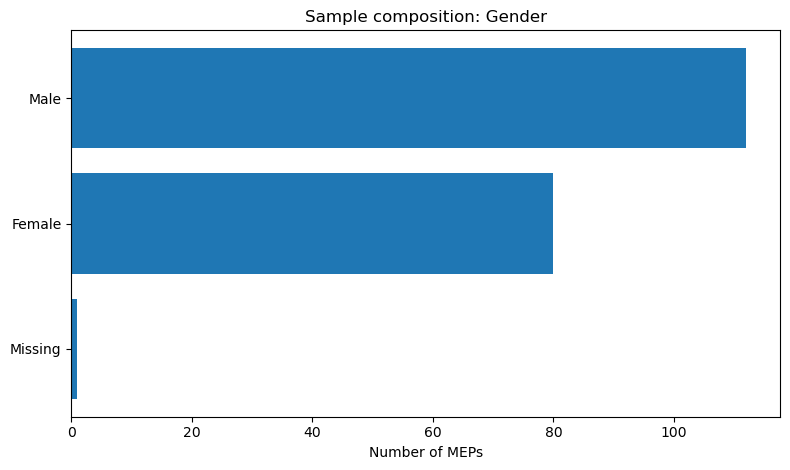

Saved: C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\7 Final Analysis\outputs\figures\desc_sample_composition_gender_clean.png


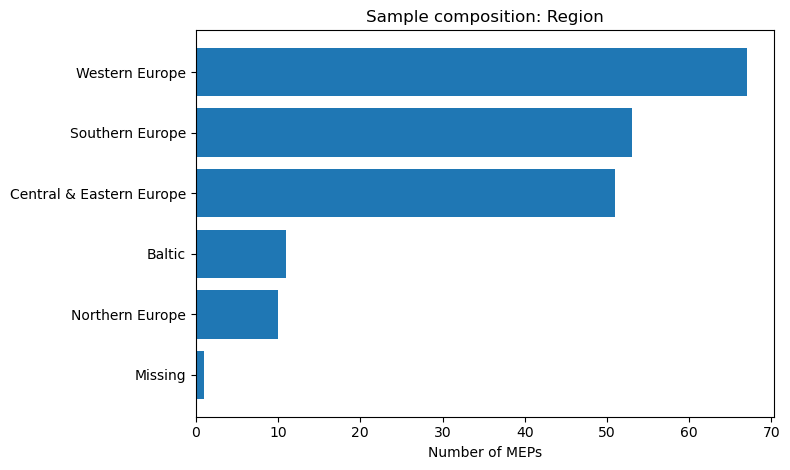

Saved: C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\7 Final Analysis\outputs\figures\desc_sample_composition_region_clean.png


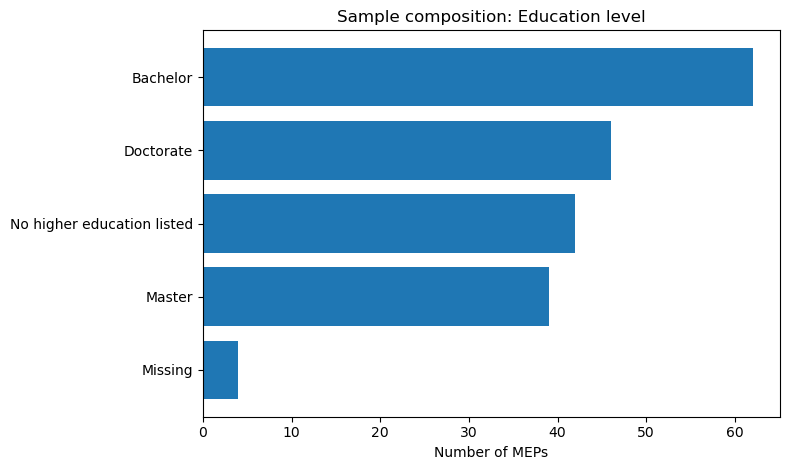

Saved: C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\7 Final Analysis\outputs\figures\desc_sample_composition_education_level_clean.png


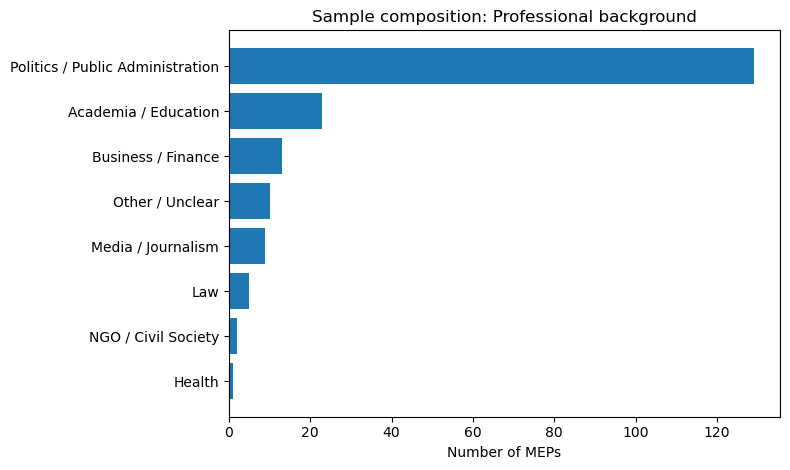

Saved: C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\7 Final Analysis\outputs\figures\desc_sample_composition_professional_background_clean.png


In [ ]:
# ============================================================
# Descriptive figure: sample composition
# ============================================================

if "TABLES_DIR" in globals():
    FIG_DIR = Path(TABLES_DIR).parent / "figures"
else:
    FIG_DIR = Path.cwd()

FIG_DIR.mkdir(parents=True, exist_ok=True)

df_plot = cleaned_df.copy()

composition_vars = [
    ("gender_clean", "Gender"),
    ("region_clean", "Region"),
    ("education_level_clean", "Education level"),
    ("professional_background_clean", "Professional background"),
]

for var, title in composition_vars:
    if var not in df_plot.columns:
        continue

    counts = (
        df_plot[var]
        .astype(str)
        .replace("nan", "Missing")
        .value_counts()
        .head(8)
        .sort_values(ascending=True)
    )

    plt.figure(figsize=(8, 4.8))

    y_pos = np.arange(len(counts))

    plt.barh(y_pos, counts.values)
    plt.yticks(y_pos, counts.index)
    plt.xlabel("Number of MEPs")
    plt.ylabel("")
    plt.title(f"Sample composition: {title}")

    plt.tight_layout()

    out_path = FIG_DIR / f"desc_sample_composition_{var}.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", out_path)

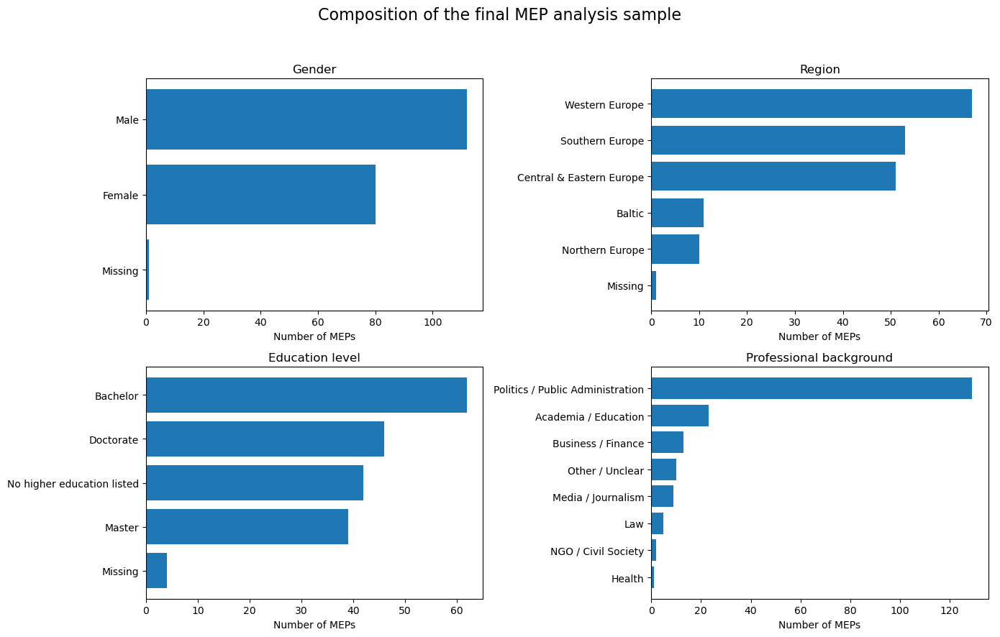

Saved: C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\7 Final Analysis\outputs\figures\desc_sample_composition_2x2.png


In [ ]:
# ============================================================
# Combined 2x2 sample composition figure
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

if "TABLES_DIR" in globals():
    FIG_DIR = Path(TABLES_DIR).parent / "figures"
else:
    FIG_DIR = Path.cwd()

FIG_DIR.mkdir(parents=True, exist_ok=True)

df_plot = cleaned_df.copy()

composition_vars = [
    ("gender_clean", "Gender"),
    ("region_clean", "Region"),
    ("education_level_clean", "Education level"),
    ("professional_background_clean", "Professional background"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, (var, title) in zip(axes, composition_vars):

    if var not in df_plot.columns:
        ax.axis("off")
        continue

    counts = (
        df_plot[var]
        .astype(str)
        .replace("nan", "Missing")
        .value_counts()
        .head(8)
        .sort_values(ascending=True)
    )

    y_pos = np.arange(len(counts))

    ax.barh(y_pos, counts.values)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(counts.index)
    ax.set_xlabel("Number of MEPs")
    ax.set_title(title)

# Make layout cleaner
fig.suptitle("Composition of the final MEP analysis sample", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])

out_path = FIG_DIR / "desc_sample_composition_2x2.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

In [ ]:
# ============================================================
# Restore / identify dominant topic column in cleaned_df
# ============================================================

print("\n" + "=" * 100)
print("CHECK / RESTORE DOMINANT TOPIC COLUMN")
print("=" * 100)

possible_topic_cols = [
    "dominant_topic_cluster",
    "dominant_cluster",
    "dominant_topic",
    "assigned_cluster",
    "topic_cluster",
    "topic_cluster_clean",
    "lda_cluster",
    "cluster",
]

print("\nTopic-like columns in cleaned_df:")
print([c for c in cleaned_df.columns if "topic" in c.lower() or "cluster" in c.lower()])

if "analysis_df" in globals():
    print("\nTopic-like columns in analysis_df:")
    print([c for c in analysis_df.columns if "topic" in c.lower() or "cluster" in c.lower()])

# ------------------------------------------------------------
# Find topic column
# ------------------------------------------------------------

topic_source_col = None

for c in possible_topic_cols:
    if c in cleaned_df.columns:
        topic_source_col = c
        print(f"\nUsing existing topic column in cleaned_df: {topic_source_col}")
        break

if topic_source_col is None and "analysis_df" in globals():

    for c in possible_topic_cols:
        if c in analysis_df.columns:
            topic_source_col = c
            print(f"\nFound topic column in analysis_df: {topic_source_col}")

            if "mep_name_clean" not in cleaned_df.columns or "mep_name_clean" not in analysis_df.columns:
                raise ValueError("Cannot merge topic column because 'mep_name_clean' is missing.")

            cleaned_df = cleaned_df.merge(
                analysis_df[["mep_name_clean", topic_source_col]],
                on="mep_name_clean",
                how="left",
                validate="one_to_one"
            )

            print(f"Merged {topic_source_col} into cleaned_df.")
            break

if topic_source_col is None:
    raise ValueError(
        "Could not find a dominant topic/cluster column in cleaned_df or analysis_df. "
        "Check the printed topic-like column lists above."
    )

# ------------------------------------------------------------
# Standardise name used by plotting block
# ------------------------------------------------------------

if topic_source_col != "dominant_topic_cluster":
    cleaned_df["dominant_topic_cluster"] = cleaned_df[topic_source_col]

print("\nFinal dominant_topic_cluster value counts:")
print(cleaned_df["dominant_topic_cluster"].value_counts(dropna=False).head(30))

print("\ncleaned_df shape:", cleaned_df.shape)


CHECK / RESTORE DOMINANT TOPIC COLUMN

Topic-like columns in cleaned_df:
['dominant_topic', 'dominant_cluster_score']

Topic-like columns in analysis_df:
['dominant_cluster', 'dominant_cluster_score', 'dominant_cluster_cached', 'dominant_topic', 'dominant_cluster_score_numeric']

Using existing topic column in cleaned_df: dominant_topic

Final dominant_topic_cluster value counts:
dominant_topic_cluster
Other                                                   71
Ageing & Pensions                                       43
Regional Depopulation & Territorial Cohesion            16
Migration & Population Change                           12
Borderline: Regional development policy                 12
Fertility, Families & Gender                             8
Health & Care Services                                   7
Youth & Future Generations                               6
Population Growth & Sustainability                       5
Borderline: Labour market and social policy              3
Hou


TOPIC-BY-CATEGORY MEAN POLARISATION FIGURE
Using topic column: dominant_topic_cluster

Mean polarisation by age group x topic:


dominant_topic_cluster,Ageing & Pensions,"Fertility, Families & Gender",Migration & Population Change,Youth & Future Generations,Health & Care Services,Regional Depopulation & Territorial Cohesion,Housing & Living Conditions,Population Growth & Sustainability,Borderline: Regional development policy,Borderline: Economic governance and employment,Borderline: Labour market and social policy,Borderline: Island regions and cohesion,Borderline: Youth / demographic future (weak signal)
age_group,,,,,,,,,,,,,
Under 45,3.68,1.20,5.24,2.50,1.75,2.20,1.20,5.30,1.47,NaN,NaN,NaN,4.25
45-54,2.61,1.48,5.00,2.05,1.23,0.78,5.85,NaN,6.50,NaN,1.00,NaN,NaN
55-64,2.59,1.07,1.67,NaN,2.50,2.25,NaN,0.87,2.60,4.2,4.85,NaN,NaN
65+,1.39,NaN,3.25,NaN,2.00,1.20,NaN,NaN,1.50,3.0,NaN,0.85,1.20



N by age group x topic:


dominant_topic_cluster,Ageing & Pensions,"Fertility, Families & Gender",Migration & Population Change,Youth & Future Generations,Health & Care Services,Regional Depopulation & Territorial Cohesion,Housing & Living Conditions,Population Growth & Sustainability,Borderline: Regional development policy,Borderline: Economic governance and employment,Borderline: Labour market and social policy,Borderline: Island regions and cohesion,Borderline: Youth / demographic future (weak signal)
age_group,,,,,,,,,,,,,
Under 45,4,1,5,1,2,8,1,1,3,0,0,0,2
45-54,12,4,2,4,3,5,2,0,1,0,1,0,0
55-64,14,3,3,0,1,2,0,3,4,1,2,0,0
65+,10,0,2,0,1,1,0,0,3,1,0,2,1



Mean polarisation by professional background x topic:


dominant_topic_cluster,Ageing & Pensions,"Fertility, Families & Gender",Migration & Population Change,Youth & Future Generations,Health & Care Services,Regional Depopulation & Territorial Cohesion,Housing & Living Conditions,Population Growth & Sustainability,Borderline: Regional development policy,Borderline: Economic governance and employment,Borderline: Labour market and social policy,Borderline: Island regions and cohesion,Borderline: Youth / demographic future (weak signal)
professional_background_clean,,,,,,,,,,,,,
Academia / Education,2.42,1.10,NaN,6.50,NaN,1.85,1.2,5.3,1.75,NaN,1.20,0.2,NaN
Business / Finance,0.93,NaN,1.50,NaN,NaN,NaN,2.5,1.2,6.50,NaN,NaN,NaN,1.2
Politics / Public Administration,2.34,1.35,3.84,2.14,1.84,1.60,9.2,0.2,1.87,3.6,4.75,1.5,7.0



N by professional background x topic:


dominant_topic_cluster,Ageing & Pensions,"Fertility, Families & Gender",Migration & Population Change,Youth & Future Generations,Health & Care Services,Regional Depopulation & Territorial Cohesion,Housing & Living Conditions,Population Growth & Sustainability,Borderline: Regional development policy,Borderline: Economic governance and employment,Borderline: Labour market and social policy,Borderline: Island regions and cohesion,Borderline: Youth / demographic future (weak signal)
professional_background_clean,,,,,,,,,,,,,
Academia / Education,4,2,0,1,0,2,1,1,2,0,1,1,0
Business / Finance,6,0,1,0,0,0,1,2,1,0,0,0,1
Politics / Public Administration,26,6,8,5,5,11,1,1,9,2,2,1,1



Mean polarisation by region x topic:


dominant_topic_cluster,Ageing & Pensions,"Fertility, Families & Gender",Migration & Population Change,Youth & Future Generations,Health & Care Services,Regional Depopulation & Territorial Cohesion,Housing & Living Conditions,Population Growth & Sustainability,Borderline: Regional development policy,Borderline: Economic governance and employment,Borderline: Labour market and social policy,Borderline: Island regions and cohesion,Borderline: Youth / demographic future (weak signal)
region_clean,,,,,,,,,,,,,
Baltic,1.20,NaN,NaN,NaN,1.00,1.60,NaN,1.2,1.00,NaN,NaN,NaN,NaN
Central & Eastern Europe,2.56,1.23,6.50,2.05,1.75,1.38,9.2,NaN,1.40,NaN,4.85,NaN,NaN
Southern Europe,3.77,1.40,2.60,4.50,NaN,2.35,2.5,0.7,2.67,NaN,1.00,0.85,3.23
Western Europe,2.29,1.20,3.63,NaN,1.57,1.00,1.2,5.3,4.20,3.6,NaN,NaN,NaN



N by region x topic:


dominant_topic_cluster,Ageing & Pensions,"Fertility, Families & Gender",Migration & Population Change,Youth & Future Generations,Health & Care Services,Regional Depopulation & Territorial Cohesion,Housing & Living Conditions,Population Growth & Sustainability,Borderline: Regional development policy,Borderline: Economic governance and employment,Borderline: Labour market and social policy,Borderline: Island regions and cohesion,Borderline: Youth / demographic future (weak signal)
region_clean,,,,,,,,,,,,,
Baltic,1,0,0,0,1,2,0,1,1,0,0,0,0
Central & Eastern Europe,13,3,1,4,2,5,1,0,4,0,2,0,0
Southern Europe,7,3,4,2,0,6,1,2,6,0,1,2,3
Western Europe,19,2,6,0,3,3,1,1,1,2,0,0,0



Mean polarisation by migration background x topic:


dominant_topic_cluster,Ageing & Pensions,"Fertility, Families & Gender",Migration & Population Change,Youth & Future Generations,Health & Care Services,Regional Depopulation & Territorial Cohesion,Housing & Living Conditions,Population Growth & Sustainability,Borderline: Regional development policy,Borderline: Economic governance and employment,Borderline: Labour market and social policy,Borderline: Island regions and cohesion,Borderline: Youth / demographic future (weak signal)
migration_background_group,,,,,,,,,,,,,
No migration background,2.19,1.29,4.30,2.87,1.67,1.73,4.3,2.23,2.21,3.6,3.57,0.85,3.23
Migration background,5.60,NaN,2.35,NaN,NaN,1.20,NaN,1.20,2.50,NaN,NaN,NaN,NaN



N by migration background x topic:


dominant_topic_cluster,Ageing & Pensions,"Fertility, Families & Gender",Migration & Population Change,Youth & Future Generations,Health & Care Services,Regional Depopulation & Territorial Cohesion,Housing & Living Conditions,Population Growth & Sustainability,Borderline: Regional development policy,Borderline: Economic governance and employment,Borderline: Labour market and social policy,Borderline: Island regions and cohesion,Borderline: Youth / demographic future (weak signal)
migration_background_group,,,,,,,,,,,,,
No migration background,39,8,10,6,7,15,3,3,11,2,3,2,3
Migration background,4,0,2,0,0,1,0,1,1,0,0,0,0


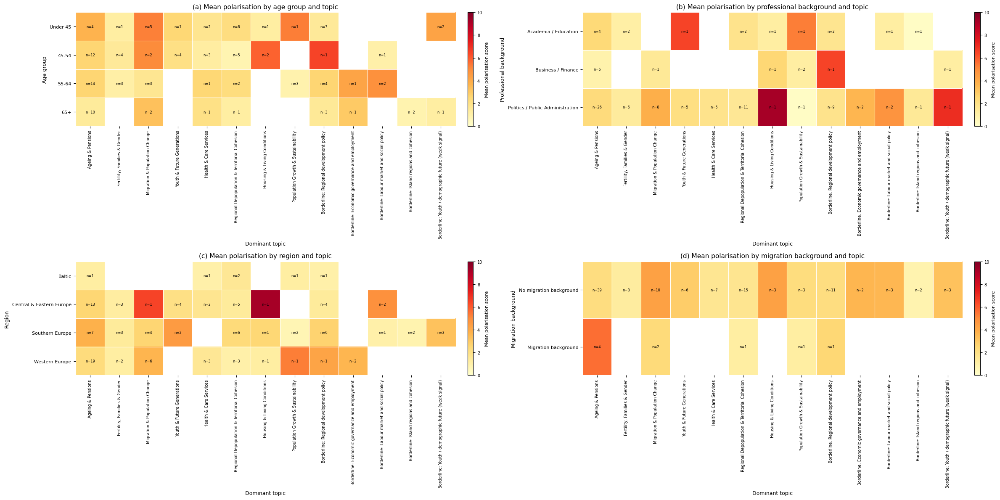


Saved combined figure:
C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\7 Final Analysis\outputs\figures\desc_topic_composition_2x2.png


In [94]:
# ============================================================
# Combined topic-by-category mean polarisation figure:
# age group, professional background, region, migration background
# Cell value = mean polarisation score
# Output: desc_topic_composition_2x2.png
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

print("\n" + "=" * 100)
print("TOPIC-BY-CATEGORY MEAN POLARISATION FIGURE")
print("=" * 100)

# ------------------------------------------------------------
# 0. Output folder
# ------------------------------------------------------------

if "TABLES_DIR" in globals():
    FIG_DIR = Path(TABLES_DIR).parent / "figures"
elif "FIGURES_DIR" in globals():
    FIG_DIR = Path(FIGURES_DIR)
else:
    FIG_DIR = Path.cwd()

FIG_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 1. Start from cleaned_df
# ------------------------------------------------------------

plot_df = cleaned_df.copy()

if "polarisation_score" not in plot_df.columns:
    raise ValueError("cleaned_df must contain 'polarisation_score'.")

plot_df["polarisation_score"] = pd.to_numeric(
    plot_df["polarisation_score"],
    errors="coerce"
)

# ------------------------------------------------------------
# 2. Restore / identify dominant topic column if needed
# ------------------------------------------------------------

possible_topic_cols = [
    "dominant_topic_cluster",
    "dominant_cluster",
    "dominant_topic",
    "assigned_cluster",
    "topic_cluster",
    "topic_cluster_clean",
    "lda_cluster",
    "cluster",
]

topic_col = None

for c in possible_topic_cols:
    if c in plot_df.columns:
        topic_col = c
        break

if topic_col is None and "analysis_df" in globals():
    for c in possible_topic_cols:
        if c in analysis_df.columns:
            if "mep_name_clean" not in plot_df.columns or "mep_name_clean" not in analysis_df.columns:
                raise ValueError("Cannot merge topic column because 'mep_name_clean' is missing.")

            plot_df = plot_df.merge(
                analysis_df[["mep_name_clean", c]],
                on="mep_name_clean",
                how="left",
                validate="one_to_one"
            )
            topic_col = c
            break

if topic_col is None:
    raise ValueError(
        "Could not find a dominant topic/cluster column in cleaned_df or analysis_df."
    )

print("Using topic column:", topic_col)

# ------------------------------------------------------------
# 3. Find age column
# ------------------------------------------------------------

possible_age_cols = [
    "age_2020",
    "age",
    "age_clean",
    "age_at_2020",
]

age_col = None

for c in possible_age_cols:
    if c in plot_df.columns:
        age_col = c
        break

if age_col is None:
    raise ValueError(f"Could not find an age column. Expected one of: {possible_age_cols}")

plot_df[age_col] = pd.to_numeric(plot_df[age_col], errors="coerce")

plot_df["age_group"] = pd.cut(
    plot_df[age_col],
    bins=[0, 44, 54, 64, 120],
    labels=["Under 45", "45-54", "55-64", "65+"],
    right=True
)

# ------------------------------------------------------------
# 4. Find migration / immigration background column
# ------------------------------------------------------------

possible_migration_cols = [
    "migration_background_flag",
    "migration_background_clean",
    "migration_background_bucket",
    "immigration_background",
    "immigration_background_clean",
    "immigrant_background",
    "immigrant_status_clean",
]

migration_col = None

for c in possible_migration_cols:
    if c in plot_df.columns:
        migration_col = c
        break

if migration_col is None and "analysis_df" in globals():
    for c in possible_migration_cols:
        if c in analysis_df.columns:
            if "mep_name_clean" not in plot_df.columns or "mep_name_clean" not in analysis_df.columns:
                raise ValueError("Cannot merge migration column because 'mep_name_clean' is missing.")

            plot_df = plot_df.merge(
                analysis_df[["mep_name_clean", c]],
                on="mep_name_clean",
                how="left",
                validate="one_to_one"
            )
            migration_col = c
            break

if migration_col is None:
    raise ValueError(
        "Could not find a migration/immigration background column. "
        "Check columns with: [c for c in cleaned_df.columns if 'mig' in c.lower()]"
    )

def clean_migration_label(x):
    if pd.isna(x):
        return "Unknown"

    s = str(x).strip().lower()

    if s in {"true", "1", "1.0", "yes", "y"}:
        return "Migration background"

    if s in {"false", "0", "0.0", "no", "n"}:
        return "No migration background"

    if "no" in s and "migration" in s:
        return "No migration background"

    if "none" in s:
        return "No migration background"

    if "migration" in s or "immigrant" in s or "foreign" in s:
        return "Migration background"

    if s in {"unknown", "missing", "nan", ""}:
        return "Unknown"

    return str(x).strip()

plot_df["migration_background_group"] = plot_df[migration_col].map(clean_migration_label)

# ------------------------------------------------------------
# 5. Required grouping columns
# ------------------------------------------------------------

required_cols = [
    "professional_background_clean",
    "region_clean",
]

missing_cols = [c for c in required_cols if c not in plot_df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns in cleaned_df: {missing_cols}")

# ------------------------------------------------------------
# 6. Clean topic labels
# ------------------------------------------------------------

topic_label_map = {
    "Ageing & Pensions": "Ageing & Pensions",
    "Fertility, Families & Gender": "Fertility, Families & Gender",
    "Migration & Population Change": "Migration & Population Change",
    "Youth & Future Generations": "Youth & Future Generations",
    "Health & Care Services": "Health & Care Services",
    "Regional Depopulation & Territorial Cohesion": "Regional Depopulation & Territorial Cohesion",
    "Housing & Living Conditions": "Housing & Living Conditions",
    "Population Growth & Sustainability": "Population Growth & Sustainability",
    "Borderline: Regional development policy": "Borderline: Regional development policy",
    "Borderline: Regional Development Policy": "Borderline: Regional development policy",
    "Borderline: Economic governance and employment": "Borderline: Economic governance and employment",
    "Borderline: Labour market and social policy": "Borderline: Labour market and social policy",
    "Borderline: Island regions and cohesion": "Borderline: Island regions and cohesion",
    "Borderline: Youth / demographic future (weak signal)": "Borderline: Youth / demographic future (weak signal)",
    "Other": "Other",
}

plot_df[topic_col] = (
    plot_df[topic_col]
    .replace(topic_label_map)
    .fillna("Missing")
)

plot_df = plot_df[
    plot_df["polarisation_score"].notna()
    & plot_df[topic_col].notna()
    & (plot_df[topic_col] != "Missing")
].copy()

# ------------------------------------------------------------
# 7. Orders
# ------------------------------------------------------------

topic_order_all = [
    "Ageing & Pensions",
    "Fertility, Families & Gender",
    "Migration & Population Change",
    "Youth & Future Generations",
    "Health & Care Services",
    "Regional Depopulation & Territorial Cohesion",
    "Housing & Living Conditions",
    "Population Growth & Sustainability",
    "Borderline: Regional development policy",
    "Borderline: Economic governance and employment",
    "Borderline: Labour market and social policy",
    "Borderline: Island regions and cohesion",
    "Borderline: Youth / demographic future (weak signal)",
]

age_order = [
    "Under 45",
    "45-54",
    "55-64",
    "65+",
]

prof_order = [
    "Academia / Education",
    "Business / Finance",
    "Politics / Public Administration",
]

region_order = [
    "Baltic",
    "Central & Eastern Europe",
    "Southern Europe",
    "Western Europe",
]

migration_order = [
    "No migration background",
    "Migration background",
]

# Remove unknown migration background from migration panel only
migration_plot_df = plot_df[
    plot_df["migration_background_group"].isin(migration_order)
].copy()

# ------------------------------------------------------------
# 8. Helper: mean polarisation and N by group x topic
# ------------------------------------------------------------

def mean_pol_topic_table(df, group_col, topic_col, group_order=None, topic_order=None):
    temp = df[[group_col, topic_col, "polarisation_score"]].dropna().copy()

    mean_table = pd.pivot_table(
        temp,
        index=group_col,
        columns=topic_col,
        values="polarisation_score",
        aggfunc="mean",
        observed=True,
    )

    n_table = pd.pivot_table(
        temp,
        index=group_col,
        columns=topic_col,
        values="polarisation_score",
        aggfunc="size",
        observed=True,
    )

    if group_order is not None:
        mean_table = mean_table.reindex(group_order)
        n_table = n_table.reindex(group_order)

    if topic_order is not None:
        mean_table = mean_table.reindex(columns=topic_order)
        n_table = n_table.reindex(columns=topic_order)

    n_table = n_table.fillna(0).astype(int)

    return mean_table, n_table


age_pol, age_n = mean_pol_topic_table(
    plot_df,
    group_col="age_group",
    topic_col=topic_col,
    group_order=age_order,
    topic_order=topic_order_all,
)

prof_pol, prof_n = mean_pol_topic_table(
    plot_df,
    group_col="professional_background_clean",
    topic_col=topic_col,
    group_order=prof_order,
    topic_order=topic_order_all,
)

region_pol, region_n = mean_pol_topic_table(
    plot_df,
    group_col="region_clean",
    topic_col=topic_col,
    group_order=region_order,
    topic_order=topic_order_all,
)

migration_pol, migration_n = mean_pol_topic_table(
    migration_plot_df,
    group_col="migration_background_group",
    topic_col=topic_col,
    group_order=migration_order,
    topic_order=topic_order_all,
)

print("\nMean polarisation by age group x topic:")
display(age_pol.round(2))
print("\nN by age group x topic:")
display(age_n)

print("\nMean polarisation by professional background x topic:")
display(prof_pol.round(2))
print("\nN by professional background x topic:")
display(prof_n)

print("\nMean polarisation by region x topic:")
display(region_pol.round(2))
print("\nN by region x topic:")
display(region_n)

print("\nMean polarisation by migration background x topic:")
display(migration_pol.round(2))
print("\nN by migration background x topic:")
display(migration_n)

# ------------------------------------------------------------
# 9. Save source tables
# ------------------------------------------------------------

age_pol.to_csv(FIG_DIR / "desc_mean_pol_by_age_group_topic_table.csv")
prof_pol.to_csv(FIG_DIR / "desc_mean_pol_by_prof_bg_topic_table.csv")
region_pol.to_csv(FIG_DIR / "desc_mean_pol_by_region_topic_table.csv")
migration_pol.to_csv(FIG_DIR / "desc_mean_pol_by_migration_bg_topic_table.csv")

age_n.to_csv(FIG_DIR / "desc_n_by_age_group_topic_table.csv")
prof_n.to_csv(FIG_DIR / "desc_n_by_prof_bg_topic_table.csv")
region_n.to_csv(FIG_DIR / "desc_n_by_region_topic_table.csv")
migration_n.to_csv(FIG_DIR / "desc_n_by_migration_bg_topic_table.csv")

# ------------------------------------------------------------
# 10. Plot helper with N annotation
# ------------------------------------------------------------

def plot_pol_heatmap(ax, mean_data, n_data, title, xlabel, ylabel):
    masked = np.ma.masked_invalid(mean_data.values.astype(float))

    im = ax.imshow(
        masked,
        aspect="auto",
        vmin=0,
        vmax=10,
        cmap="YlOrRd"
    )

    ax.set_title(title, fontsize=11)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)

    ax.set_xticks(np.arange(mean_data.shape[1]))
    ax.set_xticklabels(
        mean_data.columns,
        rotation=90,
        ha="center",
        fontsize=7
    )

    ax.set_yticks(np.arange(mean_data.shape[0]))
    ax.set_yticklabels(mean_data.index, fontsize=8)

    # Add N inside each non-empty square
    for i in range(mean_data.shape[0]):
        for j in range(mean_data.shape[1]):
            n_val = int(n_data.iloc[i, j]) if not pd.isna(n_data.iloc[i, j]) else 0
            mean_val = mean_data.iloc[i, j]

            if n_val > 0 and not pd.isna(mean_val):
                ax.text(
                    j,
                    i,
                    f"n={n_val}",
                    ha="center",
                    va="center",
                    fontsize=6,
                    color="black"
                )

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_xticks(np.arange(mean_data.shape[1] + 1) - 0.5, minor=True)
    ax.set_yticks(np.arange(mean_data.shape[0] + 1) - 0.5, minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=0.8)
    ax.tick_params(which="minor", bottom=False, left=False)

    cbar = plt.colorbar(im, ax=ax, fraction=0.035, pad=0.03)
    cbar.set_label("Mean polarisation score", fontsize=8)
    cbar.ax.tick_params(labelsize=7)

    return im

# ------------------------------------------------------------
# 11. Combined 2x2 figure
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    2,
    figsize=(24, 12),
    gridspec_kw={
        "width_ratios": [1, 1],
        "height_ratios": [1, 1],
    }
)

plot_pol_heatmap(
    ax=axes[0, 0],
    mean_data=age_pol,
    n_data=age_n,
    title="(a) Mean polarisation by age group and topic",
    xlabel="Dominant topic",
    ylabel="Age group",
)

plot_pol_heatmap(
    ax=axes[0, 1],
    mean_data=prof_pol,
    n_data=prof_n,
    title="(b) Mean polarisation by professional background and topic",
    xlabel="Dominant topic",
    ylabel="Professional background",
)

plot_pol_heatmap(
    ax=axes[1, 0],
    mean_data=region_pol,
    n_data=region_n,
    title="(c) Mean polarisation by region and topic",
    xlabel="Dominant topic",
    ylabel="Region",
)

plot_pol_heatmap(
    ax=axes[1, 1],
    mean_data=migration_pol,
    n_data=migration_n,
    title="(d) Mean polarisation by migration background and topic",
    xlabel="Dominant topic",
    ylabel="Migration background",
)
plt.tight_layout()

fig_path = FIG_DIR / "desc_topic_composition_2x2.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("\nSaved combined figure:")
print(fig_path)


OVERALL DOMINANT TOPIC DISTRIBUTION
Using topic column: dominant_topic_cluster

Overall dominant topic distribution:


,dominant_topic,n,share
0,Other,71,0.368
1,Ageing & Pensions,43,0.223
2,Regional Depopulation & Territorial Cohesion,16,0.083
3,Migration & Population Change,12,0.062
4,Borderline: Regional development policy,12,0.062
5,"Fertility, Families & Gender",8,0.041
6,Health & Care Services,7,0.036
7,Youth & Future Generations,6,0.031
8,Population Growth & Sustainability,5,0.026
10,Housing & Living Conditions,3,0.016


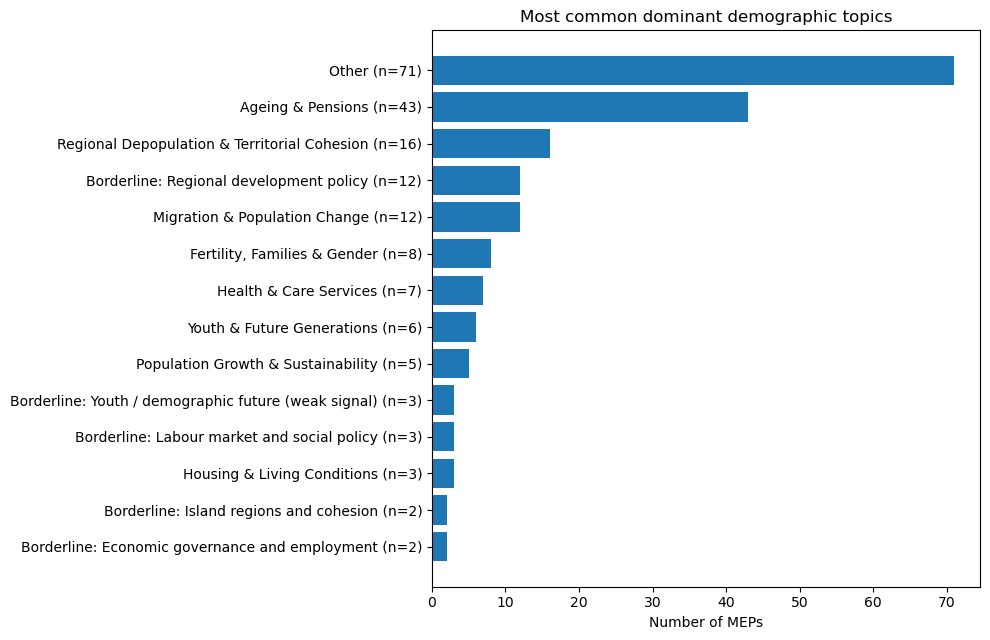


Saved:
C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\7 Final Analysis\outputs\figures\desc_overall_topic_distribution.png
C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\7 Final Analysis\outputs\figures\desc_overall_topic_distribution_table.csv


In [ ]:
# ============================================================
# Figure: overall dominant topic distribution
# Output: desc_overall_topic_distribution.png
# ============================================================

print("\n" + "=" * 100)
print("OVERALL DOMINANT TOPIC DISTRIBUTION")
print("=" * 100)

# ------------------------------------------------------------
# 0. Output folder
# ------------------------------------------------------------

if "TABLES_DIR" in globals():
    FIG_DIR = Path(TABLES_DIR).parent / "figures"
elif "FIGURES_DIR" in globals():
    FIG_DIR = Path(FIGURES_DIR)
else:
    FIG_DIR = Path.cwd()

FIG_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 1. Start from cleaned_df
# ------------------------------------------------------------

plot_df = cleaned_df.copy()

# ------------------------------------------------------------
# 2. Restore / identify dominant topic column if needed
# ------------------------------------------------------------

possible_topic_cols = [
    "dominant_topic_cluster",
    "dominant_cluster",
    "dominant_topic",
    "assigned_cluster",
    "topic_cluster",
    "topic_cluster_clean",
    "lda_cluster",
    "cluster",
]

topic_col = None

for c in possible_topic_cols:
    if c in plot_df.columns:
        topic_col = c
        break

if topic_col is None and "analysis_df" in globals():
    for c in possible_topic_cols:
        if c in analysis_df.columns:
            if "mep_name_clean" not in plot_df.columns or "mep_name_clean" not in analysis_df.columns:
                raise ValueError("Cannot merge topic column because 'mep_name_clean' is missing.")

            plot_df = plot_df.merge(
                analysis_df[["mep_name_clean", c]],
                on="mep_name_clean",
                how="left",
                validate="one_to_one"
            )
            topic_col = c
            break

if topic_col is None:
    raise ValueError(
        "Could not find a dominant topic/cluster column in cleaned_df or analysis_df."
    )

print("Using topic column:", topic_col)

# ------------------------------------------------------------
# 3. Clean topic labels
# ------------------------------------------------------------

topic_label_map = {
    "Ageing & Pensions": "Ageing & Pensions",
    "Fertility, Families & Gender": "Fertility, Families & Gender",
    "Migration & Population Change": "Migration & Population Change",
    "Youth & Future Generations": "Youth & Future Generations",
    "Health & Care Services": "Health & Care Services",
    "Regional Depopulation & Territorial Cohesion": "Regional Depopulation & Territorial Cohesion",
    "Housing & Living Conditions": "Housing & Living Conditions",
    "Population Growth & Sustainability": "Population Growth & Sustainability",
    "Borderline: Regional development policy": "Borderline: Regional development policy",
    "Borderline: Regional Development Policy": "Borderline: Regional development policy",
    "Borderline: Economic governance and employment": "Borderline: Economic governance and employment",
    "Borderline: Labour market and social policy": "Borderline: Labour market and social policy",
    "Borderline: Island regions and cohesion": "Borderline: Island regions and cohesion",
    "Borderline: Youth / demographic future (weak signal)": "Borderline: Youth / demographic future (weak signal)",
    "Other": "Other",
}

plot_df[topic_col] = (
    plot_df[topic_col]
    .replace(topic_label_map)
    .fillna("Missing")
)

# Optional: remove missing topic rows
plot_df = plot_df[plot_df[topic_col] != "Missing"].copy()

# ------------------------------------------------------------
# 4. Count topics
# ------------------------------------------------------------

topic_summary = (
    plot_df[topic_col]
    .value_counts(dropna=False)
    .rename_axis("dominant_topic")
    .reset_index(name="n")
)

topic_summary["share"] = topic_summary["n"] / topic_summary["n"].sum()

topic_summary = topic_summary.sort_values("n", ascending=True)

print("\nOverall dominant topic distribution:")
display(topic_summary.sort_values("n", ascending=False).round(3))

topic_summary.to_csv(
    FIG_DIR / "desc_overall_topic_distribution_table.csv",
    index=False
)

# ------------------------------------------------------------
# 5. Plot
# ------------------------------------------------------------

plt.figure(figsize=(10, 6.5))

labels = (
    topic_summary["dominant_topic"].astype(str)
    + " (n="
    + topic_summary["n"].astype(str)
    + ")"
)

plt.barh(labels, topic_summary["n"])
plt.xlabel("Number of MEPs")
plt.ylabel("")
plt.title("Most common dominant demographic topics")

plt.tight_layout()

fig_path = FIG_DIR / "desc_overall_topic_distribution.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("\nSaved:")
print(fig_path)
print(FIG_DIR / "desc_overall_topic_distribution_table.csv")


EP GROUP POLARISATION RANKING

EP group polarisation summary:


,ep_group_clean,n,mean_polarisation,median_polarisation,sd_polarisation
2,EPP,59,2.054,1.50,1.531
7,S&D,39,2.156,1.20,1.676
6,Renew/ALDE,14,2.229,1.75,1.611
3,Greens/EFA,12,2.608,1.60,2.565
9,Unknown,33,3.027,2.00,2.618
0,ECR,15,3.713,2.50,2.922
8,The Left/GUE-NGL,5,4.700,4.00,2.752
4,ID/ENF/PfE,12,5.225,5.00,3.166


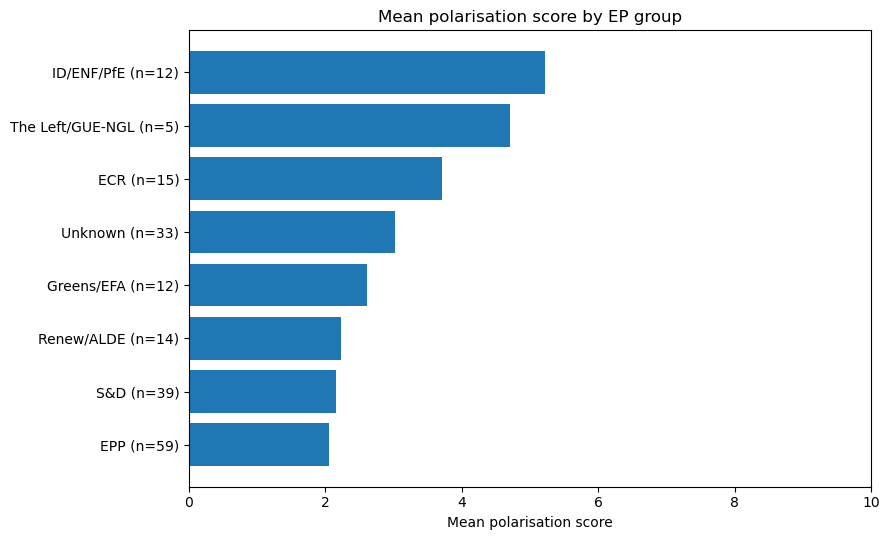


Saved:
- C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\7 Final Analysis\outputs\figures\desc_ep_grp_pol_rank.png
- C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\7 Final Analysis\outputs\figures\desc_ep_grp_pol_rank_summary.csv


In [ ]:
# ============================================================
# Figure: mean polarisation score by EP group
# Output: desc_ep_grp_pol_rank.png
# ============================================================

print("\n" + "=" * 100)
print("EP GROUP POLARISATION RANKING")
print("=" * 100)

# ------------------------------------------------------------
# 0. Output folder
# ------------------------------------------------------------

if "TABLES_DIR" in globals():
    FIG_DIR = Path(TABLES_DIR).parent / "figures"
else:
    FIG_DIR = Path.cwd()

FIG_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 1. Start from cleaned_df
# ------------------------------------------------------------

plot_df = cleaned_df.copy()

if "polarisation_score" not in plot_df.columns:
    raise ValueError("cleaned_df must contain 'polarisation_score'.")

if "ep_group_clean" not in plot_df.columns:
    raise ValueError(
        "cleaned_df does not contain 'ep_group_clean'. "
        "Run the EP-group cleaning/check block first."
    )

plot_df["polarisation_score"] = pd.to_numeric(
    plot_df["polarisation_score"],
    errors="coerce"
)

plot_df["ep_group_clean"] = (
    plot_df["ep_group_clean"]
    .astype("object")
    .where(plot_df["ep_group_clean"].notna(), "Unknown")
    .astype(str)
)

# ------------------------------------------------------------
# 2. Keep valid observations
# ------------------------------------------------------------

plot_df = plot_df[
    plot_df["polarisation_score"].notna()
    & plot_df["ep_group_clean"].notna()
].copy()

# Optional: exclude Unknown from plot
# plot_df = plot_df[plot_df["ep_group_clean"] != "Unknown"].copy()

# ------------------------------------------------------------
# 3. Aggregate by EP group
# ------------------------------------------------------------

ep_group_summary = (
    plot_df
    .groupby("ep_group_clean")
    .agg(
        n=("polarisation_score", "size"),
        mean_polarisation=("polarisation_score", "mean"),
        median_polarisation=("polarisation_score", "median"),
        sd_polarisation=("polarisation_score", "std"),
    )
    .reset_index()
)

# Keep groups with at least 3 observations, same as before
min_n = 3
ep_group_summary = ep_group_summary[
    ep_group_summary["n"] >= min_n
].copy()

ep_group_summary = ep_group_summary.sort_values(
    "mean_polarisation",
    ascending=True
)

print("\nEP group polarisation summary:")
display(ep_group_summary.round(3))

# Save table
ep_group_summary.to_csv(
    FIG_DIR / "desc_ep_grp_pol_rank_summary.csv",
    index=False
)

# ------------------------------------------------------------
# 4. Plot
# ------------------------------------------------------------

plt.figure(figsize=(9, 5.5))

y_pos = np.arange(len(ep_group_summary))

labels = (
    ep_group_summary["ep_group_clean"]
    + " (n="
    + ep_group_summary["n"].astype(str)
    + ")"
)

plt.barh(
    y_pos,
    ep_group_summary["mean_polarisation"]
)

plt.yticks(y_pos, labels)
plt.xlabel("Mean polarisation score")
plt.ylabel("")
plt.title("Mean polarisation score by EP group")

plt.xlim(
    0,
    max(10, ep_group_summary["mean_polarisation"].max() + 0.5)
)

plt.tight_layout()

fig_path = FIG_DIR / "desc_ep_grp_pol_rank.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("\nSaved:")
print("-", fig_path)
print("-", FIG_DIR / "desc_ep_grp_pol_rank_summary.csv")

## Regression analysis

### Regression analysis: drivers of polarisation

In [ ]:
# ============================================================
# Regression analysis: drivers of polarisation
# Dataset: cleaned_df
# ============================================================

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 240)
pd.set_option("display.max_rows", 300)

df = cleaned_df.copy()

print("=" * 100)
print("REGRESSION ANALYSIS: DRIVERS OF POLARISATION")
print("=" * 100)

print("\nInitial cleaned_df shape:", df.shape)

# ============================================================
# 1. Drop unusable variables
# ============================================================

drop_bad = [
    "dominant_cluster_score",   # 100% missing
    "mep_tenure_2020",          # mostly missing
    "tenure_group",             # mostly Unknown
    "demography_expertise_flag" # no variation
]

df = df.drop(columns=[c for c in drop_bad if c in df.columns], errors="ignore")

# ============================================================
# 2. Rename awkward topic columns for regression formulas
# ============================================================

rename_map = {
    "Ageing & Pensions": "topic_ageing_pensions",
    "Borderline: Economic governance and employment": "topic_econ_governance",
    "Borderline: Island regions and cohesion": "topic_island_cohesion",
    "Borderline: Labour market and social policy": "topic_labour_social",
    "Borderline: Regional development policy": "topic_regional_dev",
    "Borderline: Youth / demographic future (weak signal)": "topic_youth_future_weak",
    "Fertility, Families & Gender": "topic_fertility_family_gender",
    "Health & Care Services": "topic_health_care",
    "Housing & Living Conditions": "topic_housing",
    "Migration & Population Change": "topic_migration",
    "Population Growth & Sustainability": "topic_population_growth",
    "Regional Depopulation & Territorial Cohesion": "topic_regional_depopulation",
    "Youth & Future Generations": "topic_youth_future",
    "Other": "topic_other",
}

df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

topic_vars_all = [
    "topic_ageing_pensions",
    "topic_econ_governance",
    "topic_island_cohesion",
    "topic_labour_social",
    "topic_regional_dev",
    "topic_youth_future_weak",
    "topic_fertility_family_gender",
    "topic_health_care",
    "topic_housing",
    "topic_migration",
    "topic_population_growth",
    "topic_regional_depopulation",
    "topic_youth_future",
    "topic_other",
]

topic_vars_all = [c for c in topic_vars_all if c in df.columns]

# Important: topic shares sum to 1, so drop one category as reference.
# We use topic_other as the reference category.
topic_vars_reg = [c for c in topic_vars_all if c != "topic_other"]

# ============================================================
# 3. Ensure numeric variables are numeric
# ============================================================

numeric_vars = [
    "polarisation_score",
    "confidence",
    "us_vs_them",
    "emotional_intensity",
    "moral_absolutism",
    "hostility_to_opponents",
    "n_relevant_speeches",
    "age_2020",
] + topic_vars_all

for col in numeric_vars:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# ============================================================
# 4. Clean categorical variables for regression
# ============================================================

categorical_controls = [
    "gender_clean",
    "region_clean",
    "education_level_clean",
    "education_field_clean",
    "professional_background_clean",
    "prior_political_level_clean",
    "religion_mentioned_flag",
    "parental_status_known",
    "has_children_if_known",
    "migration_background_flag",
    "international_experience_flag",
    "military_background_flag",
    "age_group",
]

categorical_controls = [c for c in categorical_controls if c in df.columns]

for col in categorical_controls:
    df[col] = (
        df[col]
        .astype("object")
        .where(df[col].notna(), "Missing")
        .astype(str)
    )

# Optional: collapse very rare categories to avoid unstable dummy variables
def collapse_rare_categories(data, col, min_count=5):
    counts = data[col].value_counts(dropna=False)
    rare = counts[counts < min_count].index
    data[col] = np.where(data[col].isin(rare), "Other / Rare", data[col])
    return data

for col in categorical_controls:
    df = collapse_rare_categories(df, col, min_count=5)

# ============================================================
# 5. Helper functions
# ============================================================

def run_ols(formula, data, model_name):
    model_data = data.copy()
    model = smf.ols(formula=formula, data=model_data).fit(cov_type="HC3")
    print("\n" + "=" * 100)
    print(model_name)
    print("=" * 100)
    print("Formula:")
    print(formula)
    print("\nN used:", int(model.nobs))
    print(model.summary())
    return model

def make_cat_terms(cols):
    return [f"C({c})" for c in cols if c in df.columns]

# ============================================================
# 6. Regression formulas
# ============================================================

outcome = "polarisation_score"

speech_controls = [
    "n_relevant_speeches",
]

bio_continuous_controls = [
    "age_2020",
]

speech_controls = [c for c in speech_controls if c in df.columns]
bio_continuous_controls = [c for c in bio_continuous_controls if c in df.columns]

topic_terms = topic_vars_reg
speech_terms = speech_controls
bio_cont_terms = bio_continuous_controls
bio_cat_terms = make_cat_terms([
    "gender_clean",
    "region_clean",
    "education_level_clean",
    "professional_background_clean",
    "prior_political_level_clean",
    "migration_background_flag",
    "international_experience_flag",
])

# Model 1: topic shares only
formula_m1 = (
    outcome + " ~ " +
    " + ".join(topic_terms + speech_terms)
)

# Model 2: add basic MEP biography controls
formula_m2 = (
    outcome + " ~ " +
    " + ".join(topic_terms + speech_terms + bio_cont_terms + bio_cat_terms)
)

# Model 3: add country fixed effects
# Only use if country_clean_final exists.
if "country_clean_final" in df.columns:
    df["country_clean_final"] = df["country_clean_final"].astype(str)
    formula_m3 = (
        outcome + " ~ " +
        " + ".join(topic_terms + speech_terms + bio_cont_terms + bio_cat_terms + ["C(country_clean_final)"])
    )
else:
    formula_m3 = None

# ============================================================
# 7. Run baseline regressions
# ============================================================

models = {}

models["M1_topics"] = run_ols(
    formula_m1,
    df,
    "Model 1: Topic-share drivers of polarisation"
)

models["M2_topics_bio"] = run_ols(
    formula_m2,
    df,
    "Model 2: Topic shares + MEP characteristics"
)

if formula_m3 is not None:
    models["M3_country_FE"] = run_ols(
        formula_m3,
        df,
        "Model 3: Topic shares + MEP characteristics + country fixed effects"
    )

# ============================================================
# 8. Compact regression table
# ============================================================

print("\n" + "=" * 100)
print("COMPACT REGRESSION TABLE")
print("=" * 100)

reg_table = summary_col(
    list(models.values()),
    model_names=list(models.keys()),
    stars=True,
    float_format="%0.3f",
    info_dict={
        "N": lambda x: f"{int(x.nobs)}",
        "R2": lambda x: f"{x.rsquared:.3f}",
        "Adj. R2": lambda x: f"{x.rsquared_adj:.3f}",
    }
)

print(reg_table)

# Save text version
with open("regression_table_baseline.txt", "w", encoding="utf-8") as f:
    f.write(str(reg_table))

print("\nSaved:")
print("- regression_table_baseline.txt")

# ============================================================
# 9. Extract coefficients of main topic variables
# ============================================================

coef_rows = []

for model_name, model in models.items():
    params = model.params
    conf = model.conf_int()
    pvals = model.pvalues

    for var in topic_terms + speech_terms + bio_cont_terms:
        if var in params.index:
            coef_rows.append({
                "model": model_name,
                "variable": var,
                "coef": params[var],
                "ci_low": conf.loc[var, 0],
                "ci_high": conf.loc[var, 1],
                "p_value": pvals[var],
                "significant_10pct": pvals[var] < 0.10,
                "significant_5pct": pvals[var] < 0.05,
            })

coef_table = pd.DataFrame(coef_rows)

print("\n" + "=" * 100)
print("MAIN NUMERIC COEFFICIENTS")
print("=" * 100)
print(coef_table.round(4).to_string(index=False))

coef_table.to_csv("regression_main_coefficients.csv", index=False)
print("\nSaved:")
print("- regression_main_coefficients.csv")

REGRESSION ANALYSIS: DRIVERS OF POLARISATION

Initial cleaned_df shape: (193, 43)

Model 1: Topic-share drivers of polarisation
Formula:
polarisation_score ~ topic_ageing_pensions + topic_econ_governance + topic_island_cohesion + topic_labour_social + topic_regional_dev + topic_youth_future_weak + topic_fertility_family_gender + topic_health_care + topic_housing + topic_migration + topic_population_growth + topic_regional_depopulation + topic_youth_future + n_relevant_speeches

N used: 193
                            OLS Regression Results                            
Dep. Variable:     polarisation_score   R-squared:                       0.192
Model:                            OLS   Adj. R-squared:                  0.129
Method:                 Least Squares   F-statistic:                     2.927
Date:                Wed, 15 Jul 2026   Prob (F-statistic):           0.000503
Time:                        16:48:45   Log-Likelihood:                -412.70
No. Observations:              

c:\Users\Gebruiker\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 40, but rank is 35
  warnings.warn('covariance of constraints does not have full '
c:\Users\Gebruiker\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 67, but rank is 62
  warnings.warn('covariance of constraints does not have full '



                                                                     M1_topics M2_topics_bio M3_country_FE
----------------------------------------------------------------------------------------------------------
Intercept                                                            3.805***  6.887***      5.090***     
                                                                     (0.631)   (1.823)       (1.769)      
topic_ageing_pensions                                                -1.165    -2.174**      -2.403**     
                                                                     (0.865)   (0.937)       (1.166)      
topic_econ_governance                                                -0.176    0.264         0.805        
                                                                     (1.082)   (1.045)       (2.151)      
topic_island_cohesion                                                -3.646*** -3.576**      -3.262       
                                    

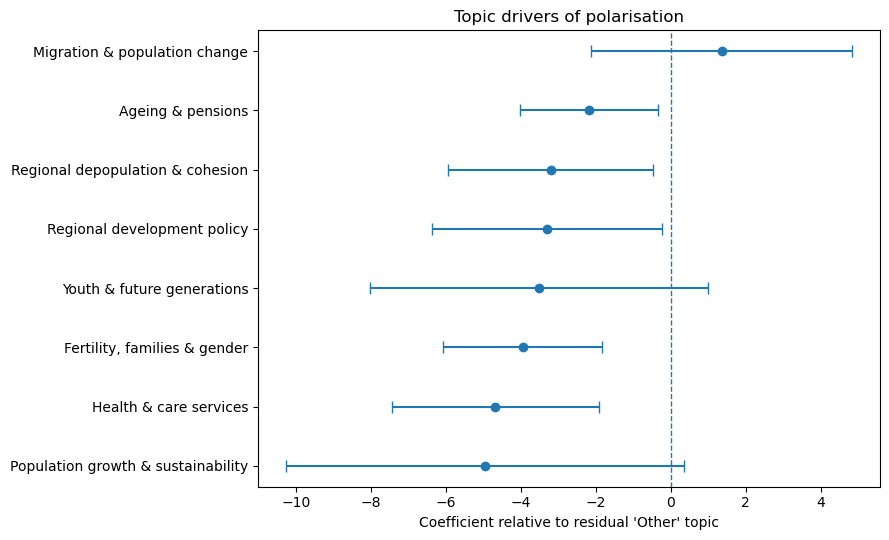

Saved: C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\7 Final Analysis\outputs\figures\topic_driver_coefficients.png


,variable,label,coef,ci_low,ci_high,p_value
5,topic_population_growth,Population growth & sustainability,-4.950,-10.258,0.359,0.068
2,topic_health_care,Health & care services,-4.681,-7.438,-1.924,0.001
1,topic_fertility_family_gender,"Fertility, families & gender",-3.947,-6.072,-1.822,0.000
7,topic_youth_future,Youth & future generations,-3.519,-8.023,0.984,0.126
6,topic_regional_dev,Regional development policy,-3.308,-6.377,-0.239,0.035
4,topic_regional_depopulation,Regional depopulation & cohesion,-3.202,-5.930,-0.475,0.021
0,topic_ageing_pensions,Ageing & pensions,-2.174,-4.011,-0.336,0.020
3,topic_migration,Migration & population change,1.358,-2.117,4.833,0.444


In [ ]:
# ============================================================
# Coefficient plot: topic drivers of polarisation
# Preferred model: Topics + biography
# ============================================================

if "TABLES_DIR" in globals():
    FIG_DIR = Path(TABLES_DIR).parent / "figures"
else:
    FIG_DIR = Path.cwd()

FIG_DIR.mkdir(parents=True, exist_ok=True)

preferred_model = models["M2_topics_bio"]

topic_labels = {
    "topic_ageing_pensions": "Ageing & pensions",
    "topic_fertility_family_gender": "Fertility, families & gender",
    "topic_health_care": "Health & care services",
    "topic_migration": "Migration & population change",
    "topic_regional_depopulation": "Regional depopulation & cohesion",
    "topic_population_growth": "Population growth & sustainability",
    "topic_regional_dev": "Regional development policy",
    "topic_youth_future": "Youth & future generations",
}

rows = []

params = preferred_model.params
conf = preferred_model.conf_int()
pvals = preferred_model.pvalues

for var, label in topic_labels.items():
    if var in params.index:
        rows.append({
            "variable": var,
            "label": label,
            "coef": params[var],
            "ci_low": conf.loc[var, 0],
            "ci_high": conf.loc[var, 1],
            "p_value": pvals[var],
        })

topic_coef_plot = pd.DataFrame(rows)

topic_coef_plot = topic_coef_plot.sort_values("coef", ascending=True)

plt.figure(figsize=(9, 5.5))

y_pos = np.arange(len(topic_coef_plot))

plt.errorbar(
    topic_coef_plot["coef"],
    y_pos,
    xerr=[
        topic_coef_plot["coef"] - topic_coef_plot["ci_low"],
        topic_coef_plot["ci_high"] - topic_coef_plot["coef"],
    ],
    fmt="o",
    capsize=4,
)

plt.axvline(0, linestyle="--", linewidth=1)

plt.yticks(y_pos, topic_coef_plot["label"])
plt.xlabel("Coefficient relative to residual 'Other' topic")
plt.ylabel("")
plt.title("Topic drivers of polarisation")

plt.tight_layout()

plot_path = FIG_DIR / "topic_driver_coefficients.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", plot_path)

display(topic_coef_plot.round(3))

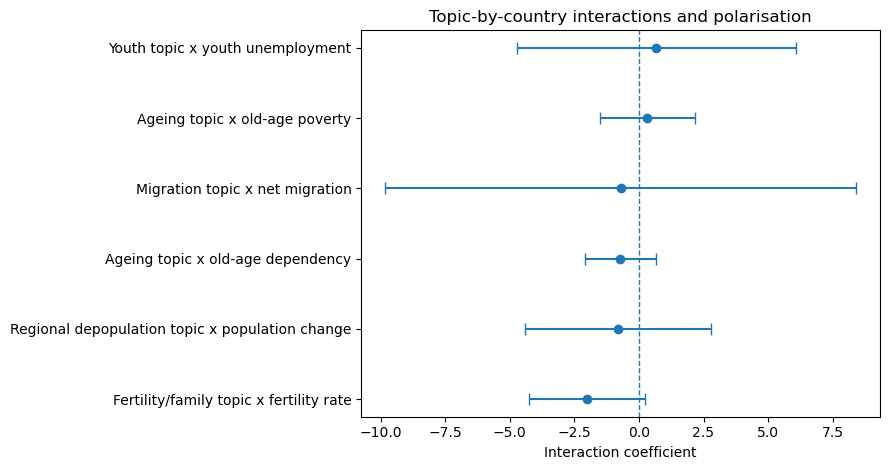

Saved: C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\7 Final Analysis\outputs\figures\interaction_coefficients_plot.png


,model,interaction,term,coef,ci_low,ci_high,p_value,significant_10pct,significant_5pct
9,single_model,Fertility/family topic x fertility rate,topic_fertility_family_gender:fertility_rate_z,-2.023,-4.269,0.222,0.077,True,False
10,single_model,Regional depopulation topic x population change,topic_regional_depopulation:population_change_z,-0.809,-4.420,2.803,0.661,False,False
6,single_model,Ageing topic x old-age dependency,topic_ageing_pensions:old_age_dependency_ratio_z,-0.714,-2.084,0.656,0.307,False,False
8,single_model,Migration topic x net migration,topic_migration:net_migration_z,-0.711,-9.839,8.417,0.879,False,False
7,single_model,Ageing topic x old-age poverty,topic_ageing_pensions:old_age_poverty_rate_z,0.329,-1.510,2.167,0.726,False,False
11,single_model,Youth topic x youth unemployment,topic_youth_future:youth_unemployment_z,0.673,-4.714,6.060,0.807,False,False


In [ ]:
# ============================================================
# Coefficient plot: theory-driven topic x country interactions
# Uses single-interaction models only
# ============================================================

if "TABLES_DIR" in globals():
    FIG_DIR = Path(TABLES_DIR).parent / "figures"
else:
    FIG_DIR = Path.cwd()

FIG_DIR.mkdir(parents=True, exist_ok=True)

interaction_plot_df = interaction_coef_table.copy()

# Prefer single-interaction models for clearer interpretation
if "model" in interaction_plot_df.columns:
    interaction_plot_df = interaction_plot_df[
        interaction_plot_df["model"] == "single_model"
    ].copy()

interaction_plot_df = interaction_plot_df.sort_values("coef", ascending=True)

plt.figure(figsize=(9, 4.8))

y_pos = np.arange(len(interaction_plot_df))

plt.errorbar(
    interaction_plot_df["coef"],
    y_pos,
    xerr=[
        interaction_plot_df["coef"] - interaction_plot_df["ci_low"],
        interaction_plot_df["ci_high"] - interaction_plot_df["coef"],
    ],
    fmt="o",
    capsize=4,
)

plt.axvline(0, linestyle="--", linewidth=1)

plt.yticks(y_pos, interaction_plot_df["interaction"])
plt.xlabel("Interaction coefficient")
plt.ylabel("")
plt.title("Topic-by-country interactions and polarisation")

plt.tight_layout()

plot_path = FIG_DIR / "interaction_coefficients_plot.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", plot_path)

display(interaction_plot_df.round(3))

### Regression Analysis: topic x country interactions

In [ ]:
# ============================================================
# Regression analysis: theory-driven topic x country interactions
# Dataset: cleaned_df
# ============================================================

print("\n" + "=" * 100)
print("THEORY-DRIVEN TOPIC x COUNTRY INTERACTION MODELS")
print("=" * 100)

# ============================================================
# 0. Start from cleaned_df
# ============================================================

df_int = cleaned_df.copy()

print("Starting dataset shape:", df_int.shape)

# ============================================================
# 1. Rename topic-share columns for regression formulas
# ============================================================

rename_topics = {
    "Ageing & Pensions": "topic_ageing_pensions",
    "Borderline: Economic governance and employment": "topic_econ_governance",
    "Borderline: Island regions and cohesion": "topic_island_cohesion",
    "Borderline: Labour market and social policy": "topic_labour_social",
    "Borderline: Regional development policy": "topic_regional_dev",
    "Borderline: Youth / demographic future (weak signal)": "topic_youth_future_weak",
    "Fertility, Families & Gender": "topic_fertility_family_gender",
    "Health & Care Services": "topic_health_care",
    "Housing & Living Conditions": "topic_housing",
    "Migration & Population Change": "topic_migration",
    "Population Growth & Sustainability": "topic_population_growth",
    "Regional Depopulation & Territorial Cohesion": "topic_regional_depopulation",
    "Youth & Future Generations": "topic_youth_future",
    "Other": "topic_other",
}

df_int = df_int.rename(columns={k: v for k, v in rename_topics.items() if k in df_int.columns})

topic_vars_all = [
    "topic_ageing_pensions",
    "topic_econ_governance",
    "topic_island_cohesion",
    "topic_labour_social",
    "topic_regional_dev",
    "topic_youth_future_weak",
    "topic_fertility_family_gender",
    "topic_health_care",
    "topic_housing",
    "topic_migration",
    "topic_population_growth",
    "topic_regional_depopulation",
    "topic_youth_future",
    "topic_other",
]

topic_vars_all = [c for c in topic_vars_all if c in df_int.columns]

# Topic shares sum to 1, so drop "Other" as reference.
topic_vars_reg = [c for c in topic_vars_all if c != "topic_other"]

print("\nTopic variables used, with topic_other omitted as reference:")
print(topic_vars_reg)

# ============================================================
# 2. Macro variables
# ============================================================

macro_vars_all = [
    "fertility_rate",
    "old_age_dependency_ratio",
    "median_age",
    "life_expectancy",
    "net_migration",
    "population_change",
    "gdp_per_capita_index_eu27_100",
    "employment_rate_55_64",
    "youth_unemployment",
    "debt_to_gdp",
    "age_started_receiving_old_age_pension",
    "continued_or_stopped_working_at_pension_start",
    "labour_force_participation_55_64",
    "old_age_poverty_rate",
    "projected_old_age_dependency_ratio_2050",
    "foreign_born_population_share",
]

macro_vars_present = [c for c in macro_vars_all if c in df_int.columns]

print("\nMacro variables present in cleaned_df:")
print(macro_vars_present)

if not macro_vars_present:
    raise ValueError(
        "No macro variables found in cleaned_df. "
        "Rerun the macro merge before this interaction block."
    )

# Variables excluded for now because they are hard to interpret or may be wrongly scaled.
excluded_macro_vars = [
    "projected_old_age_dependency_ratio_2050",
    "foreign_born_population_share",
    "continued_or_stopped_working_at_pension_start",
]

macro_vars_safe = [
    c for c in macro_vars_present
    if c not in excluded_macro_vars
]

print("\nMacro variables used in interaction models:")
print(macro_vars_safe)

print("\nMacro variables excluded for now:")
print([c for c in excluded_macro_vars if c in df_int.columns])

for col in macro_vars_safe:
    df_int[col] = pd.to_numeric(df_int[col], errors="coerce")

# Standardize macro variables
for col in macro_vars_safe:
    mean = df_int[col].mean(skipna=True)
    sd = df_int[col].std(skipna=True)

    if pd.notna(sd) and sd > 0:
        df_int[col + "_z"] = (df_int[col] - mean) / sd
    else:
        print(f"Skipped standardizing {col}: no variation or invalid sd.")

# ============================================================
# 3. Numeric controls
# ============================================================

numeric_controls = []

for col in ["n_relevant_speeches", "age_2020"]:
    if col in df_int.columns:
        df_int[col] = pd.to_numeric(df_int[col], errors="coerce")
        numeric_controls.append(col)

print("\nNumeric controls:")
print(numeric_controls)

# ============================================================
# 4. Categorical controls
# ============================================================

categorical_controls = [
    "gender_clean",
    "region_clean",
    "education_level_clean",
    "professional_background_clean",
]

categorical_controls = [c for c in categorical_controls if c in df_int.columns]

for col in categorical_controls:
    df_int[col] = (
        df_int[col]
        .astype("object")
        .where(df_int[col].notna(), "Missing")
        .astype(str)
    )

    # Collapse very rare categories to avoid unstable dummy coefficients
    counts = df_int[col].value_counts(dropna=False)
    rare_values = counts[counts < 5].index
    df_int[col] = np.where(df_int[col].isin(rare_values), "Other / Rare", df_int[col])

cat_terms = [f"C({c})" for c in categorical_controls]

print("\nCategorical controls:")
print(categorical_controls)

# ============================================================
# 5. Theory-driven interaction pairs
# ============================================================

interaction_pairs = [
    {
        "topic": "topic_ageing_pensions",
        "macro": "old_age_dependency_ratio_z",
        "label": "Ageing topic x old-age dependency",
    },
    {
        "topic": "topic_ageing_pensions",
        "macro": "old_age_poverty_rate_z",
        "label": "Ageing topic x old-age poverty",
    },
    {
        "topic": "topic_migration",
        "macro": "net_migration_z",
        "label": "Migration topic x net migration",
    },
    {
        "topic": "topic_fertility_family_gender",
        "macro": "fertility_rate_z",
        "label": "Fertility/family topic x fertility rate",
    },
    {
        "topic": "topic_regional_depopulation",
        "macro": "population_change_z",
        "label": "Regional depopulation topic x population change",
    },
    {
        "topic": "topic_youth_future",
        "macro": "youth_unemployment_z",
        "label": "Youth topic x youth unemployment",
    },
]

interaction_pairs = [
    pair for pair in interaction_pairs
    if pair["topic"] in df_int.columns and pair["macro"] in df_int.columns
]

print("\nInteraction pairs used:")
for pair in interaction_pairs:
    print(f"- {pair['label']}: {pair['topic']} * {pair['macro']}")

if not interaction_pairs:
    raise ValueError(
        "No valid interaction pairs found. "
        "Check that topic variables and standardized macro variables exist."
    )

# ============================================================
# 6. Helper function
# ============================================================

def run_hc3_ols(formula, data, model_name):
    model = smf.ols(formula=formula, data=data).fit(cov_type="HC3")

    print("\n" + "=" * 100)
    print(model_name)
    print("=" * 100)
    print("Formula:")
    print(formula)
    print("\nN used:", int(model.nobs))
    print(model.summary())

    return model

# ============================================================
# 7. Full theory-driven interaction model
# ============================================================

macro_main_terms = sorted(set(pair["macro"] for pair in interaction_pairs))

interaction_terms = [
    f'{pair["topic"]}:{pair["macro"]}'
    for pair in interaction_pairs
]

formula_full_interaction = (
    "polarisation_score ~ "
    + " + ".join(
        topic_vars_reg
        + macro_main_terms
        + interaction_terms
        + numeric_controls
        + cat_terms
    )
)

full_interaction_model = run_hc3_ols(
    formula_full_interaction,
    df_int,
    "Full interaction model: topic shares x country context"
)

# ============================================================
# 8. Smaller one-interaction-at-a-time models
# ============================================================
# These are often more stable and easier to interpret with N = 193.

single_interaction_models = {}

for pair in interaction_pairs:
    topic = pair["topic"]
    macro = pair["macro"]
    interaction = f"{topic}:{macro}"

    formula_single = (
        "polarisation_score ~ "
        + " + ".join(
            topic_vars_reg
            + [macro, interaction]
            + numeric_controls
            + cat_terms
        )
    )

    model_name = "Single interaction: " + pair["label"]

    single_interaction_models[pair["label"]] = run_hc3_ols(
        formula_single,
        df_int,
        model_name
    )

# ============================================================
# 9. Extract interaction coefficients
# ============================================================

interaction_coef_rows = []

# Full model coefficients
params = full_interaction_model.params
conf = full_interaction_model.conf_int()
pvals = full_interaction_model.pvalues

for pair in interaction_pairs:
    term = f'{pair["topic"]}:{pair["macro"]}'

    if term in params.index:
        interaction_coef_rows.append({
            "model": "full_model",
            "interaction": pair["label"],
            "term": term,
            "coef": params[term],
            "ci_low": conf.loc[term, 0],
            "ci_high": conf.loc[term, 1],
            "p_value": pvals[term],
            "significant_10pct": pvals[term] < 0.10,
            "significant_5pct": pvals[term] < 0.05,
        })

# Single model coefficients
for label, model in single_interaction_models.items():
    pair = next(p for p in interaction_pairs if p["label"] == label)
    term = f'{pair["topic"]}:{pair["macro"]}'

    params = model.params
    conf = model.conf_int()
    pvals = model.pvalues

    if term in params.index:
        interaction_coef_rows.append({
            "model": "single_model",
            "interaction": label,
            "term": term,
            "coef": params[term],
            "ci_low": conf.loc[term, 0],
            "ci_high": conf.loc[term, 1],
            "p_value": pvals[term],
            "significant_10pct": pvals[term] < 0.10,
            "significant_5pct": pvals[term] < 0.05,
        })

interaction_coef_table = pd.DataFrame(interaction_coef_rows)

print("\n" + "=" * 100)
print("INTERACTION COEFFICIENTS")
print("=" * 100)

if interaction_coef_table.empty:
    print("No interaction coefficients extracted.")
else:
    print(interaction_coef_table.round(4).to_string(index=False))

interaction_coef_table.to_csv("regression_interaction_coefficients.csv", index=False)

print("\nSaved:")
print("- regression_interaction_coefficients.csv")

# ============================================================
# 10. Compact interpretation helper
# ============================================================

print("\n" + "=" * 100)
print("INTERPRETATION GUIDE")
print("=" * 100)

print(
    "Interaction coefficients show whether a topic becomes more or less polarising "
    "when the country-level demographic context increases by one standard deviation."
)

print(
    "Example: a positive coefficient on 'Migration topic x net migration' means that "
    "migration-related speech is more polarising among MEPs from countries with higher net migration."
)

print(
    "Use the single-interaction models as the main exploratory evidence if the full model is unstable."
)


THEORY-DRIVEN TOPIC x COUNTRY INTERACTION MODELS
Starting dataset shape: (193, 59)

Topic variables used, with topic_other omitted as reference:
['topic_ageing_pensions', 'topic_econ_governance', 'topic_island_cohesion', 'topic_labour_social', 'topic_regional_dev', 'topic_youth_future_weak', 'topic_fertility_family_gender', 'topic_health_care', 'topic_housing', 'topic_migration', 'topic_population_growth', 'topic_regional_depopulation', 'topic_youth_future']

Macro variables present in cleaned_df:
['fertility_rate', 'old_age_dependency_ratio', 'median_age', 'life_expectancy', 'net_migration', 'population_change', 'gdp_per_capita_index_eu27_100', 'employment_rate_55_64', 'youth_unemployment', 'debt_to_gdp', 'age_started_receiving_old_age_pension', 'continued_or_stopped_working_at_pension_start', 'labour_force_participation_55_64', 'old_age_poverty_rate', 'projected_old_age_dependency_ratio_2050', 'foreign_born_population_share']

Macro variables used in interaction models:
['fertility_

c:\Users\Gebruiker\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 44, but rank is 41
  warnings.warn('covariance of constraints does not have full '


                            OLS Regression Results                            
Dep. Variable:     polarisation_score   R-squared:                       0.321
Model:                            OLS   Adj. R-squared:                  0.114
Method:                 Least Squares   F-statistic:                     1.271
Date:                Wed, 15 Jul 2026   Prob (F-statistic):              0.156
Time:                        17:08:59   Log-Likelihood:                -359.30
No. Observations:                 176   AIC:                             802.6
Df Residuals:                     134   BIC:                             935.8
Df Model:                          41                                         
Covariance Type:                  HC3                                         
                                                                           coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------

c:\Users\Gebruiker\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 34, but rank is 31
  warnings.warn('covariance of constraints does not have full '



Single interaction: Ageing topic x old-age poverty
Formula:
polarisation_score ~ topic_ageing_pensions + topic_econ_governance + topic_island_cohesion + topic_labour_social + topic_regional_dev + topic_youth_future_weak + topic_fertility_family_gender + topic_health_care + topic_housing + topic_migration + topic_population_growth + topic_regional_depopulation + topic_youth_future + old_age_poverty_rate_z + topic_ageing_pensions:old_age_poverty_rate_z + n_relevant_speeches + age_2020 + C(gender_clean) + C(region_clean) + C(education_level_clean) + C(professional_background_clean)

N used: 181
                            OLS Regression Results                            
Dep. Variable:     polarisation_score   R-squared:                       0.290
Model:                            OLS   Adj. R-squared:                  0.143
Method:                 Least Squares   F-statistic:                     1.516
Date:                Wed, 15 Jul 2026   Prob (F-statistic):             0.0533
Time:

c:\Users\Gebruiker\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 34, but rank is 31
  warnings.warn('covariance of constraints does not have full '



Single interaction: Migration topic x net migration
Formula:
polarisation_score ~ topic_ageing_pensions + topic_econ_governance + topic_island_cohesion + topic_labour_social + topic_regional_dev + topic_youth_future_weak + topic_fertility_family_gender + topic_health_care + topic_housing + topic_migration + topic_population_growth + topic_regional_depopulation + topic_youth_future + net_migration_z + topic_migration:net_migration_z + n_relevant_speeches + age_2020 + C(gender_clean) + C(region_clean) + C(education_level_clean) + C(professional_background_clean)

N used: 181
                            OLS Regression Results                            
Dep. Variable:     polarisation_score   R-squared:                       0.299
Model:                            OLS   Adj. R-squared:                  0.153
Method:                 Least Squares   F-statistic:                     1.502
Date:                Wed, 15 Jul 2026   Prob (F-statistic):             0.0574
Time:                   

c:\Users\Gebruiker\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 34, but rank is 31
  warnings.warn('covariance of constraints does not have full '



Single interaction: Fertility/family topic x fertility rate
Formula:
polarisation_score ~ topic_ageing_pensions + topic_econ_governance + topic_island_cohesion + topic_labour_social + topic_regional_dev + topic_youth_future_weak + topic_fertility_family_gender + topic_health_care + topic_housing + topic_migration + topic_population_growth + topic_regional_depopulation + topic_youth_future + fertility_rate_z + topic_fertility_family_gender:fertility_rate_z + n_relevant_speeches + age_2020 + C(gender_clean) + C(region_clean) + C(education_level_clean) + C(professional_background_clean)

N used: 181


c:\Users\Gebruiker\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 34, but rank is 31
  warnings.warn('covariance of constraints does not have full '


                            OLS Regression Results                            
Dep. Variable:     polarisation_score   R-squared:                       0.295
Model:                            OLS   Adj. R-squared:                  0.148
Method:                 Least Squares   F-statistic:                     1.533
Date:                Wed, 15 Jul 2026   Prob (F-statistic):             0.0488
Time:                        17:09:02   Log-Likelihood:                -374.62
No. Observations:                 181   AIC:                             813.2
Df Residuals:                     149   BIC:                             915.6
Df Model:                          31                                         
Covariance Type:                  HC3                                         
                                                                           coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------

c:\Users\Gebruiker\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 34, but rank is 31
  warnings.warn('covariance of constraints does not have full '


                            OLS Regression Results                            
Dep. Variable:     polarisation_score   R-squared:                       0.297
Model:                            OLS   Adj. R-squared:                  0.150
Method:                 Least Squares   F-statistic:                     1.467
Date:                Wed, 15 Jul 2026   Prob (F-statistic):             0.0686
Time:                        17:09:03   Log-Likelihood:                -374.41
No. Observations:                 181   AIC:                             812.8
Df Residuals:                     149   BIC:                             915.2
Df Model:                          31                                         
Covariance Type:                  HC3                                         
                                                                           coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------

c:\Users\Gebruiker\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 34, but rank is 31
  warnings.warn('covariance of constraints does not have full '


                            OLS Regression Results                            
Dep. Variable:     polarisation_score   R-squared:                       0.287
Model:                            OLS   Adj. R-squared:                  0.134
Method:                 Least Squares   F-statistic:                     1.407
Date:                Wed, 15 Jul 2026   Prob (F-statistic):             0.0936
Time:                        17:09:05   Log-Likelihood:                -363.64
No. Observations:                 176   AIC:                             791.3
Df Residuals:                     144   BIC:                             892.7
Df Model:                          31                                         
Covariance Type:                  HC3                                         
                                                                           coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------

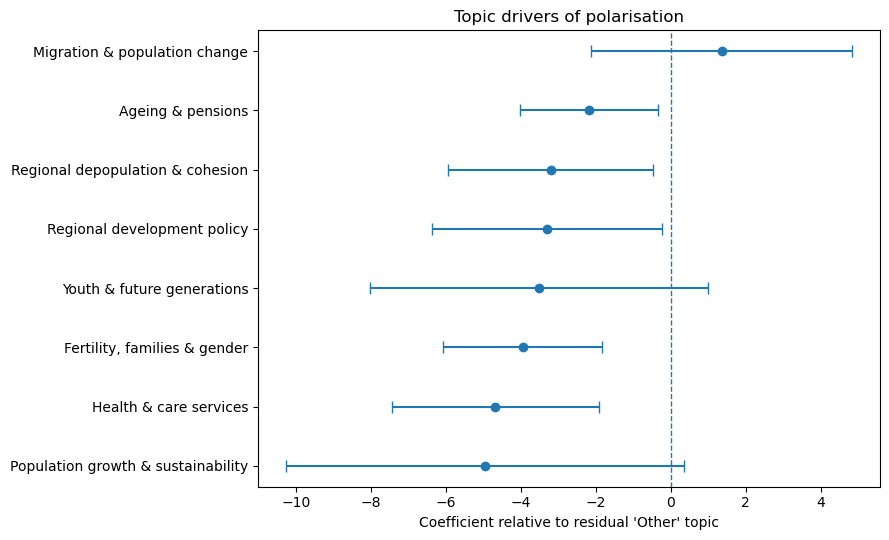

Saved: C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\7 Final Analysis\outputs\figures\fig_topic_effects_coefficient_plot.png


,variable,label,coef,ci_low,ci_high,p_value
5,topic_population_growth,Population growth & sustainability,-4.950,-10.258,0.359,0.068
2,topic_health_care,Health & care services,-4.681,-7.438,-1.924,0.001
1,topic_fertility_family_gender,"Fertility, families & gender",-3.947,-6.072,-1.822,0.000
7,topic_youth_future,Youth & future generations,-3.519,-8.023,0.984,0.126
6,topic_regional_dev,Regional development policy,-3.308,-6.377,-0.239,0.035
4,topic_regional_depopulation,Regional depopulation & cohesion,-3.202,-5.930,-0.475,0.021
0,topic_ageing_pensions,Ageing & pensions,-2.174,-4.011,-0.336,0.020
3,topic_migration,Migration & population change,1.358,-2.117,4.833,0.444


In [ ]:
# ============================================================
# Nice visualisations for regression results
# ============================================================

if "TABLES_DIR" in globals():
    FIG_DIR = Path(TABLES_DIR).parent / "figures"
else:
    FIG_DIR = Path.cwd()

FIG_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# 1. Topic effects coefficient plot
# Preferred model: Topics + biography
# ============================================================

preferred_model = models["M2_topics_bio"]

topic_labels = {
    "topic_ageing_pensions": "Ageing & pensions",
    "topic_fertility_family_gender": "Fertility, families & gender",
    "topic_health_care": "Health & care services",
    "topic_migration": "Migration & population change",
    "topic_regional_depopulation": "Regional depopulation & cohesion",
    "topic_population_growth": "Population growth & sustainability",
    "topic_regional_dev": "Regional development policy",
    "topic_youth_future": "Youth & future generations",
    "topic_island_cohesion": "Island regions & cohesion",
    "topic_econ_governance": "Economic governance",
    "topic_labour_social": "Labour/social policy",
    "topic_housing": "Housing",
}

rows = []
params = preferred_model.params
conf = preferred_model.conf_int()
pvals = preferred_model.pvalues

for var, label in topic_labels.items():
    if var in params.index:
        rows.append({
            "variable": var,
            "label": label,
            "coef": params[var],
            "ci_low": conf.loc[var, 0],
            "ci_high": conf.loc[var, 1],
            "p_value": pvals[var],
        })

topic_plot_df = pd.DataFrame(rows)

# Keep most substantively relevant topics only
keep_topics_for_plot = [
    "Ageing & pensions",
    "Fertility, families & gender",
    "Health & care services",
    "Migration & population change",
    "Regional depopulation & cohesion",
    "Population growth & sustainability",
    "Regional development policy",
    "Youth & future generations",
]

topic_plot_df = topic_plot_df[
    topic_plot_df["label"].isin(keep_topics_for_plot)
].copy()

topic_plot_df = topic_plot_df.sort_values("coef", ascending=True)

plt.figure(figsize=(9, 5.5))

y_pos = np.arange(len(topic_plot_df))

plt.errorbar(
    topic_plot_df["coef"],
    y_pos,
    xerr=[
        topic_plot_df["coef"] - topic_plot_df["ci_low"],
        topic_plot_df["ci_high"] - topic_plot_df["coef"],
    ],
    fmt="o",
    capsize=4,
)

plt.axvline(0, linestyle="--", linewidth=1)

plt.yticks(y_pos, topic_plot_df["label"])
plt.xlabel("Coefficient relative to residual 'Other' topic")
plt.ylabel("")
plt.title("Topic drivers of polarisation")

plt.tight_layout()

topic_plot_path = FIG_DIR / "fig_topic_effects_coefficient_plot.png"
plt.savefig(topic_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", topic_plot_path)
display(topic_plot_df.round(3))

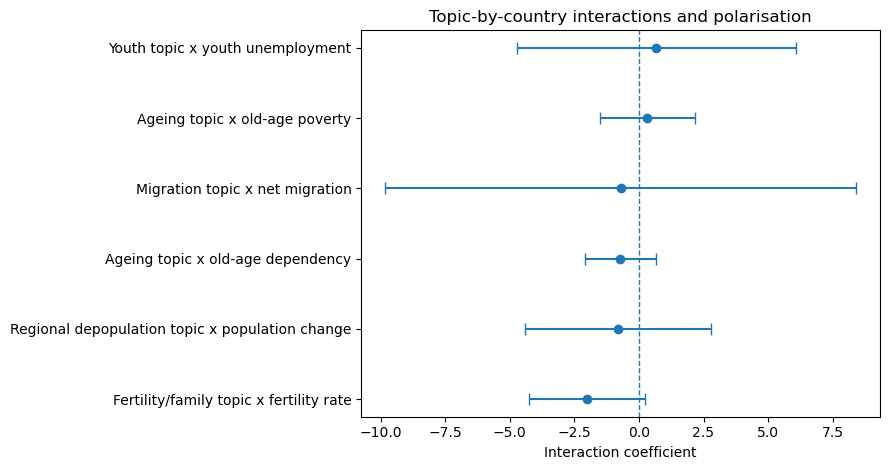

Saved: C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\7 Final Analysis\outputs\figures\fig_interaction_coefficients_plot.png


,model,interaction,term,coef,ci_low,ci_high,p_value,significant_10pct,significant_5pct
9,single_model,Fertility/family topic x fertility rate,topic_fertility_family_gender:fertility_rate_z,-2.023,-4.269,0.222,0.077,True,False
10,single_model,Regional depopulation topic x population change,topic_regional_depopulation:population_change_z,-0.809,-4.420,2.803,0.661,False,False
6,single_model,Ageing topic x old-age dependency,topic_ageing_pensions:old_age_dependency_ratio_z,-0.714,-2.084,0.656,0.307,False,False
8,single_model,Migration topic x net migration,topic_migration:net_migration_z,-0.711,-9.839,8.417,0.879,False,False
7,single_model,Ageing topic x old-age poverty,topic_ageing_pensions:old_age_poverty_rate_z,0.329,-1.510,2.167,0.726,False,False
11,single_model,Youth topic x youth unemployment,topic_youth_future:youth_unemployment_z,0.673,-4.714,6.060,0.807,False,False


In [ ]:
# ============================================================
# 2. Interaction coefficient plot
# Prefer single-interaction models
# ============================================================

interaction_plot_df = interaction_coef_table.copy()

if "model" in interaction_plot_df.columns:
    interaction_plot_df = interaction_plot_df[
        interaction_plot_df["model"] == "single_model"
    ].copy()

interaction_plot_df = interaction_plot_df.sort_values("coef", ascending=True)

plt.figure(figsize=(9, 4.8))

y_pos = np.arange(len(interaction_plot_df))

plt.errorbar(
    interaction_plot_df["coef"],
    y_pos,
    xerr=[
        interaction_plot_df["coef"] - interaction_plot_df["ci_low"],
        interaction_plot_df["ci_high"] - interaction_plot_df["coef"],
    ],
    fmt="o",
    capsize=4,
)

plt.axvline(0, linestyle="--", linewidth=1)

plt.yticks(y_pos, interaction_plot_df["interaction"])
plt.xlabel("Interaction coefficient")
plt.ylabel("")
plt.title("Topic-by-country interactions and polarisation")

plt.tight_layout()

interaction_plot_path = FIG_DIR / "fig_interaction_coefficients_plot.png"
plt.savefig(interaction_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", interaction_plot_path)
display(interaction_plot_df.round(3))

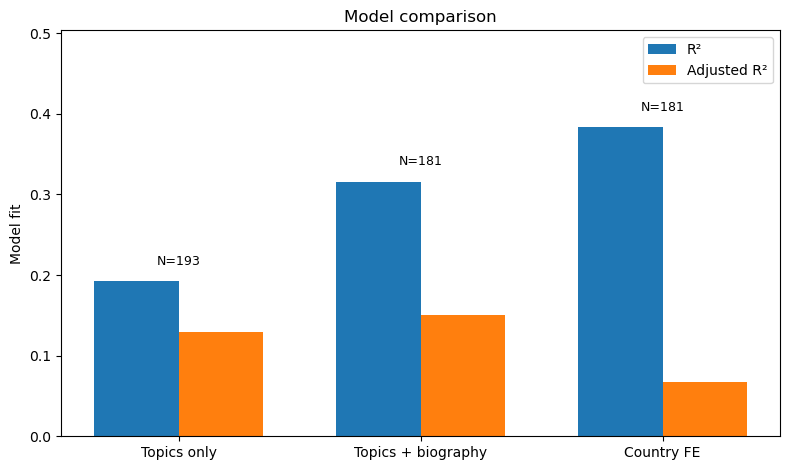

Saved: C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\7 Final Analysis\outputs\figures\fig_model_comparison.png


,model,N,R2,Adjusted R2
0,Topics only,193,0.192,0.129
1,Topics + biography,181,0.316,0.151
2,Country FE,181,0.384,0.068


In [ ]:
# ============================================================
# 3. Model comparison plot
# R2 and adjusted R2
# ============================================================

model_comp_rows = []

model_labels = {
    "M1_topics": "Topics only",
    "M2_topics_bio": "Topics + biography",
    "M3_country_FE": "Country FE",
}

for key, label in model_labels.items():
    if key in models:
        m = models[key]
        model_comp_rows.append({
            "model": label,
            "N": int(m.nobs),
            "R2": m.rsquared,
            "Adjusted R2": m.rsquared_adj,
        })

model_comp_df = pd.DataFrame(model_comp_rows)

plot_df = model_comp_df.melt(
    id_vars=["model", "N"],
    value_vars=["R2", "Adjusted R2"],
    var_name="metric",
    value_name="value",
)

x = np.arange(len(model_comp_df))
width = 0.35

plt.figure(figsize=(8, 4.8))

r2_vals = model_comp_df["R2"].values
adj_vals = model_comp_df["Adjusted R2"].values

plt.bar(x - width/2, r2_vals, width, label="R²")
plt.bar(x + width/2, adj_vals, width, label="Adjusted R²")

plt.xticks(x, model_comp_df["model"])
plt.ylabel("Model fit")
plt.title("Model comparison")
plt.legend()

for i, n in enumerate(model_comp_df["N"]):
    plt.text(i, max(r2_vals[i], adj_vals[i]) + 0.02, f"N={n}", ha="center", fontsize=9)

plt.ylim(0, max(model_comp_df["R2"].max(), model_comp_df["Adjusted R2"].max()) + 0.12)

plt.tight_layout()

model_comp_plot_path = FIG_DIR / "fig_model_comparison.png"
plt.savefig(model_comp_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", model_comp_plot_path)
display(model_comp_df.round(3))

### Exporting the tables

In [ ]:
# ============================================================
# Export all regression outputs to LaTeX
# Run after:
# 1) baseline regression block creates `models`
# 2) interaction regression block creates `interaction_coef_table`
# ============================================================

# ------------------------------------------------------------
# 0. Output folder
# ------------------------------------------------------------

if "TABLES_DIR" in globals():
    latex_output_dir = Path(TABLES_DIR)
else:
    latex_output_dir = Path.cwd()

latex_output_dir.mkdir(parents=True, exist_ok=True)

print("=" * 100)
print("EXPORTING REGRESSION TABLES TO LATEX")
print("=" * 100)
print("Output folder:", latex_output_dir)


# ============================================================
# 1. Export baseline regression table
# ============================================================

if "models" not in globals() or not models:
    print("\n[Baseline table] Skipped: `models` not found or empty.")

else:
    regressor_order = [
        "n_relevant_speeches",
        "age_2020",
        "topic_ageing_pensions",
        "topic_econ_governance",
        "topic_island_cohesion",
        "topic_labour_social",
        "topic_regional_dev",
        "topic_youth_future_weak",
        "topic_fertility_family_gender",
        "topic_health_care",
        "topic_housing",
        "topic_migration",
        "topic_population_growth",
        "topic_regional_depopulation",
        "topic_youth_future",
    ]

    model_names = {
        "M1_topics": "Topics",
        "M2_topics_bio": "Topics + biography",
        "M3_country_FE": "Country FE",
    }

    ordered_model_keys = [
        k for k in ["M1_topics", "M2_topics_bio", "M3_country_FE"]
        if k in models
    ]

    baseline_reg_table = summary_col(
        [models[k] for k in ordered_model_keys],
        model_names=[model_names.get(k, k) for k in ordered_model_keys],
        stars=True,
        float_format="%0.3f",
        regressor_order=regressor_order,
        info_dict={
            "N": lambda x: f"{int(x.nobs)}",
            "R2": lambda x: f"{x.rsquared:.3f}",
            "Adj. R2": lambda x: f"{x.rsquared_adj:.3f}",
        }
    )

    baseline_latex_code = baseline_reg_table.as_latex()

    baseline_latex_code = baseline_latex_code.replace(
        "\\begin{table}",
        "\\begin{table}[!htbp]\n\\centering"
    )

    baseline_latex_code = baseline_latex_code.replace(
        "\\caption{}",
        "\\caption{Baseline regressions: drivers of polarisation}"
    )

    baseline_latex_code = baseline_latex_code.replace(
        "\\label{}",
        "\\label{tab:baseline_polarisation_regressions}"
    )

    baseline_latex_code = baseline_latex_code.replace(
        "\\end{table}",
        "\\begin{minipage}{0.95\\textwidth}\n"
        "\\small\n"
        "\\textit{Notes:} The dependent variable is the overall polarisation score. "
        "All models are estimated using OLS with HC3 robust standard errors. "
        "Topic shares are measured as proportions. The residual Other topic is omitted as the reference category. "
        "Biography controls include gender, region, education level, professional background, prior political level, "
        "migration background, international experience, and age where included. "
        "Stars denote significance levels: * $p<0.10$, ** $p<0.05$, *** $p<0.01$.\n"
        "\\end{minipage}\n"
        "\\end{table}"
    )

    baseline_latex_path = latex_output_dir / "baseline_regression_table.tex"

    with open(baseline_latex_path, "w", encoding="utf-8") as f:
        f.write(baseline_latex_code)

    print("\n[Baseline table] Saved:")
    print(baseline_latex_path)


# ============================================================
# 2. Export interaction coefficient table
# ============================================================

if "interaction_coef_table" not in globals():
    print("\n[Interaction table] Skipped: `interaction_coef_table` not found.")

elif interaction_coef_table.empty:
    print("\n[Interaction table] Skipped: `interaction_coef_table` is empty.")

else:
    interaction_latex_table = interaction_coef_table.copy()

    interaction_latex_table["model"] = interaction_latex_table["model"].replace({
        "full_model": "Full model",
        "single_model": "Single-interaction model",
    })

    def _stars(p):
        if pd.isna(p):
            return ""
        if p < 0.01:
            return "***"
        if p < 0.05:
            return "**"
        if p < 0.10:
            return "*"
        return ""

    interaction_latex_table["Coefficient"] = (
        interaction_latex_table["coef"].round(3).astype(str)
        + interaction_latex_table["p_value"].map(_stars)
    )

    interaction_latex_table["95\\% CI"] = (
        "["
        + interaction_latex_table["ci_low"].round(3).astype(str)
        + ", "
        + interaction_latex_table["ci_high"].round(3).astype(str)
        + "]"
    )

    interaction_latex_table["$p$-value"] = interaction_latex_table["p_value"].round(3)

    interaction_latex_table = interaction_latex_table[
        [
            "model",
            "interaction",
            "Coefficient",
            "95\\% CI",
            "$p$-value",
        ]
    ].rename(columns={
        "model": "Model",
        "interaction": "Interaction",
    })

    interaction_latex_code = interaction_latex_table.to_latex(
        index=False,
        escape=False,
        column_format="llccc",
        caption="Theory-driven topic-by-country interaction models",
        label="tab:topic_country_interactions",
    )

    interaction_latex_code = interaction_latex_code.replace(
        "\\begin{table}",
        "\\begin{table}[!htbp]\n\\centering"
    )

    interaction_latex_code = interaction_latex_code.replace(
        "\\end{table}",
        "\\begin{minipage}{0.95\\textwidth}\n"
        "\\small\n"
        "\\textit{Notes:} Coefficients are from OLS models with HC3 robust standard errors. "
        "Country-level variables are standardized. Topic shares are measured as proportions, "
        "with the residual Other topic omitted as the reference category. "
        "The full model includes all theory-driven interactions jointly, while the single-interaction models "
        "estimate one interaction at a time. "
        "Stars denote significance levels: * $p<0.10$, ** $p<0.05$, *** $p<0.01$.\n"
        "\\end{minipage}\n"
        "\\end{table}"
    )

    interaction_latex_path = latex_output_dir / "interaction_coefficients_table.tex"

    with open(interaction_latex_path, "w", encoding="utf-8") as f:
        f.write(interaction_latex_code)

    print("\n[Interaction table] Saved:")
    print(interaction_latex_path)


# ============================================================
# 3. Print LaTeX input commands
# ============================================================

print("\n" + "=" * 100)
print("LATEX INPUT COMMANDS")
print("=" * 100)

if "baseline_latex_path" in locals():
    print("\\input{baseline_regression_table.tex}")

if "interaction_latex_path" in locals():
    print("\\input{interaction_coefficients_table.tex}")

print("\nRequired LaTeX package:")
print("\\usepackage{booktabs}")

EXPORTING REGRESSION TABLES TO LATEX
Output folder: C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\7 Final Analysis\outputs\tables

[Baseline table] Saved:
C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\7 Final Analysis\outputs\tables\baseline_regression_table.tex

[Interaction table] Saved:
C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\7 Final Analysis\outputs\tables\interaction_coefficients_table.tex

LATEX INPUT COMMANDS
\input{baseline_regression_table.tex}
\input{interaction_coefficients_table.tex}

Required LaTeX package:
\usepackage{booktabs}


In [ ]:
# ============================================================
# Export compact baseline regression table to LaTeX
# Shows only topic coefficients + key controls + model stats
# Hides biography and country dummy coefficients
# ============================================================

if "TABLES_DIR" in globals():
    latex_output_dir = Path(TABLES_DIR)
else:
    latex_output_dir = Path.cwd()

latex_output_dir.mkdir(parents=True, exist_ok=True)

if "models" not in globals() or not models:
    raise ValueError("No regression models found. Run the baseline regression block first.")

# ------------------------------------------------------------
# Select model order
# ------------------------------------------------------------

model_order = [
    "M1_topics",
    "M2_topics_bio",
    "M3_country_FE",
]

model_order = [m for m in model_order if m in models]

model_names = {
    "M1_topics": "Topics only",
    "M2_topics_bio": "Topics + biography",
    "M3_country_FE": "Country FE",
}

# ------------------------------------------------------------
# Only show substantively relevant coefficients
# ------------------------------------------------------------

regressor_order = [
    "topic_ageing_pensions",
    "topic_fertility_family_gender",
    "topic_health_care",
    "topic_migration",
    "topic_regional_depopulation",
    "topic_population_growth",
    "topic_regional_dev",
    "topic_youth_future",
    "topic_island_cohesion",
    "topic_econ_governance",
    "topic_labour_social",
    "topic_housing",
    "topic_youth_future_weak",
    "n_relevant_speeches",
    "age_2020",
]

# ------------------------------------------------------------
# Compact labels
# ------------------------------------------------------------

label_map = {
    "topic_ageing_pensions": "Ageing \\& pensions",
    "topic_fertility_family_gender": "Fertility, families \\& gender",
    "topic_health_care": "Health \\& care services",
    "topic_migration": "Migration \\& population change",
    "topic_regional_depopulation": "Regional depopulation \\& cohesion",
    "topic_population_growth": "Population growth \\& sustainability",
    "topic_regional_dev": "Regional development policy",
    "topic_youth_future": "Youth \\& future generations",
    "topic_island_cohesion": "Island regions \\& cohesion",
    "topic_econ_governance": "Economic governance",
    "topic_labour_social": "Labour/social policy",
    "topic_housing": "Housing",
    "topic_youth_future_weak": "Youth/future, weak signal",
    "n_relevant_speeches": "Relevant speeches",
    "age_2020": "Age",
}

# ------------------------------------------------------------
# Build compact regression table
# ------------------------------------------------------------

compact_table = summary_col(
    [models[m] for m in model_order],
    model_names=[model_names[m] for m in model_order],
    stars=True,
    float_format="%0.3f",
    regressor_order=regressor_order,
    drop_omitted=True,
    info_dict={
        "N": lambda x: f"{int(x.nobs)}",
        "R$^2$": lambda x: f"{x.rsquared:.3f}",
        "Adj. R$^2$": lambda x: f"{x.rsquared_adj:.3f}",
    }
)

latex_code = compact_table.as_latex()

# Replace technical variable names with readable labels
for old, new in label_map.items():
    latex_code = latex_code.replace(old.replace("_", "\\_"), new)
    latex_code = latex_code.replace(old, new)

# Clean table environment
latex_code = latex_code.replace(
    "\\begin{table}",
    "\\begin{table}[!htbp]\n\\centering\n\\small"
)

latex_code = latex_code.replace(
    "\\caption{}",
    "\\caption{Baseline regressions: topic-level drivers of polarisation}"
)

latex_code = latex_code.replace(
    "\\label{}",
    "\\label{tab:compact_baseline_regressions}"
)

# Add rows indicating hidden controls
insert_before = "N &"
control_rows = (
    "Biography controls & No & Yes & Yes \\\\\n"
    "Country fixed effects & No & No & Yes \\\\\n"
)

if insert_before in latex_code:
    latex_code = latex_code.replace(insert_before, control_rows + insert_before)

# Add notes
latex_code = latex_code.replace(
    "\\end{table}",
    "\\begin{minipage}{0.95\\textwidth}\n"
    "\\footnotesize\n"
    "\\textit{Notes:} The dependent variable is the overall polarisation score. "
    "Models are estimated using OLS with HC3 robust standard errors. "
    "Topic shares are measured as proportions. The residual ``Other'' topic is omitted as the reference category. "
    "Biography controls include gender, region, education level, professional background, prior political level, "
    "migration background, international experience, and age where included. "
    "Country fixed effects are included only in the final model. "
    "Standard errors are reported in parentheses. "
    "Stars denote significance levels: * $p<0.10$, ** $p<0.05$, *** $p<0.01$.\n"
    "\\end{minipage}\n"
    "\\end{table}"
)

# Save
compact_latex_path = latex_output_dir / "compact_baseline_regression_table.tex"

with open(compact_latex_path, "w", encoding="utf-8") as f:
    f.write(latex_code)

print("Saved compact LaTeX regression table to:")
print(compact_latex_path)

print("\nInclude in LaTeX with:")
print("\\input{compact_baseline_regression_table.tex}")

Saved compact LaTeX regression table to:
C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\7 Final Analysis\outputs\tables\compact_baseline_regression_table.tex

Include in LaTeX with:
\input{compact_baseline_regression_table.tex}


## DF Beta


DFBETA INFLUENCE DIAGNOSTICS: FULL INTERACTION MODEL
Starting dataset shape: (193, 59)

Topic variables:
['topic_ageing_pensions', 'topic_econ_governance', 'topic_island_cohesion', 'topic_labour_social', 'topic_regional_dev', 'topic_youth_future_weak', 'topic_fertility_family_gender', 'topic_health_care', 'topic_housing', 'topic_migration', 'topic_population_growth', 'topic_regional_depopulation', 'topic_youth_future']

Macro variables:
['fertility_rate', 'old_age_dependency_ratio', 'median_age', 'life_expectancy', 'net_migration', 'population_change', 'gdp_per_capita_index_eu27_100', 'employment_rate_55_64', 'youth_unemployment', 'debt_to_gdp', 'age_started_receiving_old_age_pension', 'labour_force_participation_55_64', 'old_age_poverty_rate']

Numeric controls:
['n_relevant_speeches', 'age_2020']

Categorical controls:
['gender_clean', 'region_clean', 'education_level_clean', 'professional_background_clean', 'prior_political_level_clean', 'migration_background_flag', 'international_

,row_index,max_abs_dfbeta,n_coefficients_above_threshold,mep_name_clean,country_clean_final,polarisation_score
185,185,0.973254,30,ukasz kohut,pl,8.5
20,20,1.558091,23,asim ademov,bg,0.2
89,89,1.027129,23,jeroen lenaers,nl,1.5
81,81,1.658494,21,jadwiga wisniewska,pl,8.5
8,8,3.574236,20,alfred sant,mt,4.0
152,152,0.612971,19,pierfrancesco majorino,it,6.5
60,60,1.799807,17,franziska katharina brantner,de,1.2
91,91,1.781986,16,joachim stanis aw brudzinski,pl,9.2
155,155,0.314138,16,radan kanev,bg,6.5
94,94,0.585859,15,jorg meuthen,de,9.0



Coefficients most affected by influential observations:


,coefficient,max_abs_dfbeta,mean_abs_dfbeta,n_obs_above_threshold,share_obs_above_threshold
30,topic_migration,1.027129,0.060233,21,0.119318
9,C(professional_background_clean)[T.Business / ...,0.515500,0.053437,19,0.107955
41,topic_ageing_pensions:old_age_poverty_rate_z,0.606535,0.055864,18,0.102273
11,C(professional_background_clean)[T.Media / Jou...,0.420511,0.047408,18,0.102273
39,youth_unemployment_z,0.529434,0.050426,17,0.096591
1,C(gender_clean)[T.Male],0.520893,0.058503,17,0.096591
47,age_2020,0.495326,0.058335,17,0.096591
8,C(education_level_clean)[T.No higher education...,0.328504,0.052944,17,0.096591
14,C(professional_background_clean)[T.Politics / ...,0.585859,0.052560,16,0.090909
0,Intercept,0.344845,0.052173,16,0.090909



DFBETA summary for interaction terms:


,coefficient,max_abs_dfbeta,mean_abs_dfbeta,n_obs_above_threshold,share_obs_above_threshold
41,topic_ageing_pensions:old_age_poverty_rate_z,0.606535,0.055864,18,0.102273
40,topic_ageing_pensions:old_age_dependency_ratio_z,0.540287,0.052110,15,0.085227
44,topic_regional_depopulation:population_change_z,1.558091,0.049320,11,0.062500
45,topic_youth_future:youth_unemployment_z,1.065206,0.043794,8,0.045455
42,topic_migration:net_migration_z,3.574236,0.061472,7,0.039773
43,topic_fertility_family_gender:fertility_rate_z,0.353010,0.034537,7,0.039773



Number of observations with at least one DFBETA above threshold:
86

Share of model sample flagged:
0.489

Refit model excluding influential observations.
N used: 90
R2: 0.844
Adj. R2: 0.684

Coefficient stability before vs after excluding influential observations:


,term,coef_full_sample,p_full_sample,coef_without_influential,p_without_influential,absolute_change,relative_change_pct
1,topic_econ_governance,0.2697,0.8331,-16.0090,0.2078,16.2787,6036.3960
24,topic_youth_future:youth_unemployment_z,0.1904,0.9576,-4.4949,0.1231,4.6853,2461.1003
12,topic_youth_future,-4.3491,0.2518,0.0194,0.9947,4.3684,100.4451
21,topic_migration:net_migration_z,-0.0937,0.9845,-3.4019,0.0942,3.3082,3530.8492
2,topic_island_cohesion,-3.0605,0.1216,-6.2824,0.0356,3.2219,105.2745
9,topic_migration,2.4516,0.3090,5.3063,0.0092,2.8547,116.4442
8,topic_housing,0.7728,0.8494,2.1642,0.9979,1.3914,180.0423
10,topic_population_growth,-3.7694,0.2568,-2.7352,0.1690,1.0342,27.4373
5,topic_youth_future_weak,-1.0698,0.7016,-0.0866,0.9864,0.9833,91.9078
0,topic_ageing_pensions,-1.9054,0.1519,-2.8386,0.0157,0.9333,48.9803



Saved:
- C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\7 Final Analysis\outputs\tables\dfbeta_observation_influence.csv
- C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\7 Final Analysis\outputs\tables\dfbeta_coefficient_influence.csv
- C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\7 Final Analysis\outputs\tables\dfbeta_interaction_terms.csv
- C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\7 Final Analysis\outputs\tables\dfbeta_coefficient_stability.csv


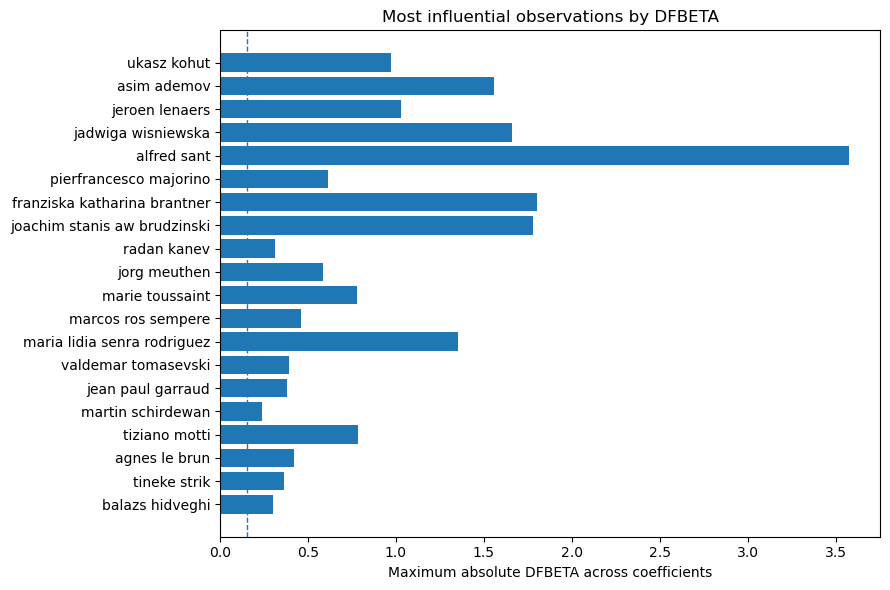

Saved figure:
C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\7 Final Analysis\outputs\tables\dfbeta_top_influential_observations.png


In [ ]:
# ============================================================
# DFBETA influence diagnostics for full interaction model
# Uses topic shares, biography controls, macro variables,
# and theory-driven interaction terms
# ============================================================

print("\n" + "=" * 100)
print("DFBETA INFLUENCE DIAGNOSTICS: FULL INTERACTION MODEL")
print("=" * 100)

# ============================================================
# 0. Start from cleaned_df
# ============================================================

df_dfbeta = cleaned_df.copy()

print("Starting dataset shape:", df_dfbeta.shape)

# ============================================================
# 1. Rename topic columns if needed
# ============================================================

rename_topics = {
    "Ageing & Pensions": "topic_ageing_pensions",
    "Borderline: Economic governance and employment": "topic_econ_governance",
    "Borderline: Island regions and cohesion": "topic_island_cohesion",
    "Borderline: Labour market and social policy": "topic_labour_social",
    "Borderline: Regional development policy": "topic_regional_dev",
    "Borderline: Youth / demographic future (weak signal)": "topic_youth_future_weak",
    "Fertility, Families & Gender": "topic_fertility_family_gender",
    "Health & Care Services": "topic_health_care",
    "Housing & Living Conditions": "topic_housing",
    "Migration & Population Change": "topic_migration",
    "Population Growth & Sustainability": "topic_population_growth",
    "Regional Depopulation & Territorial Cohesion": "topic_regional_depopulation",
    "Youth & Future Generations": "topic_youth_future",
    "Other": "topic_other",
}

df_dfbeta = df_dfbeta.rename(columns={k: v for k, v in rename_topics.items() if k in df_dfbeta.columns})

# ============================================================
# 2. Define variables
# ============================================================

topic_vars_all = [
    "topic_ageing_pensions",
    "topic_econ_governance",
    "topic_island_cohesion",
    "topic_labour_social",
    "topic_regional_dev",
    "topic_youth_future_weak",
    "topic_fertility_family_gender",
    "topic_health_care",
    "topic_housing",
    "topic_migration",
    "topic_population_growth",
    "topic_regional_depopulation",
    "topic_youth_future",
    "topic_other",
]

topic_vars_all = [c for c in topic_vars_all if c in df_dfbeta.columns]

# Drop Other because topic shares sum to 1
topic_vars_reg = [c for c in topic_vars_all if c != "topic_other"]

macro_vars = [
    "fertility_rate",
    "old_age_dependency_ratio",
    "median_age",
    "life_expectancy",
    "net_migration",
    "population_change",
    "gdp_per_capita_index_eu27_100",
    "employment_rate_55_64",
    "youth_unemployment",
    "debt_to_gdp",
    "age_started_receiving_old_age_pension",
    "labour_force_participation_55_64",
    "old_age_poverty_rate",
]

macro_vars = [c for c in macro_vars if c in df_dfbeta.columns]

numeric_controls = [
    "n_relevant_speeches",
    "age_2020",
]

numeric_controls = [c for c in numeric_controls if c in df_dfbeta.columns]

categorical_controls = [
    "gender_clean",
    "region_clean",
    "education_level_clean",
    "professional_background_clean",
    "prior_political_level_clean",
    "migration_background_flag",
    "international_experience_flag",
]

categorical_controls = [c for c in categorical_controls if c in df_dfbeta.columns]

print("\nTopic variables:")
print(topic_vars_reg)

print("\nMacro variables:")
print(macro_vars)

print("\nNumeric controls:")
print(numeric_controls)

print("\nCategorical controls:")
print(categorical_controls)

# ============================================================
# 3. Clean numeric variables
# ============================================================

for col in topic_vars_reg + macro_vars + numeric_controls + ["polarisation_score"]:
    if col in df_dfbeta.columns:
        df_dfbeta[col] = pd.to_numeric(df_dfbeta[col], errors="coerce")

# Standardise macro variables for interaction interpretation
for col in macro_vars:
    mean = df_dfbeta[col].mean(skipna=True)
    sd = df_dfbeta[col].std(skipna=True)

    if pd.notna(sd) and sd > 0:
        df_dfbeta[col + "_z"] = (df_dfbeta[col] - mean) / sd

# ============================================================
# 4. Clean categorical variables
# ============================================================

for col in categorical_controls:
    df_dfbeta[col] = (
        df_dfbeta[col]
        .astype("object")
        .where(df_dfbeta[col].notna(), "Missing")
        .astype(str)
    )

    # Collapse rare categories to avoid unstable dummy coefficients
    counts = df_dfbeta[col].value_counts(dropna=False)
    rare_values = counts[counts < 5].index
    df_dfbeta[col] = np.where(df_dfbeta[col].isin(rare_values), "Other / Rare", df_dfbeta[col])

cat_terms = [f"C({c})" for c in categorical_controls]

# ============================================================
# 5. Define theory-driven interactions
# ============================================================

interaction_pairs = [
    ("topic_ageing_pensions", "old_age_dependency_ratio_z", "Ageing x old-age dependency"),
    ("topic_ageing_pensions", "old_age_poverty_rate_z", "Ageing x old-age poverty"),
    ("topic_migration", "net_migration_z", "Migration x net migration"),
    ("topic_fertility_family_gender", "fertility_rate_z", "Fertility/family x fertility rate"),
    ("topic_regional_depopulation", "population_change_z", "Regional depopulation x population change"),
    ("topic_youth_future", "youth_unemployment_z", "Youth x youth unemployment"),
]

interaction_pairs = [
    (topic, macro, label)
    for topic, macro, label in interaction_pairs
    if topic in df_dfbeta.columns and macro in df_dfbeta.columns
]

interaction_terms = [
    f"{topic}:{macro}"
    for topic, macro, label in interaction_pairs
]

macro_main_terms = sorted(set(macro for topic, macro, label in interaction_pairs))

print("\nInteraction terms:")
for topic, macro, label in interaction_pairs:
    print(f"- {label}: {topic}:{macro}")

# ============================================================
# 6. Estimate full interaction model
# ============================================================

rhs_terms = (
    topic_vars_reg
    + macro_main_terms
    + interaction_terms
    + numeric_controls
    + cat_terms
)

formula_dfbeta = "polarisation_score ~ " + " + ".join(rhs_terms)

model_data = df_dfbeta.dropna(
    subset=["polarisation_score"] + topic_vars_reg + macro_main_terms + numeric_controls
).copy()

print("\nFormula:")
print(formula_dfbeta)

print("\nModel dataset shape after dropping missing required variables:")
print(model_data.shape)

dfbeta_model = smf.ols(
    formula=formula_dfbeta,
    data=model_data
).fit(cov_type="HC3")

print("\nFull interaction model fitted.")
print("N used:", int(dfbeta_model.nobs))
print("R2:", round(dfbeta_model.rsquared, 3))
print("Adj. R2:", round(dfbeta_model.rsquared_adj, 3))

# ============================================================
# 7. Compute DFBETAs
# ============================================================

influence = dfbeta_model.get_influence()
dfbetas = influence.dfbetas

dfbeta_df = pd.DataFrame(
    dfbetas,
    columns=dfbeta_model.params.index,
    index=model_data.index
)

# Rule-of-thumb threshold
n_used = int(dfbeta_model.nobs)
dfbeta_threshold = 2 / np.sqrt(n_used)

print("\nDFBETA threshold used:")
print(f"2 / sqrt(N) = {dfbeta_threshold:.3f}")

# ============================================================
# 8. Observation-level influence summary
# ============================================================

dfbeta_abs = dfbeta_df.abs()

obs_influence = pd.DataFrame({
    "row_index": dfbeta_abs.index,
    "max_abs_dfbeta": dfbeta_abs.max(axis=1),
    "n_coefficients_above_threshold": (dfbeta_abs > dfbeta_threshold).sum(axis=1),
})

# Add identifying columns if available
id_cols = [
    "mep_name_clean",
    "full_name_extracted",
    "country_clean_final",
    "ep_group_clean",
    "dominant_topic_cluster",
    "polarisation_score",
]

for col in id_cols:
    if col in model_data.columns:
        obs_influence[col] = model_data.loc[obs_influence["row_index"], col].values

obs_influence = obs_influence.sort_values(
    ["n_coefficients_above_threshold", "max_abs_dfbeta"],
    ascending=False
)

print("\nTop influential observations:")
display(obs_influence.head(20))

# ============================================================
# 9. Coefficient-level influence summary
# ============================================================

coef_influence = []

for col in dfbeta_df.columns:
    abs_vals = dfbeta_df[col].abs()

    coef_influence.append({
        "coefficient": col,
        "max_abs_dfbeta": abs_vals.max(),
        "mean_abs_dfbeta": abs_vals.mean(),
        "n_obs_above_threshold": int((abs_vals > dfbeta_threshold).sum()),
        "share_obs_above_threshold": float((abs_vals > dfbeta_threshold).mean()),
    })

coef_influence = pd.DataFrame(coef_influence).sort_values(
    ["n_obs_above_threshold", "max_abs_dfbeta"],
    ascending=False
)

print("\nCoefficients most affected by influential observations:")
display(coef_influence.head(30))

# ============================================================
# 10. Focus on interaction terms
# ============================================================

interaction_dfbeta_summary = coef_influence[
    coef_influence["coefficient"].isin(interaction_terms)
].copy()

print("\nDFBETA summary for interaction terms:")
display(interaction_dfbeta_summary)

# ============================================================
# 11. Flag influential observations
# ============================================================

influential_obs = obs_influence[
    obs_influence["n_coefficients_above_threshold"] > 0
].copy()

print("\nNumber of observations with at least one DFBETA above threshold:")
print(len(influential_obs))

print("\nShare of model sample flagged:")
print(round(len(influential_obs) / n_used, 3))

# ============================================================
# 12. Refit model excluding influential observations
# ============================================================

model_data_no_influential = model_data.drop(index=influential_obs["row_index"], errors="ignore").copy()

dfbeta_model_no_influential = smf.ols(
    formula=formula_dfbeta,
    data=model_data_no_influential
).fit(cov_type="HC3")

print("\nRefit model excluding influential observations.")
print("N used:", int(dfbeta_model_no_influential.nobs))
print("R2:", round(dfbeta_model_no_influential.rsquared, 3))
print("Adj. R2:", round(dfbeta_model_no_influential.rsquared_adj, 3))

# ============================================================
# 13. Compare key coefficients before and after removing influential obs
# ============================================================

key_terms = (
    topic_vars_reg
    + macro_main_terms
    + interaction_terms
    + numeric_controls
)

compare_rows = []

for term in key_terms:
    if term in dfbeta_model.params.index and term in dfbeta_model_no_influential.params.index:
        coef_full = dfbeta_model.params[term]
        coef_clean = dfbeta_model_no_influential.params[term]

        compare_rows.append({
            "term": term,
            "coef_full_sample": coef_full,
            "p_full_sample": dfbeta_model.pvalues[term],
            "coef_without_influential": coef_clean,
            "p_without_influential": dfbeta_model_no_influential.pvalues[term],
            "absolute_change": abs(coef_clean - coef_full),
            "relative_change_pct": (
                abs(coef_clean - coef_full) / abs(coef_full) * 100
                if coef_full != 0 else np.nan
            ),
        })

coef_stability = pd.DataFrame(compare_rows).sort_values(
    "absolute_change",
    ascending=False
)

print("\nCoefficient stability before vs after excluding influential observations:")
display(coef_stability.round(4))

# ============================================================
# 14. Save outputs
# ============================================================

if "TABLES_DIR" in globals():
    OUT_DIR = Path(TABLES_DIR)
else:
    OUT_DIR = Path.cwd()

OUT_DIR.mkdir(parents=True, exist_ok=True)

obs_influence.to_csv(OUT_DIR / "dfbeta_observation_influence.csv", index=False)
coef_influence.to_csv(OUT_DIR / "dfbeta_coefficient_influence.csv", index=False)
interaction_dfbeta_summary.to_csv(OUT_DIR / "dfbeta_interaction_terms.csv", index=False)
coef_stability.to_csv(OUT_DIR / "dfbeta_coefficient_stability.csv", index=False)

print("\nSaved:")
print("-", OUT_DIR / "dfbeta_observation_influence.csv")
print("-", OUT_DIR / "dfbeta_coefficient_influence.csv")
print("-", OUT_DIR / "dfbeta_interaction_terms.csv")
print("-", OUT_DIR / "dfbeta_coefficient_stability.csv")

# ============================================================
# 15. Plot top influential observations
# ============================================================

top_n = 20
plot_obs = obs_influence.head(top_n).copy()

if "mep_name_clean" in plot_obs.columns:
    y_labels = plot_obs["mep_name_clean"].astype(str)
elif "full_name_extracted" in plot_obs.columns:
    y_labels = plot_obs["full_name_extracted"].astype(str)
else:
    y_labels = plot_obs["row_index"].astype(str)

plt.figure(figsize=(9, 6))

y_pos = np.arange(len(plot_obs))

plt.barh(y_pos, plot_obs["max_abs_dfbeta"])
plt.axvline(dfbeta_threshold, linestyle="--", linewidth=1)

plt.yticks(y_pos, y_labels)
plt.xlabel("Maximum absolute DFBETA across coefficients")
plt.ylabel("")
plt.title("Most influential observations by DFBETA")

plt.gca().invert_yaxis()
plt.tight_layout()

fig_path = OUT_DIR / "dfbeta_top_influential_observations.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure:")
print(fig_path)

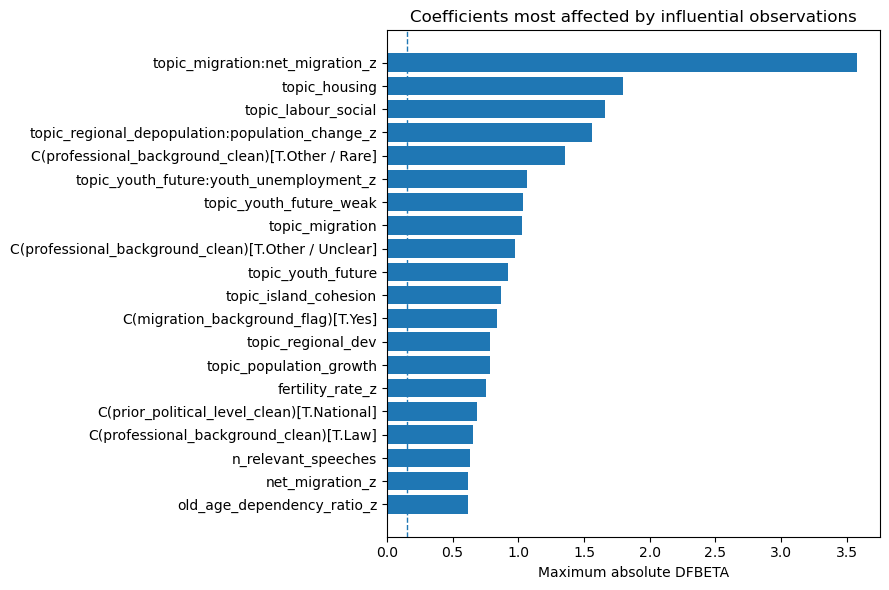

Saved: C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\7 Final Analysis\outputs\tables\dfbeta_top_affected_coefficients.png


In [ ]:
# ============================================================
# DFBETA plot 1: coefficients most affected by influential observations
# ============================================================

if "TABLES_DIR" in globals():
    OUT_DIR = Path(TABLES_DIR)
else:
    OUT_DIR = Path.cwd()

OUT_DIR.mkdir(parents=True, exist_ok=True)

plot_df = coef_influence.copy()

# Remove intercept and tiny numerical dummy artefacts
plot_df = plot_df[
    ~plot_df["coefficient"].str.contains("Intercept", regex=False)
].copy()

# Keep top 20 most affected coefficients
plot_df = plot_df.sort_values("max_abs_dfbeta", ascending=False).head(20)
plot_df = plot_df.sort_values("max_abs_dfbeta", ascending=True)

plt.figure(figsize=(9, 6))

y_pos = np.arange(len(plot_df))

plt.barh(y_pos, plot_df["max_abs_dfbeta"])
plt.axvline(dfbeta_threshold, linestyle="--", linewidth=1)

plt.yticks(y_pos, plot_df["coefficient"])
plt.xlabel("Maximum absolute DFBETA")
plt.ylabel("")
plt.title("Coefficients most affected by influential observations")

plt.tight_layout()

fig_path = OUT_DIR / "dfbeta_top_affected_coefficients.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

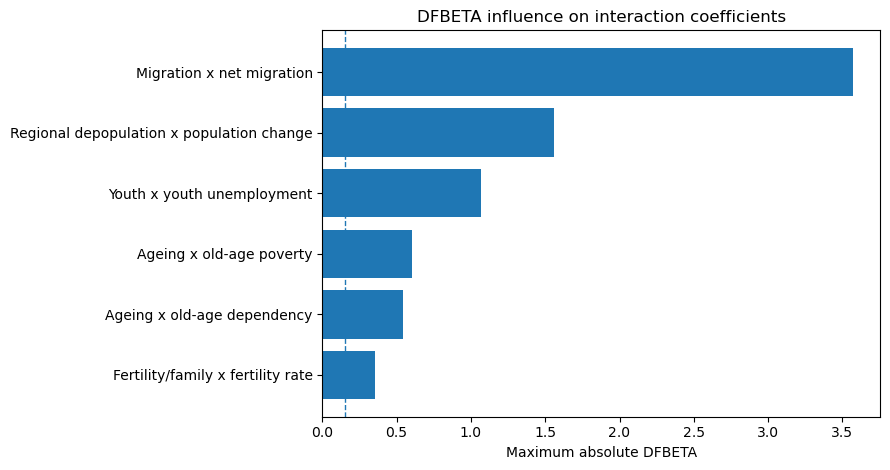

Saved: C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\7 Final Analysis\outputs\tables\dfbeta_interaction_coefficients.png


In [ ]:
# ============================================================
# DFBETA plot 2: interaction terms only
# ============================================================

plot_df = interaction_dfbeta_summary.copy()

label_map = {
    "topic_ageing_pensions:old_age_dependency_ratio_z": "Ageing x old-age dependency",
    "topic_ageing_pensions:old_age_poverty_rate_z": "Ageing x old-age poverty",
    "topic_migration:net_migration_z": "Migration x net migration",
    "topic_fertility_family_gender:fertility_rate_z": "Fertility/family x fertility rate",
    "topic_regional_depopulation:population_change_z": "Regional depopulation x population change",
    "topic_youth_future:youth_unemployment_z": "Youth x youth unemployment",
}

plot_df["label"] = plot_df["coefficient"].replace(label_map)

plot_df = plot_df.sort_values("max_abs_dfbeta", ascending=True)

plt.figure(figsize=(9, 4.8))

y_pos = np.arange(len(plot_df))

plt.barh(y_pos, plot_df["max_abs_dfbeta"])
plt.axvline(dfbeta_threshold, linestyle="--", linewidth=1)

plt.yticks(y_pos, plot_df["label"])
plt.xlabel("Maximum absolute DFBETA")
plt.ylabel("")
plt.title("DFBETA influence on interaction coefficients")

plt.tight_layout()

fig_path = OUT_DIR / "dfbeta_interaction_coefficients.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

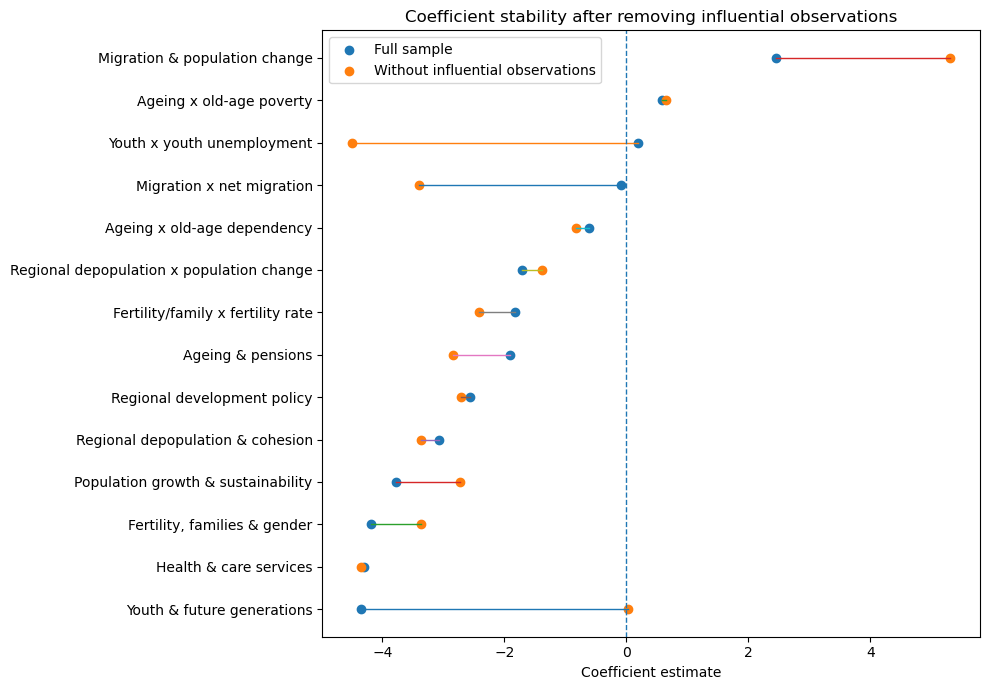

Saved: C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\7 Final Analysis\outputs\tables\dfbeta_coefficient_stability_plot.png


In [ ]:
# ============================================================
# DFBETA plot 3: coefficient stability before vs after removing influential observations
# ============================================================

plot_df = coef_stability.copy()

key_terms = [
    "topic_ageing_pensions",
    "topic_fertility_family_gender",
    "topic_health_care",
    "topic_migration",
    "topic_regional_depopulation",
    "topic_population_growth",
    "topic_regional_dev",
    "topic_youth_future",
    "topic_ageing_pensions:old_age_dependency_ratio_z",
    "topic_ageing_pensions:old_age_poverty_rate_z",
    "topic_migration:net_migration_z",
    "topic_fertility_family_gender:fertility_rate_z",
    "topic_regional_depopulation:population_change_z",
    "topic_youth_future:youth_unemployment_z",
]

plot_df = plot_df[plot_df["term"].isin(key_terms)].copy()

label_map = {
    "topic_ageing_pensions": "Ageing & pensions",
    "topic_fertility_family_gender": "Fertility, families & gender",
    "topic_health_care": "Health & care services",
    "topic_migration": "Migration & population change",
    "topic_regional_depopulation": "Regional depopulation & cohesion",
    "topic_population_growth": "Population growth & sustainability",
    "topic_regional_dev": "Regional development policy",
    "topic_youth_future": "Youth & future generations",
    "topic_ageing_pensions:old_age_dependency_ratio_z": "Ageing x old-age dependency",
    "topic_ageing_pensions:old_age_poverty_rate_z": "Ageing x old-age poverty",
    "topic_migration:net_migration_z": "Migration x net migration",
    "topic_fertility_family_gender:fertility_rate_z": "Fertility/family x fertility rate",
    "topic_regional_depopulation:population_change_z": "Regional depopulation x population change",
    "topic_youth_future:youth_unemployment_z": "Youth x youth unemployment",
}

plot_df["label"] = plot_df["term"].replace(label_map)

plot_df = plot_df.sort_values("coef_full_sample", ascending=True)

plt.figure(figsize=(10, 7))

y_pos = np.arange(len(plot_df))

plt.scatter(plot_df["coef_full_sample"], y_pos, label="Full sample")
plt.scatter(plot_df["coef_without_influential"], y_pos, label="Without influential observations")

for i, row in enumerate(plot_df.itertuples()):
    plt.plot(
        [row.coef_full_sample, row.coef_without_influential],
        [i, i],
        linewidth=1
    )

plt.axvline(0, linestyle="--", linewidth=1)

plt.yticks(y_pos, plot_df["label"])
plt.xlabel("Coefficient estimate")
plt.ylabel("")
plt.title("Coefficient stability after removing influential observations")
plt.legend()

plt.tight_layout()

fig_path = OUT_DIR / "dfbeta_coefficient_stability_plot.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

# K-Means Clustering


K-MEANS CLUSTERING OF MEPS
Starting dataset shape: (193, 59)

Topic variables:
['topic_ageing_pensions', 'topic_econ_governance', 'topic_island_cohesion', 'topic_labour_social', 'topic_regional_dev', 'topic_youth_future_weak', 'topic_fertility_family_gender', 'topic_health_care', 'topic_housing', 'topic_migration', 'topic_population_growth', 'topic_regional_depopulation', 'topic_youth_future', 'topic_other']

Polarisation dimension variables:
['polarisation_score', 'emotional_intensity', 'moral_absolutism']

Macro variables:
['fertility_rate', 'old_age_dependency_ratio', 'median_age', 'life_expectancy', 'net_migration', 'population_change', 'gdp_per_capita_index_eu27_100', 'employment_rate_55_64', 'youth_unemployment', 'debt_to_gdp', 'age_started_receiving_old_age_pension', 'labour_force_participation_55_64', 'old_age_poverty_rate']

Interaction variables:
['int_ageing_dependency', 'int_ageing_poverty', 'int_migration_net_migration', 'int_fertility_fertility_rate', 'int_regional_depop

c:\Users\Gebruiker\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Gebruiker\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Gebruiker\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Gebruiker\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memor


Cluster choice diagnostics:


,k,inertia,silhouette
0,2,7247.7861,0.1135
1,3,6590.4657,0.1221
2,4,6243.0275,0.1114
3,5,5980.9862,0.0953
4,6,5757.1195,0.1052
5,7,5592.5117,0.1010
6,8,5378.8872,0.1021


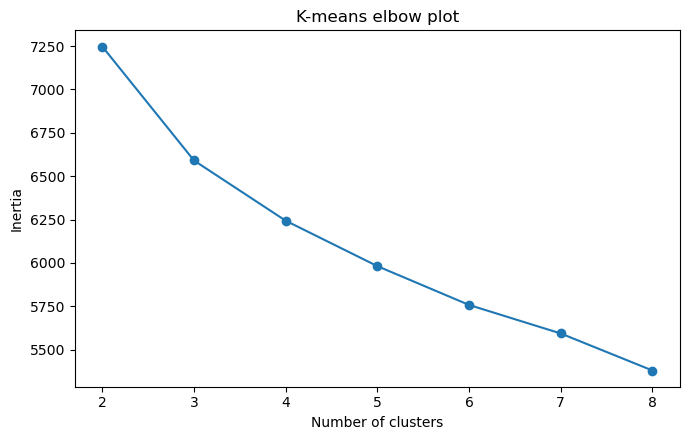

Saved: C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\7 Final Analysis\outputs\figures\kmeans_elbow_plot.png


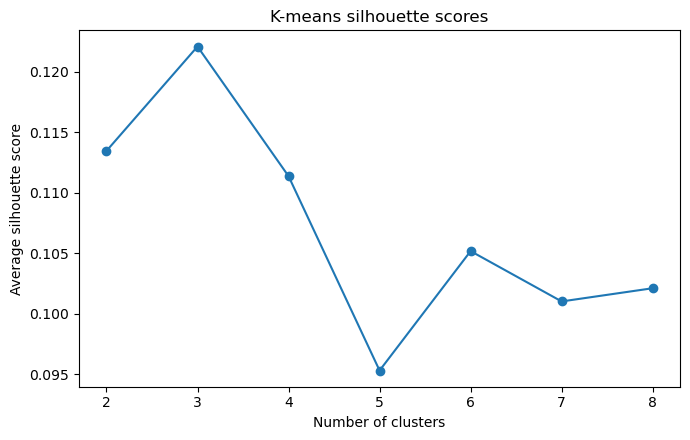

Saved: C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\7 Final Analysis\outputs\figures\kmeans_silhouette_plot.png

Automatic FINAL_K based on highest silhouette:
3


c:\Users\Gebruiker\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(



Cluster counts:
kmeans_cluster
1    55
2    46
3    92
Name: count, dtype: int64

PCA explained variance ratio:
[0.1209591  0.10517835]
Total explained by first two components: 0.226


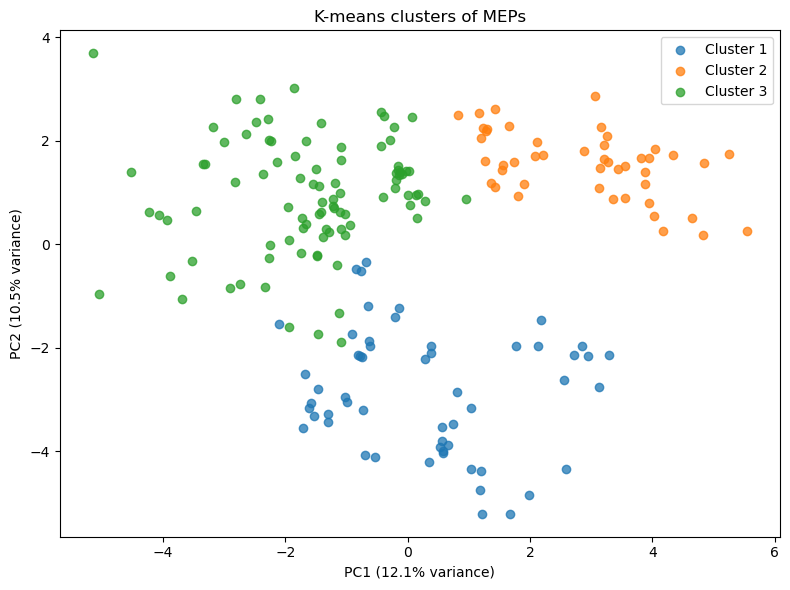

Saved: C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\7 Final Analysis\outputs\figures\kmeans_mep_clusters_pca.png

Cluster numeric profile:


,polarisation_score,emotional_intensity,moral_absolutism,n_relevant_speeches,topic_ageing_pensions,topic_econ_governance,topic_island_cohesion,topic_labour_social,topic_regional_dev,topic_youth_future_weak,topic_fertility_family_gender,topic_health_care,topic_housing,topic_migration,topic_population_growth,topic_regional_depopulation,topic_youth_future,topic_other,fertility_rate,old_age_dependency_ratio,median_age,life_expectancy,net_migration,population_change,gdp_per_capita_index_eu27_100,employment_rate_55_64,youth_unemployment,debt_to_gdp,age_started_receiving_old_age_pension,labour_force_participation_55_64,old_age_poverty_rate,int_ageing_dependency,int_ageing_poverty,int_migration_net_migration,int_fertility_fertility_rate,int_regional_depop_population_change,int_youth_unemployment,n
kmeans_cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,2.524,1.944,1.855,1.436,0.162,0.005,0.017,0.032,0.109,0.009,0.076,0.062,0.018,0.022,0.025,0.094,0.051,0.319,1.500,24.201,42.202,75.408,-0.561,-4.373,95.545,48.593,21.511,51.675,60.662,53.799,17.837,-0.136,0.096,-0.011,-0.037,-0.112,0.022,55
2,2.526,1.924,1.824,1.109,0.162,0.033,0.050,0.021,0.086,0.053,0.040,0.017,0.017,0.098,0.046,0.093,0.042,0.240,1.312,25.477,45.012,81.721,3.001,0.082,107.629,50.329,33.248,129.540,62.069,62.568,19.306,0.162,0.146,0.020,-0.042,-0.028,0.045,46
3,2.870,2.259,1.926,1.152,0.253,0.013,0.012,0.011,0.060,0.003,0.053,0.042,0.013,0.086,0.014,0.048,0.020,0.370,1.663,24.643,41.973,80.694,5.212,5.921,101.306,57.662,16.076,75.143,61.879,59.695,13.821,-0.069,-0.204,0.043,0.015,0.022,-0.018,92



Cluster categorical profile:


,kmeans_cluster,n,gender_clean_mode,gender_clean_mode_share,region_clean_mode,region_clean_mode_share,education_level_clean_mode,education_level_clean_mode_share,professional_background_clean_mode,professional_background_clean_mode_share,prior_political_level_clean_mode,prior_political_level_clean_mode_share,migration_background_flag_mode,migration_background_flag_mode_share,international_experience_flag_mode,international_experience_flag_mode_share
0,1,55,Male,0.582,Central & Eastern Europe,0.709,Doctorate,0.309,Politics / Public Administration,0.709,National,0.818,No,0.873,Yes,0.527
1,2,46,Male,0.609,Southern Europe,0.913,Bachelor,0.478,Politics / Public Administration,0.609,National,0.739,No,0.935,No,0.696
2,3,92,Male,0.565,Western Europe,0.696,No higher education listed,0.304,Politics / Public Administration,0.674,National,0.826,No,0.924,No,0.609



Saved:
- C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\7 Final Analysis\outputs\tables\kmeans_cluster_choice_diagnostics.csv
- C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\7 Final Analysis\outputs\tables\kmeans_cluster_profile_numeric.csv
- C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\7 Final Analysis\outputs\tables\kmeans_cluster_profile_categorical.csv
- C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\7 Final Analysis\outputs\tables\kmeans_mep_cluster_assignments.csv
- C:\Users\Gebruiker\

In [ ]:
# ============================================================
# K-means clustering of MEPs
# Includes:
# 1) Elbow plot
# 2) Silhouette plot
# 3) Final PCA cluster figure
# 4) Cluster assignment and profile tables
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

print("\n" + "=" * 100)
print("K-MEANS CLUSTERING OF MEPS")
print("=" * 100)

# ============================================================
# 0. Output folders
# ============================================================

if "TABLES_DIR" in globals():
    OUT_DIR = Path(TABLES_DIR)
    FIG_DIR = Path(TABLES_DIR).parent / "figures"
else:
    OUT_DIR = Path.cwd()
    FIG_DIR = Path.cwd()

OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# 1. Start from cleaned_df
# ============================================================

df_cluster = cleaned_df.copy()

print("Starting dataset shape:", df_cluster.shape)

# ============================================================
# 2. Rename topic columns if needed
# ============================================================

rename_topics = {
    "Ageing & Pensions": "topic_ageing_pensions",
    "Borderline: Economic governance and employment": "topic_econ_governance",
    "Borderline: Island regions and cohesion": "topic_island_cohesion",
    "Borderline: Labour market and social policy": "topic_labour_social",
    "Borderline: Regional development policy": "topic_regional_dev",
    "Borderline: Youth / demographic future (weak signal)": "topic_youth_future_weak",
    "Fertility, Families & Gender": "topic_fertility_family_gender",
    "Health & Care Services": "topic_health_care",
    "Housing & Living Conditions": "topic_housing",
    "Migration & Population Change": "topic_migration",
    "Population Growth & Sustainability": "topic_population_growth",
    "Regional Depopulation & Territorial Cohesion": "topic_regional_depopulation",
    "Youth & Future Generations": "topic_youth_future",
    "Other": "topic_other",
}

df_cluster = df_cluster.rename(columns={k: v for k, v in rename_topics.items() if k in df_cluster.columns})

# ============================================================
# 3. Define variables for clustering
# ============================================================
# Keep this broad but not insane. We include topic shares, polarisation dimensions,
# key numeric controls, country context, biography variables, and theory-driven interactions.

topic_vars = [
    "topic_ageing_pensions",
    "topic_econ_governance",
    "topic_island_cohesion",
    "topic_labour_social",
    "topic_regional_dev",
    "topic_youth_future_weak",
    "topic_fertility_family_gender",
    "topic_health_care",
    "topic_housing",
    "topic_migration",
    "topic_population_growth",
    "topic_regional_depopulation",
    "topic_youth_future",
    "topic_other",
]

topic_vars = [c for c in topic_vars if c in df_cluster.columns]

polarisation_dimension_vars = [
    "polarisation_score",
    "us_versus_them_framing",
    "emotional_intensity",
    "moral_absolutism",
    "hostility_toward_opponents",
]

polarisation_dimension_vars = [
    c for c in polarisation_dimension_vars
    if c in df_cluster.columns
]

numeric_controls = [
    "n_relevant_speeches",
    "age_2020",
]

numeric_controls = [c for c in numeric_controls if c in df_cluster.columns]

macro_vars = [
    "fertility_rate",
    "old_age_dependency_ratio",
    "median_age",
    "life_expectancy",
    "net_migration",
    "population_change",
    "gdp_per_capita_index_eu27_100",
    "employment_rate_55_64",
    "youth_unemployment",
    "debt_to_gdp",
    "age_started_receiving_old_age_pension",
    "labour_force_participation_55_64",
    "old_age_poverty_rate",
]

macro_vars = [c for c in macro_vars if c in df_cluster.columns]

categorical_vars = [
    "gender_clean",
    "region_clean",
    "education_level_clean",
    "professional_background_clean",
    "prior_political_level_clean",
    "migration_background_flag",
    "international_experience_flag",
    "ep_group_clean",
]

categorical_vars = [c for c in categorical_vars if c in df_cluster.columns]

# Convert relevant numeric variables
for col in topic_vars + polarisation_dimension_vars + numeric_controls + macro_vars:
    df_cluster[col] = pd.to_numeric(df_cluster[col], errors="coerce")

# ============================================================
# 4. Create standardised macro variables for interaction terms
# ============================================================

for col in macro_vars:
    mean = df_cluster[col].mean(skipna=True)
    sd = df_cluster[col].std(skipna=True)

    if pd.notna(sd) and sd > 0:
        df_cluster[col + "_z"] = (df_cluster[col] - mean) / sd

# Theory-driven interaction terms
interaction_specs = [
    ("topic_ageing_pensions", "old_age_dependency_ratio_z", "int_ageing_dependency"),
    ("topic_ageing_pensions", "old_age_poverty_rate_z", "int_ageing_poverty"),
    ("topic_migration", "net_migration_z", "int_migration_net_migration"),
    ("topic_fertility_family_gender", "fertility_rate_z", "int_fertility_fertility_rate"),
    ("topic_regional_depopulation", "population_change_z", "int_regional_depop_population_change"),
    ("topic_youth_future", "youth_unemployment_z", "int_youth_unemployment"),
]

interaction_vars = []

for topic, macro_z, new_col in interaction_specs:
    if topic in df_cluster.columns and macro_z in df_cluster.columns:
        df_cluster[new_col] = df_cluster[topic] * df_cluster[macro_z]
        interaction_vars.append(new_col)

print("\nTopic variables:")
print(topic_vars)

print("\nPolarisation dimension variables:")
print(polarisation_dimension_vars)

print("\nMacro variables:")
print(macro_vars)

print("\nInteraction variables:")
print(interaction_vars)

print("\nCategorical variables:")
print(categorical_vars)

# ============================================================
# 5. Build clustering dataset
# ============================================================

numeric_features = (
    topic_vars
    + polarisation_dimension_vars
    + numeric_controls
    + macro_vars
    + interaction_vars
)

numeric_features = [c for c in numeric_features if c in df_cluster.columns]
categorical_features = [c for c in categorical_vars if c in df_cluster.columns]

features_used = numeric_features + categorical_features

if not features_used:
    raise ValueError("No features available for clustering.")

cluster_data = df_cluster[features_used].copy()

# Drop rows without outcome score, because clusters should be based on scored MEPs
if "polarisation_score" in df_cluster.columns:
    cluster_data = cluster_data.loc[df_cluster["polarisation_score"].notna()].copy()
    df_cluster_model = df_cluster.loc[cluster_data.index].copy()
else:
    df_cluster_model = df_cluster.loc[cluster_data.index].copy()

print("\nClustering dataset shape:")
print(cluster_data.shape)

# ============================================================
# 6. Preprocess data
# ============================================================

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

X = preprocessor.fit_transform(cluster_data)

print("\nProcessed feature matrix shape:")
print(X.shape)

# ============================================================
# 7. Choose number of clusters: elbow and silhouette
# ============================================================

k_values = list(range(2, 9))

inertias = []
silhouettes = []

for k in k_values:
    km = KMeans(
        n_clusters=k,
        random_state=20260715,
        n_init=50
    )

    labels = km.fit_predict(X)

    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))

cluster_choice_df = pd.DataFrame({
    "k": k_values,
    "inertia": inertias,
    "silhouette": silhouettes,
})

print("\nCluster choice diagnostics:")
display(cluster_choice_df.round(4))

cluster_choice_df.to_csv(OUT_DIR / "kmeans_cluster_choice_diagnostics.csv", index=False)

# Elbow plot
plt.figure(figsize=(7, 4.5))
plt.plot(cluster_choice_df["k"], cluster_choice_df["inertia"], marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("K-means elbow plot")
plt.xticks(k_values)
plt.tight_layout()

elbow_path = FIG_DIR / "kmeans_elbow_plot.png"
plt.savefig(elbow_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", elbow_path)

# Silhouette plot
plt.figure(figsize=(7, 4.5))
plt.plot(cluster_choice_df["k"], cluster_choice_df["silhouette"], marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("Average silhouette score")
plt.title("K-means silhouette scores")
plt.xticks(k_values)
plt.tight_layout()

silhouette_path = FIG_DIR / "kmeans_silhouette_plot.png"
plt.savefig(silhouette_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", silhouette_path)

# ============================================================
# 8. Choose final k
# ============================================================
# Automatic choice: k with highest silhouette.
# You can override manually by setting FINAL_K = 3, 4, etc.

FINAL_K = int(cluster_choice_df.loc[cluster_choice_df["silhouette"].idxmax(), "k"])

print("\nAutomatic FINAL_K based on highest silhouette:")
print(FINAL_K)

# To override manually, uncomment this:
# FINAL_K = 4

# ============================================================
# 9. Fit final K-means model
# ============================================================

kmeans_final = KMeans(
    n_clusters=FINAL_K,
    random_state=20260715,
    n_init=100
)

cluster_labels = kmeans_final.fit_predict(X)

df_cluster_model["kmeans_cluster"] = cluster_labels

# Make cluster labels 1-based for easier reporting
df_cluster_model["kmeans_cluster"] = df_cluster_model["kmeans_cluster"] + 1

print("\nCluster counts:")
print(df_cluster_model["kmeans_cluster"].value_counts().sort_index())

# ============================================================
# 10. PCA projection for final MEP figure
# ============================================================

pca = PCA(n_components=2, random_state=20260715)
X_pca = pca.fit_transform(X)

df_cluster_model["pca_1"] = X_pca[:, 0]
df_cluster_model["pca_2"] = X_pca[:, 1]

explained_var = pca.explained_variance_ratio_

print("\nPCA explained variance ratio:")
print(explained_var)
print("Total explained by first two components:", round(explained_var.sum(), 3))

plt.figure(figsize=(8, 6))

for cluster in sorted(df_cluster_model["kmeans_cluster"].unique()):
    temp = df_cluster_model[df_cluster_model["kmeans_cluster"] == cluster]

    plt.scatter(
        temp["pca_1"],
        temp["pca_2"],
        label=f"Cluster {cluster}",
        alpha=0.75
    )

plt.xlabel(f"PC1 ({explained_var[0] * 100:.1f}% variance)")
plt.ylabel(f"PC2 ({explained_var[1] * 100:.1f}% variance)")
plt.title("K-means clusters of MEPs")
plt.legend()
plt.tight_layout()

cluster_pca_path = FIG_DIR / "kmeans_mep_clusters_pca.png"
plt.savefig(cluster_pca_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", cluster_pca_path)

# ============================================================
# 11. Cluster profiles
# ============================================================

profile_numeric = [
    c for c in [
        "polarisation_score",
        "us_versus_them_framing",
        "emotional_intensity",
        "moral_absolutism",
        "hostility_toward_opponents",
        "n_relevant_speeches",
    ] + topic_vars + macro_vars + interaction_vars
    if c in df_cluster_model.columns
]

cluster_profile = (
    df_cluster_model
    .groupby("kmeans_cluster")[profile_numeric]
    .mean()
    .round(3)
)

cluster_sizes = (
    df_cluster_model["kmeans_cluster"]
    .value_counts()
    .sort_index()
    .rename("n")
)

cluster_profile = cluster_profile.join(cluster_sizes)

print("\nCluster numeric profile:")
display(cluster_profile)

cluster_profile.to_csv(OUT_DIR / "kmeans_cluster_profile_numeric.csv")

# Most common categories per cluster
category_profile_rows = []

for cluster, temp in df_cluster_model.groupby("kmeans_cluster"):
    row = {"kmeans_cluster": cluster, "n": len(temp)}

    for col in categorical_features:
        if col in temp.columns:
            top_value = temp[col].astype(str).value_counts(dropna=False).idxmax()
            top_share = temp[col].astype(str).value_counts(normalize=True, dropna=False).iloc[0]

            row[col + "_mode"] = top_value
            row[col + "_mode_share"] = round(top_share, 3)

    category_profile_rows.append(row)

cluster_profile_categorical = pd.DataFrame(category_profile_rows)

print("\nCluster categorical profile:")
display(cluster_profile_categorical)

cluster_profile_categorical.to_csv(
    OUT_DIR / "kmeans_cluster_profile_categorical.csv",
    index=False
)

# ============================================================
# 12. Save MEP-level cluster assignments
# ============================================================

id_cols = [
    "mep_name_clean",
    "full_name_extracted",
    "country_clean_final",
    "ep_group_clean",
    "dominant_topic_cluster",
    "polarisation_score",
    "kmeans_cluster",
    "pca_1",
    "pca_2",
]

id_cols = [c for c in id_cols if c in df_cluster_model.columns]

cluster_assignments = df_cluster_model[id_cols].copy()

cluster_assignments.to_csv(
    OUT_DIR / "kmeans_mep_cluster_assignments.csv",
    index=False
)

print("\nSaved:")
print("-", OUT_DIR / "kmeans_cluster_choice_diagnostics.csv")
print("-", OUT_DIR / "kmeans_cluster_profile_numeric.csv")
print("-", OUT_DIR / "kmeans_cluster_profile_categorical.csv")
print("-", OUT_DIR / "kmeans_mep_cluster_assignments.csv")
print("-", FIG_DIR / "kmeans_elbow_plot.png")
print("-", FIG_DIR / "kmeans_silhouette_plot.png")
print("-", FIG_DIR / "kmeans_mep_clusters_pca.png")

# MEP Profiles 


DESCRIPTIVE MEP PROFILES

Polarisation bands:
polarisation_band
Low         90
Moderate    74
High        29
Name: count, dtype: int64

MEP profile counts:
mep_profile
Mixed or residual demographic profile            64
Ageing and pensions policy profile               38
High-polarisation mixed profile                  25
Regional cohesion/depopulation profile           15
Regional development profile                     13
Future generations and sustainability profile    11
Moderate/low-polarisation migration profile       8
Family, fertility and gender profile              8
Health and care policy profile                    7
High-polarisation migration profile               4
Name: count, dtype: int64

Profile summary:


,mep_profile,n,mean_polarisation,median_polarisation,mean_relevant_speeches,share
4,High-polarisation migration profile,4,7.550,7.50,1.000,0.021
5,High-polarisation mixed profile,25,7.488,7.00,1.200,0.130
7,Moderate/low-polarisation migration profile,8,2.188,1.75,1.375,0.041
6,Mixed or residual demographic profile,64,2.080,2.00,1.234,0.332
0,Ageing and pensions policy profile,38,1.824,1.35,1.105,0.197
9,Regional development profile,13,1.692,1.20,1.308,0.067
3,Health and care policy profile,7,1.671,1.50,1.000,0.036
2,Future generations and sustainability profile,11,1.545,1.20,1.727,0.057
8,Regional cohesion/depopulation profile,15,1.380,1.20,1.133,0.078
1,"Family, fertility and gender profile",8,1.287,1.20,1.250,0.041



Topic composition by profile:


,Ageing & pensions,Fertility/family/gender,Health & care,Migration/population change,Regional depopulation/cohesion,Population growth/sustainability,Regional development,Youth/future generations,Housing/living conditions,Labour/social policy,Economic governance,Island/cohesion,Youth/future weak signal,Other/mixed,n
mep_profile,,,,,,,,,,,,,,,
Ageing and pensions policy profile,0.629,0.029,0.018,0.000,0.010,0.015,0.051,0.016,0.000,0.021,0.000,0.002,0.008,0.200,38
"Family, fertility and gender profile",0.093,0.565,0.028,0.000,0.031,0.008,0.042,0.011,0.000,0.000,0.000,0.021,0.000,0.200,8
Future generations and sustainability profile,0.104,0.046,0.041,0.005,0.015,0.164,0.060,0.165,0.000,0.000,0.000,0.002,0.169,0.229,11
Health and care policy profile,0.133,0.018,0.510,0.000,0.015,0.014,0.046,0.000,0.000,0.005,0.000,0.000,0.000,0.257,7
High-polarisation migration profile,0.084,0.026,0.008,0.583,0.001,0.000,0.000,0.000,0.000,0.000,0.032,0.000,0.000,0.263,4
High-polarisation mixed profile,0.203,0.027,0.010,0.102,0.035,0.022,0.047,0.040,0.040,0.039,0.010,0.000,0.025,0.401,25
Mixed or residual demographic profile,0.090,0.049,0.041,0.057,0.042,0.020,0.061,0.025,0.031,0.030,0.040,0.024,0.003,0.487,64
Moderate/low-polarisation migration profile,0.042,0.010,0.028,0.574,0.037,0.004,0.014,0.041,0.000,0.000,0.000,0.011,0.005,0.233,8
Regional cohesion/depopulation profile,0.045,0.031,0.004,0.010,0.564,0.011,0.102,0.057,0.000,0.000,0.000,0.005,0.000,0.169,15



Profile categorical summary:


,mep_profile,n,country_clean_final_top,country_clean_final_top_share,region_clean_top,region_clean_top_share,gender_clean_top,gender_clean_top_share,education_level_clean_top,education_level_clean_top_share,professional_background_clean_top,professional_background_clean_top_share
0,Ageing and pensions policy profile,38,fr,0.105,Western Europe,0.474,Male,0.711,No higher education listed,0.342,Politics / Public Administration,0.605
1,"Family, fertility and gender profile",8,pl,0.125,Central & Eastern Europe,0.375,Female,0.750,Bachelor,0.500,Politics / Public Administration,0.750
2,Future generations and sustainability profile,11,it,0.273,Southern Europe,0.455,Male,0.636,Bachelor,0.545,Politics / Public Administration,0.545
3,Health and care policy profile,7,ie,0.143,Western Europe,0.429,Male,0.571,Master,0.571,Politics / Public Administration,0.714
4,High-polarisation migration profile,4,hu,0.250,Central & Eastern Europe,0.250,Male,1.000,Bachelor,0.500,Politics / Public Administration,0.750
5,High-polarisation mixed profile,25,fr,0.240,Western Europe,0.480,Male,0.640,No higher education listed,0.280,Politics / Public Administration,0.560
6,Mixed or residual demographic profile,64,fr,0.156,Western Europe,0.344,Male,0.516,Bachelor,0.344,Politics / Public Administration,0.734
7,Moderate/low-polarisation migration profile,8,it,0.250,Western Europe,0.625,Male,0.625,Master,0.250,Politics / Public Administration,0.625
8,Regional cohesion/depopulation profile,15,it,0.200,Central & Eastern Europe,0.333,Female,0.600,Bachelor,0.333,Politics / Public Administration,0.667
9,Regional development profile,13,it,0.231,Southern Europe,0.538,Male,0.615,Doctorate,0.308,Politics / Public Administration,0.769


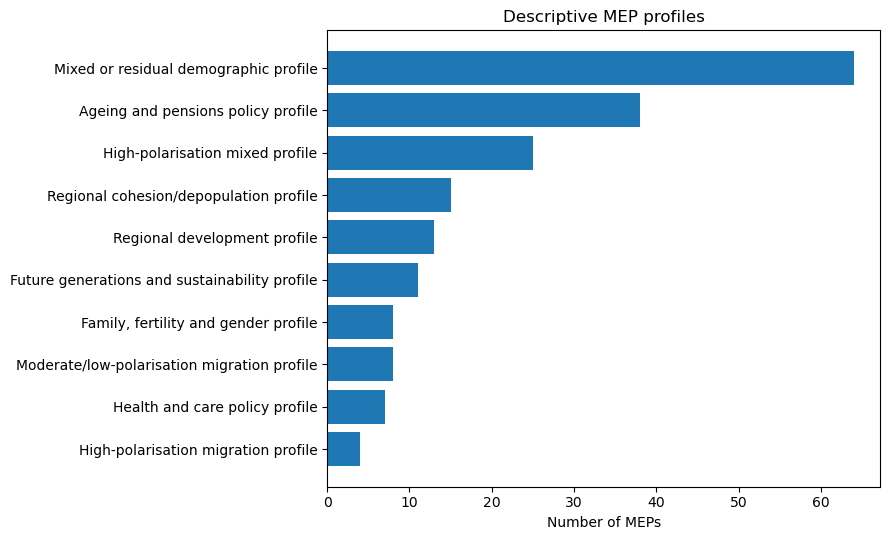

Saved: C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\7 Final Analysis\outputs\figures\descriptive_mep_profile_counts.png


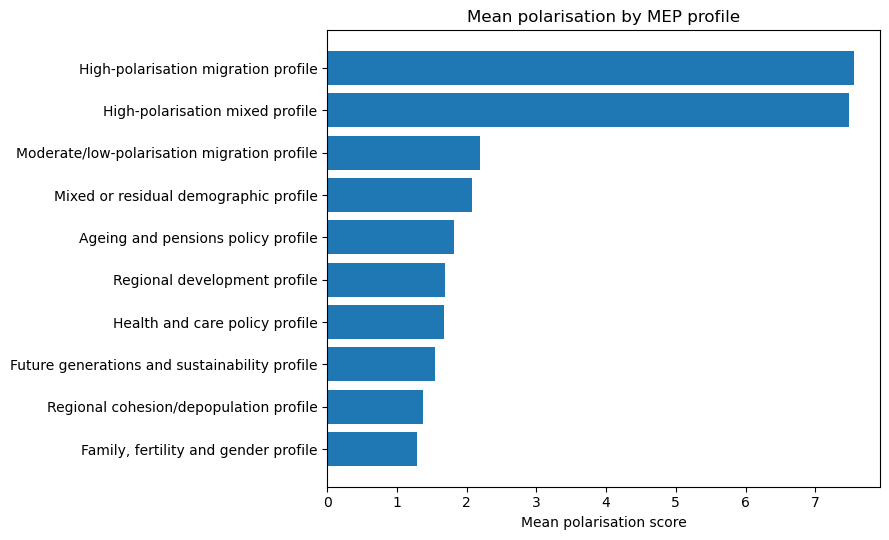

Saved: C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\7 Final Analysis\outputs\figures\descriptive_mep_profile_polarisation.png

Saved:
- C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\7 Final Analysis\outputs\tables\descriptive_mep_profile_summary.csv
- C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\7 Final Analysis\outputs\tables\descriptive_mep_profile_topic_composition.csv
- C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\7 Final Analysis\outputs\tables\descriptive_mep_profile_categories.csv


In [ ]:
# ============================================================
# Descriptive MEP profiles
# Based on polarisation level and dominant demographic topic
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

print("\n" + "=" * 100)
print("DESCRIPTIVE MEP PROFILES")
print("=" * 100)

# ============================================================
# 0. Output folders
# ============================================================

if "TABLES_DIR" in globals():
    OUT_DIR = Path(TABLES_DIR)
    FIG_DIR = Path(TABLES_DIR).parent / "figures"
else:
    OUT_DIR = Path.cwd()
    FIG_DIR = Path.cwd()

OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# 1. Start from cleaned_df
# ============================================================

df_prof = cleaned_df.copy()

if "polarisation_score" not in df_prof.columns:
    raise ValueError("cleaned_df must contain polarisation_score.")

df_prof["polarisation_score"] = pd.to_numeric(
    df_prof["polarisation_score"],
    errors="coerce"
)

# ============================================================
# 2. Rename topic-share columns if needed
# ============================================================

rename_topics = {
    "Ageing & Pensions": "topic_ageing_pensions",
    "Borderline: Economic governance and employment": "topic_econ_governance",
    "Borderline: Island regions and cohesion": "topic_island_cohesion",
    "Borderline: Labour market and social policy": "topic_labour_social",
    "Borderline: Regional development policy": "topic_regional_dev",
    "Borderline: Youth / demographic future (weak signal)": "topic_youth_future_weak",
    "Fertility, Families & Gender": "topic_fertility_family_gender",
    "Health & Care Services": "topic_health_care",
    "Housing & Living Conditions": "topic_housing",
    "Migration & Population Change": "topic_migration",
    "Population Growth & Sustainability": "topic_population_growth",
    "Regional Depopulation & Territorial Cohesion": "topic_regional_depopulation",
    "Youth & Future Generations": "topic_youth_future",
    "Other": "topic_other",
}

df_prof = df_prof.rename(columns={k: v for k, v in rename_topics.items() if k in df_prof.columns})

# ============================================================
# 3. Topic variables and labels
# ============================================================

topic_label_map = {
    "topic_ageing_pensions": "Ageing & pensions",
    "topic_fertility_family_gender": "Fertility/family/gender",
    "topic_health_care": "Health & care",
    "topic_migration": "Migration/population change",
    "topic_regional_depopulation": "Regional depopulation/cohesion",
    "topic_population_growth": "Population growth/sustainability",
    "topic_regional_dev": "Regional development",
    "topic_youth_future": "Youth/future generations",
    "topic_housing": "Housing/living conditions",
    "topic_labour_social": "Labour/social policy",
    "topic_econ_governance": "Economic governance",
    "topic_island_cohesion": "Island/cohesion",
    "topic_youth_future_weak": "Youth/future weak signal",
    "topic_other": "Other/mixed",
}

topic_vars = [c for c in topic_label_map if c in df_prof.columns]

for col in topic_vars:
    df_prof[col] = pd.to_numeric(df_prof[col], errors="coerce")

# If dominant topic cluster is missing or messy, reconstruct from topic shares
if "dominant_profile_topic" not in df_prof.columns:
    df_prof["dominant_profile_topic_var"] = df_prof[topic_vars].idxmax(axis=1)
    df_prof["dominant_profile_topic"] = df_prof["dominant_profile_topic_var"].map(topic_label_map)

# ============================================================
# 4. Create polarisation bands
# ============================================================

def polarisation_band(x):
    if pd.isna(x):
        return "Missing"
    if x < 2:
        return "Low"
    if x < 5:
        return "Moderate"
    return "High"

df_prof["polarisation_band"] = df_prof["polarisation_score"].map(polarisation_band)

print("\nPolarisation bands:")
print(df_prof["polarisation_band"].value_counts(dropna=False))

# ============================================================
# 5. Rule-based profile assignment
# ============================================================

def assign_mep_profile(row):
    pol = row.get("polarisation_score", np.nan)
    topic = row.get("dominant_profile_topic", "Other/mixed")

    if pd.isna(pol):
        return "Unclassified"

    # High-polarisation profiles first
    if pol >= 5 and topic == "Migration/population change":
        return "High-polarisation migration profile"

    if pol >= 5:
        return "High-polarisation mixed profile"

    # Topic-based profiles
    if topic == "Ageing & pensions":
        return "Ageing and pensions policy profile"

    if topic == "Fertility/family/gender":
        return "Family, fertility and gender profile"

    if topic == "Health & care":
        return "Health and care policy profile"

    if topic == "Regional depopulation/cohesion":
        return "Regional cohesion/depopulation profile"

    if topic == "Migration/population change":
        return "Moderate/low-polarisation migration profile"

    if topic in ["Population growth/sustainability", "Youth/future generations", "Youth/future weak signal"]:
        return "Future generations and sustainability profile"

    if topic in ["Regional development", "Island/cohesion"]:
        return "Regional development profile"

    return "Mixed or residual demographic profile"

df_prof["mep_profile"] = df_prof.apply(assign_mep_profile, axis=1)

print("\nMEP profile counts:")
print(df_prof["mep_profile"].value_counts())

# ============================================================
# 6. Profile summary table
# ============================================================

summary_numeric_vars = [
    "polarisation_score",
    "us_versus_them_framing",
    "emotional_intensity",
    "moral_absolutism",
    "hostility_toward_opponents",
    "n_relevant_speeches",
]

summary_numeric_vars = [c for c in summary_numeric_vars if c in df_prof.columns]

profile_summary = (
    df_prof
    .groupby("mep_profile")
    .agg(
        n=("polarisation_score", "size"),
        mean_polarisation=("polarisation_score", "mean"),
        median_polarisation=("polarisation_score", "median"),
        mean_relevant_speeches=("n_relevant_speeches", "mean") if "n_relevant_speeches" in df_prof.columns else ("polarisation_score", "size"),
    )
    .reset_index()
)

profile_summary["share"] = profile_summary["n"] / profile_summary["n"].sum()

profile_summary = profile_summary.sort_values(
    ["mean_polarisation", "n"],
    ascending=[False, False]
)

print("\nProfile summary:")
display(profile_summary.round(3))

profile_summary.to_csv(
    OUT_DIR / "descriptive_mep_profile_summary.csv",
    index=False
)

# ============================================================
# 7. Topic composition by profile
# ============================================================

topic_profile = (
    df_prof
    .groupby("mep_profile")[topic_vars]
    .mean()
    .rename(columns=topic_label_map)
    .round(3)
)

topic_profile["n"] = df_prof["mep_profile"].value_counts()

print("\nTopic composition by profile:")
display(topic_profile)

topic_profile.to_csv(
    OUT_DIR / "descriptive_mep_profile_topic_composition.csv"
)

# ============================================================
# 8. Categorical profile summaries
# ============================================================

cat_vars = [
    "ep_group_clean",
    "country_clean_final",
    "region_clean",
    "gender_clean",
    "education_level_clean",
    "professional_background_clean",
]

cat_vars = [c for c in cat_vars if c in df_prof.columns]

cat_rows = []

for profile, temp in df_prof.groupby("mep_profile"):
    row = {"mep_profile": profile, "n": len(temp)}

    for col in cat_vars:
        top = temp[col].astype(str).value_counts(normalize=True, dropna=False)
        if len(top) > 0:
            row[col + "_top"] = top.index[0]
            row[col + "_top_share"] = top.iloc[0]

    cat_rows.append(row)

profile_categories = pd.DataFrame(cat_rows)

print("\nProfile categorical summary:")
display(profile_categories.round(3))

profile_categories.to_csv(
    OUT_DIR / "descriptive_mep_profile_categories.csv",
    index=False
)

# ============================================================
# 9. Figure: profile counts and mean polarisation
# ============================================================

plot_df = profile_summary.sort_values("n", ascending=True)

plt.figure(figsize=(9, 5.5))

y_pos = np.arange(len(plot_df))

plt.barh(y_pos, plot_df["n"])

plt.yticks(y_pos, plot_df["mep_profile"])
plt.xlabel("Number of MEPs")
plt.ylabel("")
plt.title("Descriptive MEP profiles")

plt.tight_layout()

profile_counts_path = FIG_DIR / "descriptive_mep_profile_counts.png"
plt.savefig(profile_counts_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", profile_counts_path)

# Mean polarisation by profile
plot_df = profile_summary.sort_values("mean_polarisation", ascending=True)

plt.figure(figsize=(9, 5.5))

y_pos = np.arange(len(plot_df))

plt.barh(y_pos, plot_df["mean_polarisation"])

plt.yticks(y_pos, plot_df["mep_profile"])
plt.xlabel("Mean polarisation score")
plt.ylabel("")
plt.title("Mean polarisation by MEP profile")

plt.tight_layout()

profile_pol_path = FIG_DIR / "descriptive_mep_profile_polarisation.png"
plt.savefig(profile_pol_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", profile_pol_path)

# ============================================================
# 10. Save MEP-level profile assignments
# ============================================================

id_cols = [
    "mep_name_clean",
    "full_name_extracted",
    "country_clean_final",
    "ep_group_clean",
    "region_clean",
    "dominant_profile_topic",
    "polarisation_score",
    "polarisation_band",
    "mep_profile",
]

id_cols = [c for c in id_cols if c in df_prof.columns]

df_prof[id_cols].to_csv(
    OUT_DIR / "descriptive_mep_profile_assignments.csv",
    index=False
)

print("\nSaved:")
print("-", OUT_DIR / "descriptive_mep_profile_summary.csv")
print("-", OUT_DIR / "descriptive_mep_profile_topic_composition.csv")
print("-", OUT_DIR / "descriptive_mep_profile_categories.csv")
print("-", OUT_DIR / "descriptive_mep_profile_assignments.csv")
print("-", FIG_DIR / "descriptive_mep_profile_counts.png")
print("-", FIG_DIR / "descriptive_mep_profile_polarisation.png")

# Random Forest


RANDOM FOREST PREDICTION MODEL: POLARISATION
Starting dataset shape: (193, 59)

Numeric features:
['topic_ageing_pensions', 'topic_econ_governance', 'topic_island_cohesion', 'topic_labour_social', 'topic_regional_dev', 'topic_youth_future_weak', 'topic_fertility_family_gender', 'topic_health_care', 'topic_housing', 'topic_migration', 'topic_population_growth', 'topic_regional_depopulation', 'topic_youth_future', 'topic_other', 'n_relevant_speeches', 'age_2020', 'fertility_rate', 'old_age_dependency_ratio', 'median_age', 'life_expectancy', 'net_migration', 'population_change', 'gdp_per_capita_index_eu27_100', 'employment_rate_55_64', 'youth_unemployment', 'debt_to_gdp', 'age_started_receiving_old_age_pension', 'labour_force_participation_55_64', 'old_age_poverty_rate', 'int_ageing_dependency', 'int_ageing_poverty', 'int_migration_net_migration', 'int_fertility_fertility_rate', 'int_regional_depop_population_change', 'int_youth_unemployment']

Categorical features:
['gender_clean', 'reg

,feature,importance_mean,importance_sd
9,topic_migration,0.2150,0.0291
13,topic_other,0.1136,0.0158
31,int_migration_net_migration,0.0775,0.0134
2,topic_island_cohesion,0.0470,0.0092
3,topic_labour_social,0.0316,0.0063
30,int_ageing_poverty,0.0263,0.0052
34,int_youth_unemployment,0.0182,0.0046
4,topic_regional_dev,0.0134,0.0020
0,topic_ageing_pensions,0.0119,0.0020
1,topic_econ_governance,0.0113,0.0031


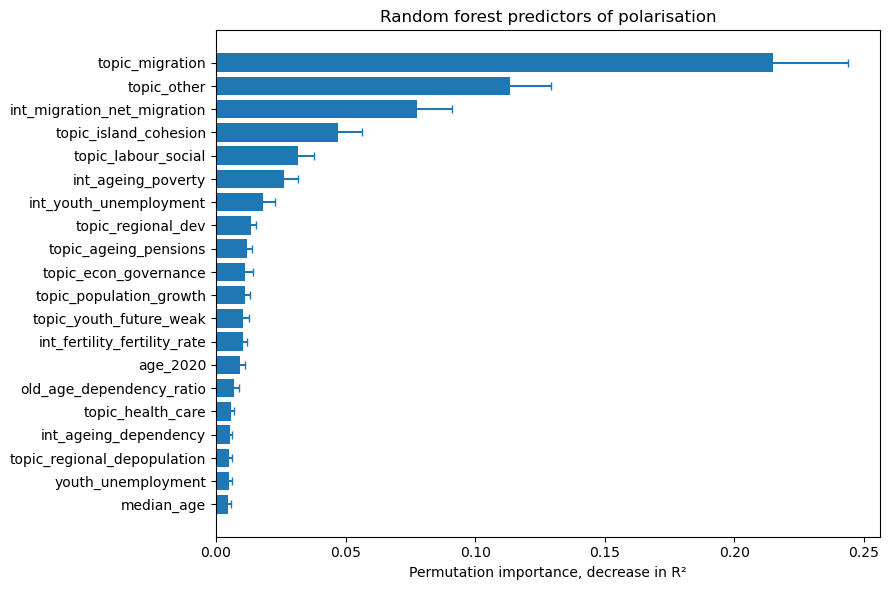

Saved: C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\7 Final Analysis\outputs\figures\random_forest_feature_importance.png

Grouped permutation importance:


,group,importance_mean,importance_sd,n_features
0,Topic shares,0.4555,0.0460,14
2,Interaction terms,0.1346,0.0178,6
1,Country context,0.0382,0.0034,13
4,Biography and party,0.0126,0.0016,7
3,Speech/age controls,0.0094,0.0020,2


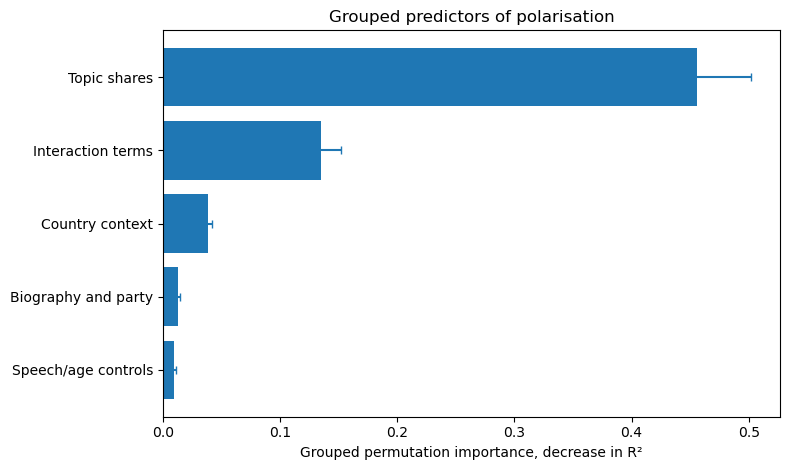

Saved: C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\7 Final Analysis\outputs\figures\random_forest_grouped_importance.png

Random forest model summary:


,metric,value
0,holdout_R2,0.1273
1,holdout_MAE,1.7182
2,holdout_RMSE,2.2038
3,cv_R2_mean,0.0475
4,cv_R2_sd,0.0810
5,cv_MAE_mean,1.6538
6,cv_MAE_sd,0.1765
7,full_sample_R2_used_for_group_importance,0.4917



Saved:
- C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\7 Final Analysis\outputs\tables\random_forest_permutation_importance.csv
- C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\7 Final Analysis\outputs\tables\random_forest_grouped_importance.csv
- C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\7 Final Analysis\outputs\tables\random_forest_model_summary.csv
- C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\7 Final Analysis\outputs\figures\random_forest_feature_importance.png
- C:\Users\Gebruiker

In [ ]:
# ============================================================
# Random forest: exploratory predictors of polarisation
# Includes topic shares, biography variables, country context,
# and theory-driven interaction terms
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print("\n" + "=" * 100)
print("RANDOM FOREST PREDICTION MODEL: POLARISATION")
print("=" * 100)

# ============================================================
# 0. Output folders
# ============================================================

if "TABLES_DIR" in globals():
    OUT_DIR = Path(TABLES_DIR)
    FIG_DIR = Path(TABLES_DIR).parent / "figures"
else:
    OUT_DIR = Path.cwd()
    FIG_DIR = Path.cwd()

OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# 1. Start from cleaned_df
# ============================================================

df_rf = cleaned_df.copy()

print("Starting dataset shape:", df_rf.shape)

if "polarisation_score" not in df_rf.columns:
    raise ValueError("cleaned_df must contain 'polarisation_score'.")

# ============================================================
# 2. Rename topic columns if needed
# ============================================================

rename_topics = {
    "Ageing & Pensions": "topic_ageing_pensions",
    "Borderline: Economic governance and employment": "topic_econ_governance",
    "Borderline: Island regions and cohesion": "topic_island_cohesion",
    "Borderline: Labour market and social policy": "topic_labour_social",
    "Borderline: Regional development policy": "topic_regional_dev",
    "Borderline: Youth / demographic future (weak signal)": "topic_youth_future_weak",
    "Fertility, Families & Gender": "topic_fertility_family_gender",
    "Health & Care Services": "topic_health_care",
    "Housing & Living Conditions": "topic_housing",
    "Migration & Population Change": "topic_migration",
    "Population Growth & Sustainability": "topic_population_growth",
    "Regional Depopulation & Territorial Cohesion": "topic_regional_depopulation",
    "Youth & Future Generations": "topic_youth_future",
    "Other": "topic_other",
}

df_rf = df_rf.rename(columns={k: v for k, v in rename_topics.items() if k in df_rf.columns})

# ============================================================
# 3. Define predictors
# ============================================================

topic_vars = [
    "topic_ageing_pensions",
    "topic_econ_governance",
    "topic_island_cohesion",
    "topic_labour_social",
    "topic_regional_dev",
    "topic_youth_future_weak",
    "topic_fertility_family_gender",
    "topic_health_care",
    "topic_housing",
    "topic_migration",
    "topic_population_growth",
    "topic_regional_depopulation",
    "topic_youth_future",
    "topic_other",
]
topic_vars = [c for c in topic_vars if c in df_rf.columns]

numeric_controls = [
    "n_relevant_speeches",
    "age_2020",
]
numeric_controls = [c for c in numeric_controls if c in df_rf.columns]

macro_vars = [
    "fertility_rate",
    "old_age_dependency_ratio",
    "median_age",
    "life_expectancy",
    "net_migration",
    "population_change",
    "gdp_per_capita_index_eu27_100",
    "employment_rate_55_64",
    "youth_unemployment",
    "debt_to_gdp",
    "age_started_receiving_old_age_pension",
    "labour_force_participation_55_64",
    "old_age_poverty_rate",
]
macro_vars = [c for c in macro_vars if c in df_rf.columns]

categorical_vars = [
    "gender_clean",
    "region_clean",
    "education_level_clean",
    "professional_background_clean",
    "prior_political_level_clean",
    "migration_background_flag",
    "international_experience_flag",
    "ep_group_clean",
]
categorical_vars = [c for c in categorical_vars if c in df_rf.columns]

# Numeric cleanup
for col in topic_vars + numeric_controls + macro_vars + ["polarisation_score"]:
    if col in df_rf.columns:
        df_rf[col] = pd.to_numeric(df_rf[col], errors="coerce")

# Standardise macro variables only for interaction construction
for col in macro_vars:
    mean = df_rf[col].mean(skipna=True)
    sd = df_rf[col].std(skipna=True)

    if pd.notna(sd) and sd > 0:
        df_rf[col + "_z"] = (df_rf[col] - mean) / sd

# Theory-driven interaction terms
interaction_specs = [
    ("topic_ageing_pensions", "old_age_dependency_ratio_z", "int_ageing_dependency"),
    ("topic_ageing_pensions", "old_age_poverty_rate_z", "int_ageing_poverty"),
    ("topic_migration", "net_migration_z", "int_migration_net_migration"),
    ("topic_fertility_family_gender", "fertility_rate_z", "int_fertility_fertility_rate"),
    ("topic_regional_depopulation", "population_change_z", "int_regional_depop_population_change"),
    ("topic_youth_future", "youth_unemployment_z", "int_youth_unemployment"),
]

interaction_vars = []

for topic, macro_z, new_col in interaction_specs:
    if topic in df_rf.columns and macro_z in df_rf.columns:
        df_rf[new_col] = df_rf[topic] * df_rf[macro_z]
        interaction_vars.append(new_col)

numeric_features = (
    topic_vars
    + numeric_controls
    + macro_vars
    + interaction_vars
)

numeric_features = [c for c in numeric_features if c in df_rf.columns]
categorical_features = [c for c in categorical_vars if c in df_rf.columns]

features_used = numeric_features + categorical_features

if not features_used:
    raise ValueError("No predictors available for random forest.")

print("\nNumeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

print("\nInteraction features:")
print(interaction_vars)

# ============================================================
# 4. Build modelling data
# ============================================================

model_df = df_rf[["polarisation_score"] + features_used].copy()
model_df = model_df[model_df["polarisation_score"].notna()].copy()

X = model_df[features_used].copy()
y = model_df["polarisation_score"].copy()

print("\nModel dataset shape:")
print(model_df.shape)

if len(model_df) < 50:
    print("WARNING: Small sample for random forest. Interpret results very cautiously.")

# ============================================================
# 5. Preprocessing and model
# ============================================================

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

# Compatibility with different scikit-learn versions
try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", onehot),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

rf = RandomForestRegressor(
    n_estimators=1000,
    max_depth=4,
    min_samples_leaf=5,
    random_state=20260715,
    n_jobs=-1
)

rf_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", rf),
])

# ============================================================
# 6. Train/test evaluation
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=20260715
)

rf_pipeline.fit(X_train, y_train)

y_pred = rf_pipeline.predict(X_test)

test_r2 = r2_score(y_test, y_pred)
test_mae = mean_absolute_error(y_test, y_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\nHoldout performance:")
print("Test R2:", round(test_r2, 3))
print("Test MAE:", round(test_mae, 3))
print("Test RMSE:", round(test_rmse, 3))

# ============================================================
# 7. Cross-validation
# ============================================================

cv = KFold(n_splits=5, shuffle=True, random_state=20260715)

cv_r2_scores = cross_val_score(
    rf_pipeline,
    X,
    y,
    cv=cv,
    scoring="r2",
    n_jobs=-1
)

cv_mae_scores = -cross_val_score(
    rf_pipeline,
    X,
    y,
    cv=cv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

print("\n5-fold cross-validation:")
print("Mean R2:", round(cv_r2_scores.mean(), 3))
print("SD R2:", round(cv_r2_scores.std(), 3))
print("Mean MAE:", round(cv_mae_scores.mean(), 3))
print("SD MAE:", round(cv_mae_scores.std(), 3))

# ============================================================
# 8. Fit full model for importance analysis
# ============================================================

rf_pipeline.fit(X, y)

baseline_pred = rf_pipeline.predict(X)
baseline_r2 = r2_score(y, baseline_pred)

print("\nFull-sample fitted R2 used for grouped permutation baseline:")
print(round(baseline_r2, 3))

# ============================================================
# 9. Permutation importance, original features
# ============================================================

perm = permutation_importance(
    rf_pipeline,
    X,
    y,
    n_repeats=50,
    random_state=20260715,
    scoring="r2",
    n_jobs=-1
)

feature_importance = pd.DataFrame({
    "feature": features_used,
    "importance_mean": perm.importances_mean,
    "importance_sd": perm.importances_std,
})

feature_importance = feature_importance.sort_values(
    "importance_mean",
    ascending=False
)

print("\nTop permutation importance features:")
display(feature_importance.head(25).round(4))

feature_importance.to_csv(
    OUT_DIR / "random_forest_permutation_importance.csv",
    index=False
)

# ============================================================
# 10. Plot top feature importances
# ============================================================

plot_df = feature_importance.head(20).copy()
plot_df = plot_df.sort_values("importance_mean", ascending=True)

plt.figure(figsize=(9, 6))

y_pos = np.arange(len(plot_df))

plt.barh(y_pos, plot_df["importance_mean"])
plt.errorbar(
    plot_df["importance_mean"],
    y_pos,
    xerr=plot_df["importance_sd"],
    fmt="none",
    capsize=3,
)

plt.yticks(y_pos, plot_df["feature"])
plt.xlabel("Permutation importance, decrease in R²")
plt.ylabel("")
plt.title("Random forest predictors of polarisation")

plt.tight_layout()

feature_imp_path = FIG_DIR / "random_forest_feature_importance.png"
plt.savefig(feature_imp_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", feature_imp_path)

# ============================================================
# 11. Grouped permutation importance
# ============================================================

feature_groups = {
    "Topic shares": topic_vars,
    "Country context": macro_vars,
    "Interaction terms": interaction_vars,
    "Speech/age controls": numeric_controls,
    "Biography and party": categorical_features,
}

group_rows = []
rng = np.random.default_rng(20260715)

for group_name, group_features in feature_groups.items():
    group_features = [c for c in group_features if c in X.columns]

    if not group_features:
        continue

    drops = []

    for repeat in range(50):
        X_perm = X.copy()

        for col in group_features:
            X_perm[col] = rng.permutation(X_perm[col].values)

        pred_perm = rf_pipeline.predict(X_perm)
        perm_r2 = r2_score(y, pred_perm)

        drops.append(baseline_r2 - perm_r2)

    group_rows.append({
        "group": group_name,
        "importance_mean": np.mean(drops),
        "importance_sd": np.std(drops),
        "n_features": len(group_features),
    })

group_importance = pd.DataFrame(group_rows).sort_values(
    "importance_mean",
    ascending=False
)

print("\nGrouped permutation importance:")
display(group_importance.round(4))

group_importance.to_csv(
    OUT_DIR / "random_forest_grouped_importance.csv",
    index=False
)

# Plot grouped importance
plot_df = group_importance.sort_values("importance_mean", ascending=True)

plt.figure(figsize=(8, 4.8))

y_pos = np.arange(len(plot_df))

plt.barh(y_pos, plot_df["importance_mean"])
plt.errorbar(
    plot_df["importance_mean"],
    y_pos,
    xerr=plot_df["importance_sd"],
    fmt="none",
    capsize=3,
)

plt.yticks(y_pos, plot_df["group"])
plt.xlabel("Grouped permutation importance, decrease in R²")
plt.ylabel("")
plt.title("Grouped predictors of polarisation")

plt.tight_layout()

group_imp_path = FIG_DIR / "random_forest_grouped_importance.png"
plt.savefig(group_imp_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", group_imp_path)

# ============================================================
# 12. Save model summary
# ============================================================

rf_summary = pd.DataFrame([
    {
        "metric": "holdout_R2",
        "value": test_r2,
    },
    {
        "metric": "holdout_MAE",
        "value": test_mae,
    },
    {
        "metric": "holdout_RMSE",
        "value": test_rmse,
    },
    {
        "metric": "cv_R2_mean",
        "value": cv_r2_scores.mean(),
    },
    {
        "metric": "cv_R2_sd",
        "value": cv_r2_scores.std(),
    },
    {
        "metric": "cv_MAE_mean",
        "value": cv_mae_scores.mean(),
    },
    {
        "metric": "cv_MAE_sd",
        "value": cv_mae_scores.std(),
    },
    {
        "metric": "full_sample_R2_used_for_group_importance",
        "value": baseline_r2,
    },
])

rf_summary.to_csv(
    OUT_DIR / "random_forest_model_summary.csv",
    index=False
)

print("\nRandom forest model summary:")
display(rf_summary.round(4))

print("\nSaved:")
print("-", OUT_DIR / "random_forest_permutation_importance.csv")
print("-", OUT_DIR / "random_forest_grouped_importance.csv")
print("-", OUT_DIR / "random_forest_model_summary.csv")
print("-", FIG_DIR / "random_forest_feature_importance.png")
print("-", FIG_DIR / "random_forest_grouped_importance.png")

In [ ]:
# ============================================================
# Cross-validation, safe version
# ============================================================

from sklearn.model_selection import KFold, cross_val_score

cv = KFold(n_splits=5, shuffle=True, random_state=20260715)

cv_r2_scores = cross_val_score(
    rf_pipeline,
    X,
    y,
    cv=cv,
    scoring="r2",
    n_jobs=-1
)

cv_mae_scores = -cross_val_score(
    rf_pipeline,
    X,
    y,
    cv=cv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

print("\n5-fold cross-validation:")
print("Mean R2:", round(cv_r2_scores.mean(), 3))
print("SD R2:", round(cv_r2_scores.std(), 3))
print("Mean MAE:", round(cv_mae_scores.mean(), 3))
print("SD MAE:", round(cv_mae_scores.std(), 3))


5-fold cross-validation:
Mean R2: 0.048
SD R2: 0.081
Mean MAE: 1.654
SD MAE: 0.177


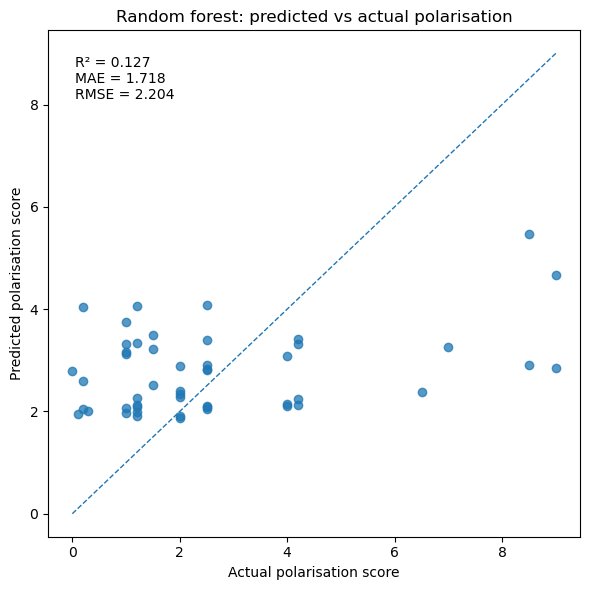

Saved: C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\7 Final Analysis\outputs\figures\random_forest_predicted_vs_actual.png


In [ ]:
# ============================================================
# RF result: predicted vs actual polarisation
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

if "TABLES_DIR" in globals():
    OUT_DIR = Path(TABLES_DIR)
    FIG_DIR = Path(TABLES_DIR).parent / "figures"
else:
    OUT_DIR = Path.cwd()
    FIG_DIR = Path.cwd()

FIG_DIR.mkdir(parents=True, exist_ok=True)

# Uses y_test and y_pred from the train/test RF block
plot_df = pd.DataFrame({
    "actual": y_test,
    "predicted": y_pred,
})

test_r2 = r2_score(plot_df["actual"], plot_df["predicted"])
test_mae = mean_absolute_error(plot_df["actual"], plot_df["predicted"])
test_rmse = np.sqrt(mean_squared_error(plot_df["actual"], plot_df["predicted"]))

plt.figure(figsize=(6, 6))

plt.scatter(plot_df["actual"], plot_df["predicted"], alpha=0.75)

min_val = min(plot_df["actual"].min(), plot_df["predicted"].min())
max_val = max(plot_df["actual"].max(), plot_df["predicted"].max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--", linewidth=1)

plt.xlabel("Actual polarisation score")
plt.ylabel("Predicted polarisation score")
plt.title("Random forest: predicted vs actual polarisation")

plt.text(
    0.05,
    0.95,
    f"R² = {test_r2:.3f}\nMAE = {test_mae:.3f}\nRMSE = {test_rmse:.3f}",
    transform=plt.gca().transAxes,
    va="top",
)

plt.tight_layout()

pred_actual_path = FIG_DIR / "random_forest_predicted_vs_actual.png"
plt.savefig(pred_actual_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", pred_actual_path)

## Influence Analysis: Polarisation vs Individual + Country Characteristics

This block estimates how strongly individual and country-level characteristics are associated with each polarisation variable.

Approach used:
- Missing-aware preprocessing (median/mode imputation).
- One-hot encoding for categorical predictors.
- Random Forest models for flexible associations.
- 5-fold cross-validated $R^2$ for continuous outcomes.
- Balanced accuracy for `dominant_cluster` (classification).
- Permutation importance to rank drivers.


In [ ]:
# Only (re)set analysis_df if the cleaned columns from the cleaning block are absent.

if 'analysis_df' not in globals() or not isinstance(analysis_df, pd.DataFrame) or 'ep_group_clean' not in analysis_df.columns:
    analysis_df = mep_only_polarisation_with_demography.copy()
FIGURE_OUTPUT_DIR = FIGURES_DIR
FIGURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def _compact_fig_name(filename):
    stem = Path(filename).stem.lower()
    stem = re.sub(r"[^a-z0-9]+", "_", stem).strip("_")
    token_map = {
        "descriptive": "desc", "polarisation": "pol", "correlation": "corr",
        "random": "rf", "forest": "rf", "association": "assoc", "strength": "str",
        "feature": "feat", "importance": "imp", "cluster": "cl", "country": "cty",
        "topic": "tp", "group": "grp", "party": "pty", "profile": "prof",
        "interaction": "int", "interactions": "ints", "composition": "comp",
        "prevalence": "prev", "outcome": "out", "outcomes": "outs",
        "distribution": "dist", "distributions": "dists", "heatmap": "hm",
        "scatter": "scat", "ranking": "rank", "silhouette": "sil",
        "high": "hi", "low": "lo", "absolute": "abs", "professional": "prof",
        "background": "bg",
    }
    parts = [token_map.get(p, p[:4]) for p in stem.split("_") if p]
    compact = "_".join(parts)
    compact = (compact[:48].rstrip("_") or "fig")
    return f"{compact}.png"
def save_figure(filename):
    plt.savefig(FIGURE_OUTPUT_DIR / _compact_fig_name(filename), dpi=300, bbox_inches="tight")
polarisation_targets_continuous = [
    "n_relevant_speeches",
    "dominant_cluster_score",
    "polarisation_score",
    "confidence",
    "us_vs_them",
    "emotional_intensity",
    "moral_absolutism",
    "hostility_to_opponents",
]
polarisation_target_class = "dominant_cluster"
individual_predictors = [
    "birth_date_extracted",
    "place_of_birth_extracted",
    "country_of_origin_extracted",
    "ep_group_clean",
    "ep_group_extracted",
    "mep_since_extracted",
    "occupations_extracted",
    "parties_extracted",
    "education_extracted",
    "gender_bucket",
    "region_clean",
    "region_bucket",
    "education_level_bucket",
    "education_field_clean",
    "education_field_bucket",
    "professional_background_clean",
    "professional_background_bucket",
    "religion_mentioned_flag",
    "religion_bucket",
    "parental_status_known",
    "has_children_if_known",
    "parental_status_bucket",
    "migration_background_flag",
    "migration_background_bucket",
    "international_experience_flag",
    "international_experience_bucket",
    "military_background_flag",
    "military_background_bucket",
    "prior_political_level_bucket",
]
country_predictors = [
    "fertility_rate",
    "old_age_dependency_ratio",
    "median_age",
    "life_expectancy",
    "net_migration",
    "population_change",
    "gdp_per_capita_index_eu27_100",
    "employment_rate_55_64",
    "youth_unemployment",
    "debt_to_gdp",
]
available_predictors = [c for c in (individual_predictors + country_predictors) if c in analysis_df.columns]
missing_predictors = [c for c in (individual_predictors + country_predictors) if c not in analysis_df.columns]
analysis_df["birth_year_extracted"] = (
    analysis_df.get("birth_date_extracted", pd.Series(index=analysis_df.index))
    .astype(str)
    .str.extract(r"(\d{4})", expand=False)
    .pipe(pd.to_numeric, errors="coerce")
)
analysis_df["age_approx_2020"] = 2020 - analysis_df["birth_year_extracted"]
analysis_df["mep_since_year"] = (
    analysis_df.get("mep_since_extracted", pd.Series(index=analysis_df.index))
    .astype(str)
    .str.extract(r"(\d{4})", expand=False)
    .pipe(pd.to_numeric, errors="coerce")
)
analysis_df["mep_tenure_approx_2020"] = 2020 - analysis_df["mep_since_year"]

def _safe_list_len(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if not s:
        return np.nan
    try:
        val = json.loads(s)
        if isinstance(val, list):
            return float(len(val))
    except Exception:
        pass
    return np.nan
for c in ["occupations_extracted", "parties_extracted", "education_extracted"]:
    if c in analysis_df.columns:
        analysis_df[f"{c}_n_items"] = analysis_df[c].map(_safe_list_len)
engineered_predictors = [
    "age_approx_2020",
    "mep_tenure_approx_2020",
    "occupations_extracted_n_items",
    "parties_extracted_n_items",
    "education_extracted_n_items",
]
engineered_predictors = [c for c in engineered_predictors if c in analysis_df.columns]
topic_regex = re.compile(r"topic|cluster|theme|subject", flags=re.IGNORECASE)
exclude_topic_cols = set([
    polarisation_target_class,
    "dominant_cluster_score",
    "polarisation_score",
    "confidence",
    "us_vs_them",
    "emotional_intensity",
    "moral_absolutism",
    "hostility_to_opponents",
    "n_relevant_speeches",
])
topic_candidate_cols = [
    c for c in analysis_df.columns
    if topic_regex.search(str(c)) and c not in exclude_topic_cols
]
topic_candidate_cols = [
    c for c in topic_candidate_cols
    if analysis_df[c].notna().sum() > 0
]
topic_numeric_cols = []
topic_categorical_cols = []

for c in topic_candidate_cols:
    if pd.api.types.is_numeric_dtype(analysis_df[c]):
        topic_numeric_cols.append(c)
    else:
        topic_categorical_cols.append(c)
topic_share_cols = [
    c for c in topic_numeric_cols
    if re.search(r"share|prop|pct|percent|weight|prob|topic_\d+|cluster_\d+", str(c), flags=re.IGNORECASE)
]
topic_engineered_predictors = []

if len(topic_share_cols) >= 2:
    analysis_df["topic_most_talked"] = analysis_df[topic_share_cols].idxmax(axis=1)
    topic_engineered_predictors.append("topic_most_talked")
    analysis_df["topic_most_talked_share"] = analysis_df[topic_share_cols].max(axis=1)
    topic_engineered_predictors.append("topic_most_talked_share")
    row_sums = analysis_df[topic_share_cols].sum(axis=1).replace(0, np.nan)
    norm_topic = analysis_df[topic_share_cols].div(row_sums, axis=0)
    analysis_df["topic_focus_hhi"] = (norm_topic ** 2).sum(axis=1)
    topic_engineered_predictors.append("topic_focus_hhi")
    eps = 1e-12
    analysis_df["topic_entropy"] = -(norm_topic.fillna(0) * np.log(norm_topic.fillna(0) + eps)).sum(axis=1)
    topic_engineered_predictors.append("topic_entropy")
    for base_col in ["us_vs_them", "emotional_intensity", "moral_absolutism", "hostility_to_opponents"]:
        if base_col in analysis_df.columns:
            inter_col = f"{base_col}_x_topic_focus"
            analysis_df[inter_col] = pd.to_numeric(analysis_df[base_col], errors="coerce") * analysis_df["topic_focus_hhi"]
            topic_engineered_predictors.append(inter_col)
topic_predictors_all = topic_numeric_cols + topic_categorical_cols + topic_engineered_predictors
topic_predictors_all = [c for c in topic_predictors_all if c in analysis_df.columns]
predictors = available_predictors + engineered_predictors + topic_predictors_all
predictors = list(dict.fromkeys(predictors))
numeric_features = [c for c in predictors if pd.api.types.is_numeric_dtype(analysis_df[c])]
categorical_features = [c for c in predictors if c not in numeric_features]
print("Predictors used:", len(predictors))
print(" - Numeric:", len(numeric_features))
print(" - Categorical:", len(categorical_features))
print("Topic predictors used:", len(topic_predictors_all))

if topic_predictors_all:
    print("Topic-related columns included:", topic_predictors_all)
if missing_predictors:
    print("Predictors not found in dataframe:", missing_predictors)

Predictors used: 36
 - Numeric: 5
 - Categorical: 31
Topic predictors used: 2
Topic-related columns included: ['dominant_cluster_cached', 'dominant_topic']
Predictors not found in dataframe: ['fertility_rate', 'old_age_dependency_ratio', 'median_age', 'life_expectancy', 'net_migration', 'population_change', 'gdp_per_capita_index_eu27_100', 'employment_rate_55_64', 'youth_unemployment', 'debt_to_gdp']


In [ ]:
# --- Model-based association analysis ---
preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore")),
        ]), categorical_features),
    ],
    remainder="drop",
)
cv = KFold(n_splits=5, shuffle=True, random_state=42)
association_results = []
importance_tables = {}

# Continuous outcomes

for target in polarisation_targets_continuous:
    if target not in analysis_df.columns:
        continue
    data = analysis_df[predictors + [target]].copy()
    data[target] = pd.to_numeric(data[target], errors="coerce")
    data = data.dropna(subset=[target])
    if len(data) < 40:
        association_results.append({
            "target": target,
            "task": "regression",
            "n_rows": len(data),
            "cv_score_mean": np.nan,
            "cv_score_std": np.nan,
            "note": "Too few rows for reliable CV.",
        })
        continue
    X = data[predictors]
    y = data[target]
    model = Pipeline([
        ("prep", preprocessor),
        ("rf", RandomForestRegressor(
            n_estimators=800,
            random_state=42,
            min_samples_leaf=3,
            n_jobs=-1,
        )),
    ])
    scores = cross_val_score(model, X, y, cv=cv, scoring="r2")
    association_results.append({
        "target": target,
        "task": "regression",
        "n_rows": len(data),
        "cv_score_mean": float(np.mean(scores)),
        "cv_score_std": float(np.std(scores)),
        "note": "CV R2 (higher means stronger explainable association).",
    })
    # Permutation importance on a held-out set for interpretability.
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42
    )
    model.fit(X_train, y_train)
    perm = permutation_importance(
        model, X_test, y_test, n_repeats=20, random_state=42, n_jobs=-1, scoring="r2"
    )
    imp = pd.DataFrame({
        "feature": X.columns,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std,
    }).sort_values("importance_mean", ascending=False)
    importance_tables[target] = imp
# Categorical outcome (dominant cluster)

if polarisation_target_class in analysis_df.columns:
    data = analysis_df[predictors + [polarisation_target_class]].copy()
    data = data.dropna(subset=[polarisation_target_class])
    if data[polarisation_target_class].nunique() > 1 and len(data) >= 40:
        X = data[predictors]
        y = data[polarisation_target_class].astype(str)
        model_cls = Pipeline([
            ("prep", preprocessor),
            ("rf", RandomForestClassifier(
                n_estimators=800,
                random_state=42,
                min_samples_leaf=2,
                class_weight="balanced",
                n_jobs=-1,
            )),
        ])
        # Fit once and report holdout balanced accuracy for an interpretable scale.
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.25, random_state=42, stratify=y
        )
        model_cls.fit(X_train, y_train)
        y_pred = model_cls.predict(X_test)
        bal_acc = balanced_accuracy_score(y_test, y_pred)
        association_results.append({
            "target": polarisation_target_class,
            "task": "classification",
            "n_rows": len(data),
            "cv_score_mean": float(bal_acc),
            "cv_score_std": np.nan,
            "note": "Holdout balanced accuracy (higher means better separability by characteristics).",
        })
# Present summary table
association_summary_df = pd.DataFrame(association_results).sort_values(["task", "cv_score_mean"], ascending=[True, False])
display(association_summary_df)

# Show top drivers per continuous target

for target, imp_df in importance_tables.items():
    print(f"\nTop predictors for {target}:")
    display(imp_df.head(12))

,target,task,n_rows,cv_score_mean,cv_score_std,note
8,dominant_cluster,classification,193,0.833333,NaN,Holdout balanced accuracy (higher means better...
5,emotional_intensity,regression,193,-0.070339,0.112684,CV R2 (higher means stronger explainable assoc...
7,hostility_to_opponents,regression,193,-0.074526,0.134458,CV R2 (higher means stronger explainable assoc...
4,us_vs_them,regression,193,-0.095405,0.144774,CV R2 (higher means stronger explainable assoc...
2,polarisation_score,regression,193,-0.096882,0.107809,CV R2 (higher means stronger explainable assoc...
6,moral_absolutism,regression,193,-0.103851,0.094207,CV R2 (higher means stronger explainable assoc...
3,confidence,regression,193,-0.142439,0.071231,CV R2 (higher means stronger explainable assoc...
0,n_relevant_speeches,regression,193,-0.763142,1.510802,CV R2 (higher means stronger explainable assoc...
1,dominant_cluster_score,regression,0,NaN,NaN,Too few rows for reliable CV.



Top predictors for n_relevant_speeches:


,feature,importance_mean,importance_std
3,ep_group_clean,0.068394,0.045354
2,country_of_origin_extracted,0.028945,0.009424
34,dominant_cluster_cached,0.013726,0.026971
12,education_level_bucket,0.011566,0.017220
30,mep_tenure_approx_2020,0.009522,0.010923
35,dominant_topic,0.009387,0.023564
11,region_bucket,0.006891,0.005362
33,education_extracted_n_items,0.006739,0.003863
10,region_clean,0.006303,0.005399
32,parties_extracted_n_items,0.005109,0.009056



Top predictors for polarisation_score:


,feature,importance_mean,importance_std
30,mep_tenure_approx_2020,0.056762,0.042649
13,education_field_clean,0.020975,0.012151
14,education_field_bucket,0.010690,0.010998
35,dominant_topic,0.006892,0.009043
4,ep_group_extracted,0.004860,0.005310
31,occupations_extracted_n_items,0.004095,0.011145
25,international_experience_bucket,0.003720,0.002288
34,dominant_cluster_cached,0.003289,0.008601
24,international_experience_flag,0.002490,0.002840
18,religion_bucket,0.000931,0.000948



Top predictors for confidence:


,feature,importance_mean,importance_std
12,education_level_bucket,0.021463,0.015185
32,parties_extracted_n_items,0.010523,0.014539
35,dominant_topic,0.008940,0.007313
31,occupations_extracted_n_items,0.007545,0.010626
16,professional_background_bucket,0.007270,0.008148
34,dominant_cluster_cached,0.003818,0.005507
30,mep_tenure_approx_2020,0.002599,0.008949
29,age_approx_2020,0.002458,0.024154
5,mep_since_extracted,0.002146,0.006092
19,parental_status_known,0.001928,0.002120



Top predictors for us_vs_them:


,feature,importance_mean,importance_std
35,dominant_topic,0.019337,0.010246
30,mep_tenure_approx_2020,0.014828,0.063418
32,parties_extracted_n_items,0.014641,0.009206
34,dominant_cluster_cached,0.013727,0.010011
24,international_experience_flag,0.006257,0.004597
25,international_experience_bucket,0.004726,0.002742
13,education_field_clean,0.003577,0.013458
14,education_field_bucket,0.002701,0.011690
7,parties_extracted,0.002204,0.015018
15,professional_background_clean,0.001941,0.008903



Top predictors for emotional_intensity:


,feature,importance_mean,importance_std
30,mep_tenure_approx_2020,0.113778,0.059222
14,education_field_bucket,0.019330,0.012769
2,country_of_origin_extracted,0.018500,0.042160
13,education_field_clean,0.016779,0.009169
29,age_approx_2020,0.011324,0.021052
35,dominant_topic,0.009993,0.007824
7,parties_extracted,0.008992,0.020482
28,prior_political_level_bucket,0.008294,0.013021
34,dominant_cluster_cached,0.006736,0.009309
32,parties_extracted_n_items,0.006179,0.006721



Top predictors for moral_absolutism:


,feature,importance_mean,importance_std
30,mep_tenure_approx_2020,0.056499,0.044335
13,education_field_clean,0.027332,0.013128
14,education_field_bucket,0.018089,0.011154
29,age_approx_2020,0.016576,0.021175
33,education_extracted_n_items,0.010051,0.022743
25,international_experience_bucket,0.005283,0.002095
28,prior_political_level_bucket,0.003833,0.011247
34,dominant_cluster_cached,0.003694,0.007499
4,ep_group_extracted,0.002944,0.008167
9,gender_bucket,0.001118,0.003313



Top predictors for hostility_to_opponents:


,feature,importance_mean,importance_std
30,mep_tenure_approx_2020,3.126379e-02,5.132175e-02
35,dominant_topic,1.588237e-02,9.114373e-03
32,parties_extracted_n_items,1.381983e-02,1.025029e-02
24,international_experience_flag,7.767006e-03,5.656971e-03
34,dominant_cluster_cached,7.011584e-03,9.674611e-03
25,international_experience_bucket,6.913338e-03,3.926575e-03
14,education_field_bucket,6.362950e-03,1.155218e-02
13,education_field_clean,4.344454e-03,1.296781e-02
6,occupations_extracted,2.568423e-03,3.595949e-03
9,gender_bucket,1.389380e-04,1.376501e-02


In [ ]:
# --- Visualize Random Forest outputs ---
# Make plots readable in notebook output.
sns.set_theme(style="whitegrid", context="notebook")

def pretty_display_name(value):
    text = str(value)
    text = re.sub(r"^z_", "", text)
    text = text.replace("_x_", " x " ).replace("__", " " ).replace("_", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text.title()
FIGURE_OUTPUT_DIR = globals().get("FIGURE_OUTPUT_DIR", PROJECT_ROOT / "7 Final Analysis" / "figures")
FIGURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def _compact_fig_name(filename):
    stem = Path(filename).stem.lower()
    stem = re.sub(r"[^a-z0-9]+", "_", stem).strip("_")
    token_map = {
        "descriptive": "desc", "polarisation": "pol", "correlation": "corr",
        "random": "rf", "forest": "rf", "association": "assoc", "strength": "str",
        "feature": "feat", "importance": "imp", "cluster": "cl", "country": "cty",
        "topic": "tp", "group": "grp", "party": "pty", "profile": "prof",
        "interaction": "int", "interactions": "ints", "composition": "comp",
        "prevalence": "prev", "outcome": "out", "outcomes": "outs",
        "distribution": "dist", "distributions": "dists", "heatmap": "hm",
        "scatter": "scat", "ranking": "rank", "silhouette": "sil",
        "high": "hi", "low": "lo", "absolute": "abs", "professional": "prof",
        "background": "bg",
    }
    parts = [token_map.get(p, p[:4]) for p in stem.split("_") if p]
    compact = "_".join(parts)
    compact = (compact[:48].rstrip("_") or "fig")
    return f"{compact}.png"
def save_figure(filename):
    plt.savefig(FIGURE_OUTPUT_DIR / _compact_fig_name(filename), dpi=300, bbox_inches="tight")
if "association_summary_df" not in globals() or "importance_tables" not in globals():
    raise RuntimeError("Please run the Random Forest block above first to generate outputs.")
# 1) Model-level performance summary plot.
rf_summary_plot = association_summary_df.copy()
rf_summary_plot = rf_summary_plot.dropna(subset=["cv_score_mean"])

if not rf_summary_plot.empty:
    plt.figure(figsize=(10, max(4, 0.45 * len(rf_summary_plot))))
    order = rf_summary_plot.sort_values("cv_score_mean", ascending=True)["target"]
    ax = sns.barplot(
        data=rf_summary_plot,
        y="target",
        x="cv_score_mean",
        hue="task",
        order=order,
        dodge=False,
        palette={"regression": "#1f77b4", "classification": "#ff7f0e"},
    )
    ax.set_title("Random Forest Association Strength by Outcome")
    ax.set_xlabel("Score (CV R2 for regression, balanced accuracy for classification)")
    ax.set_ylabel("Outcome")
    ax.legend(title="Task", loc="lower right")
    plt.tight_layout()
    save_figure("random_forest_association_strength_by_outcome.png")
    # Save this figure from this plotting block
    if "FIGURES_DIR" in globals():
        _fig_save_dir = FIGURES_DIR
    elif "FIGURES_OUT_DIR" in globals():
        _fig_save_dir = FIGURES_OUT_DIR
    else:
        _fig_save_dir = (PROJECT_ROOT if "PROJECT_ROOT" in globals() else Path.cwd()) / "outputs" / "figures"
    _fig_save_dir.mkdir(parents=True, exist_ok=True)
    _fig_out = _fig_save_dir / f"cell_15_plot_001.png"
    plt.savefig(_fig_out, dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("No non-null scores found in association_summary_df.")
# 2) Top feature importances by outcome (small multiples).

if len(importance_tables) == 0:
    print("No feature importance tables found. Ensure the Random Forest block completed successfully.")
else:
    outcomes = list(importance_tables.keys())
    n_outcomes = len(outcomes)
    n_cols = 2
    n_rows = int(np.ceil(n_outcomes / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4.0 * n_rows), squeeze=False)
    axes_flat = axes.flatten()
    for idx, outcome in enumerate(outcomes):
        imp_df = importance_tables[outcome].copy()
        imp_top = imp_df.head(8).sort_values("importance_mean", ascending=True)
        ax = axes_flat[idx]
        sns.barplot(
            data=imp_top,
            x="importance_mean",
            y="feature",
            ax=ax,
            color="#2ca02c",
        )
        ax.set_title(f"Top RF Drivers: {outcome}")
        ax.set_xlabel("Permutation importance (mean)")
        ax.set_ylabel("Feature")
    # Hide unused subplot panels if outcomes are odd.
    for j in range(n_outcomes, len(axes_flat)):
        axes_flat[j].axis("off")
    plt.tight_layout()
    save_figure("random_forest_top_feature_importances.png")
    # Save this figure from this plotting block
    if "FIGURES_DIR" in globals():
        _fig_save_dir = FIGURES_DIR
    elif "FIGURES_OUT_DIR" in globals():
        _fig_save_dir = FIGURES_OUT_DIR
    else:
        _fig_save_dir = (PROJECT_ROOT if "PROJECT_ROOT" in globals() else Path.cwd()) / "outputs" / "figures"
    _fig_save_dir.mkdir(parents=True, exist_ok=True)
    _fig_out = _fig_save_dir / f"cell_15_plot_002.png"
    plt.savefig(_fig_out, dpi=300, bbox_inches="tight")
    plt.show()
# 3) Compact heatmap: top-5 features per outcome, for cross-outcome comparison.
rows = []

for outcome, imp_df in importance_tables.items():
    tmp = imp_df.head(5).copy()
    tmp["outcome"] = outcome
    rows.append(tmp[["outcome", "feature", "importance_mean"]])
if rows:
    top_matrix = pd.concat(rows, ignore_index=True)
    heat_df = top_matrix.pivot_table(
        index="feature",
        columns="outcome",
        values="importance_mean",
        aggfunc="mean",
        fill_value=0.0,
    )
    # Keep the most globally important features for readability.
    keep_n = min(20, len(heat_df))
    ordered_features = heat_df.mean(axis=1).sort_values(ascending=False).head(keep_n).index
    heat_df = heat_df.loc[ordered_features]
    plt.figure(figsize=(12, max(5, 0.35 * len(heat_df))))
    sns.heatmap(heat_df, cmap="YlGnBu", linewidths=0.3, cbar_kws={"label": "Importance"})
    plt.title("Random Forest Importance Heatmap (Top Features Across Outcomes)")
    plt.xlabel("Outcome")
    plt.ylabel("Feature")
    plt.tight_layout()
    save_figure("random_forest_importance_heatmap.png")
    # Save this figure from this plotting block
    if "FIGURES_DIR" in globals():
        _fig_save_dir = FIGURES_DIR
    elif "FIGURES_OUT_DIR" in globals():
        _fig_save_dir = FIGURES_OUT_DIR
    else:
        _fig_save_dir = (PROJECT_ROOT if "PROJECT_ROOT" in globals() else Path.cwd()) / "outputs" / "figures"
    _fig_save_dir.mkdir(parents=True, exist_ok=True)
    _fig_out = _fig_save_dir / f"cell_15_plot_003.png"
    plt.savefig(_fig_out, dpi=300, bbox_inches="tight")
    plt.show()
# 4) Topic-specific importance summary (explicitly isolates topic effects).

if "topic_predictors_all" in globals() and len(topic_predictors_all) > 0:
    topic_rows = []
    for outcome, imp_df in importance_tables.items():
        topic_imp = imp_df[imp_df["feature"].isin(topic_predictors_all)].copy()
        if topic_imp.empty:
            continue
        topic_imp = topic_imp.sort_values("importance_mean", ascending=False).head(10)
        topic_imp["outcome"] = outcome
        topic_rows.append(topic_imp[["outcome", "feature", "importance_mean", "importance_std"]])
    if topic_rows:
        topic_importance_summary = pd.concat(topic_rows, ignore_index=True)
        print("Top topic-related predictors by outcome:")
        display(topic_importance_summary)
    else:
        print("Topic features were detected, but they did not appear among top permutation importances.")
else:
    print("No topic feature set was detected in the feature-engineering block.")

RuntimeError: Please run the Random Forest block above first to generate outputs.

## Cluster Analysis: Polarisation + Topic Profiles

This section identifies latent MEP profiles using a cluster model that combines:
- Polarisation dimensions (`us_vs_them`, `emotional_intensity`, `moral_absolutism`, `hostility_to_opponents`, `polarisation_score`).
- Topic-related features (including "most talked" proxies when available).

What this adds beyond Random Forest:
- Unsupervised structure discovery (who looks similar in discourse profile).
- Interpretable cluster profiles by polarisation and topic mix.
- Data-driven cluster count selection with silhouette scores.

Note: this is exploratory clustering, not causal inference.

What this section does:
- Clarifies the purpose of this section and how it connects to the next steps.
- Summarizes expected inputs and outputs to make reruns easier to follow.


c:\Users\Gebruiker\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Gebruiker\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Gebruiker\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Gebruiker\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memor

Best k by silhouette: 2


,k,silhouette
0,2,0.742304
1,3,0.681516
2,4,0.528230
3,5,0.565389
4,6,0.572775
5,7,0.576302
6,8,0.582168


c:\Users\Gebruiker\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,n_obs
topic_polarisation_cluster,
0.0,117
1.0,22


,us_vs_them,emotional_intensity,moral_absolutism,hostility_to_opponents,polarisation_score
topic_polarisation_cluster,,,,,
0.0,0.874,1.190,0.890,0.404,1.861
1.0,5.645,5.714,6.168,5.227,6.300


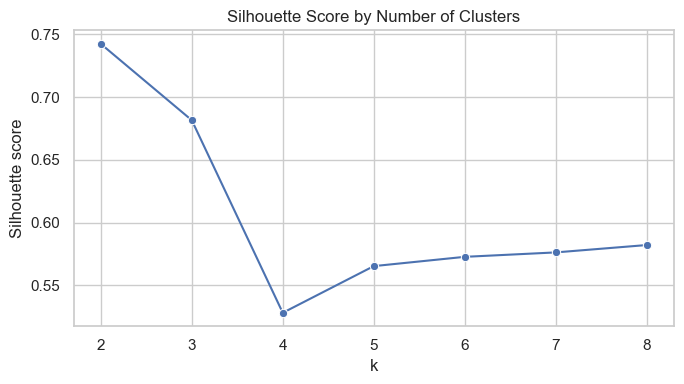

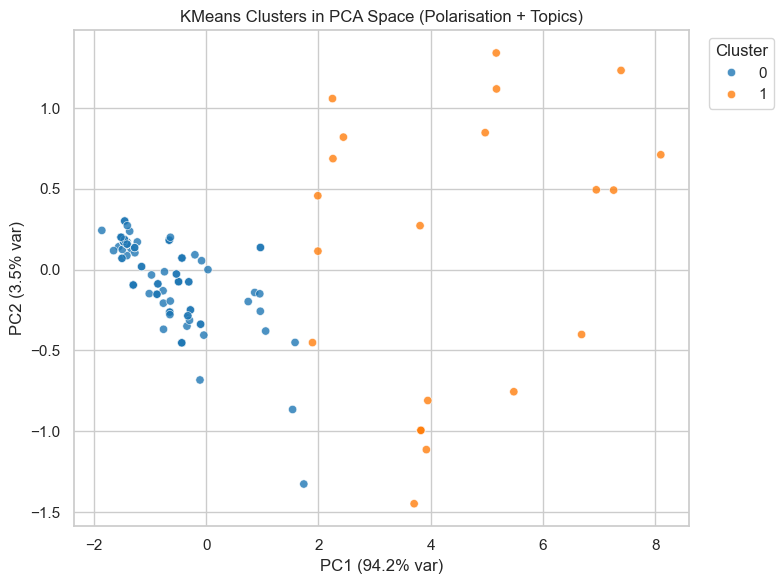

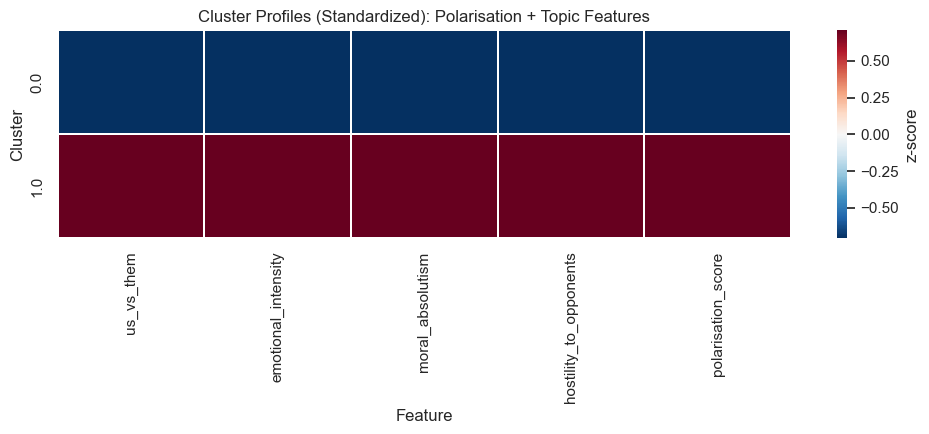

In [ ]:
# --- Topic-aware cluster analysis ---
# 1) Build clustering feature set: polarisation outcomes + topic features.
cluster_base_features = [
    c for c in [
        "us_vs_them",
        "emotional_intensity",
        "moral_absolutism",
        "hostility_to_opponents",
        "polarisation_score",
    ]
    if c in analysis_df.columns
]
topic_numeric_for_cluster = []

if "topic_predictors_all" in globals():
    topic_numeric_for_cluster = [
        c for c in topic_predictors_all
        if c in analysis_df.columns and pd.api.types.is_numeric_dtype(analysis_df[c])
    ]
cluster_features = list(dict.fromkeys(cluster_base_features + topic_numeric_for_cluster))

if len(cluster_features) < 2:
    raise RuntimeError(
        "Not enough clustering features found. Need at least 2 numeric polarisation/topic features."
    )
cluster_df = analysis_df[cluster_features].copy()

# Median impute for clustering (keeps observations with partial data).
cluster_df = cluster_df.apply(pd.to_numeric, errors="coerce")
cluster_df = cluster_df.fillna(cluster_df.median(numeric_only=True))

# Remove rows that are still fully missing after imputation edge-cases.
cluster_df = cluster_df.dropna(how="all")

if len(cluster_df) < 30:
    raise RuntimeError("Too few rows for stable clustering after filtering.")
# 2) Standardize features for fair distance-based clustering.
scaler = StandardScaler()
X_cluster = scaler.fit_transform(cluster_df)

# 3) Select number of clusters k via silhouette score.
k_candidates = list(range(2, min(9, len(cluster_df) - 1)))
cluster_eval_rows = []

for k in k_candidates:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_cluster)
    sil = silhouette_score(X_cluster, labels)
    cluster_eval_rows.append({"k": k, "silhouette": sil})
cluster_eval_df = pd.DataFrame(cluster_eval_rows).sort_values("silhouette", ascending=False)
best_k = int(cluster_eval_df.iloc[0]["k"])
print("Best k by silhouette:", best_k)
display(cluster_eval_df.sort_values("k"))

# 4) Fit final model using best k and store labels in analysis_df.
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=30)
final_labels = kmeans_final.fit_predict(X_cluster)

# Align labels back to original index.
cluster_result = pd.Series(final_labels, index=cluster_df.index, name="topic_polarisation_cluster")
analysis_df["topic_polarisation_cluster"] = np.nan
analysis_df.loc[cluster_result.index, "topic_polarisation_cluster"] = cluster_result

# 5) Cluster profile table: means by cluster for all clustering features.
cluster_profile = (
    analysis_df.loc[cluster_result.index, cluster_features + ["topic_polarisation_cluster"]]
    .groupby("topic_polarisation_cluster", as_index=True)
    .mean(numeric_only=True)
    .round(3)
)
cluster_sizes = analysis_df.loc[cluster_result.index, "topic_polarisation_cluster"].value_counts().sort_index()
display(cluster_sizes.rename("n_obs").to_frame())
display(cluster_profile)

# 6) Visual diagnostics: silhouette curve + PCA scatter + cluster profile heatmap.
sns.set_theme(style="whitegrid", context="notebook")
FIGURE_OUTPUT_DIR = globals().get("FIGURE_OUTPUT_DIR", PROJECT_ROOT / "8 Final regression" / "figures")
FIGURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def _compact_fig_name(filename):
    stem = Path(filename).stem.lower()
    stem = re.sub(r"[^a-z0-9]+", "_", stem).strip("_")
    token_map = {
        "descriptive": "desc", "polarisation": "pol", "correlation": "corr",
        "random": "rf", "forest": "rf", "association": "assoc", "strength": "str",
        "feature": "feat", "importance": "imp", "cluster": "cl", "country": "cty",
        "topic": "tp", "group": "grp", "party": "pty", "profile": "prof",
        "interaction": "int", "interactions": "ints", "composition": "comp",
        "prevalence": "prev", "outcome": "out", "outcomes": "outs",
        "distribution": "dist", "distributions": "dists", "heatmap": "hm",
        "scatter": "scat", "ranking": "rank", "silhouette": "sil",
        "high": "hi", "low": "lo", "absolute": "abs", "professional": "prof",
        "background": "bg",
    }
    parts = [token_map.get(p, p[:4]) for p in stem.split("_") if p]
    compact = "_".join(parts)
    compact = (compact[:48].rstrip("_") or "fig")
    return f"{compact}.png"
def save_figure(filename):
    plt.savefig(FIGURE_OUTPUT_DIR / _compact_fig_name(filename), dpi=300, bbox_inches="tight")
# Silhouette by k
plt.figure(figsize=(7, 4))
sns.lineplot(data=cluster_eval_df.sort_values("k"), x="k", y="silhouette", marker="o")
plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.tight_layout()
save_figure("cluster_silhouette_curve.png")
plt.show()

# PCA projection for 2D visualization
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_cluster)
pca_df = pd.DataFrame({
    "PC1": coords[:, 0],
    "PC2": coords[:, 1],
    "cluster": final_labels.astype(int),
})
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="cluster", palette="tab10", alpha=0.8)
plt.title("KMeans Clusters in PCA Space (Polarisation + Topics)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% var)")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
save_figure("cluster_pca_scatter.png")
# Save this figure from this plotting block
if "FIGURES_DIR" in globals():
    _fig_save_dir = FIGURES_DIR
elif "FIGURES_OUT_DIR" in globals():
    _fig_save_dir = FIGURES_OUT_DIR
else:
    _fig_save_dir = (PROJECT_ROOT if "PROJECT_ROOT" in globals() else Path.cwd()) / "outputs" / "figures"
_fig_save_dir.mkdir(parents=True, exist_ok=True)
_fig_out = _fig_save_dir / f"cell_17_plot_001.png"
plt.savefig(_fig_out, dpi=300, bbox_inches="tight")
plt.show()

# Heatmap of standardized cluster profiles for easier comparison
profile_z = (cluster_profile - cluster_profile.mean(axis=0)) / cluster_profile.std(axis=0).replace(0, np.nan)
plt.figure(figsize=(max(10, 0.35 * len(cluster_features)), 4 + 0.25 * best_k))
sns.heatmap(profile_z, cmap="RdBu_r", center=0, linewidths=0.2, cbar_kws={"label": "z-score"})
plt.title("Cluster Profiles (Standardized): Polarisation + Topic Features")
plt.xlabel("Feature")
plt.ylabel("Cluster")
plt.tight_layout()
save_figure("cluster_profile_heatmap.png")
# Save this figure from this plotting block
if "FIGURES_DIR" in globals():
    _fig_save_dir = FIGURES_DIR
elif "FIGURES_OUT_DIR" in globals():
    _fig_save_dir = FIGURES_OUT_DIR
else:
    _fig_save_dir = (PROJECT_ROOT if "PROJECT_ROOT" in globals() else Path.cwd()) / "outputs" / "figures"
_fig_save_dir.mkdir(parents=True, exist_ok=True)
_fig_out = _fig_save_dir / f"cell_17_plot_002.png"
plt.savefig(_fig_out, dpi=300, bbox_inches="tight")
plt.show()

## Complementary Regression Models (Interpretable Baselines)

This section adds **regression-first models** to complement the Random Forest association block above.

Why add this:
- Random Forest is strong for nonlinear prediction, but less transparent for effect direction.
- Regression baselines provide coefficient-based interpretation and easier communication of results.

Models included in the cells below:
- **Elastic Net** for continuous polarisation outcomes (regularized linear regression).
- **Poisson regression** for the count outcome `n_relevant_speeches` (non-negative count target).
- **Multinomial logistic regression** for `dominant_cluster` (categorical outcome).

Notes:
- These models estimate **associations**, not causal effects.
- Country-level structure can still bias inference if not modeled hierarchically; treat results as baseline evidence.
- Keep this block unexecuted until you are ready.

What this section does:
- Clarifies the purpose of this section and how it connects to the next steps.
- Summarizes expected inputs and outputs to make reruns easier to follow.


In [ ]:
# Regression imports for standard linear models with dummies and interactions.
REG_FAST_MODE = True
REG_N_SPLITS = 3 if REG_FAST_MODE else 5
reg_cv = KFold(
    n_splits=REG_N_SPLITS,
    shuffle=True,
    random_state=42
)
print(f"Regression block configured. FAST_MODE={REG_FAST_MODE}, CV folds={REG_N_SPLITS}")

Regression block configured. FAST_MODE=True, CV folds=3


In [ ]:
# --- Standard linear regression baseline (dummies + explicit interactions) ---
required_vars = ["analysis_df"]
missing_required = [v for v in required_vars if v not in globals()]

if missing_required:
    raise RuntimeError(
        "Please run the feature-engineering block first. Missing variables: "
        + ", ".join(missing_required)
    )
reg_df = analysis_df.copy()
topic_flag_patterns = {
    "topic_is_pensions_like": r"pension|retire|old age|welfare|social security",
    "topic_is_immigration_like": r"immigr|migrant|asylum|border",
}

if "topic_most_talked" in reg_df.columns:
    topic_text = reg_df["topic_most_talked"].astype(str).str.lower()
    topic_flags_df = pd.DataFrame(
        {
            col: topic_text.str.contains(pattern, regex=True, na=False).astype(float)
            for col, pattern in topic_flag_patterns.items()
        },
        index=reg_df.index,
    )
else:
    topic_flags_df = pd.DataFrame(
        {
            col: pd.Series(0.0, index=reg_df.index)
            for col in topic_flag_patterns
        },
        index=reg_df.index,
    )
reg_df = pd.concat([reg_df, topic_flags_df], axis=1)
outcomes = [
    c
    for c in [
        "polarisation_score",
        "emotional_intensity",
        "us_vs_them",
        "moral_absolutism",
        "hostility_to_opponents",
    ]
    if c in reg_df.columns
]

if not outcomes:
    raise RuntimeError("No continuous outcomes available for standard linear regression.")
base_numeric = [
    "age_approx_2020",
    "mep_tenure_approx_2020",
    "median_age",
    "old_age_dependency_ratio",
    "net_migration",
    "youth_unemployment",
    "debt_to_gdp",
    "gdp_per_capita_index_eu27_100",
    "topic_is_pensions_like",
    "topic_is_immigration_like",
]
base_numeric = [c for c in base_numeric if c in reg_df.columns]
base_categorical = [
    "gender_bucket",
    "region_bucket",
    "education_level_bucket",
    "ep_group_clean",
    "topic_most_talked",
]
base_categorical = [c for c in base_categorical if c in reg_df.columns]
summary_rows = []
coef_rows = []
interaction_rows = []

for outcome in outcomes:
    work = reg_df[base_numeric + base_categorical + [outcome]].copy()
    work[outcome] = pd.to_numeric(work[outcome], errors="coerce")
    work = work.dropna(subset=[outcome])
    for c in base_numeric:
        work[c] = pd.to_numeric(work[c], errors="coerce")
    if base_numeric:
        work = work.dropna(subset=base_numeric)
    if len(work) < 40:
        summary_rows.append(
            {
                "outcome": outcome,
                "model": "OLS_dummies_interactions",
                "n_rows": len(work),
                "cv_r2_mean": np.nan,
                "cv_r2_std": np.nan,
                "note": "Too few rows.",
            }
        )
        continue
    X = pd.get_dummies(
        work[base_numeric + base_categorical],
        columns=base_categorical,
        drop_first=True,
        dummy_na=False,
    )
    y = work[outcome]
    if "age_approx_2020" in X.columns and "net_migration" in X.columns:
        X["old_mep_x_high_migration"] = X["age_approx_2020"] * X["net_migration"]
    if "topic_is_pensions_like" in X.columns and "old_age_dependency_ratio" in X.columns:
        X["pensions_topic_x_old_age_country"] = (
            X["topic_is_pensions_like"] * X["old_age_dependency_ratio"]
        )
    if "topic_is_immigration_like" in X.columns and "net_migration" in X.columns:
        X["immigration_topic_x_net_migration"] = (
            X["topic_is_immigration_like"] * X["net_migration"]
        )
    X = X.apply(pd.to_numeric, errors="coerce").fillna(0.0)
    model = LinearRegression()
    scores = cross_val_score(
        model,
        X,
        y,
        cv=reg_cv,
        scoring="r2",
    )
    model.fit(X, y)
    summary_rows.append(
        {
            "outcome": outcome,
            "model": "OLS_dummies_interactions",
            "n_rows": len(work),
            "cv_r2_mean": float(np.mean(scores)),
            "cv_r2_std": float(np.std(scores)),
            "note": f"n_features={X.shape[1]} (dummies + interactions)",
        }
    )
    coef_df = pd.DataFrame(
        {
            "outcome": outcome,
            "feature": X.columns,
            "coef": model.coef_,
        }
    )
    coef_df["abs_coef"] = coef_df["coef"].abs()
    coef_rows.append(coef_df.sort_values("abs_coef", ascending=False).head(15))
    for inter_col in [
        "old_mep_x_high_migration",
        "pensions_topic_x_old_age_country",
        "immigration_topic_x_net_migration",
    ]:
        if inter_col in X.columns:
            interaction_rows.append(
                {
                    "outcome": outcome,
                    "interaction_term": inter_col,
                    "coef": float(
                        coef_df.loc[coef_df["feature"] == inter_col, "coef"].iloc[0]
                    ),
                }
            )
ols_dummy_interaction_summary = pd.DataFrame(summary_rows).sort_values(
    "cv_r2_mean",
    ascending=False,
)
display(ols_dummy_interaction_summary)

if interaction_rows:
    interaction_coef_table = pd.DataFrame(interaction_rows).sort_values(
        ["outcome", "interaction_term"]
    )
    print("\nInteraction coefficients (OLS with dummies):")
    display(interaction_coef_table)
if coef_rows:
    top_ols_coefs = pd.concat(coef_rows, ignore_index=True)
    print("\nTop absolute coefficients per outcome (OLS with dummies + interactions):")
    display(
        top_ols_coefs.sort_values(
            ["outcome", "abs_coef"],
            ascending=[True, False],
        )
    )

,outcome,model,n_rows,cv_r2_mean,cv_r2_std,note
3,moral_absolutism,OLS_dummies_interactions,130,-0.567071,0.229504,n_features=36 (dummies + interactions)
1,emotional_intensity,OLS_dummies_interactions,130,-0.591035,0.314156,n_features=36 (dummies + interactions)
2,us_vs_them,OLS_dummies_interactions,130,-0.625771,0.283180,n_features=36 (dummies + interactions)
0,polarisation_score,OLS_dummies_interactions,130,-0.653674,0.340401,n_features=36 (dummies + interactions)
4,hostility_to_opponents,OLS_dummies_interactions,130,-0.737007,0.400138,n_features=36 (dummies + interactions)



Interaction coefficients (OLS with dummies):


,outcome,interaction_term,coef
5,emotional_intensity,immigration_topic_x_net_migration,0.000000
3,emotional_intensity,old_mep_x_high_migration,0.008149
4,emotional_intensity,pensions_topic_x_old_age_country,0.000000
14,hostility_to_opponents,immigration_topic_x_net_migration,0.000000
12,hostility_to_opponents,old_mep_x_high_migration,0.006288
13,hostility_to_opponents,pensions_topic_x_old_age_country,0.000000
11,moral_absolutism,immigration_topic_x_net_migration,0.000000
9,moral_absolutism,old_mep_x_high_migration,0.005295
10,moral_absolutism,pensions_topic_x_old_age_country,0.000000
2,polarisation_score,immigration_topic_x_net_migration,0.000000



Top absolute coefficients per outcome (OLS with dummies + interactions):


,outcome,feature,coef,abs_coef
15,emotional_intensity,ep_group_clean_Non-Inscrits,5.227740,5.227740
16,emotional_intensity,ep_group_clean_EFD/EFDD,-2.057200,2.057200
17,emotional_intensity,ep_group_clean_The Left/GUE-NGL,1.795302,1.795302
18,emotional_intensity,ep_group_clean_Partito Popolare Europeo,-1.783859,1.783859
19,emotional_intensity,region_bucket_Northern Europe,1.457875,1.457875
...,...,...,...,...
40,us_vs_them,ep_group_clean_EPP,-0.810324,0.810324
41,us_vs_them,region_bucket_Western Europe,0.805865,0.805865
42,us_vs_them,ep_group_clean_Party of European Socialists,-0.623798,0.623798
43,us_vs_them,old_age_dependency_ratio,-0.565593,0.565593


In [ ]:
# --- Copy-paste-ready regression results ---

def df_to_markdown_clean(df, float_digits=3):
    clean = df.copy()
    for col in clean.columns:
        if pd.api.types.is_numeric_dtype(clean[col]):
            clean[col] = clean[col].round(float_digits)
    return clean.to_markdown(index=False)
print("\n\n=== COPY-PASTE READY: OLS SUMMARY ===\n")
print(df_to_markdown_clean(ols_dummy_interaction_summary))

if "interaction_coef_table" in globals():
    print("\n\n=== COPY-PASTE READY: INTERACTION COEFFICIENTS ===\n")
    print(df_to_markdown_clean(interaction_coef_table))
if "top_ols_coefs" in globals():
    print("\n\n=== COPY-PASTE READY: TOP COEFFICIENTS ===\n")
    top_coefs_export = top_ols_coefs[
        ["outcome", "feature", "coef", "abs_coef"]
    ].sort_values(["outcome", "abs_coef"], ascending=[True, False])
    print(df_to_markdown_clean(top_coefs_export))



=== COPY-PASTE READY: OLS SUMMARY ===

| outcome                | model                    |   n_rows |   cv_r2_mean |   cv_r2_std | note                                   |
|:-----------------------|:-------------------------|---------:|-------------:|------------:|:---------------------------------------|
| moral_absolutism       | OLS_dummies_interactions |      130 |       -0.567 |       0.23  | n_features=36 (dummies + interactions) |
| emotional_intensity    | OLS_dummies_interactions |      130 |       -0.591 |       0.314 | n_features=36 (dummies + interactions) |
| us_vs_them             | OLS_dummies_interactions |      130 |       -0.626 |       0.283 | n_features=36 (dummies + interactions) |
| polarisation_score     | OLS_dummies_interactions |      130 |       -0.654 |       0.34  | n_features=36 (dummies + interactions) |
| hostility_to_opponents | OLS_dummies_interactions |      130 |       -0.737 |       0.4   | n_features=36 (dummies + interactions) |


=== COPY-PAS

## Interaction Analysis: Country Context MEP Characteristics

This section asks whether country-level conditions change how MEP characteristics relate to polarisation.

Examples of the kind of patterns this can capture:
- Older MEPs in older countries being more polarising on pensions or welfare topics.
- Longer-tenure MEPs behaving differently in high-unemployment countries.
- Topic-specific effects varying across countries rather than being constant everywhere.

This is an exploratory interaction block, not a causal design.

What this section does:
- Clarifies the purpose of this section and how it connects to the next steps.
- Summarizes expected inputs and outputs to make reruns easier to follow.


,outcome,mep_or_topic_feature,country_feature,interaction,n_rows,interaction_coef,abs_interaction_coef,cv_r2_base,cv_r2_with_interaction,delta_cv_r2
0,n_relevant_speeches,age_approx_2020,net_migration,age_approx_2020 x net_migration,137,0.119177,0.119177,-0.195485,-0.155285,4.020029e-02
1,hostility_to_opponents,mep_tenure_approx_2020,median_age,mep_tenure_approx_2020 x median_age,134,-0.156629,0.156629,-2.191107,-2.153293,3.781379e-02
2,hostility_to_opponents,age_approx_2020,fertility_rate,age_approx_2020 x fertility_rate,137,0.454676,0.454676,-0.069726,-0.044250,2.547537e-02
3,emotional_intensity,age_approx_2020,fertility_rate,age_approx_2020 x fertility_rate,137,0.454785,0.454785,-0.048052,-0.025676,2.237510e-02
4,us_vs_them,age_approx_2020,fertility_rate,age_approx_2020 x fertility_rate,137,0.454232,0.454232,-0.077434,-0.059092,1.834166e-02
5,polarisation_score,age_approx_2020,fertility_rate,age_approx_2020 x fertility_rate,137,0.361207,0.361207,-0.089859,-0.077702,1.215675e-02
6,confidence,mep_tenure_approx_2020,net_migration,mep_tenure_approx_2020 x net_migration,134,-0.004261,0.004261,-0.063950,-0.052008,1.194235e-02
7,hostility_to_opponents,age_approx_2020,net_migration,age_approx_2020 x net_migration,137,0.203091,0.203091,-0.073013,-0.064548,8.464463e-03
8,us_vs_them,mep_tenure_approx_2020,median_age,mep_tenure_approx_2020 x median_age,134,-0.177369,0.177369,-0.915233,-0.909822,5.411090e-03
9,moral_absolutism,age_approx_2020,net_migration,age_approx_2020 x net_migration,137,0.221263,0.221263,-0.071016,-0.065875,5.140951e-03



Top interactions for confidence:


,interaction,n_rows,interaction_coef,delta_cv_r2,cv_r2_with_interaction
6,mep_tenure_approx_2020 x net_migration,134,-0.004261,0.011942,-0.052008
94,topic_is_pensions_like x median_age,139,0.000000,0.000000,-0.042551
95,topic_is_pensions_like x old_age_dependency_ratio,139,0.000000,0.000000,-0.037873
96,topic_is_pensions_like x life_expectancy,139,0.000000,0.000000,-0.043342
97,topic_is_pensions_like x fertility_rate,139,0.000000,0.000000,-0.072606
98,topic_is_pensions_like x gdp_per_capita_index_...,134,0.000000,0.000000,-0.005995
99,topic_is_pensions_like x youth_unemployment,134,0.000000,0.000000,0.006834
100,topic_is_pensions_like x debt_to_gdp,134,0.000000,0.000000,-0.005442
101,topic_is_pensions_like x net_migration,139,0.000000,0.000000,-0.040145
102,topic_is_immigration_like x median_age,139,0.000000,0.000000,-0.042551



Top interactions for emotional_intensity:


,interaction,n_rows,interaction_coef,delta_cv_r2,cv_r2_with_interaction
3,age_approx_2020 x fertility_rate,137,0.454785,0.022375,-0.025676
13,age_approx_2020 x net_migration,137,0.284654,0.003893,-0.045112
174,topic_is_pensions_like x median_age,139,0.000000,0.000000,-0.209068
175,topic_is_pensions_like x old_age_dependency_ratio,139,0.000000,0.000000,-0.186486
176,topic_is_pensions_like x life_expectancy,139,0.000000,0.000000,-0.209570
177,topic_is_pensions_like x fertility_rate,139,0.000000,0.000000,-0.216107
178,topic_is_pensions_like x gdp_per_capita_index_...,134,0.000000,0.000000,-0.047176
179,topic_is_pensions_like x youth_unemployment,134,0.000000,0.000000,-0.056551
180,topic_is_pensions_like x debt_to_gdp,134,0.000000,0.000000,-0.057641
181,topic_is_pensions_like x net_migration,139,0.000000,0.000000,-0.181436



Top interactions for hostility_to_opponents:


,interaction,n_rows,interaction_coef,delta_cv_r2,cv_r2_with_interaction
1,mep_tenure_approx_2020 x median_age,134,-0.156629,0.037814,-2.153293
2,age_approx_2020 x fertility_rate,137,0.454676,0.025475,-0.044250
7,age_approx_2020 x net_migration,137,0.203091,0.008464,-0.064548
254,topic_is_pensions_like x median_age,139,0.000000,0.000000,-0.400785
255,topic_is_pensions_like x old_age_dependency_ratio,139,0.000000,0.000000,-0.335604
256,topic_is_pensions_like x life_expectancy,139,0.000000,0.000000,-0.435179
257,topic_is_pensions_like x fertility_rate,139,0.000000,0.000000,-0.417155
258,topic_is_pensions_like x gdp_per_capita_index_...,134,0.000000,0.000000,-0.052490
259,topic_is_pensions_like x youth_unemployment,134,0.000000,0.000000,-0.069516
260,topic_is_pensions_like x debt_to_gdp,134,0.000000,0.000000,-0.061813



Top interactions for moral_absolutism:


,interaction,n_rows,interaction_coef,delta_cv_r2,cv_r2_with_interaction
9,age_approx_2020 x net_migration,137,0.221263,0.005141,-0.065875
11,age_approx_2020 x fertility_rate,137,0.386023,0.005071,-0.057593
214,topic_is_pensions_like x median_age,139,0.000000,0.000000,-0.179379
215,topic_is_pensions_like x old_age_dependency_ratio,139,0.000000,0.000000,-0.151427
216,topic_is_pensions_like x life_expectancy,139,0.000000,0.000000,-0.185272
217,topic_is_pensions_like x fertility_rate,139,0.000000,0.000000,-0.179515
218,topic_is_pensions_like x gdp_per_capita_index_...,134,0.000000,0.000000,-0.085180
219,topic_is_pensions_like x youth_unemployment,134,0.000000,0.000000,-0.099926
220,topic_is_pensions_like x debt_to_gdp,134,0.000000,0.000000,-0.103180
221,topic_is_pensions_like x net_migration,139,0.000000,0.000000,-0.139332



Top interactions for n_relevant_speeches:


,interaction,n_rows,interaction_coef,delta_cv_r2,cv_r2_with_interaction
0,age_approx_2020 x net_migration,137,0.119177,4.020029e-02,-0.155285
14,topic_is_pensions_like x life_expectancy,139,0.000000,5.551115e-17,-0.139003
15,topic_is_immigration_like x life_expectancy,139,0.000000,5.551115e-17,-0.139003
16,topic_is_economy_like x life_expectancy,139,0.000000,5.551115e-17,-0.139003
17,topic_is_identity_like x life_expectancy,139,0.000000,5.551115e-17,-0.139003
18,topic_is_health_like x life_expectancy,139,0.000000,5.551115e-17,-0.139003
19,topic_is_pensions_like x median_age,139,0.000000,4.163336e-17,-0.107197
20,topic_is_immigration_like x median_age,139,0.000000,4.163336e-17,-0.107197
21,topic_is_economy_like x median_age,139,0.000000,4.163336e-17,-0.107197
22,topic_is_identity_like x median_age,139,0.000000,4.163336e-17,-0.107197



Top interactions for polarisation_score:


,interaction,n_rows,interaction_coef,delta_cv_r2,cv_r2_with_interaction
5,age_approx_2020 x fertility_rate,137,0.361207,1.215675e-02,-0.077702
12,age_approx_2020 x net_migration,137,0.224192,4.532032e-03,-0.087449
24,topic_is_pensions_like x life_expectancy,139,0.000000,1.387779e-17,-0.120146
25,topic_is_immigration_like x life_expectancy,139,0.000000,1.387779e-17,-0.120146
26,topic_is_economy_like x life_expectancy,139,0.000000,1.387779e-17,-0.120146
27,topic_is_identity_like x life_expectancy,139,0.000000,1.387779e-17,-0.120146
28,topic_is_health_like x life_expectancy,139,0.000000,1.387779e-17,-0.120146
59,topic_is_pensions_like x median_age,139,0.000000,0.000000e+00,-0.126231
60,topic_is_pensions_like x old_age_dependency_ratio,139,0.000000,0.000000e+00,-0.106819
61,topic_is_pensions_like x fertility_rate,139,0.000000,0.000000e+00,-0.133416



Top interactions for us_vs_them:


,interaction,n_rows,interaction_coef,delta_cv_r2,cv_r2_with_interaction
4,age_approx_2020 x fertility_rate,137,0.454232,0.018342,-0.059092
8,mep_tenure_approx_2020 x median_age,134,-0.177369,0.005411,-0.909822
10,age_approx_2020 x net_migration,137,0.209231,0.005074,-0.069413
134,topic_is_pensions_like x median_age,139,0.000000,0.000000,-0.304116
135,topic_is_pensions_like x old_age_dependency_ratio,139,0.000000,0.000000,-0.252033
136,topic_is_pensions_like x life_expectancy,139,0.000000,0.000000,-0.319761
137,topic_is_pensions_like x fertility_rate,139,0.000000,0.000000,-0.312233
138,topic_is_pensions_like x gdp_per_capita_index_...,134,0.000000,0.000000,-0.059058
139,topic_is_pensions_like x youth_unemployment,134,0.000000,0.000000,-0.082186
140,topic_is_pensions_like x debt_to_gdp,134,0.000000,0.000000,-0.069019


NameError: name 'plot_df' is not defined

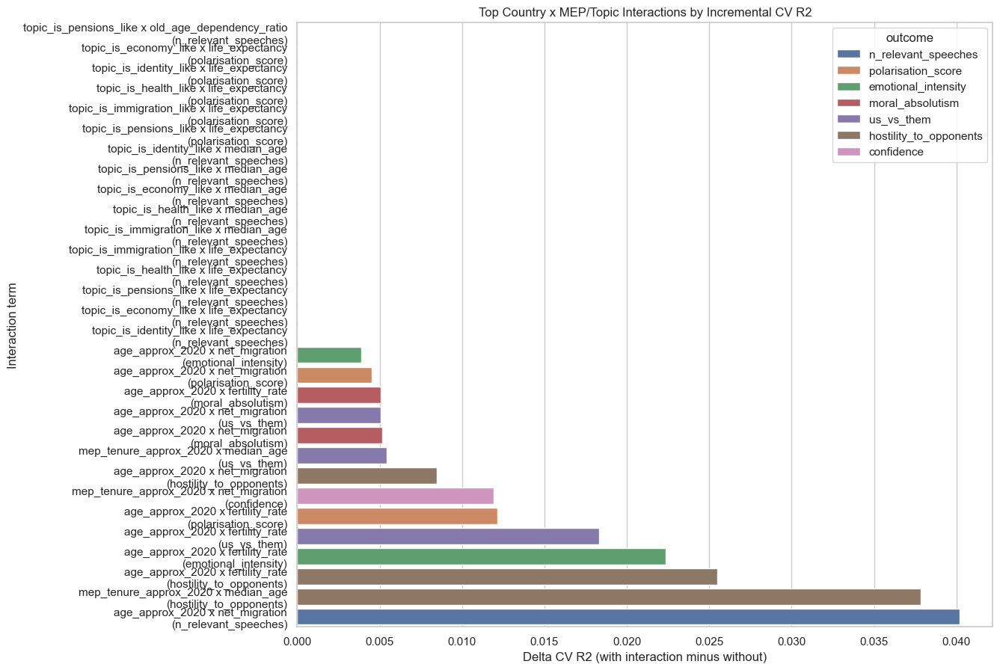

In [ ]:
# --- Country x MEP interaction screening (stable, low-warning approach) ---
sns.set_theme(style="whitegrid", context="notebook")
FIGURE_OUTPUT_DIR = globals().get("FIGURE_OUTPUT_DIR", FIGURES_DIR)
FIGURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def _compact_fig_name(filename):
    stem = Path(filename).stem.lower()
    stem = re.sub(r"[^a-z0-9]+", "_", stem).strip("_")
    token_map = {
        "descriptive": "desc", "polarisation": "pol", "correlation": "corr",
        "random": "rf", "forest": "rf", "association": "assoc", "strength": "str",
        "feature": "feat", "importance": "imp", "cluster": "cl", "country": "cty",
        "topic": "tp", "group": "grp", "party": "pty", "profile": "prof",
        "interaction": "int", "interactions": "ints", "composition": "comp",
        "prevalence": "prev", "outcome": "out", "outcomes": "outs",
        "distribution": "dist", "distributions": "dists", "heatmap": "hm",
        "scatter": "scat", "ranking": "rank", "silhouette": "sil",
        "high": "hi", "low": "lo", "absolute": "abs", "professional": "prof",
        "background": "bg",
    }
    parts = [token_map.get(p, p[:4]) for p in stem.split("_") if p]
    compact = "_".join(parts)
    compact = (compact[:48].rstrip("_") or "fig")
    return f"{compact}.png"
def save_figure(filename):
    plt.savefig(FIGURE_OUTPUT_DIR / _compact_fig_name(filename), dpi=300, bbox_inches="tight")
required_interaction_vars = [
    "analysis_df",
    "polarisation_targets_continuous",
]
missing_interaction_vars = [v for v in required_interaction_vars if v not in globals()]

if missing_interaction_vars:
    raise RuntimeError(
        "Please run the feature-engineering cells first. Missing: " + ", ".join(missing_interaction_vars)
    )
country_context_vars = [
    "median_age",
    "old_age_dependency_ratio",
    "life_expectancy",
    "fertility_rate",
    "gdp_per_capita_index_eu27_100",
    "youth_unemployment",
    "debt_to_gdp",
    "net_migration",
]
country_context_vars = [c for c in country_context_vars if c in analysis_df.columns]
mep_numeric_vars = [
    "age_approx_2020",
    "mep_tenure_approx_2020",
]
mep_numeric_vars = [c for c in mep_numeric_vars if c in analysis_df.columns]
topic_flag_patterns = {
    "topic_is_pensions_like": r"pension|retire|old age|welfare|social security",
    "topic_is_immigration_like": r"immigr|migrant|asylum|border",
    "topic_is_economy_like": r"econom|budget|finance|tax|fiscal",
    "topic_is_identity_like": r"identity|culture|values|religion|gender",
    "topic_is_health_like": r"health|hospital|medical|care",
}
interaction_df = analysis_df.copy()

if "topic_most_talked" in interaction_df.columns:
    topic_text = interaction_df["topic_most_talked"].astype(str).str.lower()
    topic_flag_data = {
        flag_name: topic_text.str.contains(pattern, regex=True, na=False).astype(float)
        for flag_name, pattern in topic_flag_patterns.items()
    }
else:
    topic_flag_data = {flag_name: pd.Series(0.0, index=interaction_df.index) for flag_name in topic_flag_patterns}
interaction_df = pd.concat([interaction_df, pd.DataFrame(topic_flag_data, index=interaction_df.index)], axis=1)
topic_flags = list(topic_flag_patterns.keys())
interaction_terms = []

for mep_var in mep_numeric_vars + topic_flags:
    for country_var in country_context_vars:
        interaction_terms.append((mep_var, country_var))
if len(interaction_terms) == 0:
    raise RuntimeError("No valid interaction term candidates were found.")
cv_inter = KFold(n_splits=5, shuffle=True, random_state=42)
interaction_rows = []

for target in [t for t in polarisation_targets_continuous if t in interaction_df.columns]:
    y_all = pd.to_numeric(interaction_df[target], errors="coerce")
    for mep_var, country_var in interaction_terms:
        a = pd.to_numeric(interaction_df[mep_var], errors="coerce")
        b = pd.to_numeric(interaction_df[country_var], errors="coerce")
        tmp = pd.DataFrame({
            "a": a,
            "b": b,
            "y": y_all,
        }).dropna()
        if len(tmp) < 40:
            continue
        a_std = (tmp["a"] - tmp["a"].mean()) / (tmp["a"].std(ddof=0) + 1e-12)
        b_std = (tmp["b"] - tmp["b"].mean()) / (tmp["b"].std(ddof=0) + 1e-12)
        inter_std = a_std * b_std
        X_base = pd.DataFrame({"a": a_std, "b": b_std})
        X_full = pd.DataFrame({
            "a": a_std,
            "b": b_std,
            "a_x_b": inter_std,
        })
        y = tmp["y"]
        base_scores = cross_val_score(LinearRegression(), X_base, y, cv=cv_inter, scoring="r2")
        full_scores = cross_val_score(LinearRegression(), X_full, y, cv=cv_inter, scoring="r2")
        delta_r2 = float(np.mean(full_scores) - np.mean(base_scores))
        model = LinearRegression()
        model.fit(X_full, y)
        coef_inter = float(model.coef_[2])
        interaction_rows.append({
            "outcome": target,
            "mep_or_topic_feature": mep_var,
            "country_feature": country_var,
            "interaction": f"{mep_var} x {country_var}",
            "n_rows": int(len(tmp)),
            "interaction_coef": coef_inter,
            "abs_interaction_coef": abs(coef_inter),
            "cv_r2_base": float(np.mean(base_scores)),
            "cv_r2_with_interaction": float(np.mean(full_scores)),
            "delta_cv_r2": delta_r2,
        })
if len(interaction_rows) == 0:
    print("No interaction results available (likely too many missing values in candidate variables).")
else:
    interaction_screen_df = pd.DataFrame(interaction_rows)
    interaction_summary_table = (
        interaction_screen_df
        .sort_values(["delta_cv_r2", "abs_interaction_coef"], ascending=[False, False])
        .reset_index(drop=True)
)
    display(interaction_summary_table.head(40))
    # Note: final_matched_file.xlsx export intentionally removed.
    for outcome in sorted(interaction_summary_table["outcome"].unique().tolist()):
        print(f"\nTop interactions for {outcome}:")
        display(
            interaction_summary_table[interaction_summary_table["outcome"] == outcome]
            .head(10)
            [[
                "interaction",
                "n_rows",
                "interaction_coef",
                "delta_cv_r2",
                "cv_r2_with_interaction",
            ]]
        )
    top_plot = interaction_summary_table.head(30).copy()
    top_plot["label"] = top_plot["interaction"] + "\n(" + top_plot["outcome"] + ")"
    top_plot = top_plot.sort_values("delta_cv_r2", ascending=True)
    plt.figure(figsize=(12, max(6, 0.35 * len(top_plot))))
    sns.barplot(data=top_plot, x="delta_cv_r2", y="label", hue="outcome", dodge=False)
    plt.title("Top Country x MEP/Topic Interactions by Incremental CV R2")
    plt.xlabel("Delta CV R2 (with interaction minus without)")
    plt.ylabel("Interaction term")
    if plot_df["outcome_label"].nunique() > 1:
        plt.legend(title="Outcome", loc="lower right")
    else:
        leg = plt.gca().get_legend()
        if leg is not None:
            leg.remove()
    plt.tight_layout()
    save_figure("country_mep_topic_interactions.png")
    # Save this figure from this plotting block
    if "FIGURES_DIR" in globals():
        _fig_save_dir = FIGURES_DIR
    elif "FIGURES_OUT_DIR" in globals():
        _fig_save_dir = FIGURES_OUT_DIR
    else:
        _fig_save_dir = (PROJECT_ROOT if "PROJECT_ROOT" in globals() else Path.cwd()) / "outputs" / "figures"
    _fig_save_dir.mkdir(parents=True, exist_ok=True)
    _fig_out = _fig_save_dir / f"cell_23_plot_001.png"
    plt.savefig(_fig_out, dpi=300, bbox_inches="tight")
    plt.show()

In [ ]:
# --- Final correlation table ---
# Builds a compact table of correlations between the main outcomes and the requested direct/topic/interaction variables.

if "analysis_df" not in globals():
    raise RuntimeError("Please run the earlier notebook cells first so analysis_df exists.")
outcome_vars = [
    "polarisation_score",
    "us_vs_them",
    "emotional_intensity",
    "moral_absolutism",
    "hostility_to_opponents",
]
direct_vars = [
    "age_approx_2020",
    "mep_tenure_approx_2020",
    "median_age",
    "old_age_dependency_ratio",
    "fertility_rate",
    "net_migration",
    "population_change",
    "youth_unemployment",
    "debt_to_gdp",
    "gdp_per_capita_index_eu27_100",
]
topic_vars = [
    "Ageing & Pensions",
    "Migration & Population Change",
    "Fertility & Family Formation",
    "Youth & Future Generations",
    "Labour Force & Workforce",
    "Regional Depopulation",
    "Health & Care Services",
    "Housing & Living Conditions",
    "Population Growth & Sustainability",
]
interaction_specs = {
    "ageing_topic_x_old_age_dependency": (
        "Ageing & Pensions",
        "old_age_dependency_ratio",
    ),
    "ageing_topic_x_median_age": (
        "Ageing & Pensions",
        "median_age",
    ),
    "migration_topic_x_net_migration": (
        "Migration & Population Change",
        "net_migration",
    ),
    "fertility_topic_x_fertility_rate": (
        "Fertility & Family Formation",
        "fertility_rate",
    ),
    "youth_topic_x_youth_unemployment": (
        "Youth & Future Generations",
        "youth_unemployment",
    ),
    "depopulation_topic_x_population_change": (
        "Regional Depopulation",
        "population_change",
    ),
}
topic_vars = [c for c in topic_vars if c in analysis_df.columns]
topic_vars = list(dict.fromkeys(topic_vars + [
    c for c in analysis_df.columns
    if str(c).startswith("Borderline:") or c in ["Fertility, Families & Gender", "Regional Depopulation & Territorial Cohesion"]
]))
correlation_predictors = direct_vars + topic_vars + list(interaction_specs.keys())
corr_df = analysis_df.copy()

# Create the requested interaction columns when both inputs exist.

for interaction_name, (topic_col, direct_col) in interaction_specs.items():
    if topic_col in corr_df.columns and direct_col in corr_df.columns:
        corr_df[interaction_name] = pd.to_numeric(corr_df[topic_col], errors="coerce") * pd.to_numeric(corr_df[direct_col], errors="coerce")
available_outcomes = [c for c in outcome_vars if c in corr_df.columns]
available_predictors = [c for c in correlation_predictors if c in corr_df.columns]

if not available_outcomes:
    raise RuntimeError("No outcome variables were found in analysis_df.")
if not available_predictors:
    raise RuntimeError("None of the requested correlation predictors were found in analysis_df.")
correlation_rows = []

for outcome in available_outcomes:
    for predictor in available_predictors:
        pair = corr_df[[outcome, predictor]].apply(pd.to_numeric, errors="coerce").dropna()
        if len(pair) < 3:
            continue
        corr_value = pair[outcome].corr(pair[predictor])
        correlation_rows.append({
            "outcome": outcome,
            "predictor": predictor,
            "correlation": corr_value,
            "abs_correlation": abs(corr_value),
            "n_obs": len(pair),
        })
correlation_table = pd.DataFrame(correlation_rows).sort_values(
    ["outcome", "abs_correlation"],
    ascending=[True, False],
).reset_index(drop=True)
display(correlation_table)
print("Rows in correlation table:", len(correlation_table))

,outcome,predictor,correlation,abs_correlation,n_obs
0,emotional_intensity,mep_tenure_approx_2020,-0.156887,0.156887,134
1,emotional_intensity,Borderline: Regional development policy,-0.140031,0.140031,139
2,emotional_intensity,Housing & Living Conditions,0.132990,0.132990,139
3,emotional_intensity,Health & Care Services,-0.131462,0.131462,139
4,emotional_intensity,Borderline: Island regions and cohesion,-0.119357,0.119357,139
...,...,...,...,...,...
130,us_vs_them,median_age,-0.011588,0.011588,139
131,us_vs_them,population_change,-0.010786,0.010786,139
132,us_vs_them,Borderline: Labour market and social policy,-0.010779,0.010779,139
133,us_vs_them,Migration & Population Change,-0.007099,0.007099,139


Rows in correlation table: 135


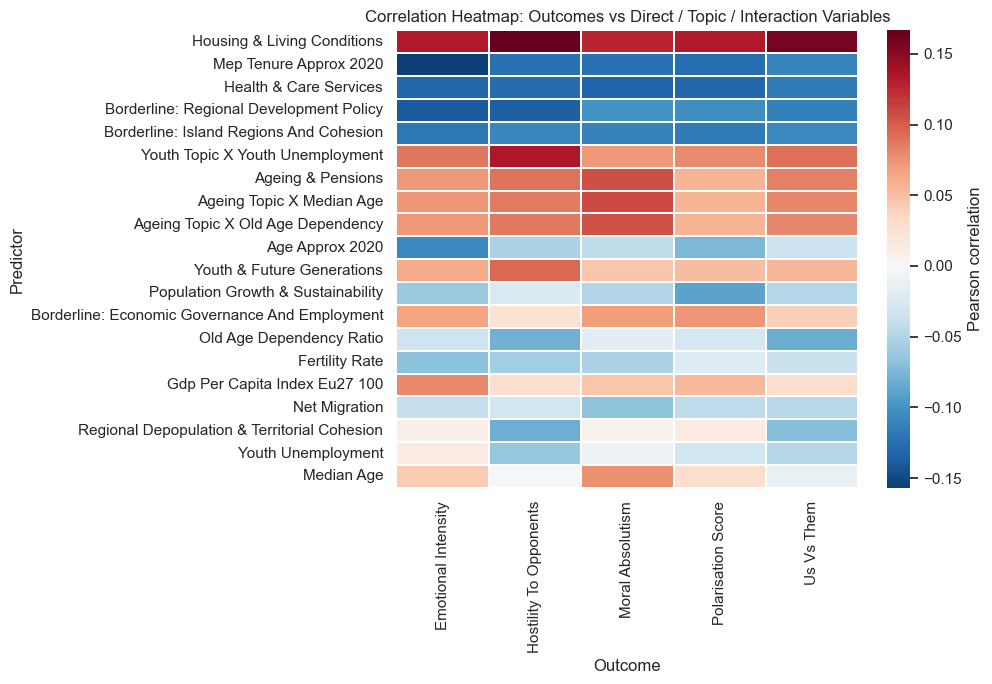

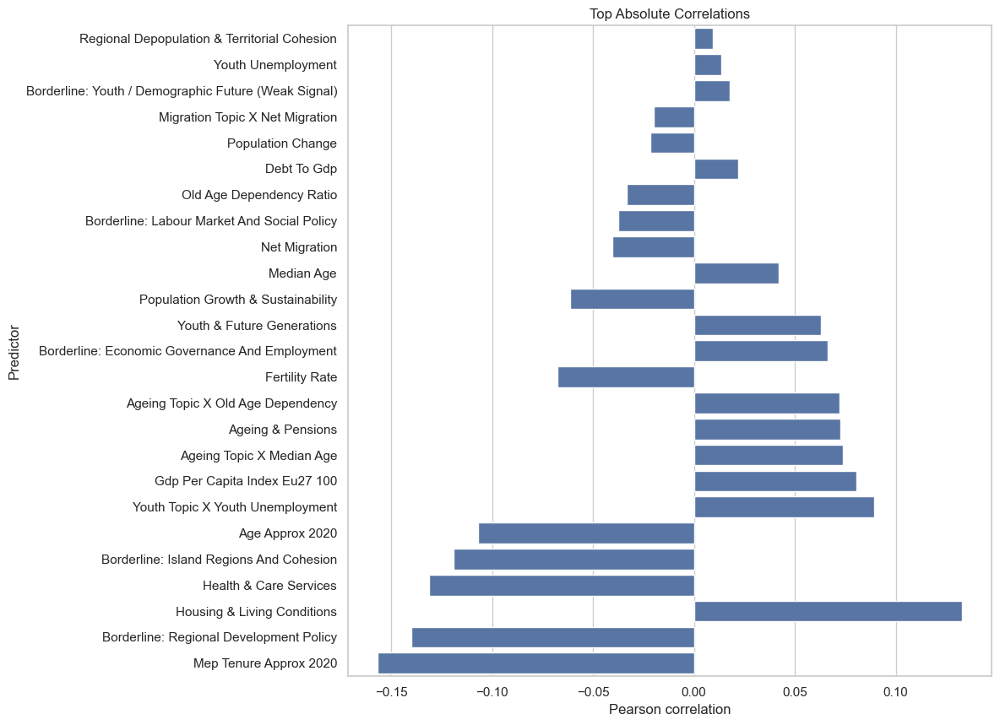

In [ ]:
# --- Correlation visualization ---
FIGURE_OUTPUT_DIR = globals().get("FIGURE_OUTPUT_DIR", PROJECT_ROOT / "8 Final regression" / "figures")
FIGURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def _compact_fig_name(filename):
    stem = Path(filename).stem.lower()
    stem = re.sub(r"[^a-z0-9]+", "_", stem).strip("_")
    token_map = {
        "descriptive": "desc", "polarisation": "pol", "correlation": "corr",
        "random": "rf", "forest": "rf", "association": "assoc", "strength": "str",
        "feature": "feat", "importance": "imp", "cluster": "cl", "country": "cty",
        "topic": "tp", "group": "grp", "party": "pty", "profile": "prof",
        "interaction": "int", "interactions": "ints", "composition": "comp",
        "prevalence": "prev", "outcome": "out", "outcomes": "outs",
        "distribution": "dist", "distributions": "dists", "heatmap": "hm",
        "scatter": "scat", "ranking": "rank", "silhouette": "sil",
        "high": "hi", "low": "lo", "absolute": "abs", "professional": "prof",
        "background": "bg",
    }
    parts = [token_map.get(p, p[:4]) for p in stem.split("_") if p]
    compact = "_".join(parts)
    compact = (compact[:48].rstrip("_") or "fig")
    return f"{compact}.png"
def save_figure(filename):
    plt.savefig(FIGURE_OUTPUT_DIR / _compact_fig_name(filename), dpi=300, bbox_inches="tight")
def pretty_display_name(value):
    text = str(value)
    text = re.sub(r"^z_", "", text)
    text = text.replace("_x_", " x ").replace("__", " ").replace("_", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text.title()
if "correlation_table" not in globals():
    raise RuntimeError("Please run the correlation table cell first.")
sns.set_theme(style="whitegrid", context="notebook")

# Pivot the long-form table into an outcome-by-predictor matrix.
correlation_heatmap_df = correlation_table.pivot_table(
    index="predictor",
    columns="outcome",
    values="correlation",
    aggfunc="mean",
)

# Keep the strongest overall correlations for readability.

if not correlation_heatmap_df.empty:
    top_n = min(20, len(correlation_heatmap_df))
    strongest_predictors = (
        correlation_heatmap_df.abs().mean(axis=1).sort_values(ascending=False).head(top_n).index
    )
    correlation_heatmap_df = correlation_heatmap_df.loc[strongest_predictors].copy()
    correlation_heatmap_df.index = [pretty_display_name(v) for v in correlation_heatmap_df.index]
    correlation_heatmap_df.columns = [pretty_display_name(v) for v in correlation_heatmap_df.columns]
    plt.figure(figsize=(10, max(6, 0.35 * len(correlation_heatmap_df))))
    sns.heatmap(
        correlation_heatmap_df,
        cmap="RdBu_r",
        center=0,
        linewidths=0.3,
        cbar_kws={"label": "Pearson correlation"},
    )
    plt.title("Correlation Heatmap: Outcomes vs Direct / Topic / Interaction Variables")
    plt.xlabel("Outcome")
    plt.ylabel("Predictor")
    plt.tight_layout()
    save_figure("correlation_heatmap.png")
    # Save this figure from this plotting block
    if "FIGURES_DIR" in globals():
        _fig_save_dir = FIGURES_DIR
    elif "FIGURES_OUT_DIR" in globals():
        _fig_save_dir = FIGURES_OUT_DIR
    else:
        _fig_save_dir = (PROJECT_ROOT if "PROJECT_ROOT" in globals() else Path.cwd()) / "outputs" / "figures"
    _fig_save_dir.mkdir(parents=True, exist_ok=True)
    _fig_out = _fig_save_dir / f"cell_25_plot_001.png"
    plt.savefig(_fig_out, dpi=300, bbox_inches="tight")
    plt.show()
# Also show a compact bar chart of the strongest absolute correlations.
plot_df = correlation_table.head(25).copy()

if not plot_df.empty:
    plot_df["outcome_label"] = plot_df["outcome"].map(pretty_display_name)
    # Keep y labels concise: predictor only (no repeated '(outcome)' suffix).
    plot_df["label"] = plot_df["predictor"].map(pretty_display_name)
    plot_df = plot_df.sort_values("abs_correlation", ascending=True)
    plt.figure(figsize=(12, max(6, 0.35 * len(plot_df))))
    sns.barplot(data=plot_df, x="correlation", y="label", hue="outcome_label", dodge=False)
    plt.title("Top Absolute Correlations")
    plt.xlabel("Pearson correlation")
    plt.ylabel("Predictor")
    if plot_df["outcome_label"].nunique() > 1:
        plt.legend(title="Outcome", loc="lower right")
    else:
        leg = plt.gca().get_legend()
        if leg is not None:
            leg.remove()
    plt.tight_layout()
    save_figure("correlation_top_absolute_bars.png")
    # Save this figure from this plotting block
    if "FIGURES_DIR" in globals():
        _fig_save_dir = FIGURES_DIR
    elif "FIGURES_OUT_DIR" in globals():
        _fig_save_dir = FIGURES_OUT_DIR
    else:
        _fig_save_dir = (PROJECT_ROOT if "PROJECT_ROOT" in globals() else Path.cwd()) / "outputs" / "figures"
    _fig_save_dir.mkdir(parents=True, exist_ok=True)
    _fig_out = _fig_save_dir / f"cell_25_plot_002.png"
    plt.savefig(_fig_out, dpi=300, bbox_inches="tight")
    plt.show()

## Descriptive Profiles for Thesis Figures

This section focuses on interpretability rather than prediction. It compares high- and low-polarisation cases, EP group patterns, topic composition, interaction-style bubble plots, and distributions of the main outcomes.

What this section does:
- Clarifies the purpose of this section and how it connects to the next steps.
- Summarizes expected inputs and outputs to make reruns easier to follow.


In [ ]:
_original_heatmap = sns.heatmap

def _safe_heatmap(data, *args, **kwargs):
    if hasattr(data, "empty") and data.empty:
        print("Skipping heatmap: empty data.")
        return None
    try:
        return _original_heatmap(data, *args, **kwargs)
    except ValueError as exc:
        if "zero-size array" in str(exc):
            print("Skipping heatmap: empty data.")
            return None
        raise
sns.heatmap = _safe_heatmap
print("Installed safe heatmap guard for empty matrices.")

Installed safe heatmap guard for empty matrices.


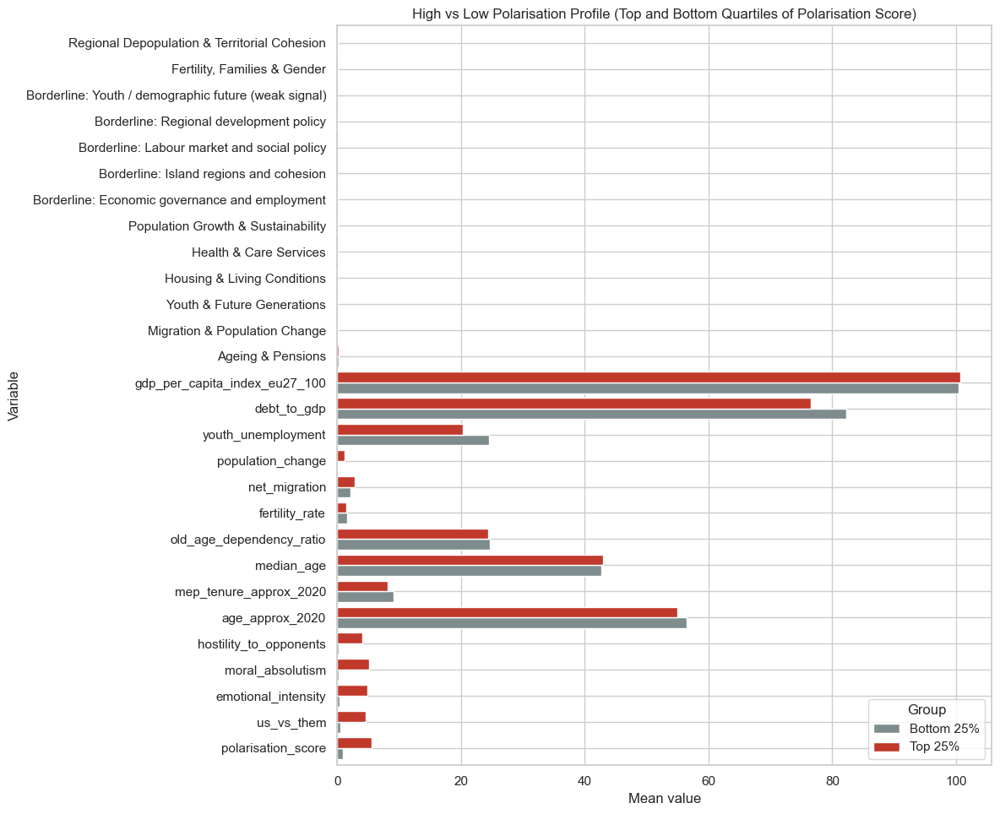

C:\Users\Gebruiker\AppData\Local\Temp\ipykernel_24608\1215593095.py:146: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


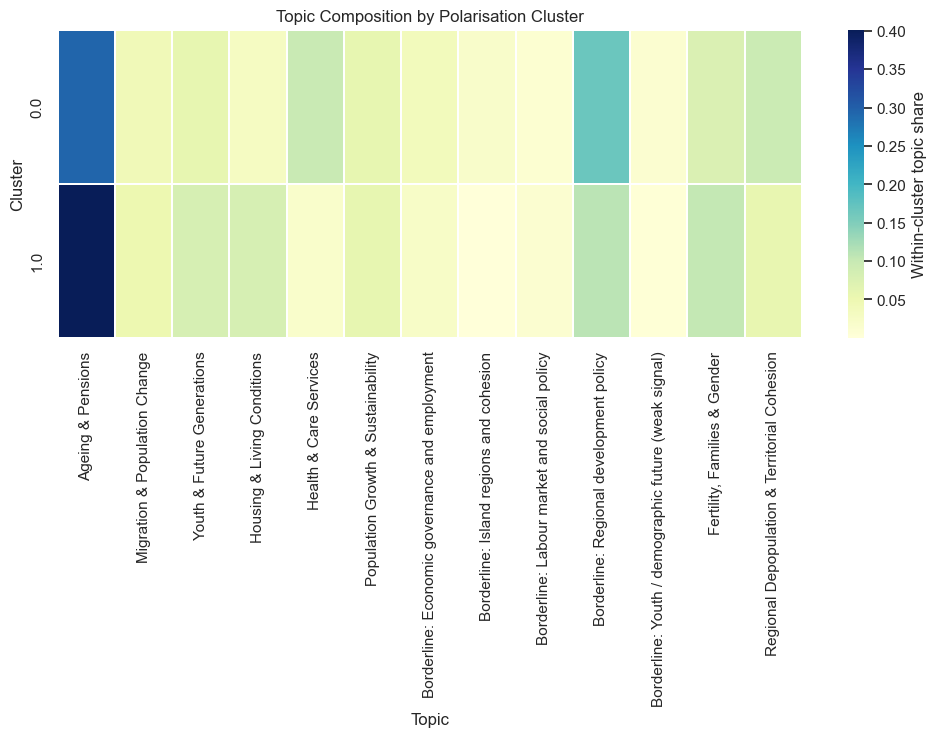

,ep_group_clean,mean_polarisation_score,n_obs
13,The Left/GUE-NGL,4.900000,5
6,ID/ENF/PfE,4.500000,3
3,Greens/EFA,3.750000,4
0,ECR,3.511111,9
4,Greens–European Free Alliance,3.400000,3
11,Renew/ALDE,2.862500,8
12,S&D,2.394286,35
2,EPP,2.175556,45
14,Unknown,2.047619,21


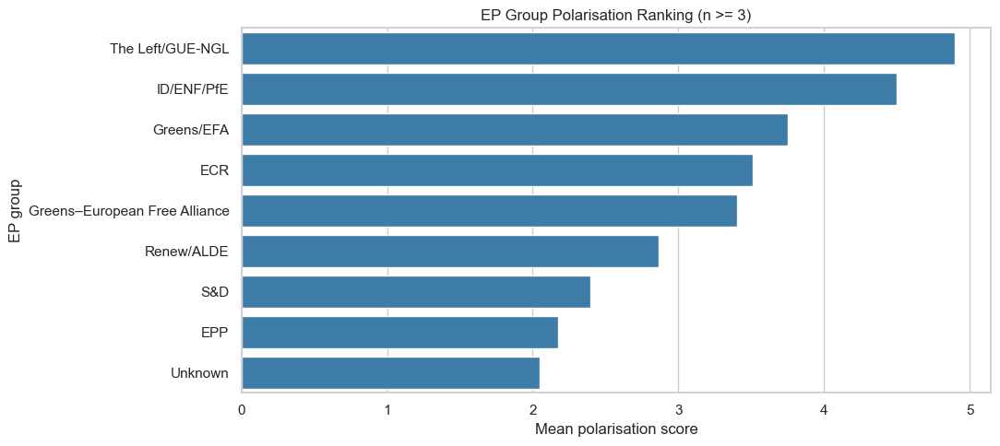

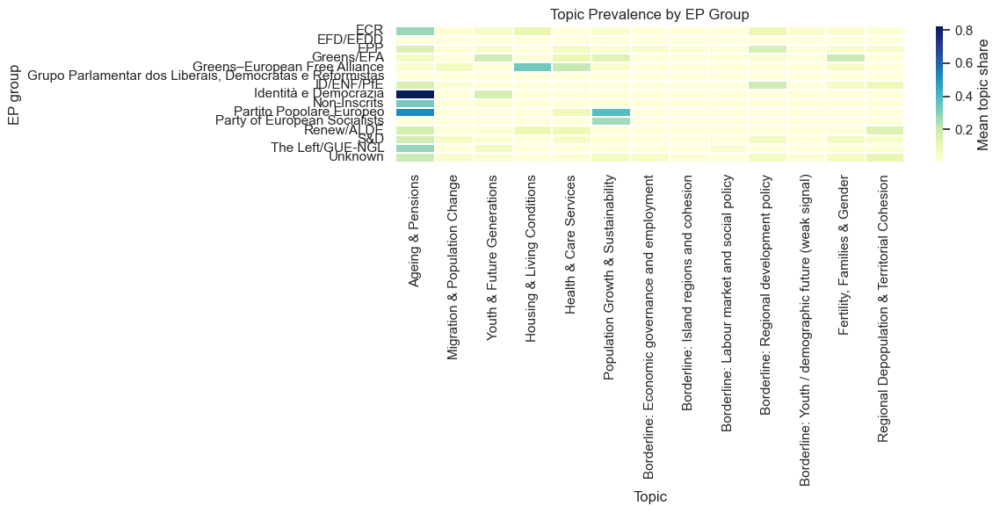

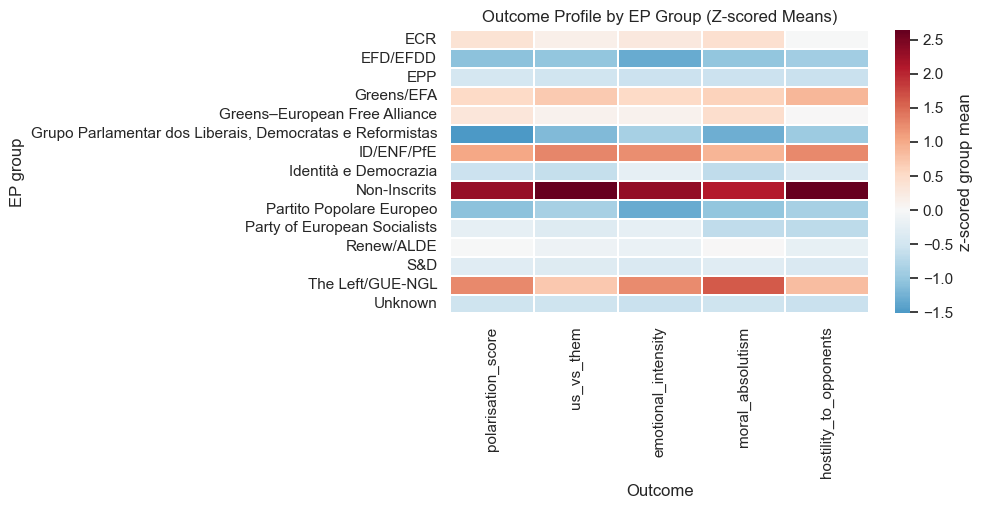

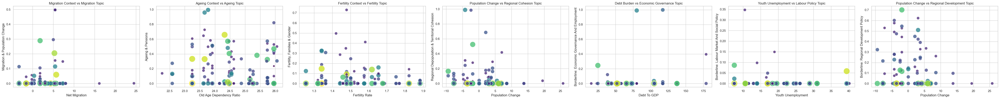

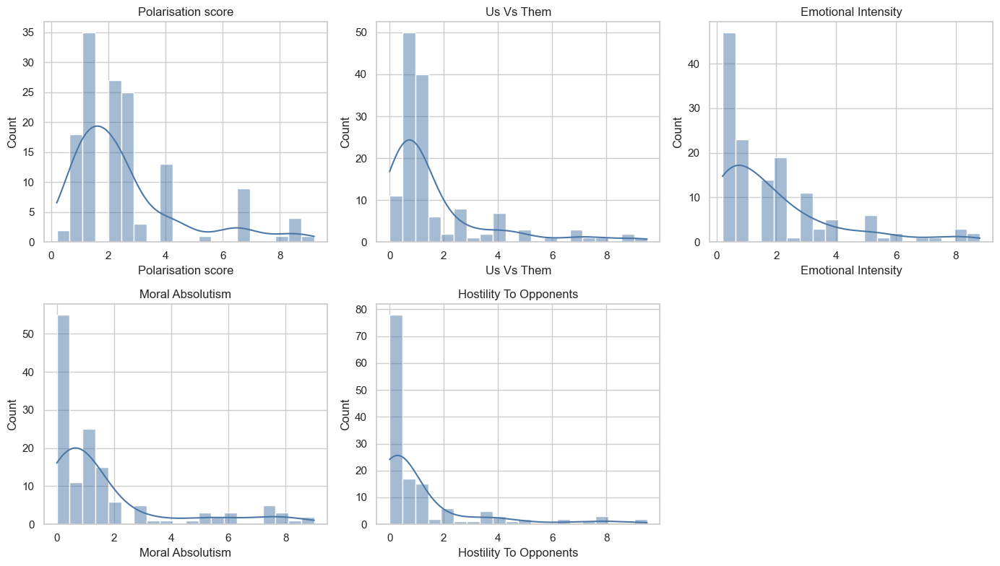

,mep_name_clean,country_clean,ep_group_clean,main_topic,polarisation_score
0,joachim stanis aw brudzinski,pl,ECR,Housing & Living Conditions,9.2
1,andrew henry william brons,gb,Unknown,Ageing & Pensions,8.5
2,christine anderson,de,ID/ENF/PfE,"Fertility, Families & Gender",8.5
3,maria lidia senra rodriguez,es,The Left/GUE-NGL,Ageing & Pensions,8.5
4,ukasz kohut,pl,S&D,Ageing & Pensions,8.5
5,tineke strik,nl,Greens–European Free Alliance,Migration & Population Change,8.0
6,martin schirdewan,de,The Left/GUE-NGL,Ageing & Pensions,6.5
7,bruno gollnisch,fr,Non-Inscrits,Ageing & Pensions,6.5
8,radan kanev,bg,EPP,Ageing & Pensions,6.5
9,pierfrancesco majorino,it,S&D,Regional Depopulation & Territorial Cohesion,6.5


,ep_group_clean,mean_polarisation_score,median_polarisation_score,n_obs
0,The Left/GUE-NGL,4.900000,4.00,5
1,ID/ENF/PfE,4.500000,4.00,3
2,Greens/EFA,3.750000,3.65,4
3,ECR,3.511111,2.50,9
4,Greens–European Free Alliance,3.400000,1.20,3
5,Renew/ALDE,2.862500,2.50,8
6,S&D,2.394286,2.00,35
7,EPP,2.175556,2.00,45
8,Unknown,2.047619,2.00,21



Party x Topic count table (ep_group_clean x dominant_topic):


dominant_topic,Ageing & Pensions,Borderline: Economic governance and employment,Borderline: Regional development policy,"Fertility, Families & Gender",Health & Care Services,Housing & Living Conditions,Migration & Population Change,Population Growth & Sustainability,Regional Depopulation & Territorial Cohesion,Youth & Future Generations
ep_group_clean,,,,,,,,,,
ECR,3,0,1,0,0,1,0,1,0,0
EPP,6,1,9,0,4,0,0,1,0,3
Greens/EFA,0,0,0,1,1,0,0,1,0,1
Renew/ALDE,2,0,0,0,1,1,0,0,1,0
S&D,7,0,1,1,0,0,1,0,1,1
Unknown,5,1,0,0,0,0,0,2,3,1


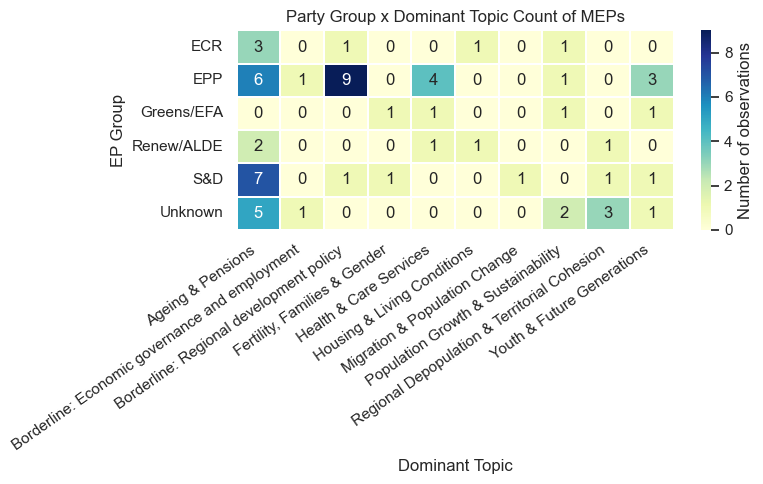


Party x Topic mean polarisation_score (blank = fewer than 2 obs):


dominant_topic,Ageing & Pensions,Borderline: Economic governance and employment,Borderline: Regional development policy,"Fertility, Families & Gender",Health & Care Services,Housing & Living Conditions,Migration & Population Change,Population Growth & Sustainability,Regional Depopulation & Territorial Cohesion,Youth & Future Generations
ep_group_clean,,,,,,,,,,
ECR,2.90,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EPP,2.15,NaN,2.46,NaN,1.8,NaN,NaN,NaN,NaN,2.5
Greens/EFA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Renew/ALDE,4.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
S&D,2.90,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Unknown,1.28,NaN,NaN,NaN,NaN,NaN,NaN,1.1,1.9,NaN


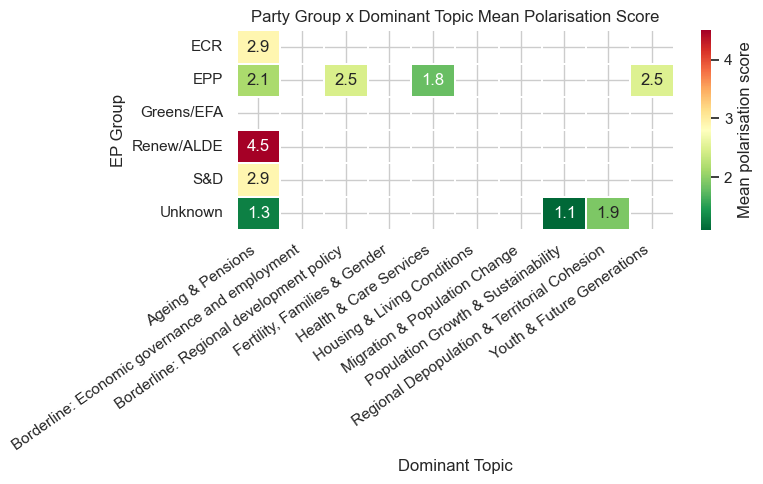

Descriptive section complete.


In [ ]:
if "analysis_df" not in globals():
    raise RuntimeError("Please run the earlier analysis cells first so analysis_df exists.")
sns.set_theme(style="whitegrid", context="notebook")
FIGURE_OUTPUT_DIR = globals().get("FIGURE_OUTPUT_DIR", PROJECT_ROOT / "8 Final regression" / "figures")
FIGURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def _compact_fig_name(filename):
    stem = Path(filename).stem.lower()
    stem = re.sub(r"[^a-z0-9]+", "_", stem).strip("_")
    token_map = {
        "descriptive": "desc", "polarisation": "pol", "correlation": "corr",
        "random": "rf", "forest": "rf", "association": "assoc", "strength": "str",
        "feature": "feat", "importance": "imp", "cluster": "cl", "country": "cty",
        "topic": "tp", "group": "grp", "party": "pty", "profile": "prof",
        "interaction": "int", "interactions": "ints", "composition": "comp",
        "prevalence": "prev", "outcome": "out", "outcomes": "outs",
        "distribution": "dist", "distributions": "dists", "heatmap": "hm",
        "scatter": "scat", "ranking": "rank", "silhouette": "sil",
        "high": "hi", "low": "lo", "absolute": "abs", "professional": "prof",
        "background": "bg",
    }
    parts = [token_map.get(p, p[:4]) for p in stem.split("_") if p]
    compact = "_".join(parts)
    compact = (compact[:48].rstrip("_") or "fig")
    return f"{compact}.png"
def save_figure(filename):
    plt.savefig(FIGURE_OUTPUT_DIR / _compact_fig_name(filename), dpi=300, bbox_inches="tight")
def first_existing(series_candidates):
    for candidate in series_candidates:
        if candidate in analysis_df.columns:
            return candidate
    return None
def numeric_series(column_name):
    return pd.to_numeric(analysis_df[column_name], errors="coerce") if column_name in analysis_df.columns else pd.Series(index=analysis_df.index, dtype=float)
def pretty_label(name):
    if name is None:
        return ""
    label = str(name).strip().replace("_", " ")
    label = re.sub(r"\s+", " ", label)
    replacements = {
        "gdp": "GDP",
        "mep": "MEP",
        "eu27": "EU27",
        "55 64": "55-64",
    }
    words = []
    for token in label.split(" " ):
        lower = token.lower()
        words.append(replacements.get(lower, token.capitalize()))
    label = " ".join(words)
    label = label.replace("Polarisation Score", "Polarisation score")
    return label
outcome_vars = [
    "polarisation_score",
    "us_vs_them",
    "emotional_intensity",
    "moral_absolutism",
    "hostility_to_opponents",
]
direct_vars = [
    "age_approx_2020",
    "mep_tenure_approx_2020",
    "median_age",
    "old_age_dependency_ratio",
    "fertility_rate",
    "net_migration",
    "population_change",
    "youth_unemployment",
    "debt_to_gdp",
    "gdp_per_capita_index_eu27_100",
]
topic_vars = [
    "Ageing & Pensions",
    "Migration & Population Change",
    "Fertility & Family Formation",
    "Youth & Future Generations",
    "Housing & Living Conditions",
    "Health & Care Services",
    "Regional Depopulation",
    "Labour Force & Workforce",
    "Population Growth & Sustainability",
]
topic_vars = [c for c in topic_vars if c in analysis_df.columns]
topic_vars = list(dict.fromkeys(topic_vars + [
    c for c in analysis_df.columns
    if str(c).startswith("Borderline:") or c in ["Fertility, Families & Gender", "Regional Depopulation & Territorial Cohesion"]
]))
direct_vars = [c for c in direct_vars if c in analysis_df.columns]
outcome_vars = [c for c in outcome_vars if c in analysis_df.columns]

if not outcome_vars:
    raise RuntimeError("No polarisation outcome columns were found in analysis_df.")
def prefer_standardized(col):
    topic_standardized_map = {
        "Ageing & Pensions": "z_topic_share_ageing_pensions",
        "Migration & Population Change": "z_topic_share_migration_population",
        "Fertility, Families & Gender": "z_topic_share_fertility_family",
        "Youth & Future Generations": "z_topic_share_youth_future",
        "Borderline: Economic governance and employment": "z_topic_share_fiscal_pensions",
    }
    if f"z_{col}" in analysis_df.columns:
        return f"z_{col}"
    if col in topic_standardized_map and topic_standardized_map[col] in analysis_df.columns:
        return topic_standardized_map[col]
    return col
profile_vars = list(dict.fromkeys(outcome_vars + [prefer_standardized(c) for c in direct_vars + topic_vars]))

# 1) High vs low polarisation profile plot

if "polarisation_score" not in analysis_df.columns:
    raise RuntimeError("polarisation_score is required for the high/low profile plot.")
profile_df = analysis_df.copy()
score_rank = pd.to_numeric(profile_df["polarisation_score"], errors="coerce").rank(pct=True)
bottom_mask = score_rank <= 0.25
top_mask = score_rank >= 0.75
selected_group_means = []

for group_name, group_mask in {"Bottom 25%": bottom_mask, "Top 25%": top_mask}.items():
    group = profile_df.loc[group_mask, profile_vars].apply(pd.to_numeric, errors="coerce")
    means = group.mean(numeric_only=True)
    selected_group_means.append(means.rename(group_name))
high_low_profile = pd.concat(selected_group_means, axis=1).reindex(profile_vars)
high_low_profile = high_low_profile.dropna(how="all")

if not high_low_profile.empty:
    ax = high_low_profile.plot(kind="barh", figsize=(12, max(6, 0.35 * len(high_low_profile))), width=0.82, color=["#7f8c8d", "#c0392b"])
    ax.set_title("High vs Low Polarisation Profile (Top and Bottom Quartiles of Polarisation Score)")
    ax.set_xlabel("Mean value")
    ax.set_ylabel("Variable")
    ax.legend(title="Group", loc="lower right")
    plt.tight_layout()
    save_figure("descriptive_high_vs_low_polarisation_profile.png")
    # Save this figure from this plotting block
    if "FIGURES_DIR" in globals():
        _fig_save_dir = FIGURES_DIR
    elif "FIGURES_OUT_DIR" in globals():
        _fig_save_dir = FIGURES_OUT_DIR
    else:
        _fig_save_dir = (PROJECT_ROOT if "PROJECT_ROOT" in globals() else Path.cwd()) / "outputs" / "figures"
    _fig_save_dir.mkdir(parents=True, exist_ok=True)
    _fig_out = _fig_save_dir / f"cell_28_plot_001.png"
    plt.savefig(_fig_out, dpi=300, bbox_inches="tight")
    plt.show()
# 2) Topic composition by polarisation cluster
cluster_col = first_existing(["topic_polarisation_cluster", "polarisation_cluster", "cluster"])

if cluster_col is not None and topic_vars:
    cluster_topic_means = analysis_df.groupby(cluster_col)[topic_vars].mean(numeric_only=True)
    cluster_topic_norm = cluster_topic_means.div(cluster_topic_means.sum(axis=1).replace(0, np.nan), axis=0)
    cluster_topic_norm = cluster_topic_norm.fillna(0.0)
    plt.figure(figsize=(12, max(4, 0.45 * len(cluster_topic_norm))))
    sns.heatmap(cluster_topic_norm, cmap="YlGnBu", linewidths=0.3, cbar_kws={"label": "Within-cluster topic share"})
    plt.title("Topic Composition by Polarisation Cluster")
    plt.xlabel("Topic")
    plt.ylabel("Cluster")
    plt.tight_layout()
    save_figure("descriptive_topic_composition_by_cluster.png")
    # Save this figure from this plotting block
    if "FIGURES_DIR" in globals():
        _fig_save_dir = FIGURES_DIR
    elif "FIGURES_OUT_DIR" in globals():
        _fig_save_dir = FIGURES_OUT_DIR
    else:
        _fig_save_dir = (PROJECT_ROOT if "PROJECT_ROOT" in globals() else Path.cwd()) / "outputs" / "figures"
    _fig_save_dir.mkdir(parents=True, exist_ok=True)
    _fig_out = _fig_save_dir / f"cell_28_plot_002.png"
    plt.savefig(_fig_out, dpi=300, bbox_inches="tight")
    plt.show()
# 3) EP group polarisation ranking, minimum 3 observations
ep_group_column = first_existing(["ep_group_clean", "ep_group_extracted"])

if ep_group_column is not None and "polarisation_score" in analysis_df.columns:
    ep_group_summary = (
        analysis_df.assign(polarisation_score=pd.to_numeric(analysis_df["polarisation_score"], errors="coerce"))
        .groupby(ep_group_column)
        .agg(mean_polarisation_score=("polarisation_score", "mean"), n_obs=("polarisation_score", "size"))
        .reset_index()
    )
    ep_group_summary = ep_group_summary[ep_group_summary["n_obs"] >= 3].sort_values("mean_polarisation_score", ascending=False)
    display(ep_group_summary)
    if not ep_group_summary.empty:
        plt.figure(figsize=(11, max(5, 0.35 * len(ep_group_summary))))
        sns.barplot(data=ep_group_summary, y=ep_group_column, x="mean_polarisation_score", color="#2c7fb8")
        plt.title("EP Group Polarisation Ranking (n >= 3)")
        plt.xlabel("Mean polarisation score")
        plt.ylabel("EP group")
        plt.tight_layout()
        save_figure("descriptive_ep_group_polarisation_ranking.png")
        # Save this figure from this plotting block
        if "FIGURES_DIR" in globals():
            _fig_save_dir = FIGURES_DIR
        elif "FIGURES_OUT_DIR" in globals():
            _fig_save_dir = FIGURES_OUT_DIR
        else:
            _fig_save_dir = (PROJECT_ROOT if "PROJECT_ROOT" in globals() else Path.cwd()) / "outputs" / "figures"
        _fig_save_dir.mkdir(parents=True, exist_ok=True)
        _fig_out = _fig_save_dir / f"cell_28_plot_003.png"
        plt.savefig(_fig_out, dpi=300, bbox_inches="tight")
        plt.show()
# 4) Topic prevalence by EP group heatmap

if ep_group_column is not None and topic_vars:
    ep_topic_means = analysis_df.groupby(ep_group_column)[topic_vars].mean(numeric_only=True)
    plt.figure(figsize=(12, max(5, 0.4 * len(ep_topic_means))))
    sns.heatmap(ep_topic_means, cmap="YlGnBu", linewidths=0.25, cbar_kws={"label": "Mean topic share"})
    plt.title("Topic Prevalence by EP Group")
    plt.xlabel("Topic")
    plt.ylabel("EP group")
    plt.tight_layout()
    save_figure("descriptive_topic_prevalence_by_ep_group.png")
    # Save this figure from this plotting block
    if "FIGURES_DIR" in globals():
        _fig_save_dir = FIGURES_DIR
    elif "FIGURES_OUT_DIR" in globals():
        _fig_save_dir = FIGURES_OUT_DIR
    else:
        _fig_save_dir = (PROJECT_ROOT if "PROJECT_ROOT" in globals() else Path.cwd()) / "outputs" / "figures"
    _fig_save_dir.mkdir(parents=True, exist_ok=True)
    _fig_out = _fig_save_dir / f"cell_28_plot_004.png"
    plt.savefig(_fig_out, dpi=300, bbox_inches="tight")
    plt.show()
# 5) Outcome profile by EP group, using z-scored group means

if ep_group_column is not None:
    outcome_means = (
        analysis_df.assign(**{c: pd.to_numeric(analysis_df[c], errors="coerce") for c in outcome_vars if c in analysis_df.columns})
        .groupby(ep_group_column)[outcome_vars]
        .mean(numeric_only=True)
    )
    outcome_z = (outcome_means - outcome_means.mean(axis=0)) / outcome_means.std(axis=0).replace(0, np.nan)
    outcome_z = outcome_z.fillna(0.0)
    plt.figure(figsize=(10, max(5, 0.35 * len(outcome_z))))
    sns.heatmap(outcome_z, cmap="RdBu_r", center=0, linewidths=0.25, cbar_kws={"label": "z-scored group mean"})
    plt.title("Outcome Profile by EP Group (Z-scored Means)")
    plt.xlabel("Outcome")
    plt.ylabel("EP group")
    plt.tight_layout()
    save_figure("descriptive_outcome_profile_by_ep_group.png")
    # Save this figure from this plotting block
    if "FIGURES_DIR" in globals():
        _fig_save_dir = FIGURES_DIR
    elif "FIGURES_OUT_DIR" in globals():
        _fig_save_dir = FIGURES_OUT_DIR
    else:
        _fig_save_dir = (PROJECT_ROOT if "PROJECT_ROOT" in globals() else Path.cwd()) / "outputs" / "figures"
    _fig_save_dir.mkdir(parents=True, exist_ok=True)
    _fig_out = _fig_save_dir / f"cell_28_plot_005.png"
    plt.savefig(_fig_out, dpi=300, bbox_inches="tight")
    plt.show()
# 6) Bubble plots showing interaction logic
bubble_specs = [
    ("net_migration", "Migration & Population Change", "Migration Context vs Migration Topic"),
    ("old_age_dependency_ratio", "Ageing & Pensions", "Ageing Context vs Ageing Topic"),
    ("fertility_rate", "Fertility, Families & Gender", "Fertility Context vs Fertility Topic"),
    ("population_change", "Regional Depopulation & Territorial Cohesion", "Population Change vs Regional Cohesion Topic"),
    ("debt_to_gdp", "Borderline: Economic governance and employment", "Debt Burden vs Economic Governance Topic"),
    ("youth_unemployment", "Borderline: Labour market and social policy", "Youth Unemployment vs Labour Policy Topic"),
    ("population_change", "Borderline: Regional development policy", "Population Change vs Regional Development Topic"),
]
bubble_cols = []

for x_col, y_col, title in bubble_specs:
    x_plot_col = prefer_standardized(x_col)
    y_plot_col = prefer_standardized(y_col)
    if x_plot_col in analysis_df.columns and y_plot_col in analysis_df.columns and "polarisation_score" in analysis_df.columns:
        bubble_cols.append((x_plot_col, y_plot_col, title))
if bubble_cols:
    fig, axes = plt.subplots(1, len(bubble_cols), figsize=(7 * len(bubble_cols), 5), squeeze=False)
    axes_flat = axes.flatten()
    bubble_size = pd.to_numeric(analysis_df["polarisation_score"], errors="coerce")
    valid_bubble_size = bubble_size.dropna()
    if valid_bubble_size.empty:
        bubble_scaled = pd.Series(100.0, index=analysis_df.index)
    else:
        size_min = float(valid_bubble_size.min())
        size_span = float(valid_bubble_size.max() - size_min)
        bubble_scaled = 50 + 450 * ((bubble_size - size_min) / (size_span if size_span else 1.0))
        bubble_scaled = bubble_scaled.clip(lower=50, upper=500)
    for idx, (x_col, y_col, title) in enumerate(bubble_cols):
        plot_df = analysis_df[[x_col, y_col, "polarisation_score"]].copy()
        plot_df[x_col] = pd.to_numeric(plot_df[x_col], errors="coerce")
        plot_df[y_col] = pd.to_numeric(plot_df[y_col], errors="coerce")
        plot_df["bubble_size"] = bubble_scaled
        plot_df = plot_df.dropna(subset=[x_col, y_col, "polarisation_score"])
        ax = axes_flat[idx]
        sns.scatterplot(
            data=plot_df,
            x=x_col,
            y=y_col,
            size="bubble_size",
            sizes=(50, 500),
            hue="polarisation_score",
            palette="viridis",
            alpha=0.75,
            ax=ax,
            legend=False,
        )
        ax.set_title(title)
        ax.set_xlabel(pretty_label(x_col))
        ax.set_ylabel(pretty_label(y_col))
    plt.tight_layout()
    save_figure("descriptive_bubble_interaction_plots.png")
    # Save this figure from this plotting block
    if "FIGURES_DIR" in globals():
        _fig_save_dir = FIGURES_DIR
    elif "FIGURES_OUT_DIR" in globals():
        _fig_save_dir = FIGURES_OUT_DIR
    else:
        _fig_save_dir = (PROJECT_ROOT if "PROJECT_ROOT" in globals() else Path.cwd()) / "outputs" / "figures"
    _fig_save_dir.mkdir(parents=True, exist_ok=True)
    _fig_out = _fig_save_dir / f"cell_28_plot_006.png"
    plt.savefig(_fig_out, dpi=300, bbox_inches="tight")
    plt.show()
# 7) Distribution plots for all five polarisation outcomes
available_outcomes = [c for c in outcome_vars if c in analysis_df.columns]

if available_outcomes:
    fig, axes = plt.subplots(2, 3, figsize=(14, 8), squeeze=False)
    axes_flat = axes.flatten()
    for idx, outcome in enumerate(available_outcomes):
        values = pd.to_numeric(analysis_df[outcome], errors="coerce").dropna()
        sns.histplot(values, kde=True, ax=axes_flat[idx], color="#4c78a8", bins=20)
        axes_flat[idx].set_title(pretty_label(outcome))
        axes_flat[idx].set_xlabel(pretty_label(outcome))
        axes_flat[idx].set_ylabel("Count")
    for idx in range(len(available_outcomes), len(axes_flat)):
        axes_flat[idx].axis("off")
    plt.tight_layout()
    save_figure("descriptive_polarisation_outcome_distributions.png")
    # Save this figure from this plotting block
    if "FIGURES_DIR" in globals():
        _fig_save_dir = FIGURES_DIR
    elif "FIGURES_OUT_DIR" in globals():
        _fig_save_dir = FIGURES_OUT_DIR
    else:
        _fig_save_dir = (PROJECT_ROOT if "PROJECT_ROOT" in globals() else Path.cwd()) / "outputs" / "figures"
    _fig_save_dir.mkdir(parents=True, exist_ok=True)
    _fig_out = _fig_save_dir / f"cell_28_plot_007.png"
    plt.savefig(_fig_out, dpi=300, bbox_inches="tight")
    plt.show()
# 8) Table of the top 10 most polarised cases
case_df = analysis_df.copy()
case_df["polarisation_score"] = pd.to_numeric(case_df["polarisation_score"], errors="coerce")
case_df = case_df.sort_values("polarisation_score", ascending=False)
mep_name_col = first_existing(["mep_name_clean", "name", "MEP", "full_name_extracted"])
country_col = first_existing(["country_clean", "Country", "country", "country_of_origin_extracted"])
ep_group_col = first_existing(["ep_group_clean", "ep_group_extracted", "ep_group"])
main_topic_col = None

if topic_vars:
    topic_subset = [c for c in topic_vars if c in case_df.columns]
    if topic_subset:
        case_df["main_topic"] = case_df[topic_subset].apply(pd.to_numeric, errors="coerce").idxmax(axis=1)
        main_topic_col = "main_topic"
columns_to_show = [c for c in [mep_name_col, country_col, ep_group_col, main_topic_col, "polarisation_score"] if c is not None and c in case_df.columns]
most_polarised_cases = case_df[columns_to_show].head(10).reset_index(drop=True)
display(most_polarised_cases)

# Optional compact summary tables for thesis drafting
ep_group_polarisation_table = None

if ep_group_column is not None and "polarisation_score" in analysis_df.columns:
    ep_group_polarisation_table = (
        analysis_df.assign(polarisation_score=pd.to_numeric(analysis_df["polarisation_score"], errors="coerce"))
        .groupby(ep_group_column)
        .agg(mean_polarisation_score=("polarisation_score", "mean"), median_polarisation_score=("polarisation_score", "median"), n_obs=("polarisation_score", "size"))
        .query("n_obs >= 3")
        .sort_values("mean_polarisation_score", ascending=False)
        .reset_index()
    )
    display(ep_group_polarisation_table)
# 9) Party group x dominant topic count heatmap
# and 10) Party group x dominant topic mean polarisation heatmap
_ep_col = "ep_group_clean" if "ep_group_clean" in analysis_df.columns else None
_topic_col = "dominant_topic" if "dominant_topic" in analysis_df.columns else ("dominant_cluster" if "dominant_cluster" in analysis_df.columns else None)
_score_col = "polarisation_score" if "polarisation_score" in analysis_df.columns else None

if _ep_col is None:
    print("Skipping party x topic heatmaps: ep_group_clean not found.")
elif _topic_col is None:
    print("Skipping party x topic heatmaps: neither dominant_topic nor dominant_cluster found.")
elif _score_col is None:
    print("Skipping party x topic heatmaps: polarisation_score not found.")
else:
    _pt_df = analysis_df[[_ep_col, _topic_col, _score_col]].copy()
    _pt_df[_score_col] = pd.to_numeric(_pt_df[_score_col], errors="coerce")
    _pt_df = _pt_df.dropna(subset=[_ep_col, _topic_col])
    _pt_df[_ep_col] = _pt_df[_ep_col].astype(str).str.strip()
    _pt_df[_topic_col] = _pt_df[_topic_col].astype(str).str.strip()
    _pt_df = _pt_df[_pt_df[_topic_col] != "Other"]
    # Filter EP groups to those with at least 3 total observations
    _ep_counts = _pt_df[_ep_col].value_counts()
    _valid_ep_groups = _ep_counts[_ep_counts >= 3].index.tolist()
    _pt_df = _pt_df[_pt_df[_ep_col].isin(_valid_ep_groups)]
    # Count table
    _count_pivot = (
        _pt_df.groupby([_ep_col, _topic_col])
        .size()
        .unstack(fill_value=0)
    )
    print(f"\nParty x Topic count table (ep_group_clean x {_topic_col}):")
    display(_count_pivot)
    if not _count_pivot.empty:
        _fig_h = max(5, 0.45 * len(_count_pivot))
        _fig_w = max(8, 0.7 * len(_count_pivot.columns))
        plt.figure(figsize=(_fig_w, _fig_h))
        sns.heatmap(
            _count_pivot,
            cmap="YlGnBu",
            linewidths=0.25,
            annot=True,
            fmt="d",
            cbar_kws={"label": "Number of observations"},
        )
        plt.title(f"Party Group x Dominant Topic Count of MEPs")
        plt.xlabel("Dominant Topic")
        plt.ylabel("EP Group")
        plt.xticks(rotation=35, ha="right")
        plt.tight_layout()
        save_figure("party_topic_count_heatmap.png")
        # Save this figure from this plotting block
        if "FIGURES_DIR" in globals():
            _fig_save_dir = FIGURES_DIR
        elif "FIGURES_OUT_DIR" in globals():
            _fig_save_dir = FIGURES_OUT_DIR
        else:
            _fig_save_dir = (PROJECT_ROOT if "PROJECT_ROOT" in globals() else Path.cwd()) / "outputs" / "figures"
        _fig_save_dir.mkdir(parents=True, exist_ok=True)
        _fig_out = _fig_save_dir / f"cell_28_plot_008.png"
        plt.savefig(_fig_out, dpi=300, bbox_inches="tight")
        plt.show()
    # Mean polarisation table (blank cells where n < 2)
    _mean_pivot = (
        _pt_df.groupby([_ep_col, _topic_col])[_score_col]
        .mean()
        .unstack()
    )
    _n_pivot = (
        _pt_df.groupby([_ep_col, _topic_col])
        .size()
        .unstack(fill_value=0)
    )
    # Mask cells with fewer than 2 observations
    _mean_pivot_masked = _mean_pivot.where(_n_pivot >= 2)
    print(f"\nParty x Topic mean polarisation_score (blank = fewer than 2 obs):")
    display(_mean_pivot_masked.round(2))
    if not _mean_pivot_masked.empty:
        _fig_h2 = max(5, 0.45 * len(_mean_pivot_masked))
        _fig_w2 = max(8, 0.7 * len(_mean_pivot_masked.columns))
        plt.figure(figsize=(_fig_w2, _fig_h2))
        sns.heatmap(
            _mean_pivot_masked,
            cmap="RdYlGn_r",
            linewidths=0.25,
            annot=True,
            fmt=".1f",
            cbar_kws={"label": "Mean polarisation score"},
        )
        plt.title("Party Group x Dominant Topic Mean Polarisation Score")
        plt.xlabel("Dominant Topic")
        plt.ylabel("EP Group")
        plt.xticks(rotation=35, ha="right")
        plt.tight_layout()
        save_figure("party_topic_polarisation_heatmap.png")
        # Save this figure from this plotting block
        if "FIGURES_DIR" in globals():
            _fig_save_dir = FIGURES_DIR
        elif "FIGURES_OUT_DIR" in globals():
            _fig_save_dir = FIGURES_OUT_DIR
        else:
            _fig_save_dir = (PROJECT_ROOT if "PROJECT_ROOT" in globals() else Path.cwd()) / "outputs" / "figures"
        _fig_save_dir.mkdir(parents=True, exist_ok=True)
        _fig_out = _fig_save_dir / f"cell_28_plot_009.png"
        plt.savefig(_fig_out, dpi=300, bbox_inches="tight")
        plt.show()
print("Descriptive section complete.")

In [ ]:
topic_vars = [
    c for c in [
        "Ageing & Pensions",
        "Migration & Population Change",
        "Fertility & Family Formation",
        "Youth & Future Generations",
        "Housing & Living Conditions",
        "Health & Care Services",
        "Regional Depopulation",
        "Labour Force & Workforce",
        "Population Growth & Sustainability",
    ]
    if c in analysis_df.columns
]
topic_vars = list(dict.fromkeys(topic_vars + [
    c for c in analysis_df.columns
    if str(c).startswith("Borderline:") or c in ["Fertility, Families & Gender", "Regional Depopulation & Territorial Cohesion"]
]))
topic_cluster_candidates = [
    c for c in analysis_df.columns
    if "cluster" in c.lower() and (
        "topic" in c.lower() or "polarisation" in c.lower() or "dominant" in c.lower()
    )
]
print("Detected topic-cluster columns:", topic_cluster_candidates)
print("Available topic columns:", topic_vars)
cluster_col = next(
    (c for c in ["topic_polarisation_cluster", "polarisation_cluster", "cluster"] if c in analysis_df.columns),
    None,
)

if cluster_col is None and topic_cluster_candidates:
    cluster_col = topic_cluster_candidates[0]
    print(f"Using fallback cluster column: {cluster_col}")
else:
    print(f"Using cluster column: {cluster_col}")

Detected topic-cluster columns: ['dominant_cluster', 'topic_polarisation_cluster']
Available topic columns: ['Ageing & Pensions', 'Migration & Population Change', 'Youth & Future Generations', 'Housing & Living Conditions', 'Health & Care Services', 'Population Growth & Sustainability', 'Borderline: Economic governance and employment', 'Borderline: Island regions and cohesion', 'Borderline: Labour market and social policy', 'Borderline: Regional development policy', 'Borderline: Youth / demographic future (weak signal)', 'Fertility, Families & Gender', 'Regional Depopulation & Territorial Cohesion']
Using cluster column: topic_polarisation_cluster



Region: polarisation summary (n >= 5)


,Region,n_obs,mean_polarisation,median_polarisation,sd_polarisation
0,Western Europe,36,3.144444,2.0,2.283286
1,Southern Europe,36,2.488889,2.0,1.939187
2,Central & Eastern Europe,48,2.368750,2.0,1.825605
3,Northern Europe,9,2.266667,2.5,0.924662
4,Baltic,9,2.044444,1.2,1.740769


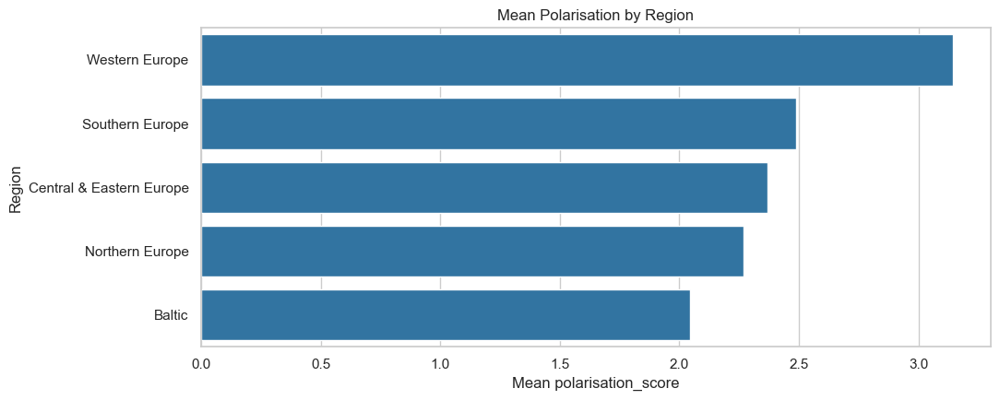

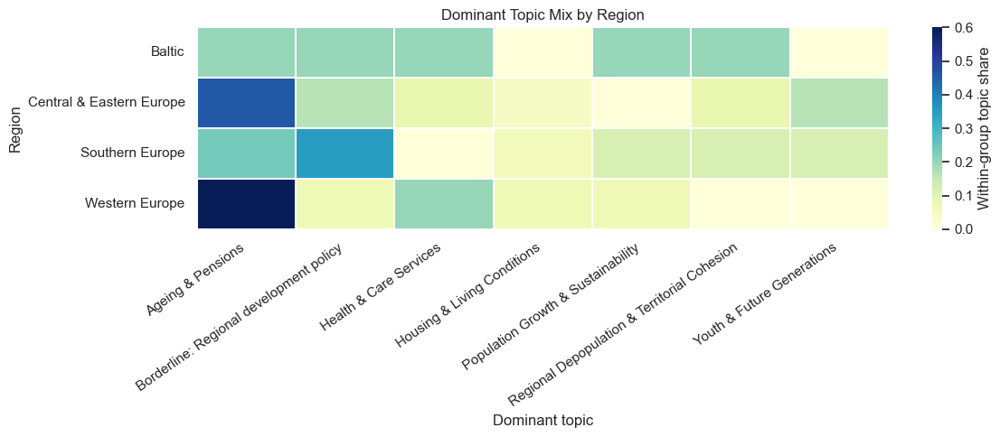

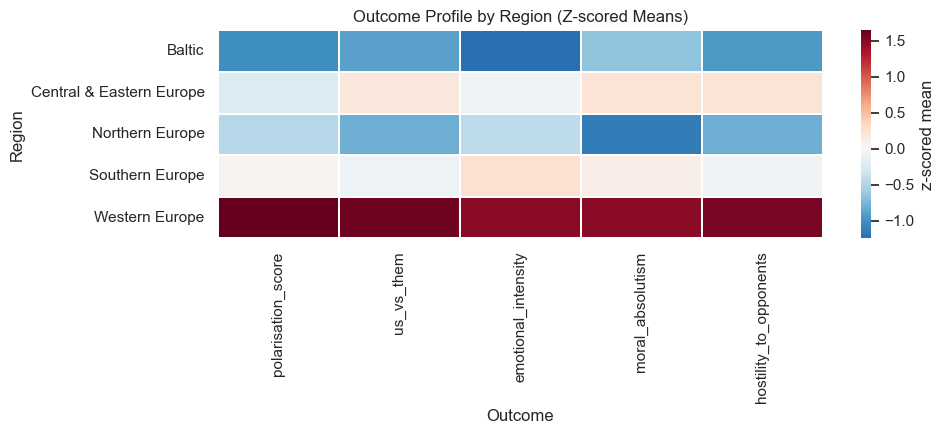


Professional Background: polarisation summary (n >= 5)


,Professional Background,n_obs,mean_polarisation,median_polarisation,sd_polarisation
0,Other / Unclear,7,4.028571,2.5,3.099309
1,Academia / Education,17,3.505882,2.5,2.523012
2,Politics / Public Administration,93,2.370968,2.0,1.624646
3,Business / Finance,8,1.975000,1.2,1.891900
4,Media / Journalism,9,1.666667,1.2,1.024695


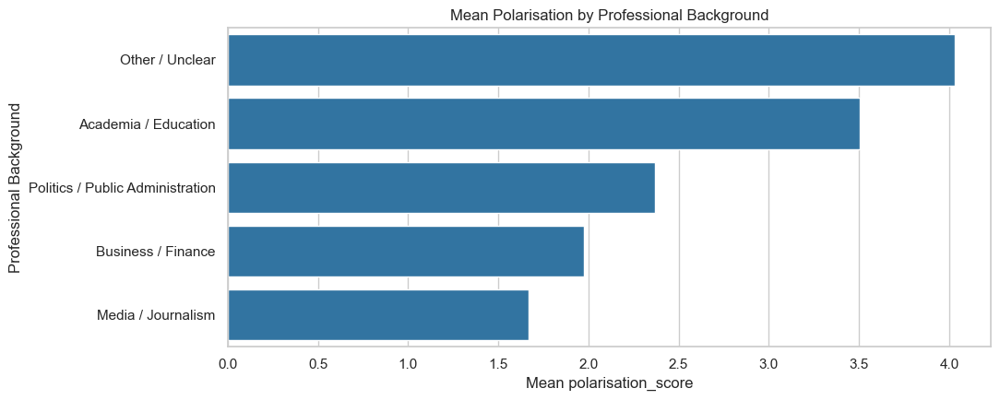

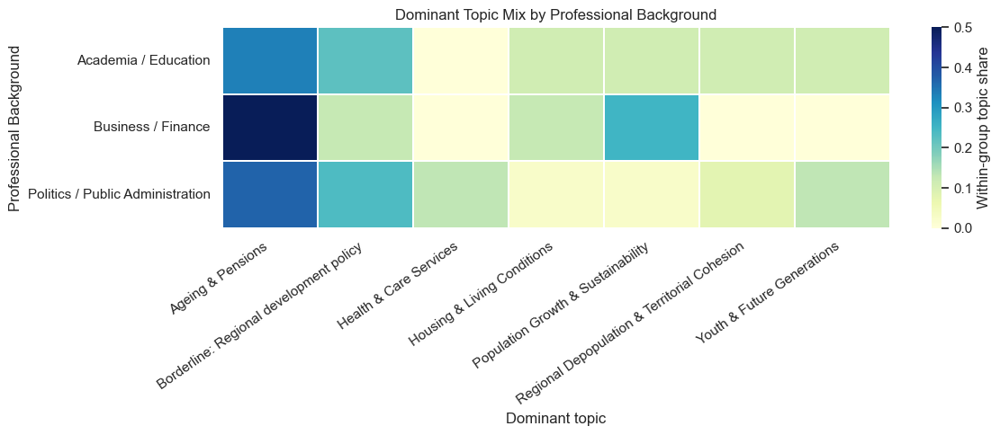

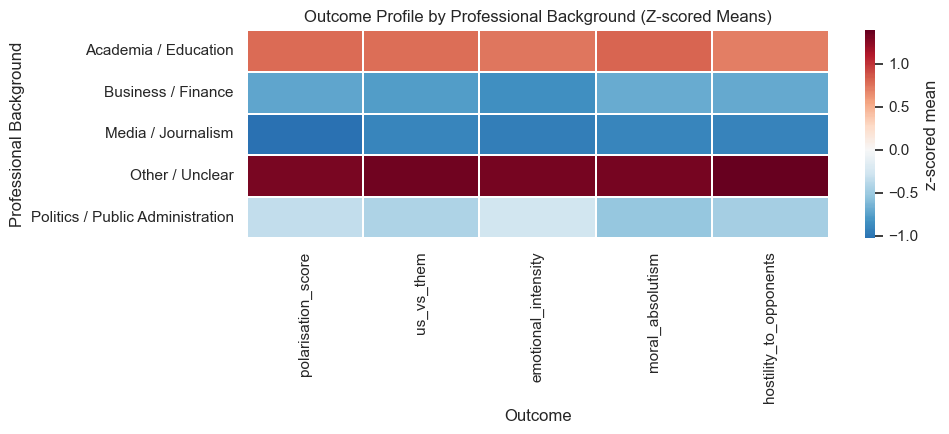

Skipping Age Group: column 'age_group' not found.
Skipping Tenure Group: column 'tenure_group' not found.
Skipping International Experience: not enough usable categories after min_n=3 filter.
Skipping Migration Background: not enough usable categories after min_n=3 filter.
Skipping Military Background: not enough usable categories after min_n=3 filter.
Extended characteristic-based descriptive analysis complete.


In [ ]:
if "analysis_df" not in globals():
    raise RuntimeError("analysis_df is missing. Run the cleaning/model prep cells first.")
if "polarisation_score" not in analysis_df.columns:
    raise RuntimeError("polarisation_score is required for characteristic-based descriptive analysis.")
sns.set_theme(style="whitegrid", context="notebook")
FIGURE_OUTPUT_DIR = globals().get("FIGURE_OUTPUT_DIR", PROJECT_ROOT / "8 Final regression" / "figures")
FIGURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def _compact_fig_name(filename):
    stem = Path(filename).stem.lower()
    stem = re.sub(r"[^a-z0-9]+", "_", stem).strip("_")
    token_map = {
        "descriptive": "desc", "polarisation": "pol", "correlation": "corr",
        "random": "rf", "forest": "rf", "association": "assoc", "strength": "str",
        "feature": "feat", "importance": "imp", "cluster": "cl", "country": "cty",
        "topic": "tp", "group": "grp", "party": "pty", "profile": "prof",
        "interaction": "int", "interactions": "ints", "composition": "comp",
        "prevalence": "prev", "outcome": "out", "outcomes": "outs",
        "distribution": "dist", "distributions": "dists", "heatmap": "hm",
        "scatter": "scat", "ranking": "rank", "silhouette": "sil",
        "high": "hi", "low": "lo", "absolute": "abs", "professional": "prof",
        "background": "bg",
    }
    parts = [token_map.get(p, p[:4]) for p in stem.split("_") if p]
    compact = "_".join(parts)
    compact = (compact[:48].rstrip("_") or "fig")
    return f"{compact}.png"
def save_figure_local(filename):
    plt.savefig(FIGURE_OUTPUT_DIR / _compact_fig_name(filename), dpi=300, bbox_inches="tight")
def safe_name(text):
    return re.sub(r"[^a-z0-9]+", "_", str(text).strip().lower()).strip("_")
SHORT_FIGURE_NAME_MAP = {
    "professional_background_clean": "prof_bg",
}

def prep_category_series(df, col):
    s = df[col].copy()
    if col.endswith("_flag"):
        s = pd.to_numeric(s, errors="coerce").map({1.0: "Yes", 0.0: "No"})
    s = s.astype("string").str.strip()
    s = s.replace({"": pd.NA, "nan": pd.NA, "None": pd.NA})
    return s
characteristics = [
    ("region_clean", "Region", 5),
    ("professional_background_clean", "Professional Background", 5),
    ("age_group", "Age Group", 5),
    ("tenure_group", "Tenure Group", 5),
    ("international_experience_flag", "International Experience", 3),
    ("migration_background_flag", "Migration Background", 3),
    ("military_background_flag", "Military Background", 3),
]
topic_col = "dominant_topic" if "dominant_topic" in analysis_df.columns else ("dominant_cluster" if "dominant_cluster" in analysis_df.columns else None)
outcomes = [
    c for c in [
        "polarisation_score",
        "us_vs_them",
        "emotional_intensity",
        "moral_absolutism",
        "hostility_to_opponents",
    ] if c in analysis_df.columns
]
characteristic_tables = {}

for col, label, min_n in characteristics:
    if col not in analysis_df.columns:
        print(f"Skipping {label}: column '{col}' not found.")
        continue
    work = analysis_df.copy()
    work["_score"] = pd.to_numeric(work["polarisation_score"], errors="coerce")
    work["_cat"] = prep_category_series(work, col)
    if topic_col is not None:
        work["_topic"] = work[topic_col].astype("string").str.strip()
        work["_topic"] = work["_topic"].replace({"": pd.NA, "nan": pd.NA, "None": pd.NA})
    work = work.dropna(subset=["_score", "_cat"])
    counts = work["_cat"].value_counts()
    valid_groups = counts[counts >= min_n].index
    work = work[work["_cat"].isin(valid_groups)]
    if work.empty or work["_cat"].nunique() < 2:
        print(f"Skipping {label}: not enough usable categories after min_n={min_n} filter.")
        continue
    summary = (
        work.groupby("_cat")["_score"]
        .agg(n_obs="size", mean_polarisation="mean", median_polarisation="median", sd_polarisation="std")
        .sort_values("mean_polarisation", ascending=False)
        .reset_index()
        .rename(columns={"_cat": label})
    )
    characteristic_tables[col] = summary
    print(f"\n{label}: polarisation summary (n >= {min_n})")
    display(summary)
    # Mean polarisation by characteristic level
    plt.figure(figsize=(11, max(4.5, 0.4 * len(summary))))
    ax = sns.barplot(data=summary, y=label, x="mean_polarisation", color="#1f77b4")
    ax.set_title(f"Mean Polarisation by {label}")
    ax.set_xlabel("Mean polarisation_score")
    ax.set_ylabel(label)
    plt.tight_layout()
    file_slug = SHORT_FIGURE_NAME_MAP.get(col, safe_name(col))
    save_figure_local(f"descriptive_polarisation_by_{file_slug}.png")
    # Save this figure from this plotting block
    if "FIGURES_DIR" in globals():
        _fig_save_dir = FIGURES_DIR
    elif "FIGURES_OUT_DIR" in globals():
        _fig_save_dir = FIGURES_OUT_DIR
    else:
        _fig_save_dir = (PROJECT_ROOT if "PROJECT_ROOT" in globals() else Path.cwd()) / "outputs" / "figures"
    _fig_save_dir.mkdir(parents=True, exist_ok=True)
    _fig_out = _fig_save_dir / f"cell_30_plot_001.png"
    plt.savefig(_fig_out, dpi=300, bbox_inches="tight")
    plt.show()
    # Topic mix by characteristic level (row-normalized)
    if topic_col is not None and "_topic" in work.columns:
        topic_work = work.dropna(subset=["_topic"]).copy()
        topic_work = topic_work[topic_work["_topic"].astype(str).str.strip().ne("Other")]
        if not topic_work.empty:
            topic_count = pd.crosstab(topic_work["_cat"], topic_work["_topic"])
            topic_count = topic_count.loc[topic_count.sum(axis=1) >= min_n, topic_count.sum(axis=0) >= 3]
            if topic_count.shape[0] >= 2 and topic_count.shape[1] >= 2:
                topic_share = topic_count.div(topic_count.sum(axis=1), axis=0)
                plt.figure(figsize=(12, max(5, 0.45 * len(topic_share))))
                sns.heatmap(topic_share, cmap="YlGnBu", linewidths=0.25, cbar_kws={"label": "Within-group topic share"})
                plt.title(f"Dominant Topic Mix by {label}")
                plt.xlabel("Dominant topic")
                plt.ylabel(label)
                plt.xticks(rotation=35, ha="right")
                plt.tight_layout()
                save_figure_local(f"descriptive_topic_mix_by_{safe_name(col)}.png")
                # Save this figure from this plotting block
                if "FIGURES_DIR" in globals():
                    _fig_save_dir = FIGURES_DIR
                elif "FIGURES_OUT_DIR" in globals():
                    _fig_save_dir = FIGURES_OUT_DIR
                else:
                    _fig_save_dir = (PROJECT_ROOT if "PROJECT_ROOT" in globals() else Path.cwd()) / "outputs" / "figures"
                _fig_save_dir.mkdir(parents=True, exist_ok=True)
                _fig_out = _fig_save_dir / f"cell_30_plot_002.png"
                plt.savefig(_fig_out, dpi=300, bbox_inches="tight")
                plt.show()
    # Outcome profile by characteristic level (z-scored means)
    if len(outcomes) >= 2:
        profile = work.groupby("_cat")[outcomes].mean(numeric_only=True)
        profile = profile.loc[profile.index.intersection(valid_groups)]
        if profile.shape[0] >= 2:
            profile_z = (profile - profile.mean(axis=0)) / profile.std(axis=0).replace(0, np.nan)
            profile_z = profile_z.fillna(0.0)
            plt.figure(figsize=(10, max(4.5, 0.4 * len(profile_z))))
            sns.heatmap(profile_z, cmap="RdBu_r", center=0, linewidths=0.25, cbar_kws={"label": "z-scored mean"})
            plt.title(f"Outcome Profile by {label} (Z-scored Means)")
            plt.xlabel("Outcome")
            plt.ylabel(label)
            plt.tight_layout()
            save_figure_local(f"descriptive_outcome_profile_by_{safe_name(col)}.png")
            # Save this figure from this plotting block
            if "FIGURES_DIR" in globals():
                _fig_save_dir = FIGURES_DIR
            elif "FIGURES_OUT_DIR" in globals():
                _fig_save_dir = FIGURES_OUT_DIR
            else:
                _fig_save_dir = (PROJECT_ROOT if "PROJECT_ROOT" in globals() else Path.cwd()) / "outputs" / "figures"
            _fig_save_dir.mkdir(parents=True, exist_ok=True)
            _fig_out = _fig_save_dir / f"cell_30_plot_003.png"
            plt.savefig(_fig_out, dpi=300, bbox_inches="tight")
            plt.show()
print("Extended characteristic-based descriptive analysis complete.")

In [ ]:
print('analysis_df shape:', analysis_df.shape)
key_cols = [
    'polarisation_score',
    'ep_group_extracted',
    'ep_group_clean',
    'dominant_cluster',
    'topic_polarisation_cluster',
    'cluster',
]

for col in key_cols:
    if col in analysis_df.columns:
        s = analysis_df[col]
        print(f'{col}: non-null={int(s.notna().sum())}, unique_non_null={int(s.dropna().nunique())}')
    else:
        print(f'{col}: missing')
for col in ['Ageing & Pensions', 'Migration & Population Change', 'Youth & Future Generations', 'Housing & Living Conditions', 'Health & Care Services', 'Population Growth & Sustainability']:
    if col in analysis_df.columns:
        s = pd.to_numeric(analysis_df[col], errors='coerce')
        print(f'{col}: numeric_non_null={int(s.notna().sum())}, mean={s.mean():.4f} if s.notna().any() else None')

analysis_df shape: (139, 124)
polarisation_score: non-null=139, unique_non_null=17
ep_group_extracted: non-null=118, unique_non_null=42
ep_group_clean: non-null=139, unique_non_null=15
dominant_cluster: non-null=139, unique_non_null=11
topic_polarisation_cluster: non-null=139, unique_non_null=2
cluster: missing
Ageing & Pensions: numeric_non_null=139, mean=0.1805 if s.notna().any() else None
Migration & Population Change: numeric_non_null=139, mean=0.0249 if s.notna().any() else None
Youth & Future Generations: numeric_non_null=139, mean=0.0359 if s.notna().any() else None
Housing & Living Conditions: numeric_non_null=139, mean=0.0215 if s.notna().any() else None
Health & Care Services: numeric_non_null=139, mean=0.0502 if s.notna().any() else None
Population Growth & Sustainability: numeric_non_null=139, mean=0.0345 if s.notna().any() else None


In [ ]:
# Print missing values per column for the cleaned MEP dataframe.
print(analysis_df.isna().sum().to_string())

# Save cleaned data while coalescing duplicate-named columns (e.g., repeated topic columns).
export_df = analysis_df.copy()
duplicate_column_names = export_df.columns[export_df.columns.duplicated()].unique().tolist()

if duplicate_column_names:
    dedup_df = export_df.loc[:, ~export_df.columns.duplicated()].copy()
    for duplicate_name in duplicate_column_names:
        duplicate_block = export_df.loc[:, export_df.columns == duplicate_name]
        dedup_df[duplicate_name] = duplicate_block.bfill(axis=1).iloc[:, 0]
    export_df = dedup_df
    print(f"Coalesced duplicate columns before export: {duplicate_column_names}")
export_df.to_excel(MERGED_OUTPUT_PATH, index=False)
print(f"Saved cleaned dataset to: {MERGED_OUTPUT_PATH}")
print(f"Columns saved: {list(export_df.columns)}")

mep_name_clean                                            0
mep_name_raw                                              0
n_documents                                               0
Ageing & Pensions                                         0
Borderline: Economic governance and employment            0
Borderline: Island regions and cohesion                   0
Borderline: Labour market and social policy               0
Borderline: Regional development policy                   0
Borderline: Youth / demographic future (weak signal)      0
Fertility, Families & Gender                              0
Health & Care Services                                    0
Housing & Living Conditions                               0
Migration & Population Change                             0
Population Growth & Sustainability                        0
Regional Depopulation & Territorial Cohesion              0
Youth & Future Generations                                0
Other                                   

## Interaction Analysis: Country Context and Topic Emphasis

This section adds a focused interaction analysis using standardized variables and block-wise model comparison.

Interpretation note: all estimates are correlational associations and should not be interpreted as causal effects.

In [ ]:
# Standardise country and topic variables, then create interaction candidates.

if "analysis_df" not in globals():
    raise RuntimeError("analysis_df is missing. Run the merge/cleaning cells first.")
TABLES_DIR = globals().get("TABLES_DIR", Path.cwd() / "outputs" / "tables")
FIGURES_DIR = globals().get("FIGURES_DIR", Path.cwd() / "outputs" / "figures")
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
interaction_work_df = analysis_df.copy()

def _zscore_series(s: pd.Series) -> pd.Series:
    numeric = pd.to_numeric(s, errors="coerce")
    mean_v = numeric.mean(skipna=True)
    std_v = numeric.std(skipna=True, ddof=0)
    if pd.isna(std_v) or std_v == 0:
        # Keep missing values as missing; constant non-missing values become 0.
        return numeric - mean_v
    return (numeric - mean_v) / std_v
country_vars = [
    "old_age_dependency_ratio",
    "pension_expenditure_gdp",
    "employment_rate_55_64",
    "debt_to_gdp",
    "foreign_born_population_share",
    "net_migration",
    "fertility_rate",
    "youth_unemployment",
]
topic_alias_candidates = {
    "topic_share_ageing_pensions": [
        "Ageing & Pensions",
        "Ageing and Pensions",
        "topic_share_ageing_pensions",
    ],
    "topic_share_migration_population": [
        "Migration & Population Change",
        "Migration and Population Change",
        "topic_share_migration_population",
    ],
    "topic_share_fertility_family": [
        "Fertility Families & Gender",
        "Fertility, Families & Gender",
        "Fertility, Family & Gender",
        "topic_share_fertility_family",
    ],
    "topic_share_youth_future": [
        "Youth & Future Generations",
        "Youth and Future Generations",
        "topic_share_youth_future",
    ],
    "topic_share_fiscal_pensions": [
        "Borderline: Economic governance/employment",
        "Economic governance/employment",
        "topic_share_fiscal_pensions",
    ],
}

def _first_available(df: pd.DataFrame, candidates: list[str]) -> str | None:
    for c in candidates:
        if c in df.columns:
            return c
    return None
standardized_rows = []

for col in country_vars:
    if col in interaction_work_df.columns:
        z_col = f"z_{col}"
        interaction_work_df[z_col] = _zscore_series(interaction_work_df[col])
        standardized_rows.append(
            {
                "source_col": col,
                "z_col": z_col,
                "created": True,
                "n_non_null": int(interaction_work_df[z_col].notna().sum()),
                "mean_z": float(interaction_work_df[z_col].mean(skipna=True)) if interaction_work_df[z_col].notna().any() else np.nan,
                "std_z": float(interaction_work_df[z_col].std(skipna=True, ddof=0)) if interaction_work_df[z_col].notna().any() else np.nan,
            }
        )
    else:
        standardized_rows.append(
            {
                "source_col": col,
                "z_col": f"z_{col}",
                "created": False,
                "n_non_null": 0,
                "mean_z": np.nan,
                "std_z": np.nan,
            }
        )
resolved_topic_cols = {}

for canonical_name, candidates in topic_alias_candidates.items():
    src_col = _first_available(interaction_work_df, candidates)
    resolved_topic_cols[canonical_name] = src_col
    z_col = f"z_{canonical_name}"
    if src_col is not None:
        interaction_work_df[z_col] = _zscore_series(interaction_work_df[src_col])
        standardized_rows.append(
            {
                "source_col": src_col,
                "z_col": z_col,
                "created": True,
                "n_non_null": int(interaction_work_df[z_col].notna().sum()),
                "mean_z": float(interaction_work_df[z_col].mean(skipna=True)) if interaction_work_df[z_col].notna().any() else np.nan,
                "std_z": float(interaction_work_df[z_col].std(skipna=True, ddof=0)) if interaction_work_df[z_col].notna().any() else np.nan,
            }
        )
    else:
        standardized_rows.append(
            {
                "source_col": f"missing ({canonical_name})",
                "z_col": z_col,
                "created": False,
                "n_non_null": 0,
                "mean_z": np.nan,
                "std_z": np.nan,
            }
        )
country_interaction_specs = {
    "int_ageing_pension": ("z_old_age_dependency_ratio", "z_pension_expenditure_gdp"),
    "int_ageing_old_employment": ("z_old_age_dependency_ratio", "z_employment_rate_55_64"),
    "int_pension_debt": ("z_pension_expenditure_gdp", "z_debt_to_gdp"),
    "int_ageing_foreign_born": ("z_old_age_dependency_ratio", "z_foreign_born_population_share"),
    "int_ageing_youth_unemp": ("z_old_age_dependency_ratio", "z_youth_unemployment"),
    "int_fertility_migration": ("z_fertility_rate", "z_net_migration"),
}
topic_interaction_specs = {
    "int_topic_ageing_dependency": ("z_topic_share_ageing_pensions", "z_old_age_dependency_ratio"),
    "int_topic_ageing_pension_exp": ("z_topic_share_ageing_pensions", "z_pension_expenditure_gdp"),
    "int_topic_migration_foreign_born": ("z_topic_share_migration_population", "z_foreign_born_population_share"),
    "int_topic_migration_net_migration": ("z_topic_share_migration_population", "z_net_migration"),
    "int_topic_fertility_rate": ("z_topic_share_fertility_family", "z_fertility_rate"),
    "int_topic_youth_unemployment": ("z_topic_share_youth_future", "z_youth_unemployment"),
    "int_topic_fiscal_debt": ("z_topic_share_fiscal_pensions", "z_debt_to_gdp"),
}
created_interactions = []

for interaction_name, (lhs, rhs) in {**country_interaction_specs, **topic_interaction_specs}.items():
    if lhs in interaction_work_df.columns and rhs in interaction_work_df.columns:
        interaction_work_df[interaction_name] = interaction_work_df[lhs] * interaction_work_df[rhs]
        created = True
        n_non_null = int(interaction_work_df[interaction_name].notna().sum())
    else:
        created = False
        n_non_null = 0
    created_interactions.append(
        {
            "interaction": interaction_name,
            "lhs": lhs,
            "rhs": rhs,
            "created": created,
            "n_non_null": n_non_null,
            "group": "country_context" if interaction_name in country_interaction_specs else "topic_by_country",
        }
    )
standardization_diagnostics = pd.DataFrame(standardized_rows)
interaction_creation_table = pd.DataFrame(created_interactions)
display(standardization_diagnostics)
print("\nInteraction availability:")
display(interaction_creation_table)
skipped_topic_interactions = interaction_creation_table.loc[
    (interaction_creation_table["group"] == "topic_by_country")
    & (~interaction_creation_table["created"]),
    ["interaction", "lhs", "rhs"],
]

if not skipped_topic_interactions.empty:
    print("\nSkipped topic-by-country interactions (required standardized topic/share variable not available):")
    display(skipped_topic_interactions)
standardization_diagnostics.to_csv(TABLES_DIR / "interaction_standardization_diagnostics.csv", index=False)
interaction_creation_table.to_csv(TABLES_DIR / "interaction_created_columns.csv", index=False)
analysis_df = interaction_work_df
print("\nUpdated analysis_df with standardized and interaction columns:", analysis_df.shape)
print("Saved: interaction_standardization_diagnostics.csv, interaction_created_columns.csv")

,source_col,z_col,created,n_non_null,mean_z,std_z
0,old_age_dependency_ratio,z_old_age_dependency_ratio,True,139,2.926516e-15,1.0
1,pension_expenditure_gdp,z_pension_expenditure_gdp,False,0,NaN,NaN
2,employment_rate_55_64,z_employment_rate_55_64,True,134,-2.187305e-16,1.0
3,debt_to_gdp,z_debt_to_gdp,True,134,1.035656e-16,1.0
4,foreign_born_population_share,z_foreign_born_population_share,True,139,2.396165e-17,1.0
5,net_migration,z_net_migration,True,139,4.792330e-17,1.0
6,fertility_rate,z_fertility_rate,True,139,-1.453673e-16,1.0
7,youth_unemployment,z_youth_unemployment,True,134,-2.278443e-17,1.0
8,Ageing & Pensions,z_topic_share_ageing_pensions,True,139,-2.555909e-17,1.0
9,Migration & Population Change,z_topic_share_migration_population,True,139,5.750796e-17,1.0



Interaction availability:


,interaction,lhs,rhs,created,n_non_null,group
0,int_ageing_pension,z_old_age_dependency_ratio,z_pension_expenditure_gdp,False,0,country_context
1,int_ageing_old_employment,z_old_age_dependency_ratio,z_employment_rate_55_64,True,134,country_context
2,int_pension_debt,z_pension_expenditure_gdp,z_debt_to_gdp,False,0,country_context
3,int_ageing_foreign_born,z_old_age_dependency_ratio,z_foreign_born_population_share,True,139,country_context
4,int_ageing_youth_unemp,z_old_age_dependency_ratio,z_youth_unemployment,True,134,country_context
5,int_fertility_migration,z_fertility_rate,z_net_migration,True,139,country_context
6,int_topic_ageing_dependency,z_topic_share_ageing_pensions,z_old_age_dependency_ratio,True,139,topic_by_country
7,int_topic_ageing_pension_exp,z_topic_share_ageing_pensions,z_pension_expenditure_gdp,False,0,topic_by_country
8,int_topic_migration_foreign_born,z_topic_share_migration_population,z_foreign_born_population_share,True,139,topic_by_country
9,int_topic_migration_net_migration,z_topic_share_migration_population,z_net_migration,True,139,topic_by_country



Skipped topic-by-country interactions (required standardized topic/share variable not available):


,interaction,lhs,rhs
7,int_topic_ageing_pension_exp,z_topic_share_ageing_pensions,z_pension_expenditure_gdp
12,int_topic_fiscal_debt,z_topic_share_fiscal_pensions,z_debt_to_gdp



Updated analysis_df with standardized and interaction columns: (139, 144)
Saved: interaction_standardization_diagnostics.csv, interaction_created_columns.csv


In [ ]:
# Block-wise interaction models (interpretable progression):
# Block 1: standardized country context
# Block 2: Block 1 + standardized topic shares
# Block 3: Block 2 + topic-by-country interactions

if "analysis_df" not in globals():
    raise RuntimeError("analysis_df is missing.")
outcomes = [
    c for c in [
        "polarisation_score",
        "us_vs_them",
        "emotional_intensity",
        "moral_absolutism",
        "hostility_to_opponents",
    ] if c in analysis_df.columns
]
country_main = [c for c in [
    "z_old_age_dependency_ratio",
    "z_pension_expenditure_gdp",
    "z_employment_rate_55_64",
    "z_debt_to_gdp",
    "z_foreign_born_population_share",
    "z_net_migration",
    "z_fertility_rate",
    "z_youth_unemployment",
] if c in analysis_df.columns]
topic_main = [c for c in [
    "z_topic_share_ageing_pensions",
    "z_topic_share_migration_population",
    "z_topic_share_fertility_family",
    "z_topic_share_youth_future",
    "z_topic_share_fiscal_pensions",
] if c in analysis_df.columns]
country_interactions = [
    c for c in [
        "int_ageing_pension",
        "int_ageing_old_employment",
        "int_pension_debt",
        "int_ageing_foreign_born",
        "int_ageing_youth_unemp",
        "int_fertility_migration",
    ] if c in analysis_df.columns
]
topic_interactions = [
    c for c in [
        "int_topic_ageing_dependency",
        "int_topic_ageing_pension_exp",
        "int_topic_migration_foreign_born",
        "int_topic_migration_net_migration",
        "int_topic_fertility_rate",
        "int_topic_youth_unemployment",
        "int_topic_fiscal_debt",
    ] if c in analysis_df.columns
]
categorical_controls = [c for c in ["ep_group_clean", "region_clean"] if c in analysis_df.columns]
block_specs = [
    ("block_1_country_context", country_main + country_interactions),
    ("block_2_plus_topic_main", country_main + country_interactions + topic_main),
    ("block_3_plus_topic_interactions", country_main + country_interactions + topic_main + topic_interactions),
]

def _fit_block(df: pd.DataFrame, outcome: str, predictors: list[str], controls: list[str]) -> tuple[dict, pd.DataFrame]:
    cols_needed = [outcome] + predictors + controls
    work = df[cols_needed].copy()
    work[outcome] = pd.to_numeric(work[outcome], errors="coerce")
    work = work.dropna(subset=[outcome])
    x_num = work[predictors].apply(pd.to_numeric, errors="coerce") if predictors else pd.DataFrame(index=work.index)
    if controls:
        x_cat = pd.get_dummies(work[controls].astype("string"), drop_first=True, dtype=float)
    else:
        x_cat = pd.DataFrame(index=work.index)
    X = pd.concat([x_num, x_cat], axis=1)
    model_df = pd.concat([work[[outcome]], X], axis=1).dropna()
    if model_df.empty or model_df.shape[0] < 25 or model_df.shape[1] < 3:
        return (
            {
                "n_rows": int(model_df.shape[0]),
                "n_features": int(max(model_df.shape[1] - 1, 0)),
                "cv_r2_mean": np.nan,
                "cv_r2_std": np.nan,
                "note": "insufficient complete-case rows for this block",
            },
            pd.DataFrame(columns=["feature", "coef", "abs_coef"]),
        )
    y = model_df[outcome]
    X_model = model_df.drop(columns=[outcome])
    n_splits = min(5, int(model_df.shape[0]))
    cv = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    lr = LinearRegression()
    scores = cross_val_score(lr, X_model, y, scoring="r2", cv=cv)
    lr.fit(X_model, y)
    coef_df = pd.DataFrame({
        "feature": X_model.columns,
        "coef": lr.coef_,
    })
    coef_df["abs_coef"] = coef_df["coef"].abs()
    return (
        {
            "n_rows": int(model_df.shape[0]),
            "n_features": int(X_model.shape[1]),
            "cv_r2_mean": float(np.mean(scores)),
            "cv_r2_std": float(np.std(scores)),
            "note": "Associational OLS with standardized predictors and controls",
        },
        coef_df,
    )
summary_rows = []
interaction_coef_rows = []
all_defined_interactions = set(country_interactions + topic_interactions)

for outcome in outcomes:
    for block_name, block_predictors in block_specs:
        block_predictors = [c for c in block_predictors if c in analysis_df.columns]
        fit_summary, coef_df = _fit_block(analysis_df, outcome, block_predictors, categorical_controls)
        summary_rows.append(
            {
                "outcome": outcome,
                "model_block": block_name,
                **fit_summary,
            }
        )
        if not coef_df.empty:
            inter_df = coef_df[coef_df["feature"].isin(all_defined_interactions)].copy()
            if not inter_df.empty:
                inter_df["outcome"] = outcome
                inter_df["model_block"] = block_name
                interaction_coef_rows.append(inter_df[["outcome", "model_block", "feature", "coef", "abs_coef"]])
interaction_block_summary = pd.DataFrame(summary_rows)
interaction_block_coefs = (
    pd.concat(interaction_coef_rows, axis=0, ignore_index=True)
    if interaction_coef_rows else pd.DataFrame(columns=["outcome", "model_block", "feature", "coef", "abs_coef"])
)
interaction_block_summary = interaction_block_summary.sort_values(["outcome", "model_block"]).reset_index(drop=True)

if not interaction_block_coefs.empty:
    interaction_block_coefs = interaction_block_coefs.sort_values(["outcome", "model_block", "feature"]).reset_index(drop=True)
print("Block-wise model comparison (correlational interpretation):")
display(interaction_block_summary)

if not interaction_block_coefs.empty:
    print("\nInteraction coefficients by block:")
    display(interaction_block_coefs)
else:
    print("\nNo interaction coefficients available (likely due missing required columns in this run).")
interaction_block_summary.to_csv(TABLES_DIR / "interaction_block_model_summary.csv", index=False)
interaction_block_coefs.to_csv(TABLES_DIR / "interaction_block_coefficients.csv", index=False)
print("Saved: interaction_block_model_summary.csv, interaction_block_coefficients.csv")

Block-wise model comparison (correlational interpretation):


,outcome,model_block,n_rows,n_features,cv_r2_mean,cv_r2_std,note
0,emotional_intensity,block_1_country_context,134,29,-0.263996,0.287137,Associational OLS with standardized predictors...
1,emotional_intensity,block_2_plus_topic_main,134,33,-0.382925,0.377762,Associational OLS with standardized predictors...
2,emotional_intensity,block_3_plus_topic_interactions,134,38,-0.586954,0.336054,Associational OLS with standardized predictors...
3,hostility_to_opponents,block_1_country_context,134,29,-0.331935,0.530937,Associational OLS with standardized predictors...
4,hostility_to_opponents,block_2_plus_topic_main,134,33,-0.555982,0.686957,Associational OLS with standardized predictors...
5,hostility_to_opponents,block_3_plus_topic_interactions,134,38,-0.467179,0.329908,Associational OLS with standardized predictors...
6,moral_absolutism,block_1_country_context,134,29,-0.402532,0.408310,Associational OLS with standardized predictors...
7,moral_absolutism,block_2_plus_topic_main,134,33,-0.515112,0.478627,Associational OLS with standardized predictors...
8,moral_absolutism,block_3_plus_topic_interactions,134,38,-0.818827,0.582283,Associational OLS with standardized predictors...
9,polarisation_score,block_1_country_context,134,29,-0.351243,0.301261,Associational OLS with standardized predictors...



Interaction coefficients by block:


,outcome,model_block,feature,coef,abs_coef
0,emotional_intensity,block_1_country_context,int_ageing_foreign_born,0.012435,0.012435
1,emotional_intensity,block_1_country_context,int_ageing_old_employment,-0.291393,0.291393
2,emotional_intensity,block_1_country_context,int_ageing_youth_unemp,-0.101104,0.101104
3,emotional_intensity,block_1_country_context,int_fertility_migration,-0.108065,0.108065
4,emotional_intensity,block_2_plus_topic_main,int_ageing_foreign_born,0.103089,0.103089
...,...,...,...,...,...
80,us_vs_them,block_3_plus_topic_interactions,int_topic_ageing_dependency,0.185747,0.185747
81,us_vs_them,block_3_plus_topic_interactions,int_topic_fertility_rate,-0.766742,0.766742
82,us_vs_them,block_3_plus_topic_interactions,int_topic_migration_foreign_born,1.958746,1.958746
83,us_vs_them,block_3_plus_topic_interactions,int_topic_migration_net_migration,-0.457072,0.457072


Saved: interaction_block_model_summary.csv, interaction_block_coefficients.csv


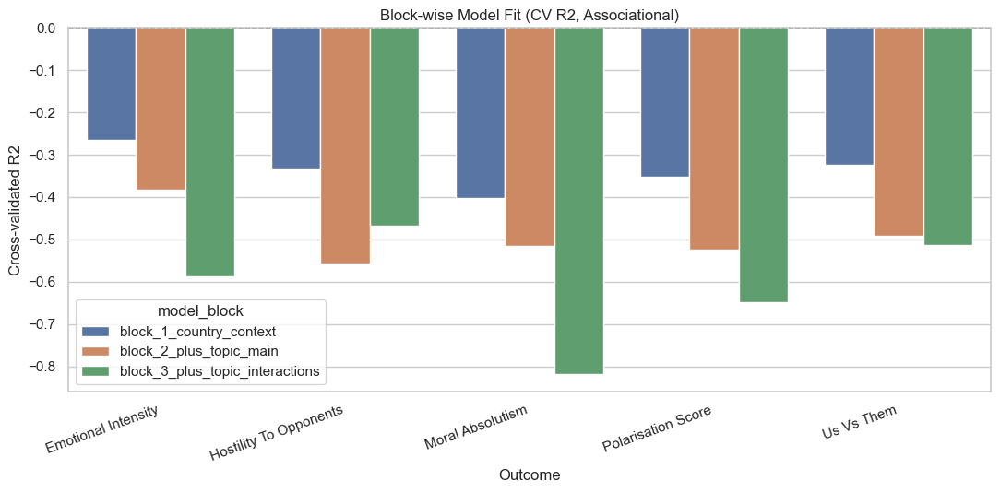

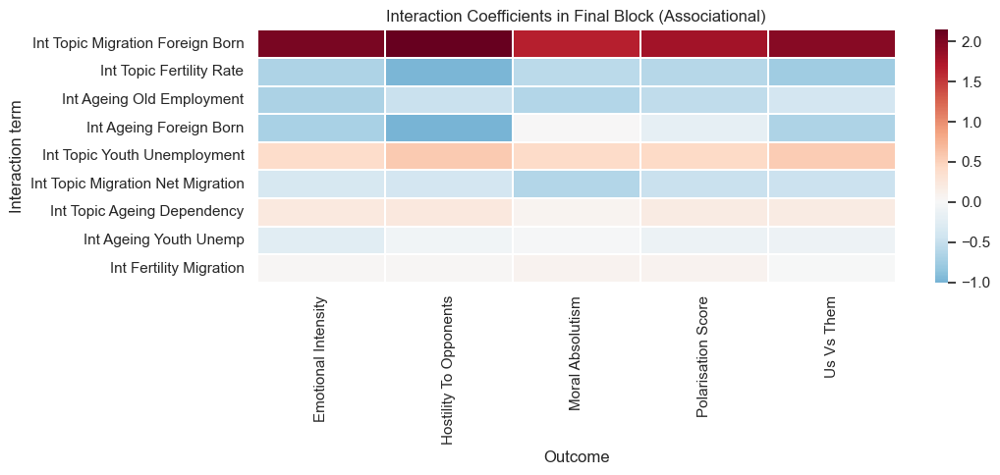

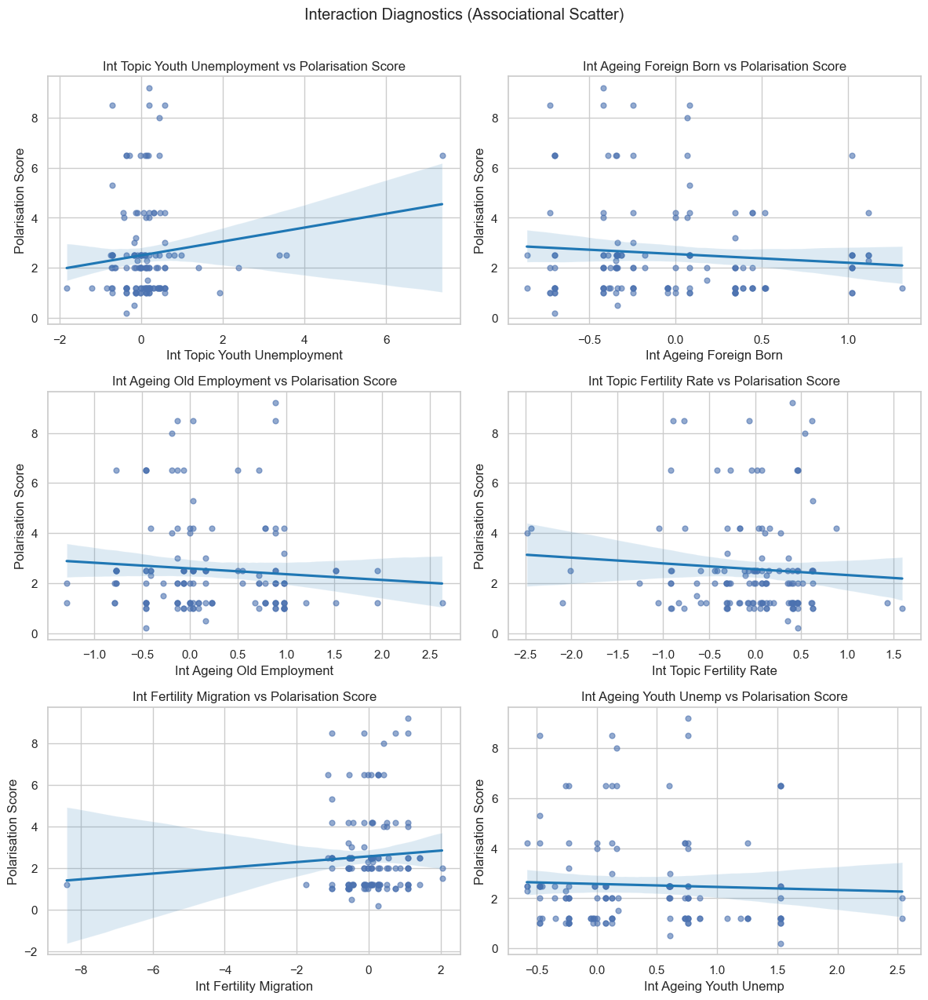

Saved figures: interaction_block_cv_r2.png, interaction_coefficients_heatmap.png, interaction_scatter_diagnostics.png


In [ ]:
# Interaction diagnostics figures

if "interaction_block_summary" not in globals():
    raise RuntimeError("Run the interaction model block first.")
sns.set_theme(style="whitegrid", context="notebook")

def pretty_display_name(value):
    text = str(value)
    text = re.sub(r"^z_", "", text)
    text = text.replace("_x_", " x ").replace("__", " ").replace("_", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text.title()
# 1) CV R2 by block and outcome
plot_summary = interaction_block_summary.dropna(subset=["cv_r2_mean"]).copy()
plot_summary["outcome_label"] = plot_summary["outcome"].map(pretty_display_name)

if not plot_summary.empty:
    plt.figure(figsize=(11, 5.5))
    sns.barplot(
        data=plot_summary,
        x="outcome_label",
        y="cv_r2_mean",
        hue="model_block",
        errorbar=None,
    )
    plt.axhline(0.0, color="black", linestyle="--", linewidth=1)
    plt.title("Block-wise Model Fit (CV R2, Associational)")
    plt.xlabel("Outcome")
    plt.ylabel("Cross-validated R2")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "interaction_block_cv_r2.png", dpi=300, bbox_inches="tight")
    plt.show()
# 2) Heatmap of interaction coefficients in the final block

if "interaction_block_coefs" in globals() and not interaction_block_coefs.empty:
    heat_df = interaction_block_coefs[
        interaction_block_coefs["model_block"].eq("block_3_plus_topic_interactions")
    ].copy()
    if not heat_df.empty:
        heat_pivot = heat_df.pivot_table(
            index="feature",
            columns="outcome",
            values="coef",
            aggfunc="mean",
        )
        heat_pivot = heat_pivot.dropna(how="all")
        if not heat_pivot.empty:
            # Keep the most informative interactions for readability.
            order = heat_pivot.abs().mean(axis=1).sort_values(ascending=False).head(12).index
            heat_pivot = heat_pivot.loc[order]
            heat_pivot = heat_pivot.copy()
            heat_pivot.index = [pretty_display_name(v) for v in heat_pivot.index]
            heat_pivot.columns = [pretty_display_name(v) for v in heat_pivot.columns]
            plt.figure(figsize=(11, max(5, 0.45 * len(heat_pivot))))
            sns.heatmap(heat_pivot, cmap="RdBu_r", center=0, linewidths=0.25)
            plt.title("Interaction Coefficients in Final Block (Associational)")
            plt.xlabel("Outcome")
            plt.ylabel("Interaction term")
            plt.tight_layout()
            plt.savefig(FIGURES_DIR / "interaction_coefficients_heatmap.png", dpi=300, bbox_inches="tight")
            plt.show()
# 3) Scatter diagnostics for top available interactions vs polarisation_score

if "polarisation_score" in analysis_df.columns and "interaction_creation_table" in globals():
    available_ints = interaction_creation_table.loc[
        interaction_creation_table["created"], "interaction"
    ].tolist()
    if available_ints:
        ranked = []
        for col in available_ints:
            pair = analysis_df[[col, "polarisation_score"]].copy()
            pair[col] = pd.to_numeric(pair[col], errors="coerce")
            pair["polarisation_score"] = pd.to_numeric(pair["polarisation_score"], errors="coerce")
            pair = pair.dropna()
            if len(pair) >= 20:
                corr = pair[col].corr(pair["polarisation_score"])
                ranked.append((col, abs(corr) if pd.notna(corr) else 0.0, len(pair)))
        top_interactions = [x[0] for x in sorted(ranked, key=lambda t: t[1], reverse=True)[:6]]
        if top_interactions:
            n = len(top_interactions)
            ncols = 2
            nrows = int(np.ceil(n / ncols))
            fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 4.2 * nrows), squeeze=False)
            axes_flat = axes.flatten()
            for i, inter_col in enumerate(top_interactions):
                pair = analysis_df[[inter_col, "polarisation_score"]].copy()
                pair[inter_col] = pd.to_numeric(pair[inter_col], errors="coerce")
                pair["polarisation_score"] = pd.to_numeric(pair["polarisation_score"], errors="coerce")
                pair = pair.dropna()
                ax = axes_flat[i]
                sns.regplot(data=pair, x=inter_col, y="polarisation_score", scatter_kws={"alpha": 0.6, "s": 24}, line_kws={"color": "#1f77b4"}, ax=ax)
                ax.set_title(f"{pretty_display_name(inter_col)} vs {pretty_display_name('polarisation_score')}")
                ax.set_xlabel(pretty_display_name(inter_col))
                ax.set_ylabel(pretty_display_name("polarisation_score"))
            for j in range(n, len(axes_flat)):
                axes_flat[j].axis("off")
            fig.suptitle("Interaction Diagnostics (Associational Scatter)", y=1.01)
            fig.tight_layout()
            fig.savefig(FIGURES_DIR / "interaction_scatter_diagnostics.png", dpi=300, bbox_inches="tight")
            plt.show()
print("Saved figures: interaction_block_cv_r2.png, interaction_coefficients_heatmap.png, interaction_scatter_diagnostics.png")

## Exploratory interaction screening across polarisation and emotion outcomes

This section is exploratory and hypothesis-generating. The interaction heat maps screen many possible associations between topic emphasis, MEP characteristics, country context, and polarisation/emotion outcomes. These models are correlational and should not be interpreted as causal evidence. Because many interactions are tested, the heat maps are used to identify patterns for discussion rather than to confirm definitive effects.

c:\Users\Gebruiker\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:2014: RuntimeWarning: divide by zero encountered in divide
  self.het_scale = (self.wresid / (1 - h))**2
c:\Users\Gebruiker\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:2014: RuntimeWarning: divide by zero encountered in divide
  self.het_scale = (self.wresid / (1 - h))**2
c:\Users\Gebruiker\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:2014: RuntimeWarning: divide by zero encountered in divide
  self.het_scale = (self.wresid / (1 - h))**2
c:\Users\Gebruiker\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:2014: RuntimeWarning: divide by zero encountered in divide
  self.het_scale = (self.wresid / (1 - h))**2
c:\Users\Gebruiker\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:2014: RuntimeWarning: divide by zero encountered in divide
  self.het_scale = (self.wresid / (1 - h))**2
c:\Users\Gebruiker\anaconda3\Lib\site-package

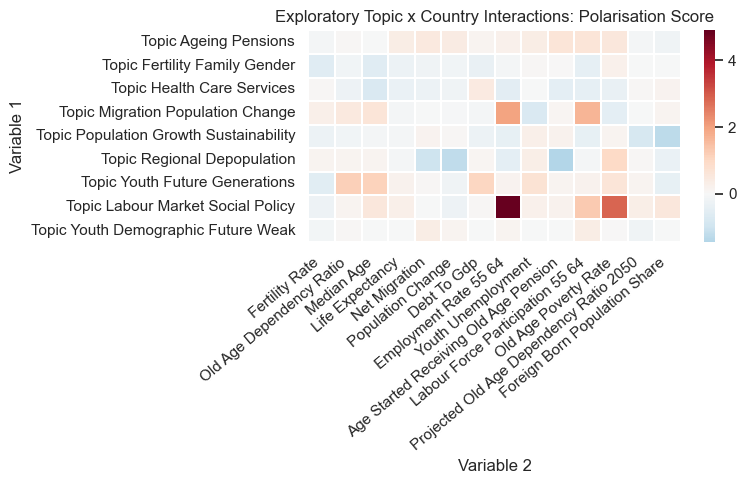

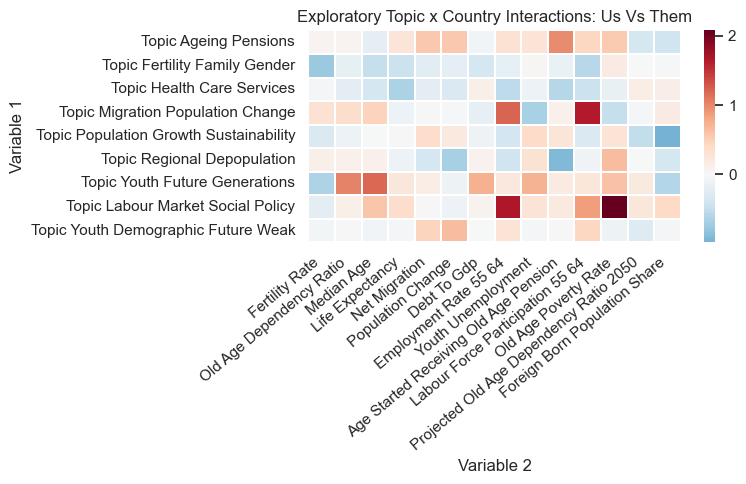

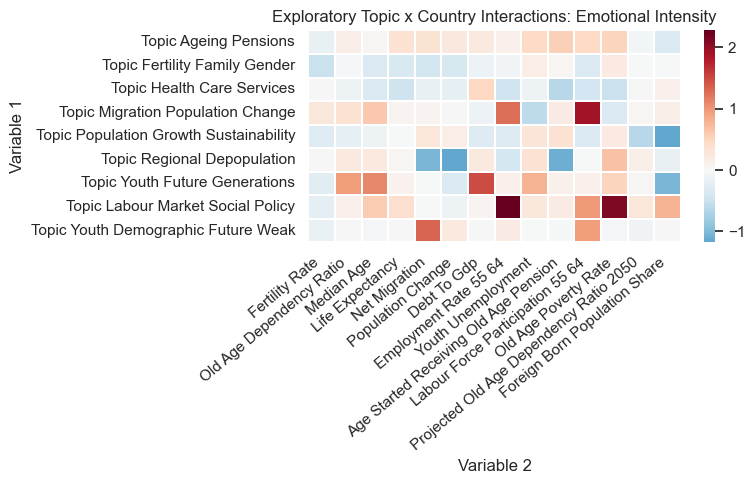

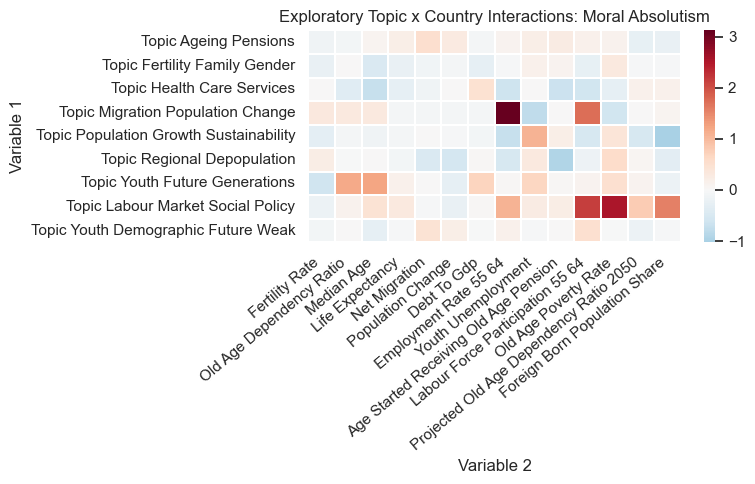

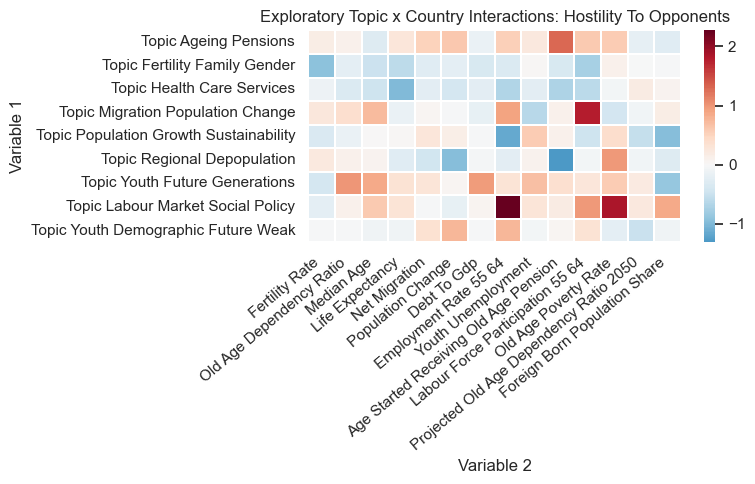

...

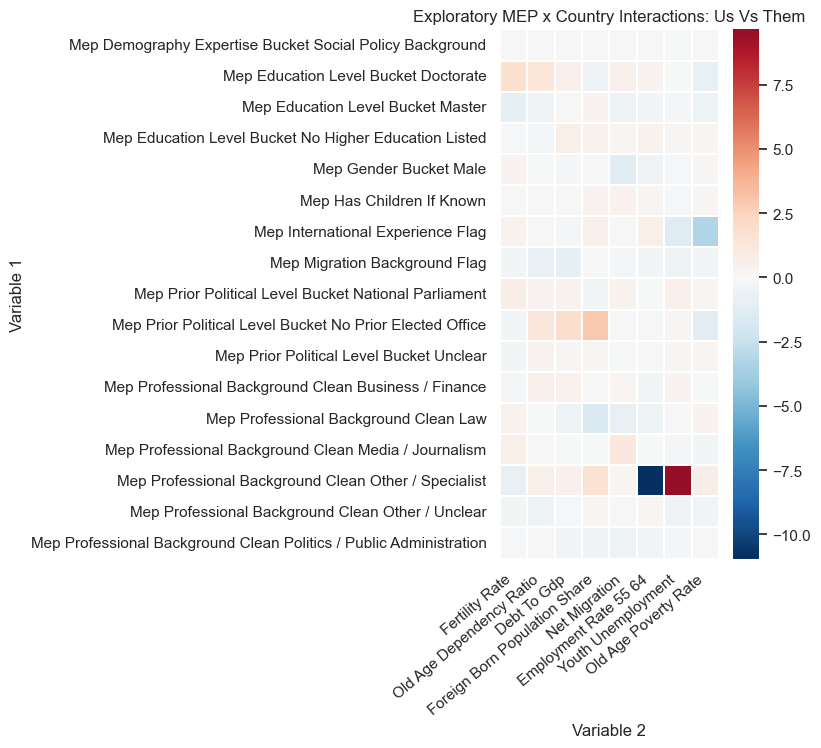

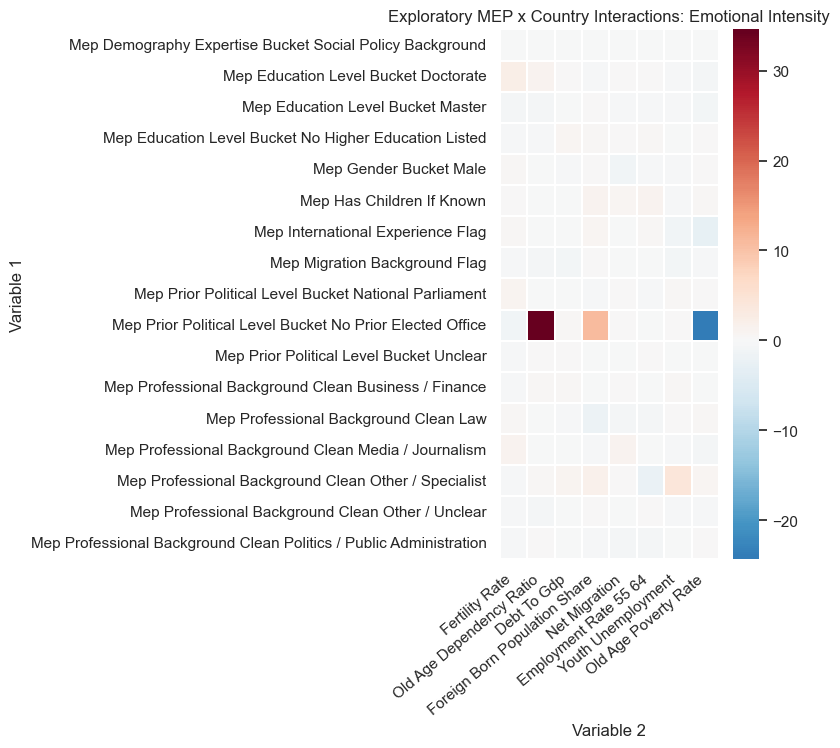

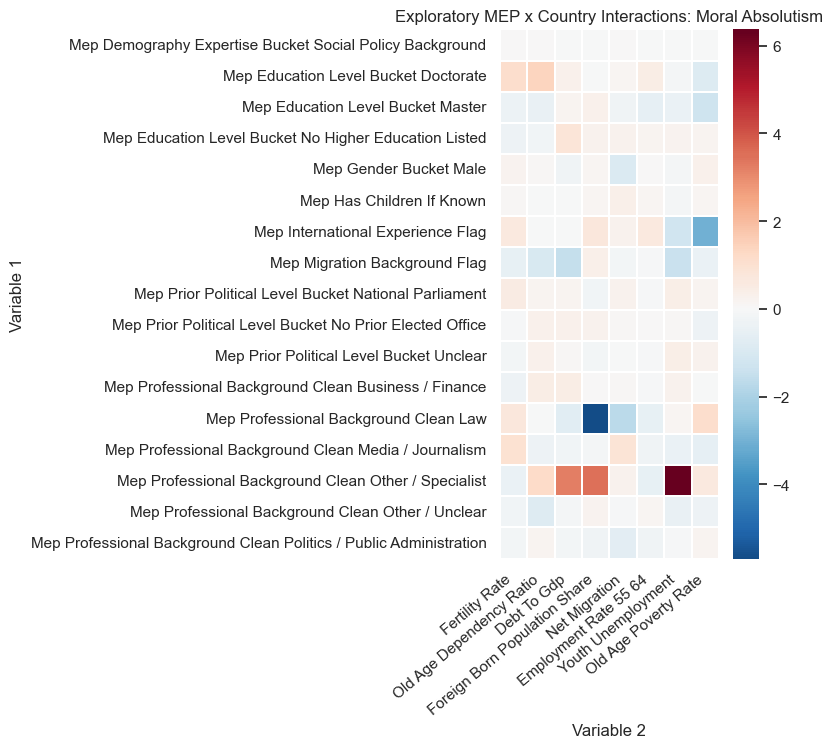

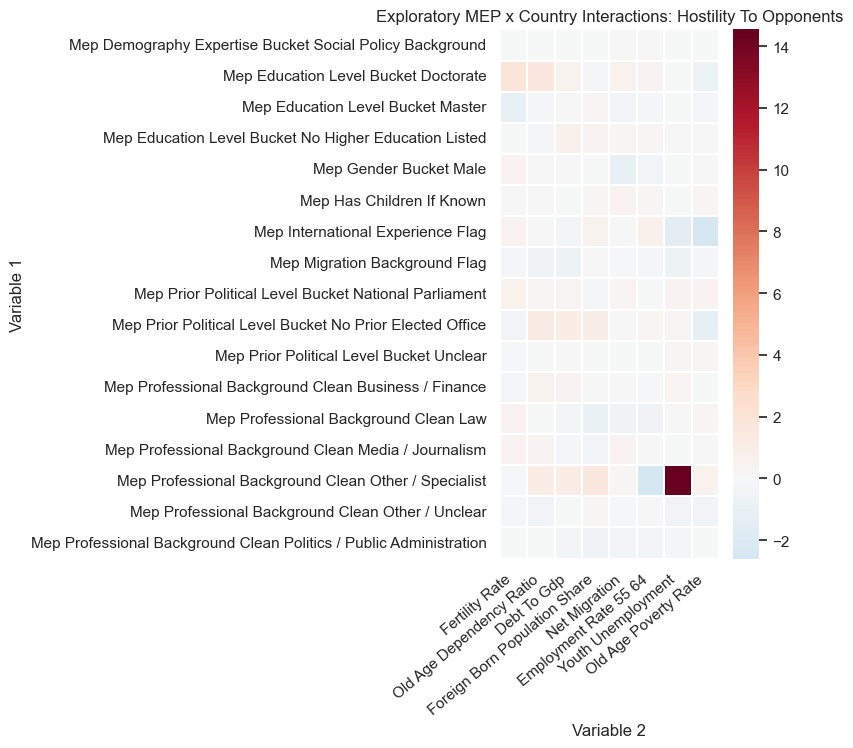

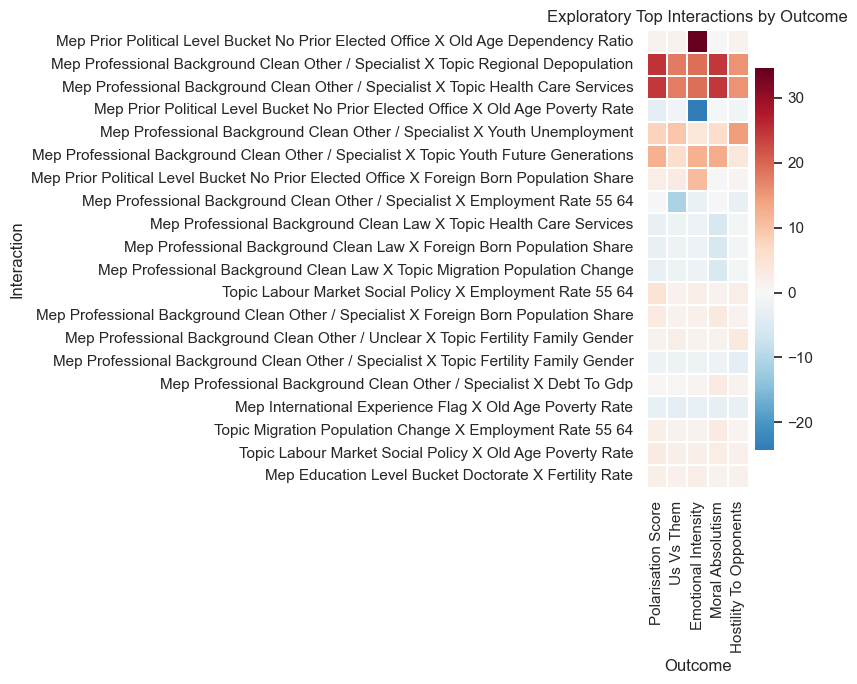

Exploratory screening complete (hypothesis-generating only).
Detected outcomes: ['polarisation_score', 'us_vs_them', 'emotional_intensity', 'moral_absolutism', 'hostility_to_opponents']
Attempted models: 2090
Successful models: 2090
Skipped/error models: 0


,outcome_variable,interaction_family,variable_1,variable_2,interaction_name,coefficient,standard_error,p_value,ci_lower,ci_upper,n_observations,adjusted_r2,model_status,warning,raw_significant_5pct,p_value_fdr,fdr_significant_10pct,exploratory_only,signed_score
0,polarisation_score,topic_x_country,topic_ageing_pensions,fertility_rate,topic_ageing_pensions x fertility_rate,-0.039651,0.184303,0.829660,-0.400878,0.321577,139,0.120336,ok,fixed effects skipped due limited sample size,False,1.0,False,True,-0.081100
1,polarisation_score,topic_x_country,topic_ageing_pensions,old_age_dependency_ratio,topic_ageing_pensions x old_age_dependency_ratio,0.031257,0.139872,0.823168,-0.242886,0.305401,139,0.120036,ok,fixed effects skipped due limited sample size,False,1.0,False,True,0.084512
2,polarisation_score,topic_x_country,topic_ageing_pensions,median_age,topic_ageing_pensions x median_age,-0.003641,0.142011,0.979547,-0.281978,0.274697,139,0.113985,ok,fixed effects skipped due limited sample size,False,1.0,False,True,-0.008975
3,polarisation_score,topic_x_country,topic_ageing_pensions,life_expectancy,topic_ageing_pensions x life_expectancy,0.149282,0.188764,0.429039,-0.220689,0.519252,139,0.121678,ok,fixed effects skipped due limited sample size,False,1.0,False,True,0.367504
4,polarisation_score,topic_x_country,topic_ageing_pensions,net_migration,topic_ageing_pensions x net_migration,0.242589,0.243051,0.318232,-0.233782,0.718960,139,0.122505,ok,fixed effects skipped due limited sample size,False,1.0,False,True,0.497256
5,polarisation_score,topic_x_country,topic_ageing_pensions,population_change,topic_ageing_pensions x population_change,0.159863,0.185875,0.389757,-0.204445,0.524171,139,0.118698,ok,fixed effects skipped due limited sample size,False,1.0,False,True,0.409207
6,polarisation_score,topic_x_country,topic_ageing_pensions,debt_to_gdp,topic_ageing_pensions x debt_to_gdp,0.058096,0.168748,0.730639,-0.272644,0.388835,134,0.131911,ok,fixed effects skipped due limited sample size,False,1.0,False,True,0.136297
7,polarisation_score,topic_x_country,topic_ageing_pensions,employment_rate_55_64,topic_ageing_pensions x employment_rate_55_64,0.094442,0.160876,0.557173,-0.220870,0.409754,134,0.137195,ok,fixed effects skipped due limited sample size,False,1.0,False,True,0.254010
8,polarisation_score,topic_x_country,topic_ageing_pensions,youth_unemployment,topic_ageing_pensions x youth_unemployment,0.252003,0.310873,0.417578,-0.357296,0.861302,134,0.150146,ok,fixed effects skipped due limited sample size,False,1.0,False,True,0.379263
9,polarisation_score,topic_x_country,topic_ageing_pensions,age_started_receiving_old_age_pension,topic_ageing_pensions x age_started_receiving_...,0.239366,0.199668,0.230598,-0.151976,0.630707,134,0.160006,ok,fixed effects skipped due limited sample size,False,1.0,False,True,0.637145


,interaction_family,interaction_name,outcome_variable,coefficient,p_value,p_value_fdr,signed_score,n_observations,interpretation_note
1681,topic_x_country,topic_ageing_pensions x age_started_receiving_...,hostility_to_opponents,0.397994,0.050151,0.911447,1.299717,134,"Exploratory, correlational interaction signal;..."
427,topic_x_country,topic_ageing_pensions x age_started_receiving_...,us_vs_them,0.344176,0.105133,1.000000,0.978262,134,"Exploratory, correlational interaction signal;..."
928,topic_x_country,topic_youth_future_generations x youth_unemplo...,emotional_intensity,0.307605,0.160946,1.000000,0.793319,134,"Exploratory, correlational interaction signal;..."
510,topic_x_country,topic_youth_future_generations x youth_unemplo...,us_vs_them,0.462079,0.188671,1.000000,0.724295,134,"Exploratory, correlational interaction signal;..."
92,topic_x_country,topic_youth_future_generations x youth_unemplo...,polarisation_score,0.328318,0.193823,1.000000,0.712595,134,"Exploratory, correlational interaction signal;..."
1764,topic_x_country,topic_youth_future_generations x youth_unemplo...,hostility_to_opponents,0.524233,0.207548,1.000000,0.682880,134,"Exploratory, correlational interaction signal;..."
1346,topic_x_country,topic_youth_future_generations x youth_unemplo...,moral_absolutism,0.344421,0.216296,1.000000,0.664952,134,"Exploratory, correlational interaction signal;..."
9,topic_x_country,topic_ageing_pensions x age_started_receiving_...,polarisation_score,0.239366,0.230598,1.000000,0.637145,134,"Exploratory, correlational interaction signal;..."
845,topic_x_country,topic_ageing_pensions x age_started_receiving_...,emotional_intensity,0.209030,0.287274,1.000000,0.541704,134,"Exploratory, correlational interaction signal;..."
1263,topic_x_country,topic_ageing_pensions x age_started_receiving_...,moral_absolutism,0.164276,0.562968,1.000000,0.249516,134,"Exploratory, correlational interaction signal;..."


In [ ]:
# Exploratory interaction screening (separate from main analysis).
# This block is intentionally hypothesis-generating and correlational.

if "analysis_df" not in globals():
    raise RuntimeError("analysis_df is missing. Run the main pipeline cells first.")
TABLES_DIR = globals().get("TABLES_DIR", Path.cwd() / "outputs" / "tables")
FIGURES_DIR = globals().get("FIGURES_DIR", Path.cwd() / "outputs" / "figures")
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
expl_df = analysis_df.copy()

# --- Topic aliases (keep original columns, add code-friendly duplicates) ---
topic_alias_map = {
    "Ageing & Pensions": "topic_ageing_pensions",
    "Fertility, Families & Gender": "topic_fertility_family_gender",
    "Health & Care Services": "topic_health_care_services",
    "Migration & Population Change": "topic_migration_population_change",
    "Population Growth & Sustainability": "topic_population_growth_sustainability",
    "Regional Depopulation & Territorial Cohesion": "topic_regional_depopulation",
    "Youth & Future Generations": "topic_youth_future_generations",
    "Borderline: Labour market and social policy": "topic_labour_market_social_policy",
    "Borderline: Youth / demographic future (weak signal)": "topic_youth_demographic_future_weak",
}
expl_warnings = []

for original_col, alias_col in topic_alias_map.items():
    if original_col in expl_df.columns:
        expl_df[alias_col] = pd.to_numeric(expl_df[original_col], errors="coerce")
    else:
        expl_warnings.append(f"Missing topic column skipped: {original_col}")
# --- Outcome variables (confidence intentionally excluded as a main outcome) ---
outcome_candidates = [
    "polarisation_score",
    "us_vs_them",
    "emotional_intensity",
    "moral_absolutism",
    "hostility_to_opponents",
]
detected_outcomes = [c for c in outcome_candidates if c in expl_df.columns]

if not detected_outcomes:
    raise RuntimeError("No requested outcome variables available for exploratory screening.")
# --- Family variable lists ---
family1_topics = [
    "topic_ageing_pensions",
    "topic_fertility_family_gender",
    "topic_health_care_services",
    "topic_migration_population_change",
    "topic_population_growth_sustainability",
    "topic_regional_depopulation",
    "topic_youth_future_generations",
    "topic_labour_market_social_policy",
    "topic_youth_demographic_future_weak",
]
family1_country = [
    "fertility_rate",
    "old_age_dependency_ratio",
    "median_age",
    "life_expectancy",
    "net_migration",
    "population_change",
    "debt_to_gdp",
    "employment_rate_55_64",
    "youth_unemployment",
    "age_started_receiving_old_age_pension",
    "labour_force_participation_55_64",
    "old_age_poverty_rate",
    "projected_old_age_dependency_ratio_2050",
    "foreign_born_population_share",
]
family2_mep = [
    "gender_bucket",
    "education_level_bucket",
    "education_field_clean",
    "professional_background_clean",
    "migration_background_flag",
    "international_experience_flag",
    "military_background_flag",
    "parental_status_known",
    "has_children_if_known",
    "religion_mentioned_flag",
    "prior_political_level_bucket",
    "demography_expertise_bucket",
]
family2_topics = [
    "topic_ageing_pensions",
    "topic_fertility_family_gender",
    "topic_health_care_services",
    "topic_migration_population_change",
    "topic_youth_future_generations",
    "topic_regional_depopulation",
]
family3_mep = [
    "gender_bucket",
    "education_level_bucket",
    "professional_background_clean",
    "migration_background_flag",
    "international_experience_flag",
    "has_children_if_known",
    "prior_political_level_bucket",
    "demography_expertise_bucket",
]
family3_country = [
    "fertility_rate",
    "old_age_dependency_ratio",
    "debt_to_gdp",
    "foreign_born_population_share",
    "net_migration",
    "employment_rate_55_64",
    "youth_unemployment",
    "old_age_poverty_rate",
]

# --- Helpers ---

def _safe_slug(text: str) -> str:
    text = str(text).strip().lower()
    text = "".join(ch if (ch.isalnum() or ch == "_") else "_" for ch in text)
    while "__" in text:
        text = text.replace("__", "_")
    return text.strip("_") or "x"
def _to_binary_if_possible(series: pd.Series):
    s = series.copy()
    if pd.api.types.is_numeric_dtype(s):
        s_num = pd.to_numeric(s, errors="coerce")
        uniq = sorted([v for v in s_num.dropna().unique().tolist()])
        if len(uniq) == 2 and set(uniq).issubset({0, 1}):
            return s_num, True
        return s_num, False
    s_str = s.astype("string").str.strip().str.lower()
    map_dict = {
        "yes": 1, "y": 1, "true": 1, "1": 1,
        "no": 0, "n": 0, "false": 0, "0": 0,
    }
    mapped = s_str.map(map_dict)
    uniq = sorted([v for v in mapped.dropna().unique().tolist()])
    if len(uniq) == 2 and set(uniq).issubset({0, 1}):
        return mapped.astype(float), True
    return s, False
def _zscore(series: pd.Series) -> pd.Series:
    x = pd.to_numeric(series, errors="coerce")
    mu = x.mean(skipna=True)
    sd = x.std(skipna=True, ddof=0)
    if pd.isna(sd) or sd == 0:
        return x - mu
    return (x - mu) / sd
def _prepare_continuous_var(df: pd.DataFrame, col: str, missing_threshold: float = 0.75):
    if col not in df.columns:
        return None, f"missing column: {col}"
    x = pd.to_numeric(df[col], errors="coerce")
    miss = x.isna().mean()
    uniq = x.dropna().nunique()
    if miss > missing_threshold:
        return None, f"too much missingness ({miss:.2%}): {col}"
    if uniq < 2:
        return None, f"fewer than two unique values: {col}"
    z_col = f"z_{col}"
    df[z_col] = _zscore(x)
    return z_col, None
# Prepare standardized country/topic vars
continuous_candidates = sorted(set(family1_topics + family1_country + family3_country + [
    "n_relevant_speeches", "n_documents", "confidence"
]))
standardized_map = {}

for col in continuous_candidates:
    new_col, warn = _prepare_continuous_var(expl_df, col)
    if new_col is not None:
        standardized_map[col] = new_col
    elif warn is not None:
        expl_warnings.append(warn)
# Prepare MEP variables (binary keep; >2 categories to dummies, drop first)
mep_model_cols = {}

for mep_col in sorted(set(family2_mep + family3_mep)):
    if mep_col not in expl_df.columns:
        expl_warnings.append(f"missing MEP variable: {mep_col}")
        mep_model_cols[mep_col] = []
        continue
    raw = expl_df[mep_col]
    maybe_bin, is_binary = _to_binary_if_possible(raw)
    if is_binary:
        model_col = f"mep_{mep_col}"
        expl_df[model_col] = pd.to_numeric(maybe_bin, errors="coerce")
        if expl_df[model_col].dropna().nunique() >= 2:
            mep_model_cols[mep_col] = [model_col]
        else:
            mep_model_cols[mep_col] = []
            expl_warnings.append(f"binary MEP variable has <2 unique values: {mep_col}")
        continue
    cat = raw.astype("string").str.strip()
    cat = cat.replace({"": pd.NA, "nan": pd.NA, "None": pd.NA})
    nunique = cat.dropna().nunique()
    if nunique < 2:
        mep_model_cols[mep_col] = []
        expl_warnings.append(f"categorical MEP variable has <2 unique values: {mep_col}")
        continue
    dummies = pd.get_dummies(cat, prefix=f"mep_{mep_col}", drop_first=True, dtype=float)
    if dummies.shape[1] == 0:
        mep_model_cols[mep_col] = []
        expl_warnings.append(f"no dummies created (drop_first) for: {mep_col}")
        continue
    expl_df = pd.concat([expl_df, dummies], axis=1)
    mep_model_cols[mep_col] = dummies.columns.tolist()
# Controls (continuous standardized controls, plus optional confidence)
control_cols = [c for c in [
    standardized_map.get("n_relevant_speeches"),
    standardized_map.get("n_documents"),
    standardized_map.get("confidence"),
] if c is not None]

# Optional fixed effects columns
fe_candidates = [c for c in ["country_clean_final", "ep_group_clean"] if c in expl_df.columns]

# --- Regression engine ---

def _fit_single_interaction(
    df: pd.DataFrame,
    outcome: str,
    x1_col: str,
    x2_col: str,
    interaction_family: str,
    var1_label: str,
    var2_label: str,
    min_n: int = 35,
):
    warning_msgs = []
    use_cols = [outcome, x1_col, x2_col] + control_cols + fe_candidates
    work = df[use_cols].copy()
    work[outcome] = pd.to_numeric(work[outcome], errors="coerce")
    # Ensure x terms are numeric where possible.
    work[x1_col] = pd.to_numeric(work[x1_col], errors="coerce")
    work[x2_col] = pd.to_numeric(work[x2_col], errors="coerce")
    # FE kept as categorical strings.
    for fe_col in fe_candidates:
        work[fe_col] = work[fe_col].astype("string").str.strip()
        work[fe_col] = work[fe_col].replace({"": pd.NA, "nan": pd.NA, "None": pd.NA})
    work = work.dropna(subset=[outcome, x1_col, x2_col] + control_cols)
    if work.shape[0] < min_n:
        return {
            "outcome_variable": outcome,
            "interaction_family": interaction_family,
            "variable_1": var1_label,
            "variable_2": var2_label,
            "interaction_name": f"{var1_label} x {var2_label}",
            "coefficient": np.nan,
            "standard_error": np.nan,
            "p_value": np.nan,
            "ci_lower": np.nan,
            "ci_upper": np.nan,
            "n_observations": int(work.shape[0]),
            "adjusted_r2": np.nan,
            "model_status": "skipped",
            "warning": f"too few observations (<{min_n})",
        }
    X = work[[x1_col, x2_col] + control_cols].copy()
    inter_col = f"int__{_safe_slug(x1_col)}__{_safe_slug(x2_col)}"
    X[inter_col] = X[x1_col] * X[x2_col]
    # Optional FE if stable (enough rows per dummy burden)
    fe_used = []
    if fe_candidates:
        fe_dummies_all = []
        for fe_col in fe_candidates:
            valid_fe = work[fe_col].dropna().nunique()
            if valid_fe >= 2:
                d = pd.get_dummies(work[fe_col], prefix=f"fe_{fe_col}", drop_first=True, dtype=float)
                if d.shape[1] > 0:
                    fe_dummies_all.append(d)
        if fe_dummies_all:
            fe_mat = pd.concat(fe_dummies_all, axis=1)
            prospective_k = X.shape[1] + fe_mat.shape[1] + 1
            if work.shape[0] >= max(45, 4 * prospective_k):
                X = pd.concat([X, fe_mat], axis=1)
                fe_used = fe_mat.columns.tolist()
            else:
                warning_msgs.append("fixed effects skipped due limited sample size")
    # Final complete-case matrix
    model_df = pd.concat([work[[outcome]], X], axis=1).dropna()
    n_obs = int(model_df.shape[0])
    if n_obs < min_n:
        return {
            "outcome_variable": outcome,
            "interaction_family": interaction_family,
            "variable_1": var1_label,
            "variable_2": var2_label,
            "interaction_name": f"{var1_label} x {var2_label}",
            "coefficient": np.nan,
            "standard_error": np.nan,
            "p_value": np.nan,
            "ci_lower": np.nan,
            "ci_upper": np.nan,
            "n_observations": n_obs,
            "adjusted_r2": np.nan,
            "model_status": "skipped",
            "warning": "too few complete cases after controls/FE",
        }
    y = model_df[outcome]
    X_model = sm.add_constant(model_df.drop(columns=[outcome]), has_constant="add")
    try:
        fit = sm.OLS(y, X_model).fit(cov_type="HC3")
        if inter_col not in fit.params.index:
            return {
                "outcome_variable": outcome,
                "interaction_family": interaction_family,
                "variable_1": var1_label,
                "variable_2": var2_label,
                "interaction_name": f"{var1_label} x {var2_label}",
                "coefficient": np.nan,
                "standard_error": np.nan,
                "p_value": np.nan,
                "ci_lower": np.nan,
                "ci_upper": np.nan,
                "n_observations": n_obs,
                "adjusted_r2": float(fit.rsquared_adj) if np.isfinite(fit.rsquared_adj) else np.nan,
                "model_status": "error",
                "warning": "interaction term dropped/singular",
            }
        ci = fit.conf_int().loc[inter_col]
        if fe_used:
            warning_msgs.append("fixed effects included")
        return {
            "outcome_variable": outcome,
            "interaction_family": interaction_family,
            "variable_1": var1_label,
            "variable_2": var2_label,
            "interaction_name": f"{var1_label} x {var2_label}",
            "coefficient": float(fit.params[inter_col]),
            "standard_error": float(fit.bse[inter_col]),
            "p_value": float(fit.pvalues[inter_col]),
            "ci_lower": float(ci.iloc[0]),
            "ci_upper": float(ci.iloc[1]),
            "n_observations": n_obs,
            "adjusted_r2": float(fit.rsquared_adj) if np.isfinite(fit.rsquared_adj) else np.nan,
            "model_status": "ok",
            "warning": " | ".join(warning_msgs) if warning_msgs else "",
        }
    except Exception as ex:
        return {
            "outcome_variable": outcome,
            "interaction_family": interaction_family,
            "variable_1": var1_label,
            "variable_2": var2_label,
            "interaction_name": f"{var1_label} x {var2_label}",
            "coefficient": np.nan,
            "standard_error": np.nan,
            "p_value": np.nan,
            "ci_lower": np.nan,
            "ci_upper": np.nan,
            "n_observations": n_obs,
            "adjusted_r2": np.nan,
            "model_status": "error",
            "warning": f"model error: {str(ex)[:180]}",
        }
# --- Build interaction attempts ---
attempt_specs = []

# Family 1: topic x country

for t in family1_topics:
    t_col = standardized_map.get(t)
    if t_col is None:
        continue
    for c in family1_country:
        c_col = standardized_map.get(c)
        if c_col is None:
            continue
        attempt_specs.append(("topic_x_country", t, c, t_col, c_col))
# Family 2: mep background x topic

for m in family2_mep:
    m_cols = mep_model_cols.get(m, [])
    if not m_cols:
        continue
    for t in family2_topics:
        t_col = standardized_map.get(t)
        if t_col is None:
            continue
        for mc in m_cols:
            attempt_specs.append(("mep_x_topic", mc, t, mc, t_col))
# Family 3: mep background x country

for m in family3_mep:
    m_cols = mep_model_cols.get(m, [])
    if not m_cols:
        continue
    for c in family3_country:
        c_col = standardized_map.get(c)
        if c_col is None:
            continue
        for mc in m_cols:
            attempt_specs.append(("mep_x_country", mc, c, mc, c_col))
# --- Run all models (one interaction per model per outcome) ---
rows = []

for out in detected_outcomes:
    for fam, v1_label, v2_label, x1_col, x2_col in attempt_specs:
        rows.append(_fit_single_interaction(
            df=expl_df,
            outcome=out,
            x1_col=x1_col,
            x2_col=x2_col,
            interaction_family=fam,
            var1_label=v1_label,
            var2_label=v2_label,
        ))
results_df = pd.DataFrame(rows)

# Multiple-testing diagnostics
results_df["raw_significant_5pct"] = results_df["p_value"].lt(0.05)
results_df["p_value_fdr"] = np.nan
results_df["fdr_significant_10pct"] = False
mask_ok = results_df["p_value"].notna() & results_df["model_status"].eq("ok")

if mask_ok.any():
    _, p_adj, _, _ = multipletests(results_df.loc[mask_ok, "p_value"].values, alpha=0.10, method="fdr_bh")
    results_df.loc[mask_ok, "p_value_fdr"] = p_adj
    results_df.loc[mask_ok, "fdr_significant_10pct"] = results_df.loc[mask_ok, "p_value_fdr"].lt(0.10)
results_df["exploratory_only"] = True

# Signed interaction score: sign(coef) * -log10(p)
safe_p = pd.to_numeric(results_df["p_value"], errors="coerce").clip(lower=1e-300)
results_df["signed_score"] = np.sign(pd.to_numeric(results_df["coefficient"], errors="coerce")) * (-np.log10(safe_p))
results_df.loc[results_df["coefficient"].isna() | results_df["p_value"].isna(), "signed_score"] = np.nan

# Save full results
all_outcomes_path = TABLES_DIR / "exploratory_interaction_screening_all_outcomes.csv"
results_df.to_csv(all_outcomes_path, index=False)

# --- Heatmaps ---
sns.set_theme(style="white", context="notebook")
figure_paths = []

def pretty_display_name(value):
    text = str(value)
    text = re.sub(r"^z_", "", text)
    text = text.replace("_x_", " x ").replace("__", " ").replace("_", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text.title()
def _save_heatmap(df_sub, rows_order, cols_order, title, out_path):
    if df_sub.empty:
        return False
    piv = df_sub.pivot_table(index="variable_1", columns="variable_2", values="signed_score", aggfunc="mean")
    # Keep intended order where present
    r_keep = [r for r in rows_order if r in piv.index]
    c_keep = [c for c in cols_order if c in piv.columns]
    if not r_keep or not c_keep:
        return False
    piv = piv.loc[r_keep, c_keep]
    piv = piv.copy()
    piv.index = [pretty_display_name(v) for v in piv.index]
    piv.columns = [pretty_display_name(v) for v in piv.columns]
    if piv.dropna(how="all").empty:
        return False
    plt.figure(figsize=(max(8, 0.55 * len(c_keep)), max(5, 0.45 * len(r_keep))))
    sns.heatmap(piv, cmap="RdBu_r", center=0, linewidths=0.25)
    plt.title(title)
    plt.xlabel("Variable 2")
    plt.ylabel("Variable 1")
    plt.xticks(rotation=40, ha="right")
    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    figure_paths.append(str(out_path))
    return True
# Compact outcome slugs
outcome_short = {
    "polarisation_score": "pol",
    "us_vs_them": "uvt",
    "emotional_intensity": "emo",
    "moral_absolutism": "mor",
    "hostility_to_opponents": "hos",
}

# Family 1 heatmaps

for out in detected_outcomes:
    sub = results_df[(results_df["outcome_variable"] == out) & (results_df["interaction_family"] == "topic_x_country") & (results_df["model_status"] == "ok")]
    fname = f"expl_hm_tc_{outcome_short.get(out, _safe_slug(out)[:4])}.png"
    _save_heatmap(
        sub,
        rows_order=family1_topics,
        cols_order=family1_country,
        title=f"Exploratory Topic x Country Interactions: {pretty_display_name(out)}",
        out_path=FIGURES_DIR / fname,
    )
# Family 2 heatmaps (rows may be dummies)
fam2_rows = sorted(results_df.loc[results_df["interaction_family"].eq("mep_x_topic"), "variable_1"].dropna().unique().tolist())

for out in detected_outcomes:
    sub = results_df[(results_df["outcome_variable"] == out) & (results_df["interaction_family"] == "mep_x_topic") & (results_df["model_status"] == "ok")]
    fname = f"expl_hm_mt_{outcome_short.get(out, _safe_slug(out)[:4])}.png"
    _save_heatmap(
        sub,
        rows_order=fam2_rows,
        cols_order=family2_topics,
        title=f"Exploratory MEP x Topic Interactions: {pretty_display_name(out)}",
        out_path=FIGURES_DIR / fname,
    )
# Family 3 heatmaps (rows may be dummies)
fam3_rows = sorted(results_df.loc[results_df["interaction_family"].eq("mep_x_country"), "variable_1"].dropna().unique().tolist())

for out in detected_outcomes:
    sub = results_df[(results_df["outcome_variable"] == out) & (results_df["interaction_family"] == "mep_x_country") & (results_df["model_status"] == "ok")]
    fname = f"expl_hm_mc_{outcome_short.get(out, _safe_slug(out)[:4])}.png"
    _save_heatmap(
        sub,
        rows_order=fam3_rows,
        cols_order=family3_country,
        title=f"Exploratory MEP x Country Interactions: {pretty_display_name(out)}",
        out_path=FIGURES_DIR / fname,
    )
# Outcome-comparison heatmap (top 20 by absolute signed_score across outcomes)
ok_scores = results_df[results_df["model_status"].eq("ok")].copy()

if not ok_scores.empty:
    agg = ok_scores.groupby("interaction_name", as_index=False)["signed_score"].apply(lambda s: np.nanmax(np.abs(s.values)) if s.notna().any() else np.nan)
    agg = agg.rename(columns={"signed_score": "max_abs_signed_score"}).sort_values("max_abs_signed_score", ascending=False)
    top20_names = agg["interaction_name"].head(20).tolist()
    top_by_outcome = ok_scores[ok_scores["interaction_name"].isin(top20_names)].copy()
    top_by_outcome_tbl = top_by_outcome[[
        "interaction_family", "interaction_name", "outcome_variable", "coefficient", "p_value", "p_value_fdr", "signed_score", "n_observations"
    ]].sort_values(["interaction_name", "outcome_variable"])
    top_by_outcome_path = TABLES_DIR / "exploratory_top_interactions_by_outcome.csv"
    top_by_outcome_tbl.to_csv(top_by_outcome_path, index=False)
    piv = top_by_outcome.pivot_table(index="interaction_name", columns="outcome_variable", values="signed_score", aggfunc="mean")
    # Keep top20 order and present outcomes
    keep_rows = [r for r in top20_names if r in piv.index]
    keep_cols = [c for c in detected_outcomes if c in piv.columns]
    if keep_rows and keep_cols:
        piv = piv.loc[keep_rows, keep_cols]
        piv = piv.copy()
        piv.index = [pretty_display_name(v) for v in piv.index]
        piv.columns = [pretty_display_name(v) for v in piv.columns]
        plt.figure(figsize=(max(8, 1.2 * len(keep_cols)), max(6, 0.35 * len(keep_rows))))
        sns.heatmap(piv, cmap="RdBu_r", center=0, linewidths=0.25)
        plt.title("Exploratory Top Interactions by Outcome")
        plt.xlabel("Outcome")
        plt.ylabel("Interaction")
        plt.tight_layout()
        top_hm_path = FIGURES_DIR / "expl_hm_top_by_out.png"
        plt.savefig(top_hm_path, dpi=300, bbox_inches="tight")
        plt.show()
        figure_paths.append(str(top_hm_path))
else:
    top_by_outcome_tbl = pd.DataFrame(columns=[
        "interaction_family", "interaction_name", "outcome_variable", "coefficient", "p_value", "p_value_fdr", "signed_score", "n_observations"
    ])
    top_by_outcome_path = TABLES_DIR / "exploratory_top_interactions_by_outcome.csv"
    top_by_outcome_tbl.to_csv(top_by_outcome_path, index=False)
# Ranked top interactions table with prioritisation
priority_pairs = [
    "topic_ageing_pensions x old_age_dependency_ratio",
    "topic_ageing_pensions x age_started_receiving_old_age_pension",
    "topic_ageing_pensions x projected_old_age_dependency_ratio_2050",
    "topic_migration_population_change x foreign_born_population_share",
    "topic_migration_population_change x net_migration",
    "topic_fertility_family_gender x fertility_rate",
    "topic_youth_future_generations x youth_unemployment",
    "mep_migration_background_flag x topic_migration_population_change",
    "mep_has_children_if_known x topic_fertility_family_gender",
    "demography_expertise_bucket x topic_ageing_pensions",
]
ranked = results_df[results_df["model_status"].eq("ok")].copy()
ranked["priority_flag"] = ranked["interaction_name"].isin(priority_pairs)
ranked = ranked.sort_values(["priority_flag", "signed_score"], ascending=[False, False])
ranked = ranked[[
    "interaction_family",
    "interaction_name",
    "outcome_variable",
    "coefficient",
    "p_value",
    "p_value_fdr",
    "signed_score",
    "n_observations",
]].head(120)
ranked["interpretation_note"] = "Exploratory, correlational interaction signal; not causal evidence."
ranked_path = TABLES_DIR / "exploratory_top_interactions_ranked.csv"
ranked.to_csv(ranked_path, index=False)

# Store summary objects for final print cell
exploratory_summary = {
    "detected_outcomes": detected_outcomes,
    "n_attempted_models": int(len(rows)),
    "n_successful_models": int(results_df["model_status"].eq("ok").sum()),
    "n_skipped_models": int(results_df["model_status"].isin(["skipped", "error"]).sum()),
    "tables_saved": [
        str(all_outcomes_path),
        str(top_by_outcome_path),
        str(ranked_path),
    ],
    "figures_saved": figure_paths,
    "warnings": expl_warnings,
}

# Display small diagnostics previews
print("Exploratory screening complete (hypothesis-generating only).")
print("Detected outcomes:", detected_outcomes)
print("Attempted models:", exploratory_summary["n_attempted_models"])
print("Successful models:", exploratory_summary["n_successful_models"])
print("Skipped/error models:", exploratory_summary["n_skipped_models"])

if expl_warnings:
    print("\nWarnings (first 20):")
    for w in expl_warnings[:20]:
        print("-", w)
display(results_df.head(10))
display(ranked.head(15))

Interpretation notes for the exploratory heat maps:

- Positive signed scores indicate positive interaction coefficients with stronger statistical signal.
- Negative signed scores indicate negative interaction coefficients with stronger statistical signal.
- Values near zero indicate weak or no evidence.
- FDR-adjusted p-values are included because many interactions are screened.
- Only theoretically meaningful and robust interactions should be discussed in the paper.

In [ ]:
# Concise exploratory section summary (final requirement)

if "exploratory_summary" not in globals():
    raise RuntimeError("exploratory_summary is missing. Run the exploratory screening cell above first.")
print("Detected outcome variables:", exploratory_summary.get("detected_outcomes", []))
print("Number of interactions attempted:", exploratory_summary.get("n_attempted_models", 0))
print("Number of successful models:", exploratory_summary.get("n_successful_models", 0))
print("Number of skipped models:", exploratory_summary.get("n_skipped_models", 0))
print("Output tables saved:")

for p in exploratory_summary.get("tables_saved", []):
    print("-", p)
print("Output figures saved:")

for p in exploratory_summary.get("figures_saved", []):
    print("-", p)
print("Warning: results are exploratory and hypothesis-generating, not causal evidence.")

Detected outcome variables: ['polarisation_score', 'us_vs_them', 'emotional_intensity', 'moral_absolutism', 'hostility_to_opponents']
Number of interactions attempted: 2090
Number of successful models: 2090
Number of skipped models: 0
Output tables saved:
- C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\7 Final Analysis\outputs\tables\exploratory_interaction_screening_all_outcomes.csv
- C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\7 Final Analysis\outputs\tables\exploratory_top_interactions_by_outcome.csv
- C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\7 Final Analysis\outputs\tables\exploratory_top_interactions_ra

## Follow-up diagnostics and interpretation guardrails

This section adds post-screening diagnostics and cleaner outputs for interpretability.

Key interpretation notes:
- The heat maps above are exploratory screening tools, not causal estimates.
- Many interactions were tested, so false positives are likely even after multiple-testing correction.
- Sparse MEP categories can mechanically produce extreme coefficients or signed scores.
- Topic x country interactions are typically more substantively interpretable than broad professional-background dummy interactions.
- Final discussion should prioritize theory-priority interactions that are stable across outcomes and not driven by sparse categories.

TABLES_OUT_DIR: C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\7 Final Analysis\outputs\tables
FIGURES_OUT_DIR: C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\7 Final Analysis\outputs\figures
Outcomes to plot: ['polarisation_score', 'us_vs_them', 'emotional_intensity', 'moral_absolutism', 'hostility_to_opponents']
Theory-priority rows: 75
Model status counts:
model_status
ok    2090
Name: count, dtype: int64
Interaction family counts:
interaction_family
mep_x_topic        780
mep_x_country      680
topic_x_country    630
Name: count, dtype: int64

Trying heatmap: polarisation_score | topic_x_country
Base rows: 126
Theory rows: 12
Rows used: 12
Saved PNG: C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\

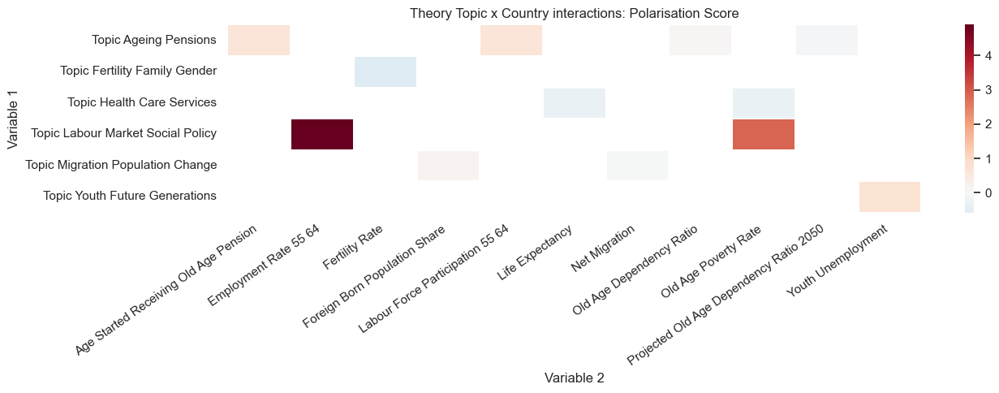


Trying heatmap: polarisation_score | mep_x_topic
Base rows: 156
Theory rows: 3
Rows used: 3
Saved PNG: C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\7 Final Analysis\outputs\figures\theory_heatmap_mep_topic_polarisation_score.png exists: True


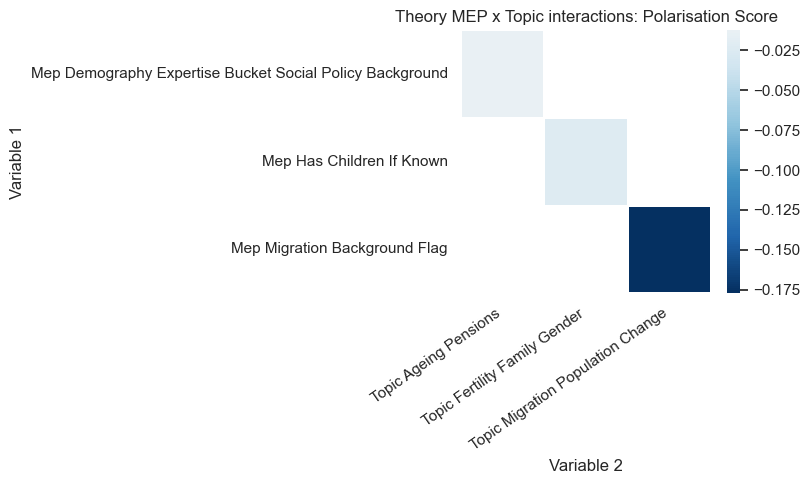


Trying heatmap: us_vs_them | topic_x_country
Base rows: 126
Theory rows: 12
Rows used: 12
Saved PNG: C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\7 Final Analysis\outputs\figures\theory_heatmap_topic_country_us_vs_them.png exists: True


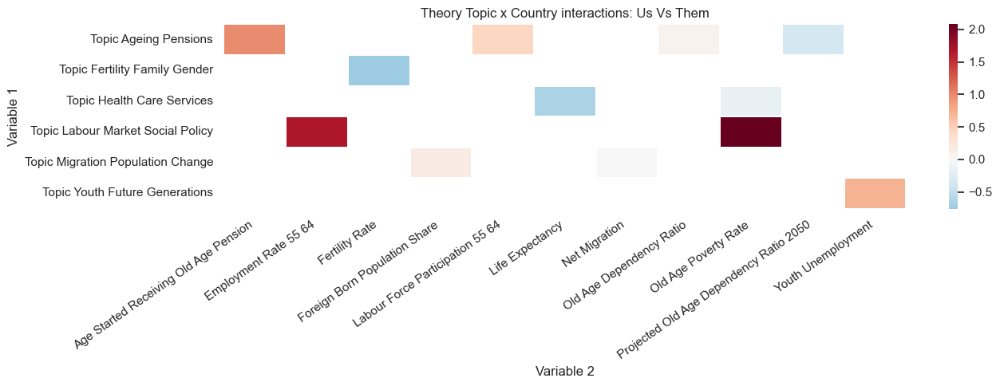


Trying heatmap: us_vs_them | mep_x_topic
Base rows: 156
Theory rows: 3
Rows used: 3
Saved PNG: C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\7 Final Analysis\outputs\figures\theory_heatmap_mep_topic_us_vs_them.png exists: True


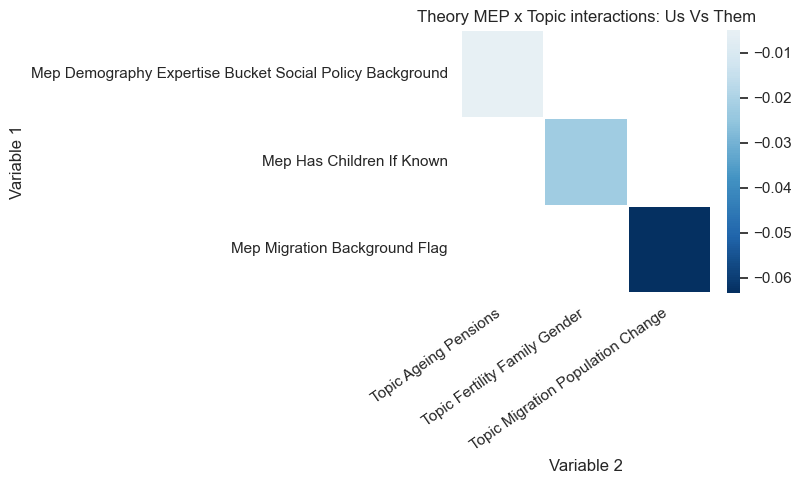


Trying heatmap: emotional_intensity | topic_x_country
Base rows: 126
Theory rows: 12
Rows used: 12
Saved PNG: C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\7 Final Analysis\outputs\figures\theory_heatmap_topic_country_emotional_intensity.png exists: True


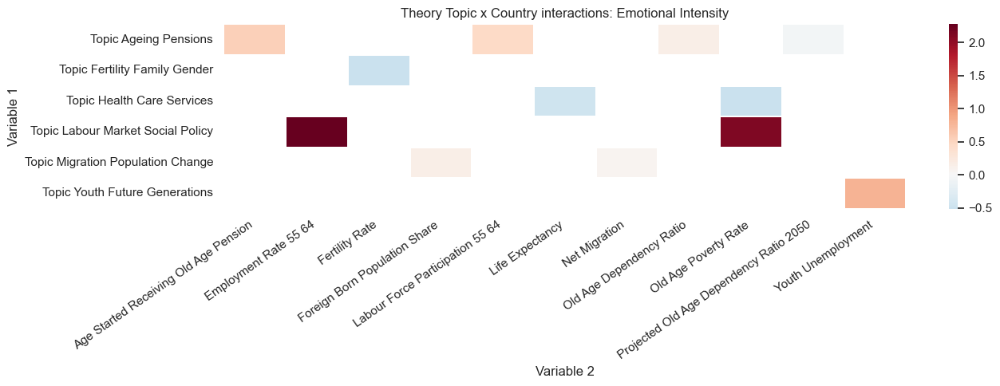


Trying heatmap: emotional_intensity | mep_x_topic
Base rows: 156
Theory rows: 3
Rows used: 3
Saved PNG: C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\7 Final Analysis\outputs\figures\theory_heatmap_mep_topic_emotional_intensity.png exists: True


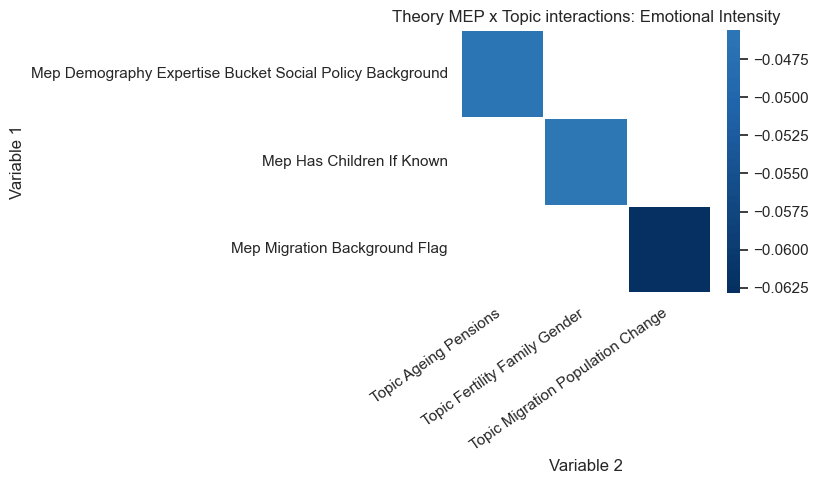


Trying heatmap: moral_absolutism | topic_x_country
Base rows: 126
Theory rows: 12
Rows used: 12
Saved PNG: C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\7 Final Analysis\outputs\figures\theory_heatmap_topic_country_moral_absolutism.png exists: True


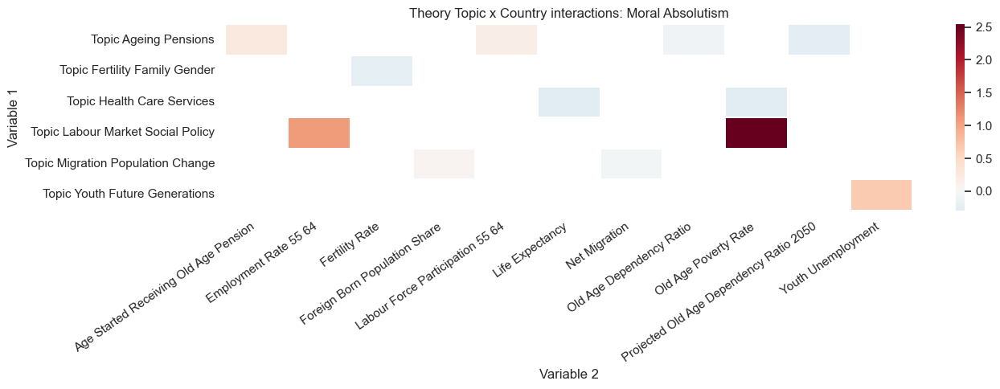


Trying heatmap: moral_absolutism | mep_x_topic
Base rows: 156
Theory rows: 3
Rows used: 3
Saved PNG: C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\7 Final Analysis\outputs\figures\theory_heatmap_mep_topic_moral_absolutism.png exists: True


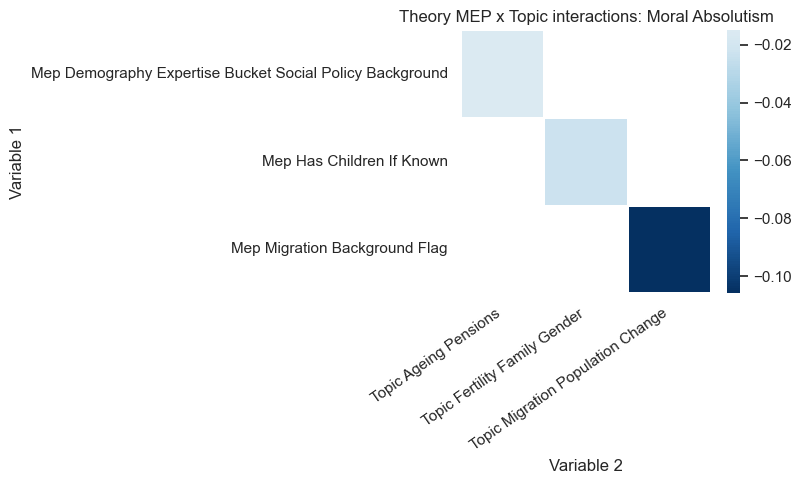


Trying heatmap: hostility_to_opponents | topic_x_country
Base rows: 126
Theory rows: 12
Rows used: 12
Saved PNG: C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\7 Final Analysis\outputs\figures\theory_heatmap_topic_country_hostility_to_opponents.png exists: True


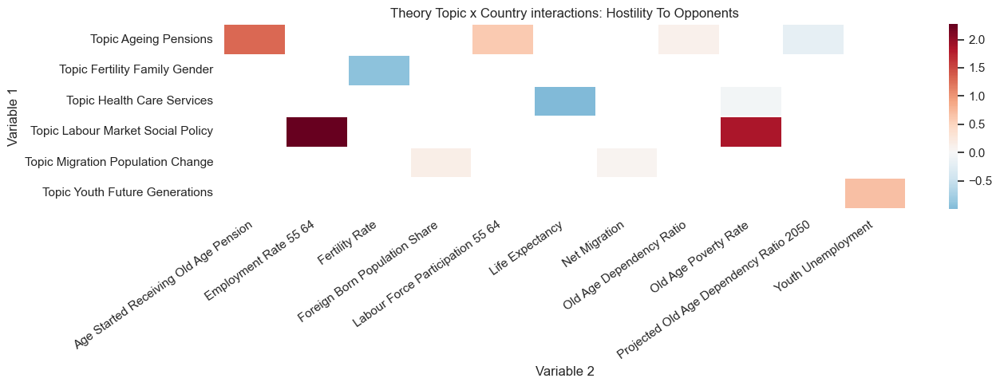


Trying heatmap: hostility_to_opponents | mep_x_topic
Base rows: 156
Theory rows: 3
Rows used: 3
Saved PNG: C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\7 Final Analysis\outputs\figures\theory_heatmap_mep_topic_hostility_to_opponents.png exists: True


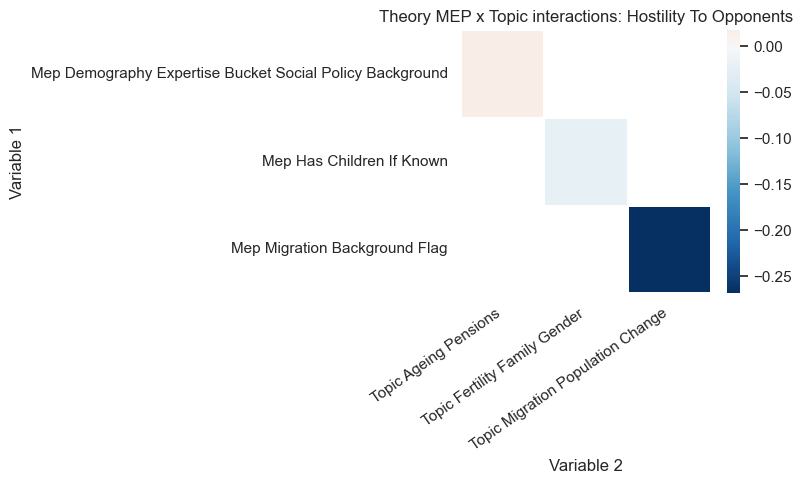


Selected interaction plot diagnostics:
Available plot outcomes: ['polarisation_score', 'emotional_intensity', 'hostility_to_opponents', 'moral_absolutism', 'us_vs_them']
Available interaction pairs: 418

Trying selected plot: Topic Labour Market Social Policy x Employment Rate 55 64
Matches found: 1
SKIPPED: variables not found in analysis_df: topic_labour_market_social_policy employment_rate_55_64

Trying selected plot: Topic Labour Market Social Policy x Old Age Poverty Rate
Matches found: 1
SKIPPED: variables not found in analysis_df: topic_labour_market_social_policy old_age_poverty_rate

Trying selected plot: Topic Migration Population Change x Foreign Born Population Share
Matches found: 1
SKIPPED: variables not found in analysis_df: topic_migration_population_change foreign_born_population_share

Trying selected plot: Topic Migration Population Change x Net Migration
Matches found: 1
SKIPPED: variables not found in analysis_df: topic_migration_population_change net_migration

T

In [ ]:
# Follow-up diagnostics and robust summaries for exploratory interaction screening
# Sections 6-10
# Saves figures as PNG only

# Make sure exploratory outputs use the Final Analysis output folders
if "TABLES_DIR" in globals() and "FIGURES_DIR" in globals():
    TABLES_OUT_DIR = TABLES_DIR
    FIGURES_OUT_DIR = FIGURES_DIR
else:
    if "PROJECT_ROOT" not in globals():
        PROJECT_ROOT = Path.cwd()

    if PROJECT_ROOT.name == "7 Final Analysis":
        FINAL_ANALYSIS_DIR = PROJECT_ROOT
    else:
        FINAL_ANALYSIS_DIR = PROJECT_ROOT / "7 Final Analysis"

    TABLES_OUT_DIR = FINAL_ANALYSIS_DIR / "outputs" / "tables"
    FIGURES_OUT_DIR = FINAL_ANALYSIS_DIR / "outputs" / "figures"

TABLES_OUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_OUT_DIR.mkdir(parents=True, exist_ok=True)

print("TABLES_OUT_DIR:", TABLES_OUT_DIR.resolve())
print("FIGURES_OUT_DIR:", FIGURES_OUT_DIR.resolve())


# 6) Theory-priority heatmaps, with fallback and hard save checks

sns.set_theme(style="white", context="notebook")

heatmap_files = []
outcomes_to_plot = [
    o for o in outcome_cols if o in screen_diag["outcome_variable"].dropna().unique()
]

print("Outcomes to plot:", outcomes_to_plot)
print("Theory-priority rows:", int(screen_diag["theory_priority_flag"].fillna(False).sum()))
print("Model status counts:")
print(screen_diag["model_status"].value_counts(dropna=False))
print("Interaction family counts:")
print(screen_diag["interaction_family"].value_counts(dropna=False))

for out in outcomes_to_plot:
    out_slug = re.sub(r"[^a-z0-9]+", "_", str(out).lower()).strip("_")

    for fam, fam_slug, fam_label in [
        ("topic_x_country", "topic_country", "Topic x Country"),
        ("mep_x_topic", "mep_topic", "MEP x Topic"),
    ]:
        base_sub = screen_diag[
            (screen_diag["outcome_variable"] == out)
            & (screen_diag["interaction_family"] == fam)
            & (screen_diag["model_status"] == "ok")
        ].copy()

        theory_sub = base_sub[base_sub["theory_priority_flag"].fillna(False)].copy()

        if not theory_sub.empty:
            sub = theory_sub
            plot_type = "theory"
            filename_prefix = "theory_heatmap"
        else:
            sub = base_sub
            plot_type = "fallback_all_available"
            filename_prefix = "fallback_heatmap"

        print(f"\nTrying heatmap: {out} | {fam}")
        print("Base rows:", len(base_sub))
        print("Theory rows:", len(theory_sub))
        print("Rows used:", len(sub))

        if sub.empty:
            print("SKIPPED: no rows available.")
            continue

        sub["signed_score"] = pd.to_numeric(sub["signed_score"], errors="coerce")
        sub = sub.dropna(subset=["variable_1", "variable_2", "signed_score"])

        if sub.empty:
            print("SKIPPED: no usable signed_score values.")
            continue

        piv = sub.pivot_table(
            index="variable_1",
            columns="variable_2",
            values="signed_score",
            aggfunc="mean",
        )

        piv = piv.dropna(axis=0, how="all").dropna(axis=1, how="all")

        if piv.empty:
            print("SKIPPED: pivot table is empty.")
            continue

        piv = piv.copy()
        piv.index = [pretty_display_name(v) for v in piv.index]
        piv.columns = [pretty_display_name(v) for v in piv.columns]

        fig_width = max(8, 1.25 * len(piv.columns))
        fig_height = max(5, 0.55 * len(piv.index))

        fig, ax = plt.subplots(figsize=(fig_width, fig_height))

        sns.heatmap(
            piv,
            cmap="RdBu_r",
            center=0,
            linewidths=0.25,
            ax=ax,
        )

        ax.set_title(
            f"{plot_type.replace('_', ' ').title()} {fam_label} interactions: "
            f"{pretty_display_name(out)}"
        )
        ax.set_xlabel("Variable 2")
        ax.set_ylabel("Variable 1")

        ax.tick_params(axis="x", rotation=35)
        for label in ax.get_xticklabels():
            label.set_ha("right")

        fig.tight_layout()

        out_path_png = FIGURES_OUT_DIR / f"{filename_prefix}_{fam_slug}_{out_slug}.png"

        fig.savefig(out_path_png, dpi=300, bbox_inches="tight")

        print("Saved PNG:", out_path_png.resolve(), "exists:", out_path_png.exists())

        heatmap_files.append(str(out_path_png))

        plt.show()
        plt.close(fig)


# 7) Top 10 by outcome with diagnostics

rows_top10 = []

for out, sub in screen_diag.groupby("outcome_variable"):
    work = sub.copy()
    work["abs_signed_score"] = pd.to_numeric(
        work["signed_score"], errors="coerce"
    ).abs()

    top10 = work.sort_values("abs_signed_score", ascending=False).head(10)

    for _, r in top10.iterrows():
        warnings = []

        if bool(r.get("sparse_category_warning", False)):
            warnings.append("Sparse category; may be unstable")

        if not bool(r.get("theory_priority_flag", False)):
            warnings.append("Not theory-priority")

        p_raw = r.get("p_value", np.nan)
        p_fdr = r.get("p_value_fdr", np.nan)

        if (pd.isna(p_raw) or p_raw >= 0.05) and (pd.isna(p_fdr) or p_fdr >= 0.10):
            warnings.append("No raw/FDR support")

        rows_top10.append(
            {
                "outcome_variable": out,
                "interaction_name": r.get("interaction_name"),
                "interaction_family": r.get("interaction_family"),
                "coefficient": r.get("coefficient"),
                "p_value": r.get("p_value"),
                "p_value_fdr": r.get("p_value_fdr"),
                "n_observations": r.get("n_observations"),
                "sparse_category_warning": bool(r.get("sparse_category_warning", False)),
                "theory_priority_flag": bool(r.get("theory_priority_flag", False)),
                "interpretation_warning": (
                    " | ".join(warnings) if warnings else "No immediate warning"
                ),
            }
        )

top10_diag_df = pd.DataFrame(rows_top10)
top10_diag_path = TABLES_OUT_DIR / "exploratory_top10_interactions_by_outcome_with_diagnostics.csv"
top10_diag_df.to_csv(top10_diag_path, index=False)


# 8) Selected interaction plots, binned descriptive fallback, with hard save checks

selected_priority_plots = [
    "Topic Labour Market Social Policy x Employment Rate 55 64",
    "Topic Labour Market Social Policy x Old Age Poverty Rate",
    "Topic Migration Population Change x Foreign Born Population Share",
    "Topic Migration Population Change x Net Migration",
    "Topic Ageing Pensions x Projected Old Age Dependency Ratio 2050",
    "Topic Ageing Pensions x Age Started Receiving Old Age Pension",
    "Topic Youth Future Generations x Youth Unemployment",
    "Topic Fertility Family Gender x Fertility Rate",
]

plot_outcomes = [
    "polarisation_score",
    "emotional_intensity",
    "hostility_to_opponents",
    "moral_absolutism",
    "us_vs_them",
]

plot_outcomes = [o for o in plot_outcomes if o in analysis_df.columns]

interaction_pairs = (
    screen_diag[
        [
            "interaction_name",
            "interaction_family",
            "variable_1",
            "variable_2",
            "theory_priority_flag",
        ]
    ]
    .dropna(subset=["variable_1", "variable_2"])
    .drop_duplicates()
)

pair_to_rows = {}

for _, rr in interaction_pairs.iterrows():
    key = interaction_key(rr["variable_1"], rr["variable_2"])
    pair_to_rows.setdefault(key, []).append(rr)

selected_plot_files = []

print("\nSelected interaction plot diagnostics:")
print("Available plot outcomes:", plot_outcomes)
print("Available interaction pairs:", len(pair_to_rows))

for item in selected_priority_plots:
    parts = re.split(r"\s+x\s+", item, maxsplit=1, flags=re.IGNORECASE)

    if len(parts) != 2:
        print("SKIPPED priority item, could not split:", item)
        continue

    key = interaction_key(parts[0], parts[1])
    matches = pair_to_rows.get(key, [])

    print(f"\nTrying selected plot: {item}")
    print("Matches found:", len(matches))

    if not matches:
        continue

    match_row = matches[0]

    v1, v2 = str(match_row["variable_1"]), str(match_row["variable_2"])

    if "topic_" in v1:
        topic_var, country_var = v1, v2
    elif "topic_" in v2:
        topic_var, country_var = v2, v1
    else:
        print("SKIPPED: no topic variable detected.")
        continue

    if topic_var not in analysis_df.columns or country_var not in analysis_df.columns:
        print("SKIPPED: variables not found in analysis_df:", topic_var, country_var)
        continue

    for out in plot_outcomes:
        tmp = analysis_df[[topic_var, country_var, out]].copy()

        tmp[topic_var] = pd.to_numeric(tmp[topic_var], errors="coerce")
        tmp[country_var] = pd.to_numeric(tmp[country_var], errors="coerce")
        tmp[out] = pd.to_numeric(tmp[out], errors="coerce")

        tmp = tmp.dropna()

        print(f"Outcome {out}: usable rows =", len(tmp))

        if len(tmp) < 40:
            print("SKIPPED: fewer than 40 usable rows.")
            continue

        try:
            tmp["topic_tercile"] = pd.qcut(
                tmp[topic_var],
                q=3,
                labels=["Low", "Medium", "High"],
                duplicates="drop",
            )
        except Exception as e:
            print("SKIPPED: topic tercile failed:", e)
            continue

        if tmp["topic_tercile"].nunique(dropna=True) < 2:
            print("SKIPPED: fewer than 2 topic terciles.")
            continue

        try:
            tmp["country_bin"] = pd.qcut(
                tmp[country_var],
                q=min(10, tmp[country_var].nunique()),
                duplicates="drop",
            )
        except Exception as e:
            print("SKIPPED: country binning failed:", e)
            continue

        if tmp["country_bin"].nunique(dropna=True) < 3:
            print("SKIPPED: fewer than 3 country bins.")
            continue

        binned = (
            tmp.groupby(["country_bin", "topic_tercile"], observed=True)
            .agg(country_x=(country_var, "mean"), y_mean=(out, "mean"), n=(out, "size"))
            .reset_index()
        )

        if binned.empty:
            print("SKIPPED: binned dataframe empty.")
            continue

        fig, ax = plt.subplots(figsize=(8.5, 5.2))

        sns.lineplot(
            data=binned,
            x="country_x",
            y="y_mean",
            hue="topic_tercile",
            marker="o",
            ax=ax,
        )

        ax.set_title(
            f"Binned interaction: {pretty_display_name(v1)} x "
            f"{pretty_display_name(v2)} | {pretty_display_name(out)}"
        )
        ax.set_xlabel(pretty_display_name(country_var))
        ax.set_ylabel(pretty_display_name(out))

        fig.tight_layout()

        slug_inter = re.sub(r"[^a-z0-9]+", "_", canon_text(item)).strip("_")
        slug_out = re.sub(r"[^a-z0-9]+", "_", canon_text(out)).strip("_")

        out_path_png = (
            FIGURES_OUT_DIR
            / f"selected_interaction_plot_{slug_inter}_{slug_out}.png"
        )

        fig.savefig(out_path_png, dpi=300, bbox_inches="tight")

        print("Saved PNG:", out_path_png.resolve(), "exists:", out_path_png.exists())

        selected_plot_files.append(str(out_path_png))

        plt.show()
        plt.close(fig)


# 9) Selected findings table for discussion

ADEQUATE_N = 80

selected_base = screen_diag.copy()

selected_base["direction"] = np.where(
    pd.to_numeric(selected_base["coefficient"], errors="coerce") > 0,
    "positive",
    np.where(
        pd.to_numeric(selected_base["coefficient"], errors="coerce") < 0,
        "negative",
        "unclear",
    ),
)

selected_base["abs_signed_score"] = pd.to_numeric(
    selected_base["signed_score"], errors="coerce"
).abs()

selected_base = selected_base.sort_values(
    [
        "theory_priority_flag",
        "sparse_category_warning",
        "p_value_fdr",
        "p_value",
        "abs_signed_score",
    ],
    ascending=[False, True, True, True, False],
)

selected_rows = []

for _, r in selected_base.head(80).iterrows():
    sparse_warn = bool(r.get("sparse_category_warning", False))
    theory_flag = bool(r.get("theory_priority_flag", False))

    n_obs = pd.to_numeric(r.get("n_observations"), errors="coerce")
    p_raw = pd.to_numeric(r.get("p_value"), errors="coerce")
    p_fdr = pd.to_numeric(r.get("p_value_fdr"), errors="coerce")

    direction = r.get("direction", "unclear")

    if sparse_warn:
        interp = "Likely sensitive to sparse categories; interpret cautiously."
    elif theory_flag and (
        (pd.notna(p_fdr) and p_fdr < 0.10)
        or (pd.notna(p_raw) and p_raw < 0.05)
    ):
        interp = "Theory-consistent exploratory signal with statistical support."
    elif theory_flag:
        interp = "Theory-priority but weak statistical support in exploratory screening."
    else:
        interp = "Exploratory association without a strong pre-specified theory anchor."

    use_in_paper = bool(
        theory_flag
        and (not sparse_warn)
        and pd.notna(n_obs)
        and n_obs >= ADEQUATE_N
        and direction in {"positive", "negative"}
        and (
            (pd.notna(p_fdr) and p_fdr < 0.10)
            or (pd.notna(p_raw) and p_raw < 0.05)
        )
    )

    selected_rows.append(
        {
            "interaction_name": r.get("interaction_name"),
            "outcome_variable": r.get("outcome_variable"),
            "direction": direction,
            "coefficient": r.get("coefficient"),
            "p_value": p_raw,
            "p_value_fdr": p_fdr,
            "n_observations": n_obs,
            "sparse_category_warning": sparse_warn,
            "theory_priority_flag": theory_flag,
            "suggested_interpretation": interp,
            "use_in_paper": use_in_paper,
        }
    )

selected_findings_df = pd.DataFrame(selected_rows)
selected_findings_path = TABLES_OUT_DIR / "selected_exploratory_findings_for_discussion.csv"
selected_findings_df.to_csv(selected_findings_path, index=False)


# 10) Final printed summary

n_total_screened = int(len(screen_diag))
n_sparse_rows = int(screen_diag["sparse_category_warning"].fillna(False).sum())
n_theory_interactions = int(
    screen_diag.loc[screen_diag["theory_priority_flag"], "interaction_name"].nunique()
)
n_raw_p05 = int(
    screen_diag.loc[screen_diag["p_value"] < 0.05, "interaction_name"].nunique()
)
n_fdr_p10 = int(
    screen_diag.loc[screen_diag["p_value_fdr"] < 0.10, "interaction_name"].nunique()
)

files_saved = [
    str(top10_diag_path),
    str(selected_findings_path),
] + heatmap_files + selected_plot_files

print("\nFollow-up exploratory diagnostics complete.")
print(f"Total interactions screened: {n_total_screened}")
print(f"Rows flagged as sparse: {n_sparse_rows}")
print(f"Theory-priority interactions found: {n_theory_interactions}")
print(f"Interactions with raw p < .05: {n_raw_p05}")
print(f"Interactions with FDR p < .10: {n_fdr_p10}")
print("Files saved:")

for fp in files_saved:
    print(" -", fp)

print("\nFinal check of output folders:")
print("TABLES_OUT_DIR:", TABLES_OUT_DIR.resolve())
print("FIGURES_OUT_DIR:", FIGURES_OUT_DIR.resolve())

print("\nPNG files currently in figure folder:")
for f in sorted(FIGURES_OUT_DIR.glob("*.png")):
    print(" -", f.name)

In [ ]:
# Fallback selected interaction plots
# Ensures feasible outputs for theory-priority topic x country interactions
# Saves PNG only

if "analysis_df" not in globals():
    raise RuntimeError("analysis_df is required for selected interaction plots.")

if "PROJECT_ROOT" not in globals():
    from pathlib import Path
    PROJECT_ROOT = Path.cwd()

# Force outputs into 7 Final Analysis outputs folder
if "TABLES_DIR" in globals() and "FIGURES_DIR" in globals():
    TABLES_OUT_DIR = TABLES_DIR
    FIGURES_OUT_DIR = FIGURES_DIR
else:
    if PROJECT_ROOT.name == "7 Final Analysis":
        FINAL_ANALYSIS_DIR = PROJECT_ROOT
    else:
        FINAL_ANALYSIS_DIR = PROJECT_ROOT / "7 Final Analysis"

    TABLES_OUT_DIR = FINAL_ANALYSIS_DIR / "outputs" / "tables"
    FIGURES_OUT_DIR = FINAL_ANALYSIS_DIR / "outputs" / "figures"

TABLES_OUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_OUT_DIR.mkdir(parents=True, exist_ok=True)

print("TABLES_OUT_DIR:", TABLES_OUT_DIR.resolve())
print("FIGURES_OUT_DIR:", FIGURES_OUT_DIR.resolve())

screen_diag_path = TABLES_OUT_DIR / "exploratory_interaction_screening_with_diagnostics.csv"

if not screen_diag_path.exists():
    raise RuntimeError(
        f"Run the follow-up diagnostics cell first to create screening diagnostics CSV: {screen_diag_path}"
    )

screen_diag = pd.read_csv(screen_diag_path)


def canon_text(x):
    s = str(x).lower()
    s = re.sub(r"[^a-z0-9]+", " ", s)
    return re.sub(r"\s+", " ", s).strip()


def pretty_display_name(x):
    s = str(x).replace("_x_", " x ").replace("_", " ")
    s = re.sub(r"\s+", " ", s).strip()
    return s.title()


def slugify(x):
    return re.sub(r"[^a-z0-9]+", "_", canon_text(x)).strip("_")


def tokenize_topic_name(x):
    tokens = [t for t in canon_text(x).split() if t not in {"topic", "share"}]
    return set(tokens)


def resolve_topic_col(var_name):
    if var_name in analysis_df.columns:
        return var_name

    if "resolved_topic_cols" in globals() and isinstance(resolved_topic_cols, dict):
        mapped = resolved_topic_cols.get(var_name)

        if isinstance(mapped, str) and mapped in analysis_df.columns:
            return mapped

    candidates = []

    if "topic_share_cols" in globals() and isinstance(topic_share_cols, list):
        candidates = [c for c in topic_share_cols if c in analysis_df.columns]

    if not candidates:
        candidates = [c for c in analysis_df.columns if "topic" in str(c).lower()]

    target_tokens = tokenize_topic_name(var_name)

    if not target_tokens:
        return None

    best_col = None
    best_score = -1

    for c in candidates:
        col_tokens = tokenize_topic_name(c)
        score = len(target_tokens.intersection(col_tokens))

        if score > best_score:
            best_score = score
            best_col = c

    if best_score <= 0:
        return None

    return best_col


priority_pairs_requested = [
    "Topic Labour Market Social Policy x Employment Rate 55 64",
    "Topic Labour Market Social Policy x Old Age Poverty Rate",
    "Topic Migration Population Change x Foreign Born Population Share",
    "Topic Migration Population Change x Net Migration",
    "Topic Ageing Pensions x Projected Old Age Dependency Ratio 2050",
    "Topic Ageing Pensions x Age Started Receiving Old Age Pension",
    "Topic Youth Future Generations x Youth Unemployment",
    "Topic Fertility Family Gender x Fertility Rate",
]


def pair_key(v1, v2):
    return tuple(sorted([canon_text(v1), canon_text(v2)]))


requested_keys = set()

for item in priority_pairs_requested:
    parts = re.split(r"\s+x\s+", item, maxsplit=1, flags=re.IGNORECASE)

    if len(parts) == 2:
        requested_keys.add(pair_key(parts[0], parts[1]))


cand = screen_diag[
    (screen_diag["interaction_family"] == "topic_x_country")
    & (screen_diag["theory_priority_flag"].fillna(False))
    & (screen_diag["model_status"] == "ok")
].copy()

if cand.empty:
    print("No theory-priority topic x country rows available for fallback plotting.")
else:
    cand["abs_signed_score"] = pd.to_numeric(
        cand["signed_score"], errors="coerce"
    ).abs()

    cand["is_requested"] = cand.apply(
        lambda r: pair_key(r["variable_1"], r["variable_2"]) in requested_keys,
        axis=1,
    )

    pair_rank = (
        cand.groupby(["variable_1", "variable_2"], as_index=False)
        .agg(
            max_abs_signed_score=("abs_signed_score", "max"),
            is_requested=("is_requested", "max"),
        )
        .sort_values(
            ["is_requested", "max_abs_signed_score"],
            ascending=[False, False],
        )
    )

    selected_pairs = pair_rank.head(8)

    outcomes = [
        "polarisation_score",
        "emotional_intensity",
        "hostility_to_opponents",
        "moral_absolutism",
        "us_vs_them",
    ]

    outcomes = [o for o in outcomes if o in analysis_df.columns]

    saved_plots = []

    sns.set_theme(style="whitegrid", context="notebook")

    print("Selected pairs to plot:", len(selected_pairs))
    print("Outcomes to plot:", outcomes)

    for _, prow in selected_pairs.iterrows():
        v1 = str(prow["variable_1"])
        v2 = str(prow["variable_2"])

        if "topic_" in v1:
            topic_var_raw, country_var = v1, v2
        elif "topic_" in v2:
            topic_var_raw, country_var = v2, v1
        else:
            print("SKIPPED: no topic variable detected:", v1, v2)
            continue

        topic_var = resolve_topic_col(topic_var_raw)

        if topic_var is None:
            print("SKIPPED: could not resolve topic column:", topic_var_raw)
            continue

        if country_var not in analysis_df.columns:
            print("SKIPPED: country variable not in analysis_df:", country_var)
            continue

        for out in outcomes:
            tmp = analysis_df[[topic_var, country_var, out]].copy()

            tmp[topic_var] = pd.to_numeric(tmp[topic_var], errors="coerce")
            tmp[country_var] = pd.to_numeric(tmp[country_var], errors="coerce")
            tmp[out] = pd.to_numeric(tmp[out], errors="coerce")

            tmp = tmp.dropna()

            print(
                f"Trying plot: {topic_var_raw} x {country_var} | {out} "
                f"with usable rows = {len(tmp)}"
            )

            if len(tmp) < 40:
                print("SKIPPED: fewer than 40 usable rows.")
                continue

            try:
                tmp["topic_tercile"] = pd.qcut(
                    tmp[topic_var],
                    q=3,
                    labels=["Low", "Medium", "High"],
                    duplicates="drop",
                )
            except Exception as e:
                print("SKIPPED: topic tercile failed:", e)
                continue

            if tmp["topic_tercile"].nunique(dropna=True) < 2:
                print("SKIPPED: fewer than 2 topic terciles.")
                continue

            q_bins = min(10, int(tmp[country_var].nunique()))

            if q_bins < 3:
                print("SKIPPED: fewer than 3 unique country-variable values.")
                continue

            try:
                tmp["country_bin"] = pd.qcut(
                    tmp[country_var],
                    q=q_bins,
                    duplicates="drop",
                )
            except Exception as e:
                print("SKIPPED: country binning failed:", e)
                continue

            if tmp["country_bin"].nunique(dropna=True) < 3:
                print("SKIPPED: fewer than 3 country bins.")
                continue

            binned = (
                tmp.groupby(["country_bin", "topic_tercile"], observed=True)
                .agg(
                    country_x=(country_var, "mean"),
                    y_mean=(out, "mean"),
                    n=(out, "size"),
                )
                .reset_index()
            )

            if binned.empty:
                print("SKIPPED: binned dataframe empty.")
                continue

            fig, ax = plt.subplots(figsize=(8.6, 5.3))

            sns.lineplot(
                data=binned,
                x="country_x",
                y="y_mean",
                hue="topic_tercile",
                marker="o",
                ax=ax,
            )

            ax.set_title(
                f"Selected interaction plot: {pretty_display_name(topic_var_raw)} x "
                f"{pretty_display_name(country_var)} | {pretty_display_name(out)}"
            )
            ax.set_xlabel(pretty_display_name(country_var))
            ax.set_ylabel(pretty_display_name(out))

            fig.tight_layout()

            interaction_label = f"{topic_var_raw} x {country_var}"

            out_path_png = (
                FIGURES_OUT_DIR
                / f"selected_interaction_plot_{slugify(interaction_label)}_{slugify(out)}.png"
            )

            fig.savefig(out_path_png, dpi=300, bbox_inches="tight")

            print("Saved PNG:", out_path_png.resolve(), "exists:", out_path_png.exists())

            saved_plots.append(str(out_path_png))

            plt.show()
            plt.close(fig)

    print(f"Fallback selected interaction plots saved: {len(saved_plots)}")

    for fp in saved_plots:
        print(" -", fp)

    print("\nFinal check of figure folder:")
    print("FIGURES_OUT_DIR:", FIGURES_OUT_DIR.resolve())

    print("\nPNG files currently in figure folder:")
    for f in sorted(FIGURES_OUT_DIR.glob("*.png")):
        print(" -", f.name)

TABLES_OUT_DIR: C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\7 Final Analysis\outputs\tables
FIGURES_OUT_DIR: C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\7 Final Analysis\outputs\figures


RuntimeError: Run the follow-up diagnostics cell first to create screening diagnostics CSV: C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\7 Final Analysis\outputs\tables\exploratory_interaction_screening_with_diagnostics.csv